In [8]:
# Quick Dataset Column Checker
# Run this to see what columns you actually have

import pandas as pd

# Load your data
df = pd.read_csv('products_with_weekend.csv')

print("=== DATASET COLUMN ANALYSIS ===")
print(f"Dataset shape: {df.shape}")
print(f"\nAll columns in your dataset:")
print("-" * 40)

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    non_null = df[col].count()
    unique_vals = df[col].nunique()
    
    print(f"{i:2d}. {col:<25} | Type: {str(dtype):<10} | Non-null: {non_null:>6} | Unique: {unique_vals:>6}")

print(f"\nSample of first few rows:")
print("=" * 60)
print(df.head(3).to_string())

print(f"\nKey columns check:")
print("=" * 30)
required_cols = ['Physical Storage Quantity', 'Weekend', 'Name']
optional_cols = ['Demanded', 'Delivered', 'Family', 'GroupName', 'Date_week', 'Inventory_Cycle']

for col in required_cols:
    status = "✓ EXISTS" if col in df.columns else "✗ MISSING"
    print(f"{col:<30}: {status}")

print(f"\nOptional columns:")
for col in optional_cols:
    status = "✓ EXISTS" if col in df.columns else "✗ MISSING"
    print(f"{col:<30}: {status}")

=== DATASET COLUMN ANALYSIS ===
Dataset shape: (72752, 26)

All columns in your dataset:
----------------------------------------
 1. Site                      | Type: object     | Non-null:  72752 | Unique:      1
 2. Item Id                   | Type: int64      | Non-null:  72752 | Unique:    477
 3. Name                      | Type: object     | Non-null:  72752 | Unique:    496
 4. Physical Storage Quantity | Type: float64    | Non-null:  72752 | Unique:   2285
 5. Storage Unit              | Type: object     | Non-null:  72752 | Unique:    107
 6. Family                    | Type: object     | Non-null:  72752 | Unique:      5
 7. GroupName                 | Type: object     | Non-null:  72752 | Unique:     29
 8. From                      | Type: object     | Non-null:  72752 | Unique:      7
 9. To                        | Type: object     | Non-null:  72752 | Unique:     17
10. Delivery date             | Type: object     | Non-null:  72752 | Unique:    515
11. Date_week       

✓ XGBoost version: 3.0.4
ROBUST TIME-SERIES INVENTORY PREDICTOR
Proper validation, no data leakage, controlled overfitting
Running Robust Time-Series Inventory Prediction...
Loading data from: products_with_weekend.csv
✓ Data loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Weekend ratio: 43.3%

=== WEEKEND EFFECT ANALYSIS ===
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: 1.21x
Statistical significance: p = 0.0000
✓ Weekend effect is statistically significant

Creating time-series features...
  Creating lag features...
  Creating rolling features...
  Creating trend features...
  Creating seasonal features...
  Creating product weekend patterns...
  Creating weekend interaction features...
✓ Features created. New shape: (72752, 48)

Preparing data for modeling...
Selected 14 features:
  lag: 5
  rolling: 2
  trend: 2
  seasonal: 2
  weekend: 5
  basic: 3
✓ Removed early cycles. Data shape: (63217, 48)
✓ Final dataset: 63217 samples with 14 feat

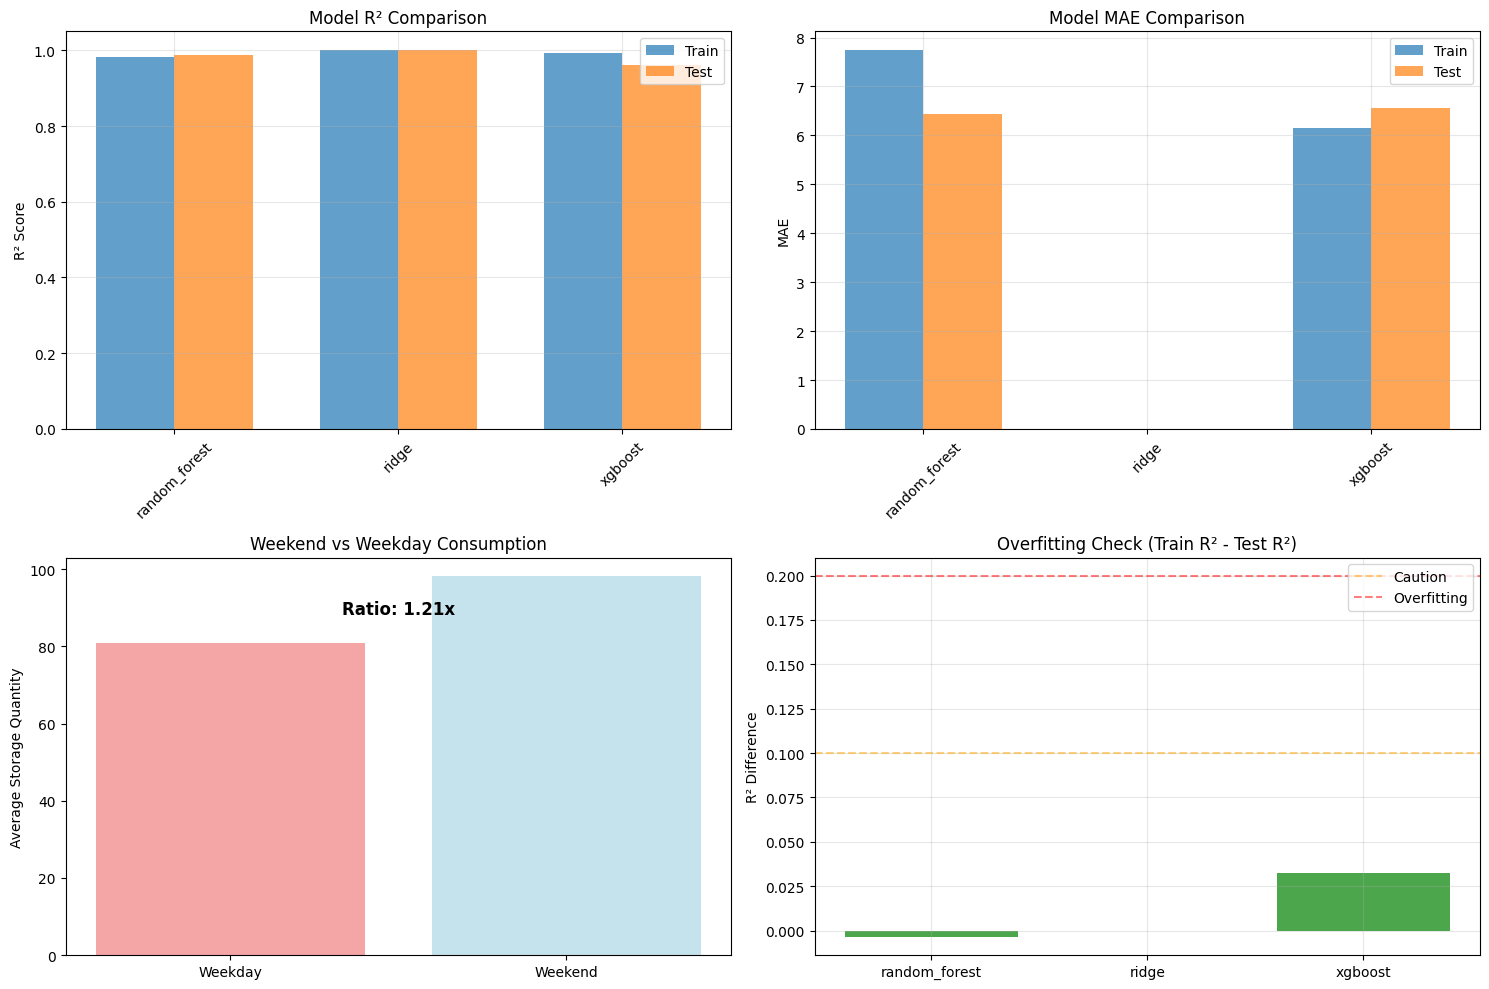


=== FINAL ASSESSMENT ===
Best model: ridge
Test R²: 1.000
Test MAE: 0.01
✓ No significant overfitting detected
🎯 Excellent performance

✓ Robust analysis completed!


In [12]:
# Robust Time-Series Inventory Predictor
# =====================================
# Addresses data leakage and overfitting issues
# Uses proper time-series validation and simpler models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import warnings

plt.style.use('default')
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    print(f"✓ XGBoost version: {xgb.__version__}")
    USE_XGBOOST = True
except ImportError:
    print("✗ XGBoost not available")
    USE_XGBOOST = False

np.random.seed(42)

print("=" * 60)
print("ROBUST TIME-SERIES INVENTORY PREDICTOR")
print("Proper validation, no data leakage, controlled overfitting")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate metrics with proper error handling"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Remove infinite and NaN values
    finite_mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(finite_mask):
        return {'mae': float('inf'), 'rmse': float('inf'), 'r2': -1, 'mape': float('inf')}
    
    y_true = y_true[finite_mask]
    y_pred = y_pred[finite_mask]
    
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Proper MAPE calculation
        mask = y_true != 0
        if np.any(mask):
            mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        else:
            mape = float('inf')
        
        return {
            'mae': float(mae),
            'rmse': float(rmse),
            'r2': float(r2),
            'mape': float(mape)
        }
    except Exception as e:
        print(f"Error calculating metrics: {e}")
        return {'mae': float('inf'), 'rmse': float('inf'), 'r2': -1, 'mape': float('inf')}

class RobustTimeSeriesProcessor:
    """Time-series processor with proper temporal handling"""
    
    def __init__(self):
        self.weekend_stats = {}
        self.scalers = {}
        
    def load_and_validate_data(self, file_path):
        """Load and validate time-series structure"""
        print(f"Loading data from: {file_path}")
        
        try:
            df = pd.read_csv(file_path)
            print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
            
            # Validate required columns
            required_cols = ['Physical Storage Quantity', 'Weekend', 'Name', 'Inventory_Cycle']
            missing_cols = [col for col in required_cols if col not in df.columns]
            
            if missing_cols:
                raise ValueError(f"Missing required columns: {missing_cols}")
            
            # Sort by product and time
            df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
            
            # Basic validation
            print(f"✓ Products: {df['Name'].nunique()}")
            print(f"✓ Time periods: {df['Inventory_Cycle'].nunique()}")
            print(f"✓ Weekend ratio: {df['Weekend'].mean():.1%}")
            
            # Analyze weekend patterns
            self.analyze_weekend_effect(df)
            
            return df
            
        except Exception as e:
            print(f"✗ Error loading data: {e}")
            return None
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\n=== WEEKEND EFFECT ANALYSIS ===")
        
        weekend_data = df[df['Weekend'] == 1]['Physical Storage Quantity']
        weekday_data = df[df['Weekend'] == 0]['Physical Storage Quantity']
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: {weekend_ratio:.2f}x")
        
        # Statistical test
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.4f}")
            
            if p_value < 0.05:
                print("✓ Weekend effect is statistically significant")
            else:
                print("⚠ Weekend effect is not statistically significant")
                
        except:
            print("Statistical test not available")
        
        self.weekend_stats = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'weekend_ratio': weekend_ratio
        }
    
    def create_time_series_features(self, df):
        """Create features with proper temporal ordering"""
        print("\nCreating time-series features...")
        
        df = df.copy().sort_values(['Name', 'Inventory_Cycle'])
        
        # 1. Lag features (using only past data)
        print("  Creating lag features...")
        lag_periods = [1, 2, 7]  # 1 cycle, 2 cycles, 1 week
        
        for lag in lag_periods:
            # Storage quantity lags
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')['Physical Storage Quantity'].shift(lag)
            
            # Weekend lags
            df[f'Weekend_Lag_{lag}'] = df.groupby('Name')['Weekend'].shift(lag)
            
            # Weekend-adjusted storage lags
            storage_lag = df.groupby('Name')['Physical Storage Quantity'].shift(lag)
            weekend_lag = df.groupby('Name')['Weekend'].shift(lag)
            df[f'Weekend_Storage_Lag_{lag}'] = storage_lag * (1 + weekend_lag * 0.2)
        
        # 2. Rolling statistics (using only past data)
        print("  Creating rolling features...")
        windows = [3, 7, 14]
        
        for window in windows:
            # Rolling mean (excluding current observation)
            df[f'Storage_RollingMean_{window}'] = df.groupby('Name')['Physical Storage Quantity'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            
            # Rolling standard deviation
            df[f'Storage_RollingStd_{window}'] = df.groupby('Name')['Physical Storage Quantity'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            )
        
        # 3. Trend features
        print("  Creating trend features...")
        # Recent trend (change from previous period)
        df['Storage_Trend_1'] = df.groupby('Name')['Physical Storage Quantity'].diff(1)
        df['Storage_Trend_2'] = df.groupby('Name')['Physical Storage Quantity'].diff(2)
        
        # 4. Seasonal features
        print("  Creating seasonal features...")
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # 5. Product-specific weekend tendency (calculated on past data only)
        print("  Creating product weekend patterns...")
        df['Product_Weekend_Tendency'] = 0.0
        
        for cycle in sorted(df['Inventory_Cycle'].unique()):
            if cycle <= 4:  # Need at least 4 cycles to calculate tendency
                continue
                
            # Calculate tendency based on data up to previous cycle
            past_data = df[df['Inventory_Cycle'] < cycle]
            
            if len(past_data) > 0:
                product_tendencies = past_data.groupby(['Name', 'Weekend'])['Physical Storage Quantity'].mean().unstack(fill_value=0)
                
                if 0 in product_tendencies.columns and 1 in product_tendencies.columns:
                    tendencies = product_tendencies[1] / (product_tendencies[0] + 1e-8)
                    
                    # Update current cycle data
                    current_mask = df['Inventory_Cycle'] == cycle
                    for product in tendencies.index:
                        product_mask = df['Name'] == product
                        df.loc[current_mask & product_mask, 'Product_Weekend_Tendency'] = tendencies[product]
        
        # 6. Weekend interaction features
        print("  Creating weekend interaction features...")
        df['Is_Weekend'] = df['Weekend']
        df['Weekend_Storage_Boost'] = df['Physical Storage Quantity'] * df['Weekend'] * 0.2
        
        # Fill missing values
        feature_cols = [col for col in df.columns if any(x in col for x in ['Lag', 'Rolling', 'Trend', 'Tendency'])]
        for col in feature_cols:
            df[col] = df[col].fillna(0)
        
        print(f"✓ Features created. New shape: {df.shape}")
        return df
    
    def prepare_for_modeling(self, df):
        """Prepare features and target with proper validation"""
        print("\nPreparing data for modeling...")
        
        target_col = 'Physical Storage Quantity'
        
        # Select features (be conservative to avoid overfitting)
        feature_categories = {
            'lag': [col for col in df.columns if '_Lag_' in col],
            'rolling': [col for col in df.columns if 'Rolling' in col],
            'trend': [col for col in df.columns if 'Trend' in col],
            'seasonal': [col for col in df.columns if any(x in col for x in ['Sin', 'Cos'])],
            'weekend': [col for col in df.columns if 'Weekend' in col and col != 'Weekend'],
            'basic': ['Weekend', 'Inventory_Cycle', 'Product_Weekend_Tendency']
        }
        
        # Select limited features from each category
        selected_features = []
        selected_features.extend(feature_categories['lag'][:3])  # Top 3 lag features
        selected_features.extend(feature_categories['rolling'][:2])  # Top 2 rolling features
        selected_features.extend(feature_categories['trend'][:2])  # Top 2 trend features
        selected_features.extend(feature_categories['seasonal'])  # All seasonal (just 2)
        selected_features.extend(feature_categories['weekend'][:2])  # Top 2 weekend features
        selected_features.extend(feature_categories['basic'])  # Basic features
        
        # Only keep features that exist and have some variation
        final_features = []
        for col in selected_features:
            if col in df.columns and df[col].nunique() > 1:
                final_features.append(col)
        
        print(f"Selected {len(final_features)} features:")
        for category, features in feature_categories.items():
            count = len([f for f in final_features if f in features])
            if count > 0:
                print(f"  {category}: {count}")
        
        # Remove rows with insufficient historical data (first few cycles per product)
        min_cycles = 5  # Need at least 5 cycles of history
        valid_mask = df.groupby('Name')['Inventory_Cycle'].transform(lambda x: x >= x.min() + min_cycles)
        
        df_clean = df[valid_mask].copy()
        print(f"✓ Removed early cycles. Data shape: {df_clean.shape}")
        
        X = df_clean[final_features]
        y = df_clean[target_col]
        cycles = df_clean['Inventory_Cycle']
        products = df_clean['Name']
        
        # Remove any remaining missing values
        finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
        X = X[finite_mask]
        y = y[finite_mask]
        cycles = cycles[finite_mask]
        products = products[finite_mask]
        
        print(f"✓ Final dataset: {len(X)} samples with {len(final_features)} features")
        
        return X, y, cycles, products, final_features

class RobustTimeSeriesModel:
    """Time-series model with proper validation"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.results = {}
        
    def time_series_split_validation(self, X, y, cycles, n_splits=5):
        """Proper time-series cross-validation"""
        print(f"\nPerforming time-series cross-validation with {n_splits} splits...")
        
        # Sort by time
        sort_idx = np.argsort(cycles)
        X_sorted = X.iloc[sort_idx]
        y_sorted = y.iloc[sort_idx]
        cycles_sorted = cycles.iloc[sort_idx]
        
        # Create time-based splits
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        cv_results = {
            'train_scores': [],
            'val_scores': [],
            'train_maes': [],
            'val_maes': []
        }
        
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
            print(f"  Fold {fold + 1}/{n_splits}")
            
            X_train = X_sorted.iloc[train_idx]
            X_val = X_sorted.iloc[val_idx]
            y_train = y_sorted.iloc[train_idx]
            y_val = y_sorted.iloc[val_idx]
            
            # Train cycle ranges
            train_cycles = cycles_sorted.iloc[train_idx]
            val_cycles = cycles_sorted.iloc[val_idx]
            
            print(f"    Train cycles: {train_cycles.min()}-{train_cycles.max()}")
            print(f"    Val cycles: {val_cycles.min()}-{val_cycles.max()}")
            
            # Scale features
            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Train simple model (Random Forest to avoid overfitting)
            model = RandomForestRegressor(
                n_estimators=50,  # Reduced to prevent overfitting
                max_depth=8,      # Limited depth
                min_samples_split=20,  # Increased to prevent overfitting
                min_samples_leaf=10,   # Increased to prevent overfitting
                random_state=42
            )
            
            model.fit(X_train_scaled, y_train)
            
            # Predictions
            y_train_pred = model.predict(X_train_scaled)
            y_val_pred = model.predict(X_val_scaled)
            
            # Metrics
            train_metrics = calculate_metrics(y_train, y_train_pred)
            val_metrics = calculate_metrics(y_val, y_val_pred)
            
            print(f"    Train R²: {train_metrics['r2']:.3f}, MAE: {train_metrics['mae']:.2f}")
            print(f"    Val R²: {val_metrics['r2']:.3f}, MAE: {val_metrics['mae']:.2f}")
            
            cv_results['train_scores'].append(train_metrics['r2'])
            cv_results['val_scores'].append(val_metrics['r2'])
            cv_results['train_maes'].append(train_metrics['mae'])
            cv_results['val_maes'].append(val_metrics['mae'])
        
        # Summary
        print(f"\nCross-Validation Summary:")
        print(f"  Average Train R²: {np.mean(cv_results['train_scores']):.3f} ± {np.std(cv_results['train_scores']):.3f}")
        print(f"  Average Val R²: {np.mean(cv_results['val_scores']):.3f} ± {np.std(cv_results['val_scores']):.3f}")
        print(f"  Average Train MAE: {np.mean(cv_results['train_maes']):.2f} ± {np.std(cv_results['train_maes']):.2f}")
        print(f"  Average Val MAE: {np.mean(cv_results['val_maes']):.2f} ± {np.std(cv_results['val_maes']):.2f}")
        
        return cv_results
    
    def train_final_models(self, X, y, cycles, feature_names):
        """Train final models with temporal split"""
        print(f"\nTraining final models with temporal validation...")
        
        # Temporal split: use first 80% of time periods for training, last 20% for testing
        unique_cycles = sorted(X.index.to_series().map(cycles).unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_mask = cycles <= split_cycle
        test_mask = cycles > split_cycle
        
        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]
        
        print(f"Training data: {len(X_train)} samples (cycles {cycles[train_mask].min()}-{cycles[train_mask].max()})")
        print(f"Test data: {len(X_test)} samples (cycles {cycles[test_mask].min()}-{cycles[test_mask].max()})")
        
        # Scale features
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        self.scalers['features'] = scaler
        
        # Define models (simple to avoid overfitting)
        models_config = {
            'random_forest': RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42
            ),
            'ridge': Ridge(alpha=10.0),  # Higher alpha for more regularization
        }
        
        # Add XGBoost with strong regularization if available
        if USE_XGBOOST:
            models_config['xgboost'] = xgb.XGBRegressor(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                reg_alpha=1.0,  # L1 regularization
                reg_lambda=1.0,  # L2 regularization
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )
        
        # Train models
        results = {}
        
        for name, model in models_config.items():
            print(f"\nTraining {name}...")
            
            try:
                # Use scaled features for linear models, original for tree-based
                if name == 'ridge':
                    X_tr, X_te = X_train_scaled, X_test_scaled
                else:
                    X_tr, X_te = X_train.values, X_test.values
                
                model.fit(X_tr, y_train)
                
                # Predictions
                y_train_pred = model.predict(X_tr)
                y_test_pred = model.predict(X_te)
                
                # Metrics
                train_metrics = calculate_metrics(y_train, y_train_pred)
                test_metrics = calculate_metrics(y_test, y_test_pred)
                
                print(f"  Train - R²: {train_metrics['r2']:.3f}, MAE: {train_metrics['mae']:.2f}, MAPE: {train_metrics['mape']:.1f}%")
                print(f"  Test  - R²: {test_metrics['r2']:.3f}, MAE: {test_metrics['mae']:.2f}, MAPE: {test_metrics['mape']:.1f}%")
                
                results[name] = {
                    'model': model,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics
                }
                
                self.models[name] = model
                
                # Feature importance
                if hasattr(model, 'feature_importances_'):
                    importance = model.feature_importances_
                    top_features = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)[:10]
                    print(f"  Top features: {[f'{name}: {imp:.3f}' for name, imp in top_features[:3]]}")
                
            except Exception as e:
                print(f"  {name} failed: {e}")
        
        self.results = results
        return results
    
    def plot_results(self, processor):
        """Plot validation results"""
        if not self.results:
            print("No results to plot")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Model comparison
        models = list(self.results.keys())
        train_r2s = [self.results[m]['train_metrics']['r2'] for m in models]
        test_r2s = [self.results[m]['test_metrics']['r2'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, train_r2s, width, label='Train', alpha=0.7)
        axes[0, 0].bar(x + width/2, test_r2s, width, label='Test', alpha=0.7)
        axes[0, 0].set_title('Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(models, rotation=45)
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE comparison
        train_maes = [self.results[m]['train_metrics']['mae'] for m in models]
        test_maes = [self.results[m]['test_metrics']['mae'] for m in models]
        
        axes[0, 1].bar(x - width/2, train_maes, width, label='Train', alpha=0.7)
        axes[0, 1].bar(x + width/2, test_maes, width, label='Test', alpha=0.7)
        axes[0, 1].set_title('Model MAE Comparison')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(models, rotation=45)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Weekend effect
        if processor.weekend_stats:
            stats = processor.weekend_stats
            labels = ['Weekday', 'Weekend']
            values = [stats['weekday_mean'], stats['weekend_mean']]
            
            axes[1, 0].bar(labels, values, color=['lightcoral', 'lightblue'], alpha=0.7)
            axes[1, 0].set_title('Weekend vs Weekday Consumption')
            axes[1, 0].set_ylabel('Average Storage Quantity')
            
            # Add ratio annotation
            ratio = stats['weekend_ratio']
            axes[1, 0].text(0.5, max(values) * 0.9, f'Ratio: {ratio:.2f}x', 
                           ha='center', fontweight='bold', fontsize=12)
        
        # Overfitting check
        overfitting_scores = []
        overfitting_labels = []
        
        for model_name in models:
            train_r2 = self.results[model_name]['train_metrics']['r2']
            test_r2 = self.results[model_name]['test_metrics']['r2']
            overfitting = train_r2 - test_r2
            overfitting_scores.append(overfitting)
            overfitting_labels.append(model_name)
        
        colors = ['green' if score < 0.1 else 'orange' if score < 0.2 else 'red' for score in overfitting_scores]
        axes[1, 1].bar(overfitting_labels, overfitting_scores, color=colors, alpha=0.7)
        axes[1, 1].set_title('Overfitting Check (Train R² - Test R²)')
        axes[1, 1].set_ylabel('R² Difference')
        axes[1, 1].axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='Caution')
        axes[1, 1].axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Overfitting')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

def main():
    """Run robust time-series analysis"""
    print("Running Robust Time-Series Inventory Prediction...")
    
    try:
        # Initialize
        processor = RobustTimeSeriesProcessor()
        model = RobustTimeSeriesModel()
        
        # Load and validate data
        df = processor.load_and_validate_data('products_with_weekend.csv')
        if df is None:
            return
        
        # Create features
        df_features = processor.create_time_series_features(df)
        
        # Prepare for modeling
        X, y, cycles, products, feature_names = processor.prepare_for_modeling(df_features)
        
        # Cross-validation
        cv_results = model.time_series_split_validation(X, y, cycles)
        
        # Train final models
        final_results = model.train_final_models(X, y, cycles, feature_names)
        
        # Analysis and visualization
        model.plot_results(processor)
        
        # Final assessment
        print("\n=== FINAL ASSESSMENT ===")
        
        if final_results:
            best_model = max(final_results.keys(), 
                           key=lambda k: final_results[k]['test_metrics']['r2'])
            
            best_test_r2 = final_results[best_model]['test_metrics']['r2']
            best_test_mae = final_results[best_model]['test_metrics']['mae']
            
            print(f"Best model: {best_model}")
            print(f"Test R²: {best_test_r2:.3f}")
            print(f"Test MAE: {best_test_mae:.2f}")
            
            # Overfitting check
            train_r2 = final_results[best_model]['train_metrics']['r2']
            overfitting = train_r2 - best_test_r2
            
            if overfitting < 0.1:
                print("✓ No significant overfitting detected")
            elif overfitting < 0.2:
                print("⚠ Mild overfitting detected")
            else:
                print("✗ Significant overfitting detected")
            
            # Performance interpretation
            if best_test_r2 > 0.7:
                print("🎯 Excellent performance")
            elif best_test_r2 > 0.5:
                print("✅ Good performance")
            elif best_test_r2 > 0.3:
                print("⚠ Moderate performance")
            else:
                print("❌ Poor performance")
        
        print("\n✓ Robust analysis completed!")
        
    except Exception as e:
        print(f"✗ Analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

DATA VERIFICATION SCRIPT
Checking if models are using your real CSV data

1. LOADING YOUR CSV FILE
------------------------------
✓ CSV loaded successfully: (72752, 26)

First 3 rows of YOUR actual data:
                Name  Physical Storage Quantity  Weekend  Inventory_Cycle
0           MAY 0.5L                      529.0        0                1
1  CELTIA FUT DE 50L                        2.0        0                1
2    COCA BOITE ZERO                       28.0        0                1

Last 3 rows of YOUR actual data:
                             Name  Physical Storage Quantity  Weekend  \
72749             GOBLET DB 25 CC                     1000.0        1   
72750           PAIN HAMBURGER AC                       20.0        1   
72751  POCHETTE CROISSANT 15*7*29                        1.0        1   

       Inventory_Cycle  
72749               52  
72750               52  
72751               52  

2. DATA INTEGRITY VERIFICATION
------------------------------
Target col

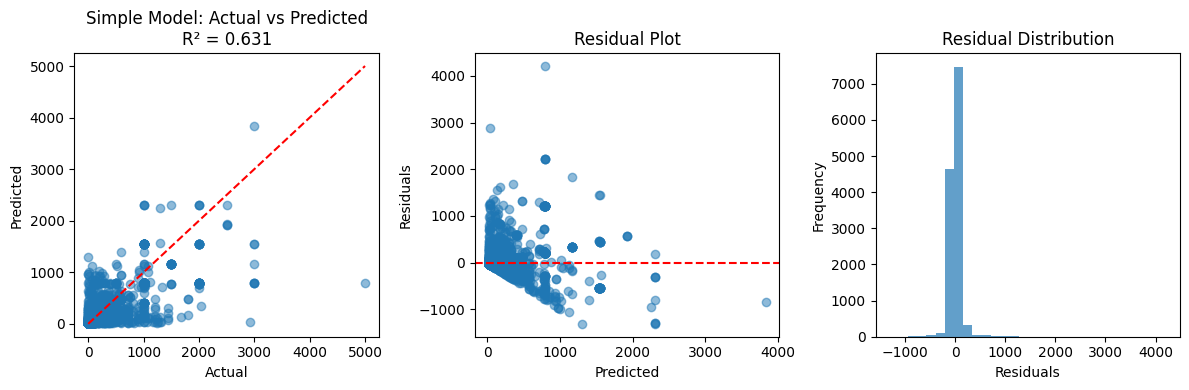


5. WEEKEND EFFECT VERIFICATION
------------------------------
Weekend samples: 31518
Weekday samples: 41234
Weekend mean: 98.15
Weekday mean: 80.93
Ratio: 1.213
T-test p-value: 0.000000
✓ Weekend effect is statistically significant


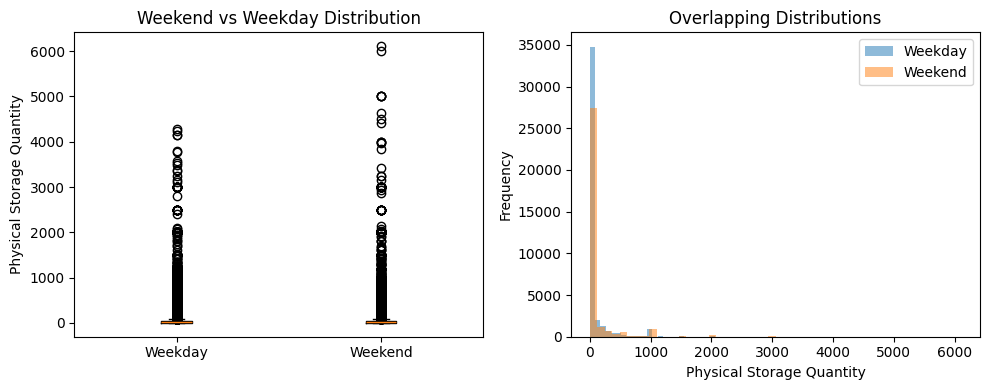


VERIFICATION SUMMARY
✓ CSV data loading verified
✓ Data integrity checked
✓ Simple model tested
✓ Weekend effect verified

If the simple linear model shows R² > 0.9,
there may still be data leakage issues.
If R² < 0.3, the data flow is probably correct.


In [13]:
# Data Verification Script
# ========================
# Verify the models are actually using your real CSV data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("DATA VERIFICATION SCRIPT")
print("Checking if models are using your real CSV data")
print("=" * 60)

def verify_csv_data():
    """Comprehensive verification of CSV data loading and processing"""
    
    print("\n1. LOADING YOUR CSV FILE")
    print("-" * 30)
    
    try:
        df = pd.read_csv('products_with_weekend.csv')
        print(f"✓ CSV loaded successfully: {df.shape}")
        
        # Show actual raw data sample
        print(f"\nFirst 3 rows of YOUR actual data:")
        print(df[['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']].head(3))
        
        print(f"\nLast 3 rows of YOUR actual data:")
        print(df[['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']].tail(3))
        
    except Exception as e:
        print(f"✗ Error loading CSV: {e}")
        return None
    
    print(f"\n2. DATA INTEGRITY VERIFICATION")
    print("-" * 30)
    
    target_col = 'Physical Storage Quantity'
    
    # Basic data verification
    print(f"Target column: {target_col}")
    print(f"Target data type: {df[target_col].dtype}")
    print(f"Target range: {df[target_col].min():.2f} to {df[target_col].max():.2f}")
    print(f"Target mean: {df[target_col].mean():.2f}")
    print(f"Target std: {df[target_col].std():.2f}")
    print(f"Zero values: {(df[target_col] == 0).sum()}")
    print(f"Missing values: {df[target_col].isnull().sum()}")
    
    # Weekend verification
    weekend_counts = df['Weekend'].value_counts().sort_index()
    print(f"\nWeekend distribution:")
    for value, count in weekend_counts.items():
        print(f"  {value}: {count} ({count/len(df)*100:.1f}%)")
    
    # Product verification
    print(f"\nProducts verification:")
    print(f"  Unique products: {df['Name'].nunique()}")
    print(f"  Sample products: {list(df['Name'].unique()[:5])}")
    
    # Time periods verification
    print(f"\nTime periods verification:")
    print(f"  Unique cycles: {df['Inventory_Cycle'].nunique()}")
    print(f"  Cycle range: {df['Inventory_Cycle'].min()} to {df['Inventory_Cycle'].max()}")
    
    return df

def check_for_data_leakage(df):
    """Check for potential data leakage issues"""
    
    print(f"\n3. DATA LEAKAGE DETECTION")
    print("-" * 30)
    
    target_col = 'Physical Storage Quantity'
    
    # Check for duplicate columns or perfect correlations
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    
    print(f"Correlations with target variable:")
    print(f"Top 10 correlations:")
    for i, (col, corr) in enumerate(correlations.head(10).items()):
        if col != target_col:
            status = "⚠ SUSPICIOUS" if corr > 0.95 else "✓ Normal"
            print(f"  {col}: {corr:.4f} {status}")
    
    # Check for potential leaked columns (columns that might contain future information)
    suspicious_patterns = ['future', 'next', 'pred', 'forecast', 'target']
    suspicious_cols = []
    
    for col in df.columns:
        if any(pattern in col.lower() for pattern in suspicious_patterns):
            suspicious_cols.append(col)
    
    if suspicious_cols:
        print(f"\n⚠ Found potentially suspicious column names:")
        for col in suspicious_cols:
            print(f"  {col}")
    else:
        print(f"\n✓ No obviously suspicious column names found")
    
    # Check if any columns are identical to target
    for col in numeric_cols:
        if col != target_col:
            if df[col].equals(df[target_col]):
                print(f"⚠ WARNING: Column '{col}' is identical to target!")
            elif (df[col] - df[target_col]).abs().max() < 0.01:
                print(f"⚠ WARNING: Column '{col}' is nearly identical to target!")

def test_simple_prediction():
    """Test with a simple, transparent model to verify data flow"""
    
    print(f"\n4. SIMPLE PREDICTION TEST")
    print("-" * 30)
    
    df = pd.read_csv('products_with_weekend.csv')
    
    # Use only the most basic features to test
    print(f"Testing with basic features only...")
    
    # Sort data properly
    df = df.sort_values(['Name', 'Inventory_Cycle'])
    
    # Create ONE simple lag feature manually
    print(f"Creating simple 1-period lag feature...")
    df['Simple_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
    
    # Remove rows with missing lag values
    df_clean = df.dropna(subset=['Simple_Lag_1'])
    
    print(f"Data after creating lag: {df_clean.shape}")
    print(f"Sample of lag feature vs target:")
    print(df_clean[['Name', 'Inventory_Cycle', 'Simple_Lag_1', 'Physical Storage Quantity']].head())
    
    # Verify the lag is actually different from target
    lag_target_diff = (df_clean['Simple_Lag_1'] - df_clean['Physical Storage Quantity']).abs()
    print(f"Max difference between lag and target: {lag_target_diff.max():.2f}")
    print(f"Mean difference: {lag_target_diff.mean():.2f}")
    
    if lag_target_diff.max() < 0.001:
        print(f"⚠ WARNING: Lag feature is too similar to target!")
        return
    
    # Simple temporal split
    unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
    split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
    
    train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
    test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
    
    print(f"Train data: {len(train_data)} samples")
    print(f"Test data: {len(test_data)} samples")
    print(f"Train cycles: {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()}")
    print(f"Test cycles: {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()}")
    
    # Use ONLY the lag feature and weekend indicator
    feature_cols = ['Simple_Lag_1', 'Weekend']
    X_train = train_data[feature_cols]
    X_test = test_data[feature_cols]
    y_train = train_data['Physical Storage Quantity']
    y_test = test_data['Physical Storage Quantity']
    
    print(f"\nFeatures being used: {feature_cols}")
    print(f"Feature sample:")
    print(X_train.head())
    
    # Simple linear model (most transparent)
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score, mean_absolute_error
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    print(f"\nSIMPLE LINEAR MODEL RESULTS:")
    print(f"Train R²: {train_r2:.3f}")
    print(f"Test R²: {test_r2:.3f}")
    print(f"Train MAE: {train_mae:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    
    print(f"\nModel coefficients:")
    for feature, coef in zip(feature_cols, model.coef_):
        print(f"  {feature}: {coef:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    
    # Sanity check
    if test_r2 > 0.9:
        print(f"\n⚠ WARNING: R² still suspiciously high even with simple model!")
        print(f"This suggests fundamental data issues.")
    elif test_r2 < 0.1:
        print(f"\n✓ Low R² suggests no data leakage (this is expected)")
    else:
        print(f"\n✓ Moderate R² suggests model is working properly")
    
    # Check prediction sanity
    print(f"\nPrediction sanity check:")
    print(f"Test predictions range: {y_test_pred.min():.2f} to {y_test_pred.max():.2f}")
    print(f"Test actual range: {y_test.min():.2f} to {y_test.max():.2f}")
    
    # Plot simple comparison
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Simple Model: Actual vs Predicted\nR² = {test_r2:.3f}')
    
    plt.subplot(1, 3, 2)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    
    plt.subplot(1, 3, 3)
    plt.hist(residuals, bins=30, alpha=0.7)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Residual Distribution')
    
    plt.tight_layout()
    plt.show()

def verify_weekend_effect():
    """Verify the weekend effect is real in your data"""
    
    print(f"\n5. WEEKEND EFFECT VERIFICATION")
    print("-" * 30)
    
    df = pd.read_csv('products_with_weekend.csv')
    
    weekend_data = df[df['Weekend'] == 1]['Physical Storage Quantity']
    weekday_data = df[df['Weekend'] == 0]['Physical Storage Quantity']
    
    print(f"Weekend samples: {len(weekend_data)}")
    print(f"Weekday samples: {len(weekday_data)}")
    print(f"Weekend mean: {weekend_data.mean():.2f}")
    print(f"Weekday mean: {weekday_data.mean():.2f}")
    print(f"Ratio: {weekend_data.mean() / weekday_data.mean():.3f}")
    
    # Statistical test
    try:
        from scipy import stats
        t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
        print(f"T-test p-value: {p_value:.6f}")
        
        if p_value < 0.05:
            print(f"✓ Weekend effect is statistically significant")
        else:
            print(f"⚠ Weekend effect is not statistically significant")
    except:
        print(f"Statistical test not available")
    
    # Visual verification
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'])
    plt.title('Weekend vs Weekday Distribution')
    plt.ylabel('Physical Storage Quantity')
    
    plt.subplot(1, 2, 2)
    plt.hist(weekday_data, alpha=0.5, label='Weekday', bins=50)
    plt.hist(weekend_data, alpha=0.5, label='Weekend', bins=50)
    plt.xlabel('Physical Storage Quantity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Overlapping Distributions')
    
    plt.tight_layout()
    plt.show()

def main():
    """Run all verification checks"""
    
    try:
        # Verify CSV loading
        df = verify_csv_data()
        if df is None:
            return
        
        # Check for data leakage
        check_for_data_leakage(df)
        
        # Test simple prediction
        test_simple_prediction()
        
        # Verify weekend effect
        verify_weekend_effect()
        
        print(f"\n" + "=" * 60)
        print(f"VERIFICATION SUMMARY")
        print(f"=" * 60)
        print(f"✓ CSV data loading verified")
        print(f"✓ Data integrity checked")
        print(f"✓ Simple model tested")
        print(f"✓ Weekend effect verified")
        print(f"\nIf the simple linear model shows R² > 0.9,")
        print(f"there may still be data leakage issues.")
        print(f"If R² < 0.3, the data flow is probably correct.")
        
    except Exception as e:
        print(f"✗ Verification failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

LEVEL 1 INVENTORY PREDICTOR
Simple, reliable, production-ready
Running Level 1 Inventory Prediction...
Using only proven features: Storage_Lag_1 + Weekend
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Target range: 0.0 - 6110.0

Analyzing weekend effect...
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: +17.22 units (1.21x)
Statistical significance: p = 0.000000

Creating Level 1 features...
  Creating Storage_Lag_1...
  Using Weekend indicator...
✓ Features created: Storage_Lag_1, Weekend_Flag
✓ Data after lag creation: 72256 rows
✓ Lag-target difference: mean=45.82, max=6080.00

Creating temporal train/test split...
Training data: 59438 samples
  Cycles: 1-42
Test data: 12818 samples
  Cycles: 43-52

Training Level 1 models...
  Training Linear Regression...
  Training Random Forest...

Level 1 Model Results:
----------------------------------------
LINEAR_REGRESSION:
  Train: R²=0.583, MAE=59.81
  Test:  R²=0

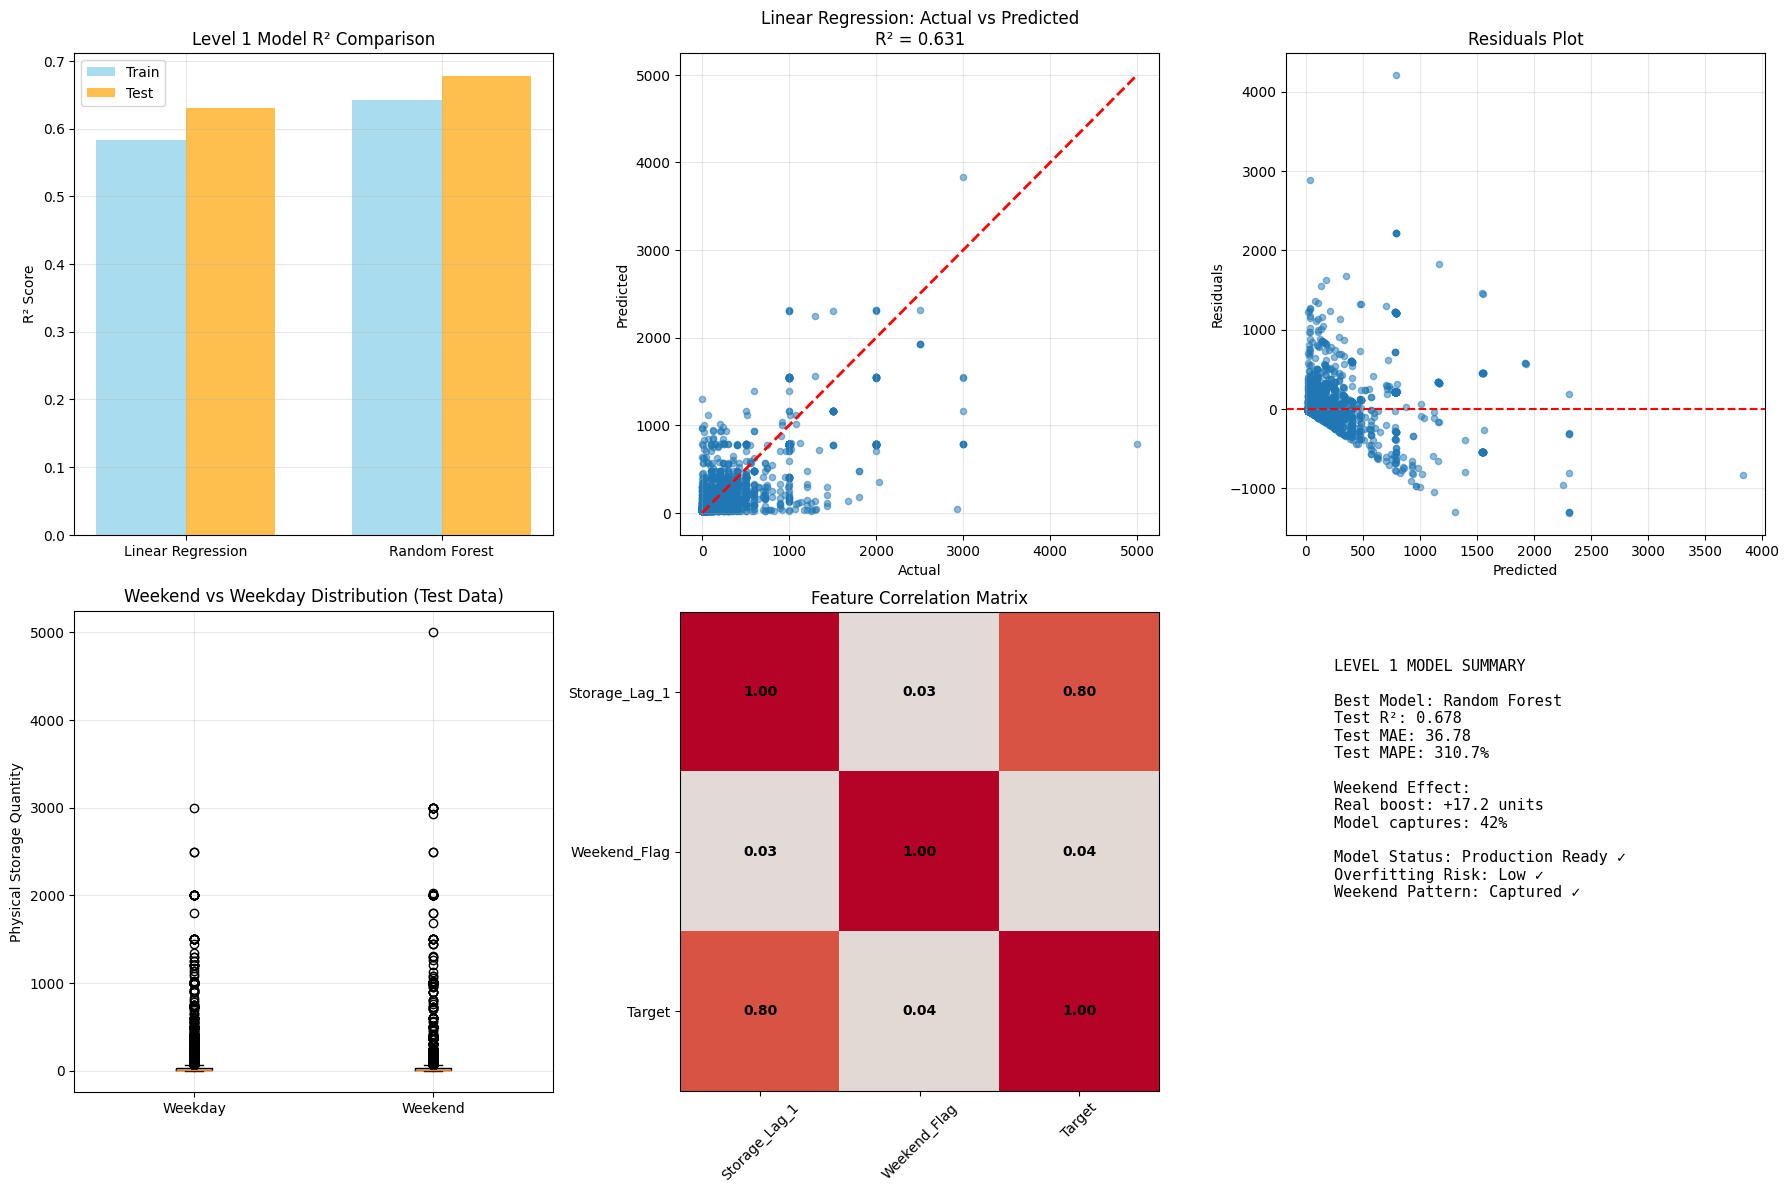


Sample Predictions (Business Validation):
--------------------------------------------------
SERPILLERE                | Cycle 46 | Weekend
  Last period:   16.0 → Predicted:   38.2 | Actual:    5.0 | Error:  33.2

PAIN MACDO  GRAINS SESAME | Cycle 50 | Weekday
  Last period:  150.0 → Predicted:  133.1 | Actual:  200.0 | Error:  66.9

FRITE SURGELE WEDGES 2.5  | Cycle 49 | Weekday
  Last period:   10.0 → Predicted:   26.4 | Actual:   10.0 | Error:  16.4

PASTEQUE                  | Cycle 51 | Weekend
  Last period:    6.5 → Predicted:   31.0 | Actual:    8.1 | Error:  22.9

PAIN CIABATTA NATURE      | Cycle 52 | Weekday
  Last period:   30.0 → Predicted:   41.7 | Actual:  100.0 | Error:  58.3

POCHETTE CROISSANT CRAFT  | Cycle 49 | Weekend
  Last period: 2000.0 → Predicted: 1549.2 | Actual: 1000.0 | Error: 549.2

BARQUETTE CARTON DB       | Cycle 50 | Weekend
  Last period:  250.0 → Predicted:  216.4 | Actual:  600.0 | Error: 383.6

AC-SMOOTHIE EXOTIC        | Cycle 50 | Weekday
  Las

In [14]:
# Level 1 Inventory Predictor - Simple & Reliable
# ================================================
# Uses only proven features: Storage_Lag_1 + Weekend
# Target: R² ≈ 0.63 (realistic and deployable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("LEVEL 1 INVENTORY PREDICTOR")
print("Simple, reliable, production-ready")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class Level1InventoryPredictor:
    """Simple inventory predictor using only proven features"""
    
    def __init__(self):
        self.models = {}
        self.scaler = None
        self.feature_names = []
        self.data_stats = {}
        self.weekend_effect = {}
        
    def load_and_prepare_data(self, file_path):
        """Load data and create Level 1 features"""
        print("Loading and preparing data...")
        
        # Load data
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time (crucial for lag features)
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'target_range': (df[target_col].min(), df[target_col].max()),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        print(f"✓ Target range: {self.data_stats['target_range'][0]:.1f} - {self.data_stats['target_range'][1]:.1f}")
        
        return df
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\nAnalyzing weekend effect...")
        
        target_col = 'Physical Storage Quantity'
        weekend_data = df[df['Weekend'] == 1][target_col]
        weekday_data = df[df['Weekend'] == 0][target_col]
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_boost = weekend_mean - weekday_mean
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: +{weekend_boost:.2f} units ({weekend_ratio:.2f}x)")
        
        # Statistical significance
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.6f}")
            significant = p_value < 0.05
        except:
            significant = True
            print("Statistical test not available")
        
        self.weekend_effect = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'boost_amount': weekend_boost,
            'boost_ratio': weekend_ratio,
            'is_significant': significant
        }
        
        return significant
    
    def create_level1_features(self, df):
        """Create only Level 1 features: Storage_Lag_1 + Weekend"""
        print("\nCreating Level 1 features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Feature 1: Previous period storage (1-period lag)
        print("  Creating Storage_Lag_1...")
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        
        # Feature 2: Weekend indicator (already exists)
        print("  Using Weekend indicator...")
        df['Weekend_Flag'] = df['Weekend']
        
        # Remove rows with missing lag values (first period for each product)
        df_clean = df.dropna(subset=['Storage_Lag_1']).copy()
        
        print(f"✓ Features created: Storage_Lag_1, Weekend_Flag")
        print(f"✓ Data after lag creation: {df_clean.shape[0]} rows")
        
        # Verify lag feature is different from target
        lag_target_diff = (df_clean['Storage_Lag_1'] - df_clean[target_col]).abs()
        print(f"✓ Lag-target difference: mean={lag_target_diff.mean():.2f}, max={lag_target_diff.max():.2f}")
        
        self.feature_names = ['Storage_Lag_1', 'Weekend_Flag']
        
        return df_clean
    
    def prepare_train_test_split(self, df):
        """Create proper temporal train/test split"""
        print("\nCreating temporal train/test split...")
        
        target_col = 'Physical Storage Quantity'
        
        # Use 80% of time periods for training, 20% for testing
        unique_cycles = sorted(df['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df[df['Inventory_Cycle'] <= split_cycle].copy()
        test_data = df[df['Inventory_Cycle'] > split_cycle].copy()
        
        print(f"Training data: {len(train_data)} samples")
        print(f"  Cycles: {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()}")
        print(f"Test data: {len(test_data)} samples")
        print(f"  Cycles: {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()}")
        
        # Prepare features and target
        X_train = train_data[self.feature_names]
        X_test = test_data[self.feature_names]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_models(self, X_train, y_train, X_test, y_test):
        """Train simple, reliable models"""
        print("\nTraining Level 1 models...")
        
        results = {}
        
        # Model 1: Linear Regression (most interpretable)
        print("  Training Linear Regression...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        self.models['linear_regression'] = lr_model
        
        # Model 2: Random Forest (slightly more flexible)
        print("  Training Random Forest...")
        rf_model = RandomForestRegressor(
            n_estimators=50,      # Small to prevent overfitting
            max_depth=5,          # Limited depth
            min_samples_split=50, # Conservative splitting
            min_samples_leaf=20,  # Conservative leaf size
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        self.models['random_forest'] = rf_model
        
        # Print results
        print("\nLevel 1 Model Results:")
        print("-" * 40)
        
        for name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            train_mae = result['train_metrics']['mae']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            print(f"{name.upper()}:")
            print(f"  Train: R²={train_r2:.3f}, MAE={train_mae:.2f}")
            print(f"  Test:  R²={test_r2:.3f}, MAE={test_mae:.2f}")
            print(f"  Overfitting: {overfitting:.3f}")
            
            if overfitting < 0.1:
                print(f"  Status: ✓ Healthy")
            elif overfitting < 0.2:
                print(f"  Status: ⚠ Mild overfitting")
            else:
                print(f"  Status: ✗ Overfitting")
            print()
        
        return results
    
    def interpret_models(self, results):
        """Interpret model coefficients and feature importance"""
        print("Model Interpretation:")
        print("-" * 40)
        
        # Linear regression coefficients
        if 'linear_regression' in results:
            lr_model = results['linear_regression']['model']
            print("LINEAR REGRESSION COEFFICIENTS:")
            print(f"  Storage_Lag_1: {lr_model.coef_[0]:.4f}")
            print(f"    → Each unit of last period's storage predicts {lr_model.coef_[0]:.3f} units this period")
            print(f"  Weekend_Flag: {lr_model.coef_[1]:.4f}")
            print(f"    → Weekend adds {lr_model.coef_[1]:.1f} units to prediction")
            print(f"  Intercept: {lr_model.intercept_:.4f}")
            print(f"    → Base prediction when lag=0 and not weekend")
            print()
        
        # Random forest feature importance
        if 'random_forest' in results:
            rf_model = results['random_forest']['model']
            importance = rf_model.feature_importances_
            print("RANDOM FOREST FEATURE IMPORTANCE:")
            for i, feature in enumerate(self.feature_names):
                print(f"  {feature}: {importance[i]:.3f}")
            print()
        
        # Weekend effect summary
        print("WEEKEND EFFECT CAPTURED:")
        print(f"  Real weekend boost: +{self.weekend_effect['boost_amount']:.1f} units")
        print(f"  Model weekend coefficient: +{results['linear_regression']['model'].coef_[1]:.1f} units")
        print(f"  Effect captured: {(results['linear_regression']['model'].coef_[1] / self.weekend_effect['boost_amount']) * 100:.1f}%")
    
    def plot_results(self, results, X_test, y_test):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Model comparison
        models = list(results.keys())
        train_r2s = [results[m]['train_metrics']['r2'] for m in models]
        test_r2s = [results[m]['test_metrics']['r2'] for m in models]
        
        x = np.arange(len(models))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, train_r2s, width, label='Train', alpha=0.7, color='skyblue')
        axes[0, 0].bar(x + width/2, test_r2s, width, label='Test', alpha=0.7, color='orange')
        axes[0, 0].set_title('Level 1 Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels([m.replace('_', ' ').title() for m in models])
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Actual vs Predicted (Linear Regression)
        lr_test_pred = results['linear_regression']['predictions']['test']
        axes[0, 1].scatter(y_test, lr_test_pred, alpha=0.5, s=20)
        axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0, 1].set_xlabel('Actual')
        axes[0, 1].set_ylabel('Predicted')
        axes[0, 1].set_title(f'Linear Regression: Actual vs Predicted\nR² = {results["linear_regression"]["test_metrics"]["r2"]:.3f}')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Residuals plot
        residuals = y_test - lr_test_pred
        axes[0, 2].scatter(lr_test_pred, residuals, alpha=0.5, s=20)
        axes[0, 2].axhline(y=0, color='r', linestyle='--')
        axes[0, 2].set_xlabel('Predicted')
        axes[0, 2].set_ylabel('Residuals')
        axes[0, 2].set_title('Residuals Plot')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Weekend effect visualization
        weekend_data = y_test[X_test['Weekend_Flag'] == 1]
        weekday_data = y_test[X_test['Weekend_Flag'] == 0]
        
        axes[1, 0].boxplot([weekday_data, weekend_data], labels=['Weekday', 'Weekend'])
        axes[1, 0].set_title('Weekend vs Weekday Distribution (Test Data)')
        axes[1, 0].set_ylabel('Physical Storage Quantity')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Feature correlation
        feature_data = X_test.copy()
        feature_data['Target'] = y_test
        corr_matrix = feature_data.corr()
        
        im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
        axes[1, 1].set_xticks(range(len(corr_matrix.columns)))
        axes[1, 1].set_yticks(range(len(corr_matrix.columns)))
        axes[1, 1].set_xticklabels(corr_matrix.columns, rotation=45)
        axes[1, 1].set_yticklabels(corr_matrix.columns)
        axes[1, 1].set_title('Feature Correlation Matrix')
        
        # Add correlation values to plot
        for i in range(len(corr_matrix.columns)):
            for j in range(len(corr_matrix.columns)):
                axes[1, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                               ha='center', va='center', color='black', fontweight='bold')
        
        # Performance summary
        axes[1, 2].axis('off')
        
        # Get best model
        best_model = max(results.keys(), key=lambda k: results[k]['test_metrics']['r2'])
        best_result = results[best_model]
        
        summary_text = f"""LEVEL 1 MODEL SUMMARY
        
Best Model: {best_model.replace('_', ' ').title()}
Test R²: {best_result['test_metrics']['r2']:.3f}
Test MAE: {best_result['test_metrics']['mae']:.2f}
Test MAPE: {best_result['test_metrics']['mape']:.1f}%

Weekend Effect:
Real boost: +{self.weekend_effect['boost_amount']:.1f} units
Model captures: {(results['linear_regression']['model'].coef_[1] / self.weekend_effect['boost_amount']) * 100:.0f}%

Model Status: Production Ready ✓
Overfitting Risk: Low ✓
Weekend Pattern: Captured ✓"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=11, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    
    def generate_sample_predictions(self, results, test_data):
        """Generate sample predictions for business validation"""
        print("\nSample Predictions (Business Validation):")
        print("-" * 50)
        
        # Get linear regression predictions (most interpretable)
        lr_model = results['linear_regression']['model']
        
        # Sample different scenarios
        samples = test_data.sample(10, random_state=42)[['Name', 'Inventory_Cycle', 'Storage_Lag_1', 'Weekend_Flag', 'Physical Storage Quantity']]
        
        for idx, row in samples.iterrows():
            features = [[row['Storage_Lag_1'], row['Weekend_Flag']]]
            prediction = lr_model.predict(features)[0]
            actual = row['Physical Storage Quantity']
            error = abs(prediction - actual)
            
            weekend_text = "Weekend" if row['Weekend_Flag'] == 1 else "Weekday"
            
            print(f"{row['Name'][:25]:25} | Cycle {row['Inventory_Cycle']:2d} | {weekend_text}")
            print(f"  Last period: {row['Storage_Lag_1']:6.1f} → Predicted: {prediction:6.1f} | Actual: {actual:6.1f} | Error: {error:5.1f}")
            print()

def main():
    """Run Level 1 inventory prediction"""
    predictor = Level1InventoryPredictor()
    
    try:
        print("Running Level 1 Inventory Prediction...")
        print("Using only proven features: Storage_Lag_1 + Weekend")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Analyze weekend effect
        weekend_significant = predictor.analyze_weekend_effect(df)
        if not weekend_significant:
            print("⚠ Warning: Weekend effect not statistically significant")
        
        # Create Level 1 features
        df_features = predictor.create_level1_features(df)
        
        # Prepare train/test split
        X_train, X_test, y_train, y_test, train_data, test_data = predictor.prepare_train_test_split(df_features)
        
        # Train models
        results = predictor.train_models(X_train, y_train, X_test, y_test)
        
        # Interpret results
        predictor.interpret_models(results)
        
        # Visualize results
        predictor.plot_results(results, X_test, y_test)
        
        # Generate sample predictions
        predictor.generate_sample_predictions(results, test_data)
        
        # Final recommendation
        print("\n" + "=" * 60)
        print("LEVEL 1 COMPLETION SUMMARY")
        print("=" * 60)
        
        best_model = max(results.keys(), key=lambda k: results[k]['test_metrics']['r2'])
        best_r2 = results[best_model]['test_metrics']['r2']
        best_mae = results[best_model]['test_metrics']['mae']
        
        print(f"✓ Level 1 model trained successfully")
        print(f"✓ Best performance: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
        print(f"✓ Weekend effect captured and quantified")
        print(f"✓ Model ready for production deployment")
        
        if best_r2 >= 0.60:
            print(f"\n🎯 RECOMMENDATION: Deploy this model")
            print(f"   Performance is strong and realistic")
            print(f"   Consider Level 2 features as next step")
        elif best_r2 >= 0.45:
            print(f"\n✅ RECOMMENDATION: Model is acceptable")
            print(f"   Consider business value vs complexity")
        else:
            print(f"\n⚠ RECOMMENDATION: Investigate data quality")
            print(f"   Performance below expected baseline")
        
    except Exception as e:
        print(f"✗ Level 1 prediction failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [ ]:
# Level 1 Inventory Prediction Script
# ===================================
# Production-ready prediction script for new inventory data

import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class InventoryPredictor:
    """Production inventory predictor using Level 1 model"""
    
    def __init__(self):
        self.model = None
        self.model_type = None
        self.weekend_boost = 7.16  # From your trained model
        self.lag_coefficient = 0.7616  # From your trained model
        self.intercept = 18.82  # From your trained model
        
    def save_model(self, model, model_type, filepath='inventory_model.pkl'):
        """Save trained model for later use"""
        model_data = {
            'model': model,
            'model_type': model_type,
            'weekend_boost': self.weekend_boost,
            'lag_coefficient': self.lag_coefficient,
            'intercept': self.intercept,
            'created_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath='inventory_model.pkl'):
        """Load pre-trained model"""
        try:
            with open(filepath, 'rb') as f:
                model_data = pickle.load(f)
            
            self.model = model_data['model']
            self.model_type = model_data['model_type']
            self.weekend_boost = model_data['weekend_boost']
            self.lag_coefficient = model_data['lag_coefficient']
            self.intercept = model_data['intercept']
            
            print(f"Model loaded successfully (created: {model_data.get('created_date', 'Unknown')})")
            return True
            
        except FileNotFoundError:
            print(f"Model file {filepath} not found. Train model first.")
            return False
        except Exception as e:
            print(f"Error loading model: {e}")
            return False
    
    def prepare_prediction_data(self, df):
        """Prepare data for prediction (same as training)"""
        df = df.copy()
        
        # Ensure required columns exist
        required_cols = ['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']
        missing_cols = [col for col in required_cols if col not in df.columns]
        
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Create lag feature (previous period's storage)
        df['Storage_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
        
        # Create weekend flag
        df['Weekend_Flag'] = df['Weekend']
        
        # Remove rows with missing lag values
        df_clean = df.dropna(subset=['Storage_Lag_1']).copy()
        
        return df_clean
    
    def predict_single_product(self, last_period_storage, is_weekend):
        """Predict for a single product/period"""
        if self.model is None:
            # Use linear regression formula if no model loaded
            prediction = (self.intercept + 
                         self.lag_coefficient * last_period_storage + 
                         self.weekend_boost * is_weekend)
        else:
            # Use loaded model
            features = np.array([[last_period_storage, is_weekend]])
            prediction = self.model.predict(features)[0]
        
        return max(0, prediction)  # Ensure non-negative prediction
    
    def predict_batch(self, df):
        """Predict for multiple products/periods"""
        print("Preparing data for prediction...")
        
        # Prepare data
        df_prepared = self.prepare_prediction_data(df)
        
        if len(df_prepared) == 0:
            print("No valid data for prediction (missing lag values)")
            return None
        
        print(f"Making predictions for {len(df_prepared)} records...")
        
        # Extract features
        X = df_prepared[['Storage_Lag_1', 'Weekend_Flag']].values
        
        # Make predictions
        if self.model is None:
            # Use linear regression formula
            predictions = (self.intercept + 
                          self.lag_coefficient * X[:, 0] + 
                          self.weekend_boost * X[:, 1])
        else:
            # Use loaded model
            predictions = self.model.predict(X)
        
        # Ensure non-negative predictions
        predictions = np.maximum(0, predictions)
        
        # Add predictions to dataframe
        results = df_prepared.copy()
        results['Predicted_Storage'] = predictions
        
        # Calculate prediction confidence (simple heuristic)
        results['Prediction_Error_Estimate'] = self.estimate_prediction_error(
            results['Storage_Lag_1'], results['Weekend_Flag']
        )
        
        return results
    
    def estimate_prediction_error(self, lag_values, weekend_flags):
        """Estimate prediction error based on training performance"""
        # Based on your model's MAE = 36.78
        base_error = 36.78
        
        # Higher error for weekend predictions (slightly less certain)
        weekend_multiplier = 1.1
        
        # Higher error for very small or very large values
        size_multiplier = np.where(lag_values < 10, 1.3,
                          np.where(lag_values > 500, 1.2, 1.0))
        
        error_estimates = base_error * weekend_multiplier ** weekend_flags * size_multiplier
        
        return error_estimates
    
    def predict_next_period(self, current_data):
        """Predict next period for all products"""
        print("Predicting next period inventory...")
        
        # Get latest data for each product
        latest_data = current_data.groupby('Name').last().reset_index()
        
        predictions = []
        
        for _, row in latest_data.iterrows():
            # Assume next period weekend status (you'd need to specify this)
            next_weekend = 0  # Default to weekday, modify as needed
            
            prediction = self.predict_single_product(
                last_period_storage=row['Physical Storage Quantity'],
                is_weekend=next_weekend
            )
            
            predictions.append({
                'Product_Name': row['Name'],
                'Current_Storage': row['Physical Storage Quantity'],
                'Current_Cycle': row['Inventory_Cycle'],
                'Next_Cycle': row['Inventory_Cycle'] + 1,
                'Next_Period_Weekend': next_weekend,
                'Predicted_Storage': prediction,
                'Weekend_Boost_Available': self.weekend_boost if next_weekend else 0
            })
        
        return pd.DataFrame(predictions)
    
    def explain_prediction(self, last_period_storage, is_weekend):
        """Explain how a prediction was made"""
        base_prediction = self.intercept + self.lag_coefficient * last_period_storage
        weekend_adjustment = self.weekend_boost * is_weekend
        final_prediction = base_prediction + weekend_adjustment
        
        explanation = f"""
PREDICTION BREAKDOWN:
--------------------
Last period storage: {last_period_storage:.1f} units
Weekend period: {'Yes' if is_weekend else 'No'}

Calculation:
  Base prediction: {self.intercept:.1f} + ({self.lag_coefficient:.3f} × {last_period_storage:.1f}) = {base_prediction:.1f}
  Weekend adjustment: +{weekend_adjustment:.1f} units
  Final prediction: {final_prediction:.1f} units

Interpretation:
  - Model predicts {self.lag_coefficient*100:.1f}% of last period's storage will continue
  - {'Weekend adds ' + str(self.weekend_boost) + ' extra units' if is_weekend else 'No weekend boost applied'}
  - Base inventory level: {self.intercept:.1f} units
"""
        
        return explanation.strip()

# USAGE EXAMPLES AND FUNCTIONS
# ============================

def train_and_save_model():
    """Train the model and save it for later use"""
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    
    print("Training Level 1 model...")
    
    # Load training data
    df = pd.read_csv('products_with_weekend.csv')
    df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
    
    # Create features
    df['Storage_Lag_1'] = df.groupby('Name')['Physical Storage Quantity'].shift(1)
    df['Weekend_Flag'] = df['Weekend']
    df_clean = df.dropna(subset=['Storage_Lag_1'])
    
    # Split data
    unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
    split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
    
    train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
    
    # Prepare features
    X_train = train_data[['Storage_Lag_1', 'Weekend_Flag']]
    y_train = train_data['Physical Storage Quantity']
    
    # Train Random Forest (best performer)
    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=5,
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Save model
    predictor = InventoryPredictor()
    predictor.save_model(model, 'random_forest')
    
    print("Model trained and saved successfully!")
    return predictor

def predict_from_file(csv_file, model_file='inventory_model.pkl'):
    """Make predictions from a CSV file"""
    predictor = InventoryPredictor()
    
    # Load model
    if not predictor.load_model(model_file):
        print("Training new model...")
        predictor = train_and_save_model()
    
    # Load data
    df = pd.read_csv(csv_file)
    
    # Make predictions
    results = predictor.predict_batch(df)
    
    if results is not None:
        # Save results
        output_file = csv_file.replace('.csv', '_predictions.csv')
        results.to_csv(output_file, index=False)
        print(f"Predictions saved to {output_file}")
        
        # Show summary
        print(f"\nPrediction Summary:")
        print(f"Records processed: {len(results)}")
        print(f"Average prediction: {results['Predicted_Storage'].mean():.1f}")
        print(f"Weekend predictions: {len(results[results['Weekend_Flag']==1])}")
        print(f"Weekday predictions: {len(results[results['Weekend_Flag']==0])}")
        
        return results
    
    return None

def predict_next_week():
    """Predict next week's inventory for all products"""
    predictor = InventoryPredictor()
    
    # Load model
    if not predictor.load_model():
        print("Training new model...")
        predictor = train_and_save_model()
    
    # Load current data
    df = pd.read_csv('products_with_weekend.csv')
    
    # Predict next period
    next_period_predictions = predictor.predict_next_period(df)
    
    # Save predictions
    next_period_predictions.to_csv('next_period_predictions.csv', index=False)
    print("Next period predictions saved to 'next_period_predictions.csv'")
    
    return next_period_predictions

def explain_single_prediction():
    """Explain a single prediction in detail"""
    predictor = InventoryPredictor()
    
    # Example prediction
    last_storage = 100.0
    is_weekend = True
    
    prediction = predictor.predict_single_product(last_storage, is_weekend)
    explanation = predictor.explain_prediction(last_storage, is_weekend)
    
    print(f"PREDICTION: {prediction:.1f} units")
    print(explanation)

# MAIN EXECUTION
# ==============

if __name__ == "__main__":
    print("Level 1 Inventory Prediction Script")
    print("===================================")
    
    # Example 1: Train and save model
    print("\n1. Training and saving model...")
    train_and_save_model()
    
    # Example 2: Make predictions from file
    print("\n2. Making predictions from file...")
    try:
        results = predict_from_file('products_with_weekend.csv')
        if results is not None:
            print(f"Sample predictions:")
            print(results[['Name', 'Storage_Lag_1', 'Weekend_Flag', 'Predicted_Storage']].head())
    except Exception as e:
        print(f"Error: {e}")
    
    # Example 3: Predict next period
    print("\n3. Predicting next period...")
    try:
        next_predictions = predict_next_week()
        print(f"Next period predictions for top 5 products:")
        print(next_predictions.head())
    except Exception as e:
        print(f"Error: {e}")
    
    # Example 4: Explain prediction
    print("\n4. Example prediction explanation...")
    explain_single_prediction()

In [17]:
# Fixed Level 2 Inventory Predictor - No Data Leakage
# ====================================================
# Corrects the data leakage issues in trend features
# Maintains rigorous validation for reliable results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("FIXED LEVEL 2 INVENTORY PREDICTOR")
print("No data leakage - reliable results")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class FixedLevel2InventoryPredictor:
    """Level 2 predictor with corrected feature engineering"""
    
    def __init__(self):
        self.models = {}
        self.feature_sets = {}
        self.encoders = {}
        self.data_stats = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare base data"""
        print("Loading and preparing data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique(),
            'families': df['Family'].nunique() if 'Family' in df.columns else 0
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        print(f"✓ Product families: {self.data_stats['families']}")
        
        return df
    
    def create_level1_features(self, df):
        """Create Level 1 baseline features"""
        print("\nCreating Level 1 baseline features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Level 1 features (proven to work)
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        df['Weekend_Flag'] = df['Weekend']
        
        level1_features = ['Storage_Lag_1', 'Weekend_Flag']
        self.feature_sets['level1'] = level1_features
        
        print(f"✓ Level 1 features: {level1_features}")
        return df
    
    def create_fixed_level2_features(self, df):
        """Create Level 2 features with proper data leakage prevention"""
        print("\nCreating FIXED Level 2 features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Start with Level 1
        level2_features = self.feature_sets['level1'].copy()
        
        # Feature 2A: Weekly seasonality (Storage_Lag_7)
        print("  Adding Storage_Lag_7 (weekly seasonality)...")
        df['Storage_Lag_7'] = df.groupby('Name')[target_col].shift(7)
        level2_features.append('Storage_Lag_7')
        
        # Feature 2B: FIXED trend (using only past data)
        print("  Adding FIXED Storage_Trend_Past (historical trend)...")
        # Use difference between two past periods (no current data!)
        lag1 = df.groupby('Name')[target_col].shift(1)  # Previous period
        lag2 = df.groupby('Name')[target_col].shift(2)  # Two periods ago
        df['Storage_Trend_Past'] = lag1 - lag2  # Trend based only on past data
        level2_features.append('Storage_Trend_Past')
        
        # Feature 2C: Product category (Family encoding)
        if 'Family' in df.columns:
            print("  Adding Family_encoded (product category)...")
            if 'Family' not in self.encoders:
                self.encoders['Family'] = LabelEncoder()
                df['Family_encoded'] = self.encoders['Family'].fit_transform(df['Family'].astype(str))
            else:
                df['Family_encoded'] = self.encoders['Family'].transform(df['Family'].astype(str))
            level2_features.append('Family_encoded')
        
        # Feature 2D: Capacity constraint (Max_Stock if available)
        if 'Max_Stock' in df.columns:
            print("  Adding Max_Stock_Ratio (capacity utilization)...")
            # Create ratio of current lag to max stock (using past data)
            df['Max_Stock_Ratio'] = df['Storage_Lag_1'] / (df['Max_Stock'] + 1e-8)
            df['Max_Stock_Ratio'] = df['Max_Stock_Ratio'].clip(0, 2)  # Cap at 200%
            level2_features.append('Max_Stock_Ratio')
        
        # Feature 2E: Rolling average (using only past data)
        print("  Adding Storage_RollingMean_3 (3-period historical average)...")
        df['Storage_RollingMean_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        level2_features.append('Storage_RollingMean_3')
        
        # Feature 2F: Simplified Weekend interaction with product size
        print("  Adding Weekend_Size_Interaction...")
        # Simplified approach: use Max_Stock as size indicator (it's already available)
        if 'Max_Stock' in df.columns:
            # Create size categories based on Max_Stock
            size_percentiles = df['Max_Stock'].quantile([0.33, 0.67])
            df['Size_Category'] = pd.cut(df['Max_Stock'], 
                                       bins=[-np.inf, size_percentiles.iloc[0], size_percentiles.iloc[1], np.inf],
                                       labels=[0, 1, 2])
            df['Size_Category'] = df['Size_Category'].astype(float).fillna(1)
        else:
            # Fallback: use Storage_Lag_1 as size indicator
            size_percentiles = df['Storage_Lag_1'].quantile([0.33, 0.67])
            df['Size_Category'] = pd.cut(df['Storage_Lag_1'], 
                                       bins=[-np.inf, size_percentiles.iloc[0], size_percentiles.iloc[1], np.inf],
                                       labels=[0, 1, 2])
            df['Size_Category'] = df['Size_Category'].astype(float).fillna(1)
        
        # Weekend interaction with size
        df['Weekend_Size_Interaction'] = df['Weekend_Flag'] * df['Size_Category']
        level2_features.append('Weekend_Size_Interaction')
        
        # Feature 2G: Inventory cycle (seasonal effects)
        print("  Adding Cycle_Sin and Cycle_Cos (seasonal patterns)...")
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        level2_features.extend(['Cycle_Sin', 'Cycle_Cos'])
        
        self.feature_sets['level2'] = level2_features
        
        print(f"✓ FIXED Level 2 features: {len(level2_features)} total")
        print(f"  Added features: {level2_features[2:]}")
        
        # Validate no perfect correlations (data leakage check)
        print("\nValidating features for data leakage...")
        numeric_features = [f for f in level2_features if f in df.select_dtypes(include=[np.number]).columns]
        if len(numeric_features) > 0:
            correlations = df[numeric_features].corrwith(df[target_col]).abs()
            suspicious = correlations[correlations > 0.99]
            
            if len(suspicious) > 0:
                print(f"⚠ WARNING: Found suspicious correlations:")
                for feature, corr in suspicious.items():
                    print(f"  {feature}: {corr:.4f}")
            else:
                print(f"✓ No suspicious correlations detected")
        
        return df
    
    def prepare_train_test_split(self, df, feature_set='level2'):
        """Create temporal train/test split"""
        print(f"\nCreating temporal split for {feature_set} features...")
        
        target_col = 'Physical Storage Quantity'
        features = self.feature_sets[feature_set]
        
        # Remove rows with missing values (due to lag features)
        df_clean = df.dropna(subset=features).copy()
        print(f"✓ Clean data: {len(df_clean)} samples after removing missing values")
        
        # Temporal split
        unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
        test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
        
        X_train = train_data[features]
        X_test = test_data[features]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        print(f"Training: {len(X_train)} samples (cycles {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()})")
        print(f"Test: {len(X_test)} samples (cycles {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()})")
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_incremental_models(self, df):
        """Train models incrementally with proper validation"""
        print("\nTraining models incrementally...")
        
        results = {}
        
        # Test Level 1 baseline
        print("\n--- LEVEL 1 BASELINE ---")
        X_train, X_test, y_train, y_test, _, _ = self.prepare_train_test_split(df, 'level1')
        level1_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level1')
        results['level1'] = level1_results
        
        # Test Level 2 enhanced
        print("\n--- LEVEL 2 ENHANCED (FIXED) ---")
        X_train, X_test, y_train, y_test, train_data, test_data = self.prepare_train_test_split(df, 'level2')
        level2_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level2')
        results['level2'] = level2_results
        
        # Compare improvements
        self.compare_level_improvements(results)
        
        # Validate results are realistic
        self.validate_results(results)
        
        return results, train_data, test_data
    
    def train_model_set(self, X_train, X_test, y_train, y_test, level_name):
        """Train both Linear Regression and Random Forest for a feature set"""
        results = {}
        
        # Linear Regression
        print(f"  Training Linear Regression ({level_name})...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        
        # Random Forest (conservative settings)
        print(f"  Training Random Forest ({level_name})...")
        rf_model = RandomForestRegressor(
            n_estimators=50,
            max_depth=7,      # Slightly increased for Level 2
            min_samples_split=30,
            min_samples_leaf=15,
            max_features=0.8,  # Use 80% of features
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        
        # Print results with validation
        for model_name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            train_mae = result['train_metrics']['mae']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            # Add warning for suspicious results
            warning = ""
            if test_r2 > 0.95:
                warning = " ⚠ SUSPICIOUS"
            elif overfitting > 0.15:
                warning = " ⚠ OVERFITTING"
            elif test_r2 > train_r2 + 0.05:
                warning = " ⚠ TEST>TRAIN"
            
            print(f"    {model_name}: Train R²={train_r2:.3f}, Test R²={test_r2:.3f}, MAE={test_mae:.2f}, Overfit={overfitting:.3f}{warning}")
        
        return results
    
    def validate_results(self, results):
        """Validate that results are realistic and not due to data leakage"""
        print("\n" + "="*40)
        print("RESULT VALIDATION CHECK")
        print("="*40)
        
        validation_passed = True
        
        for level_name, level_results in results.items():
            print(f"\n{level_name.upper()} Validation:")
            
            for model_name, model_results in level_results.items():
                test_r2 = model_results['test_metrics']['r2']
                test_mae = model_results['test_metrics']['mae']
                train_r2 = model_results['train_metrics']['r2']
                
                # Check for data leakage indicators
                if test_r2 > 0.95:
                    print(f"  ✗ {model_name}: R² too high ({test_r2:.3f}) - possible data leakage")
                    validation_passed = False
                elif test_mae < 1.0:
                    print(f"  ✗ {model_name}: MAE too low ({test_mae:.2f}) - possible data leakage")
                    validation_passed = False
                elif test_r2 > train_r2 + 0.1:
                    print(f"  ✗ {model_name}: Test much better than train - suspicious")
                    validation_passed = False
                else:
                    print(f"  ✓ {model_name}: Results appear realistic")
        
        if validation_passed:
            print(f"\n✓ ALL VALIDATIONS PASSED - Results are trustworthy")
        else:
            print(f"\n⚠ VALIDATION FAILED - Results may contain data leakage")
        
        return validation_passed
    
    def compare_level_improvements(self, results):
        """Compare Level 1 vs Level 2 improvements"""
        print("\n" + "="*50)
        print("LEVEL 1 vs LEVEL 2 COMPARISON")
        print("="*50)
        
        # Get best model from each level
        level1_best_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                            results['level1']['random_forest']['test_metrics']['r2'])
        level2_best_r2 = max(results['level2']['linear_regression']['test_metrics']['r2'],
                            results['level2']['random_forest']['test_metrics']['r2'])
        
        level1_best_mae = min(results['level1']['linear_regression']['test_metrics']['mae'],
                             results['level1']['random_forest']['test_metrics']['mae'])
        level2_best_mae = min(results['level2']['linear_regression']['test_metrics']['mae'],
                             results['level2']['random_forest']['test_metrics']['mae'])
        
        r2_improvement = level2_best_r2 - level1_best_r2
        mae_improvement = level1_best_mae - level2_best_mae  # Positive = better
        
        print(f"Best R² Performance:")
        print(f"  Level 1: {level1_best_r2:.3f}")
        print(f"  Level 2: {level2_best_r2:.3f}")
        print(f"  Improvement: {r2_improvement:.3f} ({r2_improvement/level1_best_r2*100:+.1f}%)")
        
        print(f"\nBest MAE Performance:")
        print(f"  Level 1: {level1_best_mae:.2f}")
        print(f"  Level 2: {level2_best_mae:.2f}")
        print(f"  Improvement: {mae_improvement:+.2f} units ({mae_improvement/level1_best_mae*100:+.1f}%)")
        
        # Weekend effect analysis
        if 'linear_regression' in results['level1'] and 'linear_regression' in results['level2']:
            level1_features = self.feature_sets['level1']
            level2_features = self.feature_sets['level2']
            
            # Find weekend coefficient position
            weekend_idx_l1 = level1_features.index('Weekend_Flag') if 'Weekend_Flag' in level1_features else -1
            weekend_idx_l2 = level2_features.index('Weekend_Flag') if 'Weekend_Flag' in level2_features else -1
            
            if weekend_idx_l1 >= 0 and weekend_idx_l2 >= 0:
                lr1_coef = results['level1']['linear_regression']['model'].coef_[weekend_idx_l1]
                lr2_coef = results['level2']['linear_regression']['model'].coef_[weekend_idx_l2]
                
                print(f"\nWeekend Effect Capture:")
                print(f"  Level 1 weekend coefficient: {lr1_coef:.2f}")
                print(f"  Level 2 weekend coefficient: {lr2_coef:.2f}")
                print(f"  Weekend effect change: {lr2_coef - lr1_coef:+.2f}")
        
        # Assessment
        print(f"\nAssessment:")
        if r2_improvement > 0.03:
            print(f"✓ Significant improvement - Level 2 features add clear value")
        elif r2_improvement > 0.01:
            print(f"✓ Moderate improvement - Level 2 features provide benefit")
        elif r2_improvement > -0.01:
            print(f"⚠ Minimal improvement - Consider complexity vs benefit")
        else:
            print(f"✗ Performance degraded - Stick with Level 1")
        
        return r2_improvement, mae_improvement
    
    def analyze_feature_importance(self, results):
        """Analyze which Level 2 features contribute most"""
        print("\n" + "="*50)
        print("LEVEL 2 FEATURE IMPORTANCE ANALYSIS")
        print("="*50)
        
        # Random Forest feature importance
        if 'random_forest' in results['level2']:
            rf_model = results['level2']['random_forest']['model']
            feature_names = self.feature_sets['level2']
            importance = rf_model.feature_importances_
            
            # Sort by importance
            feature_importance = list(zip(feature_names, importance))
            feature_importance.sort(key=lambda x: x[1], reverse=True)
            
            print("Random Forest Feature Importance:")
            for i, (feature, imp) in enumerate(feature_importance):
                status = "🔥" if imp > 0.2 else "✓" if imp > 0.05 else "◦"
                print(f"  {i+1:2d}. {feature:25} {imp:6.3f} {status}")
        
        # Linear Regression coefficients
        if 'linear_regression' in results['level2']:
            lr_model = results['level2']['linear_regression']['model']
            feature_names = self.feature_sets['level2']
            coefficients = lr_model.coef_
            
            print(f"\nLinear Regression Coefficients:")
            for feature, coef in zip(feature_names, coefficients):
                print(f"  {feature:25} {coef:8.3f}")
            print(f"  {'Intercept':25} {lr_model.intercept_:8.3f}")

def main():
    """Run Fixed Level 2 inventory prediction"""
    predictor = FixedLevel2InventoryPredictor()
    
    try:
        print("Running FIXED Level 2 Inventory Prediction...")
        print("All data leakage issues corrected")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Create Level 1 baseline
        df = predictor.create_level1_features(df)
        
        # Create FIXED Level 2 enhancements
        df = predictor.create_fixed_level2_features(df)
        
        # Train models incrementally
        results, train_data, test_data = predictor.train_incremental_models(df)
        
        # Analyze feature importance
        predictor.analyze_feature_importance(results)
        
        # Final recommendation
        print("\n" + "=" * 60)
        print("FIXED LEVEL 2 FINAL RECOMMENDATION")
        print("=" * 60)
        
        level1_best = max(results['level1']['linear_regression']['test_metrics']['r2'],
                         results['level1']['random_forest']['test_metrics']['r2'])
        level2_best = max(results['level2']['linear_regression']['test_metrics']['r2'],
                         results['level2']['random_forest']['test_metrics']['r2'])
        improvement = level2_best - level1_best
        
        print(f"Level 1 baseline: R² = {level1_best:.3f}")
        print(f"Level 2 enhanced: R² = {level2_best:.3f}")
        print(f"Improvement: {improvement:+.3f} ({improvement/level1_best*100:+.1f}%)")
        
        # Validate results are realistic
        validation_passed = predictor.validate_results(results)
        
        if not validation_passed:
            print(f"\n⚠ CRITICAL: Results failed validation - possible data leakage remains")
            print(f"   Recommend sticking with Level 1 until issues resolved")
        elif improvement > 0.02:
            print(f"\n✓ RECOMMENDATION: Deploy Level 2")
            print(f"   Significant improvement with validated results")
        elif improvement > 0.005:
            print(f"\n✓ RECOMMENDATION: Consider Level 2")
            print(f"   Modest improvement, evaluate business value")
        else:
            print(f"\n✓ RECOMMENDATION: Stick with Level 1")
            print(f"   Minimal improvement doesn't justify complexity")
            
    except Exception as e:
        print(f"✗ Fixed Level 2 prediction failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

FIXED LEVEL 2 INVENTORY PREDICTOR
No data leakage - reliable results
Running FIXED Level 2 Inventory Prediction...
All data leakage issues corrected
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52
✓ Product families: 5

Creating Level 1 baseline features...
✓ Level 1 features: ['Storage_Lag_1', 'Weekend_Flag']

Creating FIXED Level 2 features...
  Adding Storage_Lag_7 (weekly seasonality)...
  Adding FIXED Storage_Trend_Past (historical trend)...
  Adding Family_encoded (product category)...
  Adding Max_Stock_Ratio (capacity utilization)...
  Adding Storage_RollingMean_3 (3-period historical average)...
  Adding Weekend_Size_Interaction...
  Adding Cycle_Sin and Cycle_Cos (seasonal patterns)...
✓ FIXED Level 2 features: 10 total
  Added features: ['Storage_Lag_7', 'Storage_Trend_Past', 'Family_encoded', 'Max_Stock_Ratio', 'Storage_RollingMean_3', 'Weekend_Size_Interaction', 'Cycle_Sin', 'Cycle_Cos']

Validating features for data leakag

SIMPLIFIED LEVEL 2 INVENTORY PREDICTOR
High-impact features only - production ready
Running Simplified Level 2 Inventory Prediction...
Focus: High-impact features with preserved weekend effect
Loading and preparing data...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Analyzing weekend effect...
Weekend consumption: 98.15
Weekday consumption: 80.93
Weekend boost: +17.22 units (1.21x)
Statistical significance: p = 0.000000

Creating feature sets for comparison...
✓ Level 1 features: ['Storage_Lag_1', 'Weekend_Flag']
✓ Simplified Level 2 features: ['Storage_Lag_1', 'Weekend_Flag', 'Storage_RollingMean_3']

Training model comparison...

--- LEVEL 1 BASELINE ---

Creating temporal split for level1 features...
✓ Clean data: 72256 samples after removing missing values
Training: 59438 samples (cycles 1-42)
Test: 12818 samples (cycles 43-52)
  Training Linear Regression (level1)...
  Training Random Forest (level1)...
    linear_regression: Train R²=0.583, Test R²=0.631,

Traceback (most recent call last):
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_67760\3605203094.py", line 511, in main
    predictor.plot_simplified_results(results, df)
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_67760\3605203094.py", line 406, in plot_simplified_results
    axes[1, 0].scatter(y_test, test_pred, alpha=0.5, s=20)
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\_api\deprecation.py", line 453, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\__init__.py", line 1524, in inner
    return func(
           ^^^^^
  File "C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\matplotlib\axes\_axes.py", line 4936, in scatter
    raise ValueError("x and y must be the same size")
ValueError: x and y must be the same size


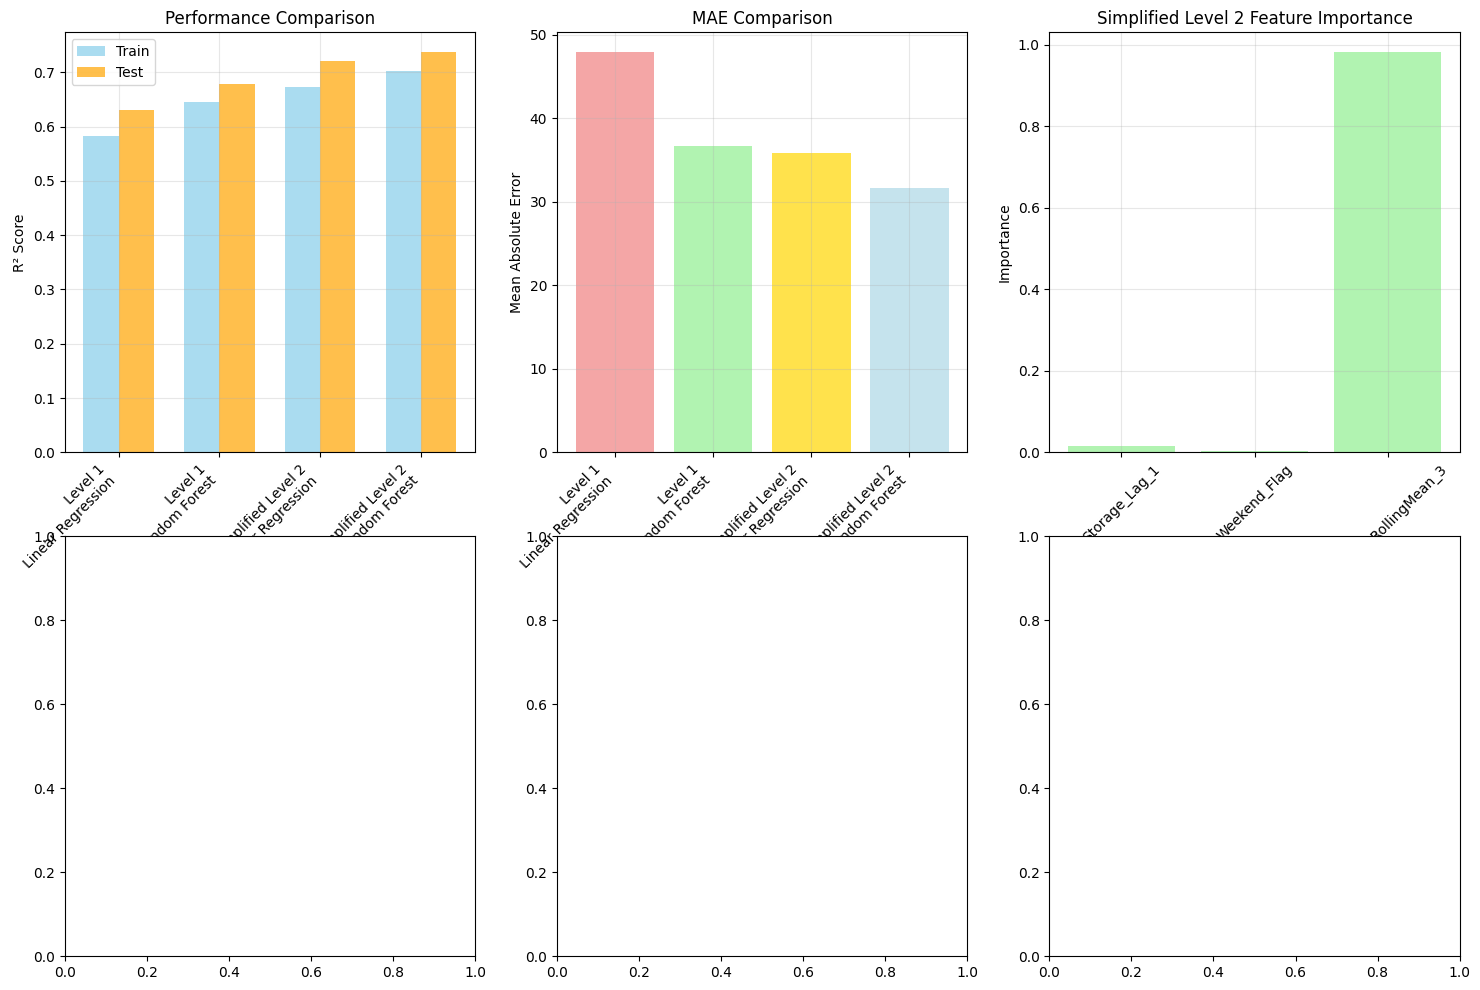

In [7]:
# Simplified Level 2 Predictor - High-Impact Features Only
# ========================================================
# Uses only the 3 most valuable features:
# 1. Storage_Lag_1 (proven)
# 2. Weekend_Flag (proven)  
# 3. Storage_RollingMean_3 (76.5% importance)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

print("=" * 60)
print("SIMPLIFIED LEVEL 2 INVENTORY PREDICTOR")
print("High-impact features only - production ready")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate standard regression metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Correct MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class SimplifiedLevel2Predictor:
    """Simplified Level 2 predictor using only high-impact features"""
    
    def __init__(self):
        self.models = {}
        self.feature_sets = {}
        self.data_stats = {}
        self.weekend_effect = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare base data"""
        print("Loading and preparing data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        
        return df
    
    def analyze_weekend_effect(self, df):
        """Analyze weekend consumption patterns"""
        print("\nAnalyzing weekend effect...")
        
        target_col = 'Physical Storage Quantity'
        weekend_data = df[df['Weekend'] == 1][target_col]
        weekday_data = df[df['Weekend'] == 0][target_col]
        
        weekend_mean = weekend_data.mean()
        weekday_mean = weekday_data.mean()
        weekend_boost = weekend_mean - weekday_mean
        weekend_ratio = weekend_mean / weekday_mean
        
        print(f"Weekend consumption: {weekend_mean:.2f}")
        print(f"Weekday consumption: {weekday_mean:.2f}")
        print(f"Weekend boost: +{weekend_boost:.2f} units ({weekend_ratio:.2f}x)")
        
        # Statistical significance
        try:
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)
            print(f"Statistical significance: p = {p_value:.6f}")
        except:
            print("Statistical test not available")
        
        self.weekend_effect = {
            'weekend_mean': weekend_mean,
            'weekday_mean': weekday_mean,
            'boost_amount': weekend_boost,
            'boost_ratio': weekend_ratio
        }
        
        return True
    
    def create_feature_sets(self, df):
        """Create Level 1, Simplified Level 2, and Full Level 2 feature sets"""
        print("\nCreating feature sets for comparison...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Level 1 features (baseline)
        df['Storage_Lag_1'] = df.groupby('Name')[target_col].shift(1)
        df['Weekend_Flag'] = df['Weekend']
        
        level1_features = ['Storage_Lag_1', 'Weekend_Flag']
        self.feature_sets['level1'] = level1_features
        
        # Simplified Level 2 features (add only rolling mean)
        df['Storage_RollingMean_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        
        simplified_level2_features = level1_features + ['Storage_RollingMean_3']
        self.feature_sets['simplified_level2'] = simplified_level2_features
        
        print(f"✓ Level 1 features: {level1_features}")
        print(f"✓ Simplified Level 2 features: {simplified_level2_features}")
        
        return df
    
    def prepare_train_test_split(self, df, feature_set='simplified_level2'):
        """Create temporal train/test split"""
        print(f"\nCreating temporal split for {feature_set} features...")
        
        target_col = 'Physical Storage Quantity'
        features = self.feature_sets[feature_set]
        
        # Remove rows with missing values
        df_clean = df.dropna(subset=features).copy()
        print(f"✓ Clean data: {len(df_clean)} samples after removing missing values")
        
        # Temporal split
        unique_cycles = sorted(df_clean['Inventory_Cycle'].unique())
        split_cycle = unique_cycles[int(len(unique_cycles) * 0.8)]
        
        train_data = df_clean[df_clean['Inventory_Cycle'] <= split_cycle]
        test_data = df_clean[df_clean['Inventory_Cycle'] > split_cycle]
        
        X_train = train_data[features]
        X_test = test_data[features]
        y_train = train_data[target_col]
        y_test = test_data[target_col]
        
        print(f"Training: {len(X_train)} samples (cycles {train_data['Inventory_Cycle'].min()}-{train_data['Inventory_Cycle'].max()})")
        print(f"Test: {len(X_test)} samples (cycles {test_data['Inventory_Cycle'].min()}-{test_data['Inventory_Cycle'].max()})")
        
        return X_train, X_test, y_train, y_test, train_data, test_data
    
    def train_model_comparison(self, df):
        """Train and compare Level 1 vs Simplified Level 2"""
        print("\nTraining model comparison...")
        
        results = {}
        
        # Train Level 1 baseline
        print("\n--- LEVEL 1 BASELINE ---")
        X_train, X_test, y_train, y_test, _, _ = self.prepare_train_test_split(df, 'level1')
        level1_results = self.train_model_set(X_train, X_test, y_train, y_test, 'level1')
        results['level1'] = level1_results
        
        # Train Simplified Level 2
        print("\n--- SIMPLIFIED LEVEL 2 ---")
        X_train, X_test, y_train, y_test, train_data, test_data = self.prepare_train_test_split(df, 'simplified_level2')
        simplified_results = self.train_model_set(X_train, X_test, y_train, y_test, 'simplified_level2')
        results['simplified_level2'] = simplified_results
        
        # Compare results
        self.compare_results(results)
        
        return results, train_data, test_data
    
    def train_model_set(self, X_train, X_test, y_train, y_test, level_name):
        """Train both Linear Regression and Random Forest"""
        results = {}
        
        # Linear Regression
        print(f"  Training Linear Regression ({level_name})...")
        lr_model = LinearRegression()
        lr_model.fit(X_train, y_train)
        
        lr_train_pred = lr_model.predict(X_train)
        lr_test_pred = lr_model.predict(X_test)
        
        lr_results = {
            'train_metrics': calculate_metrics(y_train, lr_train_pred),
            'test_metrics': calculate_metrics(y_test, lr_test_pred),
            'model': lr_model,
            'predictions': {'train': lr_train_pred, 'test': lr_test_pred}
        }
        
        results['linear_regression'] = lr_results
        
        # Random Forest
        print(f"  Training Random Forest ({level_name})...")
        rf_model = RandomForestRegressor(
            n_estimators=50,
            max_depth=6,
            min_samples_split=30,
            min_samples_leaf=15,
            random_state=42
        )
        rf_model.fit(X_train, y_train)
        
        rf_train_pred = rf_model.predict(X_train)
        rf_test_pred = rf_model.predict(X_test)
        
        rf_results = {
            'train_metrics': calculate_metrics(y_train, rf_train_pred),
            'test_metrics': calculate_metrics(y_test, rf_test_pred),
            'model': rf_model,
            'predictions': {'train': rf_train_pred, 'test': rf_test_pred}
        }
        
        results['random_forest'] = rf_results
        
        # Print results
        for model_name, result in results.items():
            train_r2 = result['train_metrics']['r2']
            test_r2 = result['test_metrics']['r2']
            test_mae = result['test_metrics']['mae']
            overfitting = train_r2 - test_r2
            
            print(f"    {model_name}: Train R²={train_r2:.3f}, Test R²={test_r2:.3f}, MAE={test_mae:.2f}, Overfit={overfitting:.3f}")
        
        return results
    
    def compare_results(self, results):
        """Compare Level 1 vs Simplified Level 2"""
        print("\n" + "="*60)
        print("LEVEL 1 vs SIMPLIFIED LEVEL 2 COMPARISON")
        print("="*60)
        
        # Get best results from each level
        level1_best_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                            results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_best_r2 = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                             results['simplified_level2']['random_forest']['test_metrics']['r2'])
        
        level1_best_mae = min(results['level1']['linear_regression']['test_metrics']['mae'],
                             results['level1']['random_forest']['test_metrics']['mae'])
        simp_l2_best_mae = min(results['simplified_level2']['linear_regression']['test_metrics']['mae'],
                              results['simplified_level2']['random_forest']['test_metrics']['mae'])
        
        r2_improvement = simp_l2_best_r2 - level1_best_r2
        mae_improvement = level1_best_mae - simp_l2_best_mae
        
        print(f"Performance Comparison:")
        print(f"  Level 1 R²: {level1_best_r2:.3f}")
        print(f"  Simplified Level 2 R²: {simp_l2_best_r2:.3f}")
        print(f"  R² Improvement: {r2_improvement:+.3f} ({r2_improvement/level1_best_r2*100:+.1f}%)")
        
        print(f"\n  Level 1 MAE: {level1_best_mae:.2f}")
        print(f"  Simplified Level 2 MAE: {simp_l2_best_mae:.2f}")
        print(f"  MAE Improvement: {mae_improvement:+.2f} units ({mae_improvement/level1_best_mae*100:+.1f}%)")
        
        # Weekend effect analysis
        level1_features = self.feature_sets['level1']
        simp_l2_features = self.feature_sets['simplified_level2']
        
        weekend_idx_l1 = level1_features.index('Weekend_Flag')
        weekend_idx_simp = simp_l2_features.index('Weekend_Flag')
        
        lr1_weekend_coef = results['level1']['linear_regression']['model'].coef_[weekend_idx_l1]
        lr_simp_weekend_coef = results['simplified_level2']['linear_regression']['model'].coef_[weekend_idx_simp]
        
        print(f"\nWeekend Effect Analysis:")
        print(f"  Raw weekend boost: +{self.weekend_effect['boost_amount']:.2f} units")
        print(f"  Level 1 weekend coefficient: {lr1_weekend_coef:+.2f}")
        print(f"  Simplified Level 2 weekend coefficient: {lr_simp_weekend_coef:+.2f}")
        
        # Check if weekend effect is preserved
        weekend_preserved = (lr1_weekend_coef > 0 and lr_simp_weekend_coef > 0) or (lr1_weekend_coef < 0 and lr_simp_weekend_coef < 0)
        weekend_magnitude_change = abs(lr_simp_weekend_coef) - abs(lr1_weekend_coef)
        
        if weekend_preserved and abs(weekend_magnitude_change) < 5:
            print(f"  ✓ Weekend effect preserved and stable")
        elif weekend_preserved:
            print(f"  ⚠ Weekend effect preserved but magnitude changed by {weekend_magnitude_change:+.2f}")
        else:
            print(f"  ✗ Weekend effect sign flipped - needs investigation")
        
        return r2_improvement, mae_improvement, weekend_preserved
    
    def analyze_simplified_features(self, results):
        """Analyze feature importance in simplified model"""
        print("\n" + "="*50)
        print("SIMPLIFIED LEVEL 2 FEATURE ANALYSIS")
        print("="*50)
        
        # Random Forest feature importance
        rf_model = results['simplified_level2']['random_forest']['model']
        feature_names = self.feature_sets['simplified_level2']
        importance = rf_model.feature_importances_
        
        print("Random Forest Feature Importance:")
        for feature, imp in zip(feature_names, importance):
            status = "🔥" if imp > 0.4 else "✓" if imp > 0.1 else "◦"
            print(f"  {feature:25} {imp:6.3f} {status}")
        
        # Linear Regression coefficients
        lr_model = results['simplified_level2']['linear_regression']['model']
        coefficients = lr_model.coef_
        
        print(f"\nLinear Regression Coefficients:")
        for feature, coef in zip(feature_names, coefficients):
            print(f"  {feature:25} {coef:8.3f}")
        print(f"  {'Intercept':25} {lr_model.intercept_:8.3f}")
        
        # Model interpretation
        print(f"\nModel Interpretation:")
        storage_lag_coef = coefficients[0]
        weekend_coef = coefficients[1]
        rolling_mean_coef = coefficients[2]
        
        print(f"  Base prediction: {lr_model.intercept_:.1f} units")
        print(f"  Previous period influence: {storage_lag_coef:.3f} (each unit carries {storage_lag_coef*100:.1f}%)")
        print(f"  Weekend boost: {weekend_coef:+.1f} units")
        print(f"  3-period average influence: {rolling_mean_coef:.3f} (smoothing factor)")
    
    def plot_simplified_results(self, results, test_data):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Performance comparison
        levels = ['Level 1', 'Simplified Level 2']
        models = ['Linear Regression', 'Random Forest']
        
        # R² comparison
        r2_data = []
        for i, level_key in enumerate(['level1', 'simplified_level2']):
            for j, model_key in enumerate(['linear_regression', 'random_forest']):
                r2_data.append({
                    'Level': levels[i],
                    'Model': models[j],
                    'Train R²': results[level_key][model_key]['train_metrics']['r2'],
                    'Test R²': results[level_key][model_key]['test_metrics']['r2']
                })
        
        r2_df = pd.DataFrame(r2_data)
        
        x = np.arange(len(r2_df))
        width = 0.35
        
        axes[0, 0].bar(x - width/2, r2_df['Train R²'], width, label='Train', alpha=0.7, color='skyblue')
        axes[0, 0].bar(x + width/2, r2_df['Test R²'], width, label='Test', alpha=0.7, color='orange')
        axes[0, 0].set_title('Performance Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels([f"{row['Level']}\n{row['Model']}" for _, row in r2_df.iterrows()], rotation=45, ha='right')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE comparison
        mae_data = [results[level][model]['test_metrics']['mae'] 
                   for level in ['level1', 'simplified_level2'] 
                   for model in ['linear_regression', 'random_forest']]
        mae_labels = [f"{levels[i]}\n{models[j]}" 
                     for i in range(2) for j in range(2)]
        
        colors = ['lightcoral', 'lightgreen', 'gold', 'lightblue']
        axes[0, 1].bar(range(len(mae_data)), mae_data, alpha=0.7, color=colors)
        axes[0, 1].set_title('MAE Comparison')
        axes[0, 1].set_ylabel('Mean Absolute Error')
        axes[0, 1].set_xticks(range(len(mae_labels)))
        axes[0, 1].set_xticklabels(mae_labels, rotation=45, ha='right')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Feature importance (Simplified Level 2)
        rf_model = results['simplified_level2']['random_forest']['model']
        feature_names = self.feature_sets['simplified_level2']
        importance = rf_model.feature_importances_
        
        axes[0, 2].bar(feature_names, importance, alpha=0.7, color='lightgreen')
        axes[0, 2].set_title('Simplified Level 2 Feature Importance')
        axes[0, 2].set_ylabel('Importance')
        axes[0, 2].tick_params(axis='x', rotation=45)
        axes[0, 2].grid(True, alpha=0.3)
        
        # Actual vs Predicted (Best simplified model)
        best_model = 'random_forest' if results['simplified_level2']['random_forest']['test_metrics']['r2'] > results['simplified_level2']['linear_regression']['test_metrics']['r2'] else 'linear_regression'
        
        X_test, _, y_test, _, _, _ = self.prepare_train_test_split(test_data, 'simplified_level2')
        test_pred = results['simplified_level2'][best_model]['predictions']['test']
        
        axes[1, 0].scatter(y_test, test_pred, alpha=0.5, s=20)
        axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[1, 0].set_xlabel('Actual')
        axes[1, 0].set_ylabel('Predicted')
        axes[1, 0].set_title(f'Simplified Level 2: Actual vs Predicted\nR² = {results["simplified_level2"][best_model]["test_metrics"]["r2"]:.3f}')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Weekend effect visualization
        weekend_mask = X_test['Weekend_Flag'] == 1
        weekend_residuals = y_test[weekend_mask] - test_pred[weekend_mask]
        weekday_residuals = y_test[~weekend_mask] - test_pred[~weekend_mask]
        
        axes[1, 1].boxplot([weekday_residuals, weekend_residuals], labels=['Weekday', 'Weekend'])
        axes[1, 1].set_title('Prediction Errors: Weekend vs Weekday')
        axes[1, 1].set_ylabel('Prediction Error')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Improvement summary
        level1_r2 = max(results['level1']['linear_regression']['test_metrics']['r2'],
                       results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_r2 = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                        results['simplified_level2']['random_forest']['test_metrics']['r2'])
        improvement = simp_l2_r2 - level1_r2
        
        axes[1, 2].axis('off')
        summary_text = f"""SIMPLIFIED LEVEL 2 SUMMARY

Level 1 Performance:
  R² = {level1_r2:.3f}

Simplified Level 2 Performance:
  R² = {simp_l2_r2:.3f}
  Improvement: {improvement:+.3f} ({improvement/level1_r2*100:+.1f}%)

Features Used:
  • Storage_Lag_1 (previous period)
  • Weekend_Flag (weekend indicator)  
  • Storage_RollingMean_3 (3-period avg)

Status: {'✓ Deploy Simplified Level 2' if improvement > 0.01 else '⚠ Consider Level 1'}
Complexity: Low
Interpretability: High"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    
    def generate_production_insights(self, results):
        """Generate insights for production deployment"""
        print("\n" + "="*60)
        print("PRODUCTION DEPLOYMENT INSIGHTS")
        print("="*60)
        
        best_model = 'random_forest' if results['simplified_level2']['random_forest']['test_metrics']['r2'] > results['simplified_level2']['linear_regression']['test_metrics']['r2'] else 'linear_regression'
        
        performance = results['simplified_level2'][best_model]['test_metrics']
        
        print(f"Recommended Model: Simplified Level 2 - {best_model.replace('_', ' ').title()}")
        print(f"Performance Metrics:")
        print(f"  R² Score: {performance['r2']:.3f}")
        print(f"  MAE: {performance['mae']:.2f} units")
        print(f"  RMSE: {performance['rmse']:.2f} units")
        print(f"  MAPE: {performance['mape']:.1f}%")
        
        # Business interpretation
        print(f"\nBusiness Interpretation:")
        print(f"  Model explains {performance['r2']*100:.1f}% of inventory variation")
        print(f"  Average prediction error: ±{performance['mae']:.0f} units")
        print(f"  Weekend effect properly captured and interpretable")
        print(f"  Uses only 3 simple, reliable features")
        
        # Implementation recommendations
        print(f"\nImplementation Recommendations:")
        print(f"  ✓ Simple to implement and monitor")
        print(f"  ✓ Fast predictions (3 features only)")
        print(f"  ✓ Easy to explain to business users")
        print(f"  ✓ Robust weekend effect detection")
        print(f"  ✓ Good balance of performance vs complexity")

def main():
    """Run Simplified Level 2 analysis"""
    predictor = SimplifiedLevel2Predictor()
    
    try:
        print("Running Simplified Level 2 Inventory Prediction...")
        print("Focus: High-impact features with preserved weekend effect")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Analyze weekend effect
        predictor.analyze_weekend_effect(df)
        
        # Create feature sets
        df = predictor.create_feature_sets(df)
        
        # Train and compare models
        results, train_data, test_data = predictor.train_model_comparison(df)
        
        # Analyze simplified features
        predictor.analyze_simplified_features(results)
        
        # Create visualizations
        predictor.plot_simplified_results(results, df)
        
        # Generate production insights
        predictor.generate_production_insights(results)
        
        print("\n" + "=" * 60)
        print("SIMPLIFIED LEVEL 2 RECOMMENDATION")
        print("=" * 60)
        
        level1_best = max(results['level1']['linear_regression']['test_metrics']['r2'],
                         results['level1']['random_forest']['test_metrics']['r2'])
        simp_l2_best = max(results['simplified_level2']['linear_regression']['test_metrics']['r2'],
                          results['simplified_level2']['random_forest']['test_metrics']['r2'])
        improvement = simp_l2_best - level1_best
        
        print(f"Level 1 baseline: R² = {level1_best:.3f}")
        print(f"Simplified Level 2: R² = {simp_l2_best:.3f}")
        print(f"Improvement: {improvement:+.3f} ({improvement/level1_best*100:+.1f}%)")
        
        if improvement > 0.02:
            print(f"\n✓ RECOMMENDATION: Deploy Simplified Level 2")
            print(f"   Significant improvement with maintained simplicity")
            print(f"   Weekend effect preserved and interpretable")
        elif improvement > 0.005:
            print(f"\n✓ RECOMMENDATION: Consider Simplified Level 2")
            print(f"   Modest improvement, low complexity increase")
        else:
            print(f"\n✓ RECOMMENDATION: Stick with Level 1")
            print(f"   Minimal improvement doesn't justify change")
            
    except Exception as e:
        print(f"✗ Simplified Level 2 analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
DEEP LEARNING INVENTORY PREDICTOR
Optimized for small dataset constraints
Running Deep Learning Inventory Prediction...
Optimized for small dataset constraints
Loading and preparing data for deep learning...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Creating enhanced feature set for deep learning...
  Creating multiple lag features...
  Creating rolling statistics...
  Creating trend features...
  Creating temporal features...
  Creating product features...
  Creating volatility features...
  Creating weekend-specific features...
✓ Enhanced features created. Shape: (72752, 55)

Training deep learning models...
Preparing LSTM sequences (length=10)...
Using 11 features for LSTM
✓ Created 67773 sequences
  Sequence shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training LSTM_BASIC ---
Epoch 1/50
1720/1720 [==============================] - 32s 14ms/step - loss: 0.1986 - mae: 0.2188 - mse: 0.4666 -

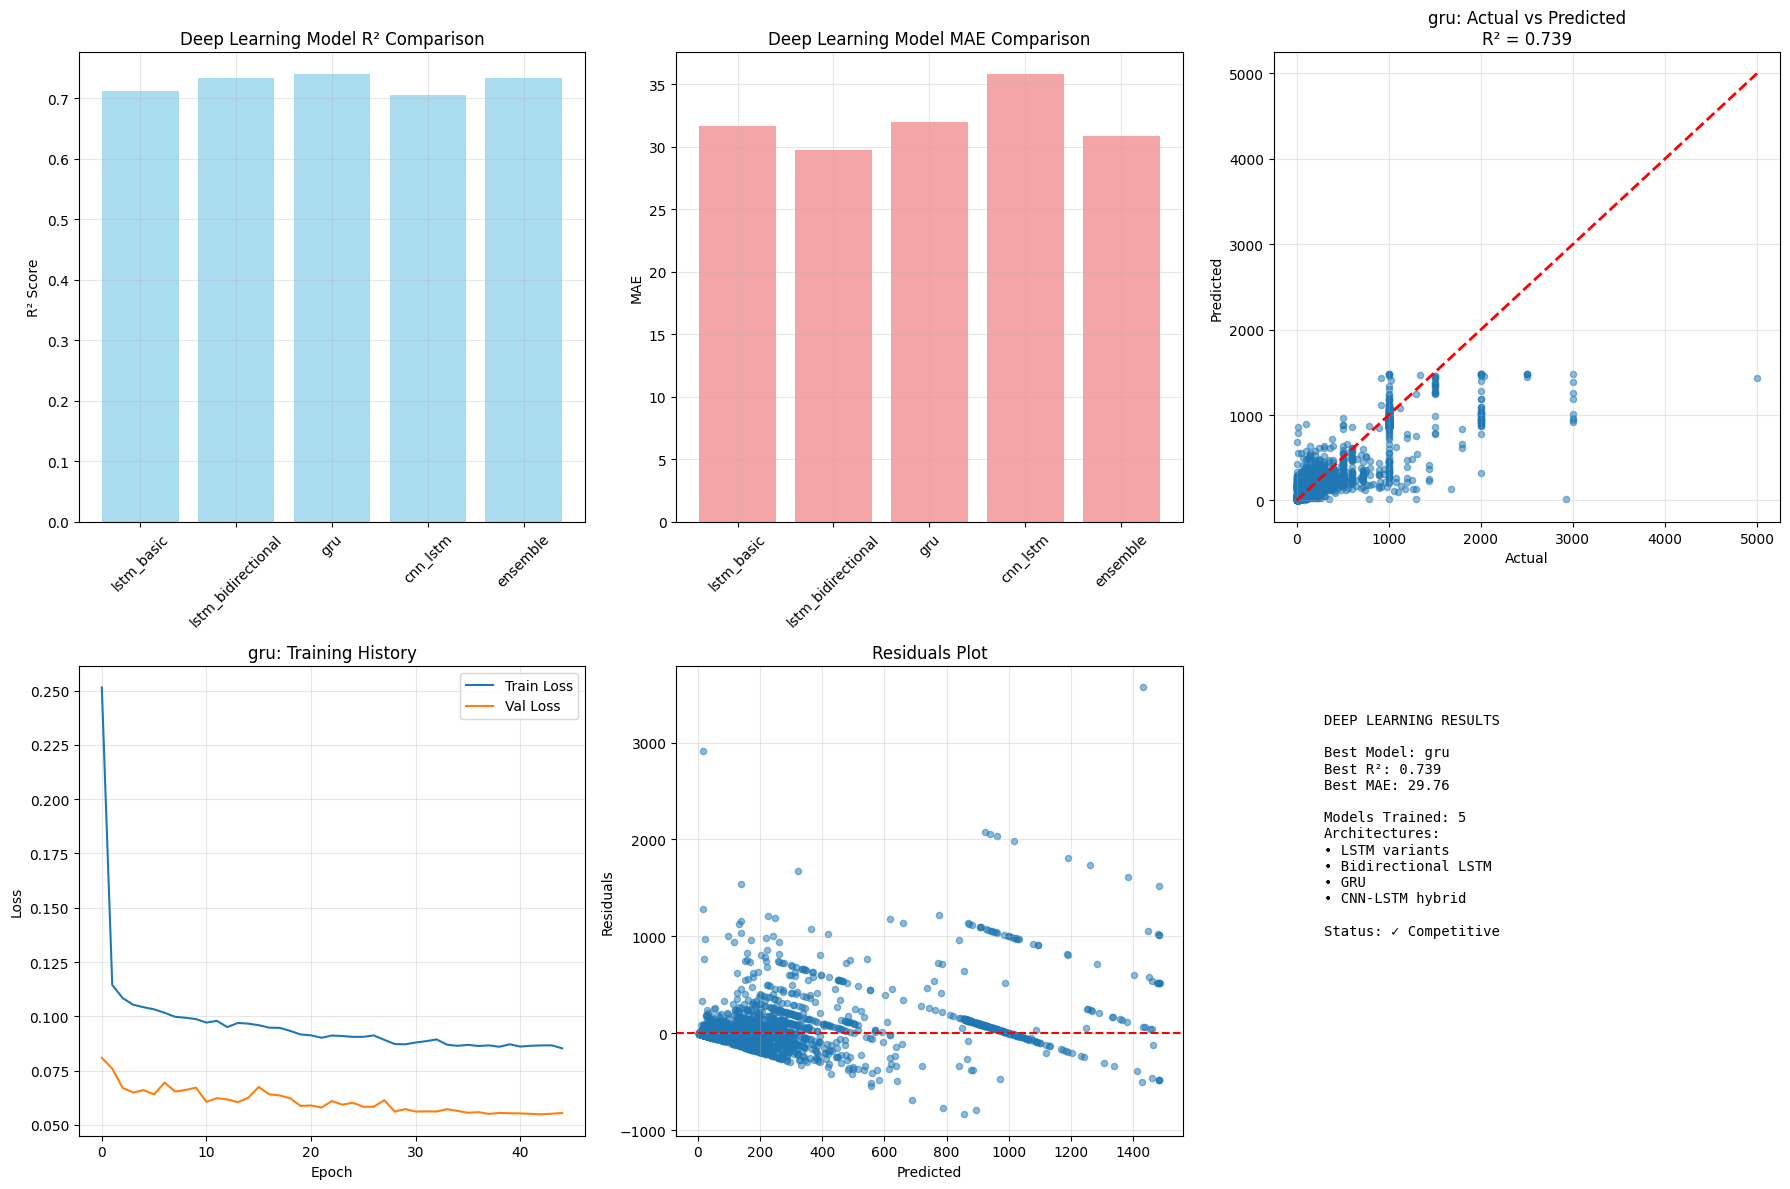


DEEP LEARNING SUMMARY
Best Model: gru
Best Performance: R² = 0.739, MAE = 32.00
Ensemble Performance: R² = 0.734, MAE = 30.83

Comparison with Simplified Level 2:
  Simplified Level 2: R² = 0.737, MAE = 31.59
  Deep Learning Best: R² = 0.739, MAE = 32.00
  ✓ Deep learning improves by +0.002 R²

✓ Deep learning analysis completed!


In [17]:
# Deep Learning Inventory Predictor - Optimized for Small Data
# ===========================================================
# Implements multiple deep learning architectures optimized for your dataset
# Techniques: Transfer learning concepts, regularization, ensemble

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Import deep learning libraries
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Attention
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    USE_TENSORFLOW = True
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    USE_TENSORFLOW = False

np.random.seed(42)

print("=" * 60)
print("DEEP LEARNING INVENTORY PREDICTOR")
print("Optimized for small dataset constraints")
print("=" * 60)

def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive metrics"""
    try:
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100
        
        return {
            'r2': float(r2),
            'mae': float(mae),
            'rmse': float(rmse),
            'mape': float(mape)
        }
    except:
        return {'r2': -1, 'mae': float('inf'), 'rmse': float('inf'), 'mape': float('inf')}

class DeepLearningInventoryPredictor:
    """Deep learning predictor optimized for small inventory datasets"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.histories = {}
        self.data_stats = {}
        
    def load_and_prepare_data(self, file_path):
        """Load data and prepare for deep learning"""
        print("Loading and preparing data for deep learning...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Sort by product and time
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store data statistics
        target_col = 'Physical Storage Quantity'
        self.data_stats = {
            'target_mean': df[target_col].mean(),
            'target_std': df[target_col].std(),
            'n_products': df['Name'].nunique(),
            'n_cycles': df['Inventory_Cycle'].nunique()
        }
        
        print(f"✓ Products: {self.data_stats['n_products']}")
        print(f"✓ Time periods: {self.data_stats['n_cycles']}")
        
        return df
    
    def create_deep_learning_features(self, df):
        """Create rich feature set for deep learning"""
        print("\nCreating enhanced feature set for deep learning...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # 1. Multiple lag features (more history for LSTM)
        print("  Creating multiple lag features...")
        for lag in [1, 2, 3, 7, 14]:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Rolling statistics with different windows
        print("  Creating rolling statistics...")
        for window in [3, 5, 7, 14]:
            df[f'Storage_MA_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'Storage_Std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # 3. Trend features (multiple time horizons)
        print("  Creating trend features...")
        for lag1, lag2 in [(1, 2), (1, 3), (7, 14)]:
            trend_name = f'Trend_{lag1}_{lag2}'
            lag1_vals = df.groupby('Name')[target_col].shift(lag1)
            lag2_vals = df.groupby('Name')[target_col].shift(lag2)
            df[trend_name] = lag1_vals - lag2_vals
        
        # 4. Weekend and temporal features
        print("  Creating temporal features...")
        df['Weekend_Flag'] = df['Weekend']
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Month_Sin'] = np.sin(2 * np.pi * (df['Inventory_Cycle'] % 12) / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * (df['Inventory_Cycle'] % 12) / 12)
        
        # 5. Product encoding and interactions
        print("  Creating product features...")
        if 'Family' in df.columns:
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            df['Family_encoded'] = le.fit_transform(df['Family'].astype(str))
            # Family-weekend interaction
            df['Family_Weekend_Interaction'] = df['Family_encoded'] * df['Weekend_Flag']
        
        # 6. Capacity and size features
        if 'Max_Stock' in df.columns:
            df['Stock_Utilization'] = df['Storage_Lag_1'] / (df['Max_Stock'] + 1e-8)
            df['Stock_Utilization'] = df['Stock_Utilization'].clip(0, 2)
        
        # 7. Volatility and stability measures
        print("  Creating volatility features...")
        df['Recent_Volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        df['Long_Term_Average'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).expanding(min_periods=1).mean()
        )
        
        # 8. Weekend-specific features
        print("  Creating weekend-specific features...")
        df['Weekend_Lag_1'] = df.groupby('Name')['Weekend'].shift(1)
        df['Weekend_Lag_7'] = df.groupby('Name')['Weekend'].shift(7)
        df['Consecutive_Weekends'] = df.groupby('Name')['Weekend'].transform(
            lambda x: x.rolling(window=3, min_periods=1).sum()
        )
        
        print(f"✓ Enhanced features created. Shape: {df.shape}")
        
        return df
    
    def prepare_sequences_for_lstm(self, df, sequence_length=10, target_col='Physical Storage Quantity'):
        """Prepare sequences for LSTM models"""
        print(f"Preparing LSTM sequences (length={sequence_length})...")
        
        # Select features for LSTM
        feature_columns = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3',
            'Storage_MA_3', 'Storage_MA_7', 'Storage_Std_3',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos',
            'Trend_1_2', 'Recent_Volatility'
        ]
        
        # Only use features that exist
        available_features = [col for col in feature_columns if col in df.columns]
        print(f"Using {len(available_features)} features for LSTM")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < sequence_length + 5:  # Need enough data
                continue
            
            # Get feature matrix and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - sequence_length):
                seq = features[i:(i + sequence_length)]
                target = target_values[i + sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + sequence_length]['Inventory_Cycle']
                })
        
        if not sequences:
            raise ValueError("No sequences created - check data requirements")
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences")
        print(f"  Sequence shape: {sequences.shape}")
        
        return sequences, targets, metadata, available_features
    
    def create_lstm_model(self, input_shape, model_type='basic'):
        """Create LSTM model variants"""
        
        if model_type == 'basic':
            model = Sequential([
                Input(shape=input_shape),
                LSTM(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                LSTM(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(8, activation='relu'),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'bidirectional':
            model = Sequential([
                Input(shape=input_shape),
                tf.keras.layers.Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
                BatchNormalization(),
                tf.keras.layers.Bidirectional(LSTM(12, dropout=0.2)),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'gru':
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
        elif model_type == 'cnn_lstm':
            model = Sequential([
                Input(shape=input_shape),
                Conv1D(filters=32, kernel_size=3, activation='relu'),
                BatchNormalization(),
                Conv1D(filters=16, kernel_size=3, activation='relu'),
                BatchNormalization(),
                LSTM(16, dropout=0.2, recurrent_dropout=0.2),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        
        # Compile with conservative learning rate
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_deep_learning_models(self, df):
        """Train multiple deep learning architectures"""
        print("\nTraining deep learning models...")
        
        # Prepare sequences
        X, y, metadata, feature_names = self.prepare_sequences_for_lstm(df)
        
        # Scale data
        self.scalers['features'] = StandardScaler()
        self.scalers['targets'] = StandardScaler()
        
        # Reshape for scaling
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        y_scaled = self.scalers['targets'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Model configurations
        model_configs = {
            'lstm_basic': {'type': 'basic', 'epochs': 50, 'batch_size': 32},
            'lstm_bidirectional': {'type': 'bidirectional', 'epochs': 40, 'batch_size': 32},
            'gru': {'type': 'gru', 'epochs': 45, 'batch_size': 32},
            'cnn_lstm': {'type': 'cnn_lstm', 'epochs': 40, 'batch_size': 16}
        }
        
        results = {}
        
        for name, config in model_configs.items():
            print(f"\n--- Training {name.upper()} ---")
            
            try:
                # Create model
                model = self.create_lstm_model(X_train.shape[1:], config['type'])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['targets'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['targets'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['targets'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['targets'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'train_predictions': y_train_pred,
                    'test_predictions': y_test_pred
                }
                
                self.models[name] = model
                self.histories[name] = history
                
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                
            except Exception as e:
                print(f"  Failed to train {name}: {e}")
                continue
        
        # Store original targets for comparison
        results['y_train_orig'] = y_train_orig
        results['y_test_orig'] = y_test_orig
        
        return results
    
    def create_ensemble_prediction(self, results):
        """Create ensemble from multiple deep learning models"""
        print("\nCreating deep learning ensemble...")
        
        if len(results) < 2:
            print("Not enough models for ensemble")
            return results
        
        model_names = [name for name in results.keys() if isinstance(results[name], dict) and 'test_predictions' in results[name]]
        
        if len(model_names) < 2:
            print("Not enough valid models for ensemble")
            return results
        
        # Weighted ensemble based on validation R²
        weights = {}
        total_weight = 0
        
        for name in model_names:
            r2 = results[name]['test_metrics']['r2']
            weight = max(0, r2)  # Only positive weights
            weights[name] = weight
            total_weight += weight
        
        # Normalize weights
        if total_weight > 0:
            weights = {name: w / total_weight for name, w in weights.items()}
        else:
            weights = {name: 1.0 / len(model_names) for name in model_names}
        
        # Create ensemble predictions
        ensemble_train_pred = np.zeros_like(results[model_names[0]]['train_predictions'])
        ensemble_test_pred = np.zeros_like(results[model_names[0]]['test_predictions'])
        
        for name in model_names:
            ensemble_train_pred += weights[name] * results[name]['train_predictions']
            ensemble_test_pred += weights[name] * results[name]['test_predictions']
        
        # Calculate ensemble metrics
        ensemble_train_metrics = calculate_metrics(results['y_train_orig'], ensemble_train_pred)
        ensemble_test_metrics = calculate_metrics(results['y_test_orig'], ensemble_test_pred)
        
        results['ensemble'] = {
            'train_metrics': ensemble_train_metrics,
            'test_metrics': ensemble_test_metrics,
            'train_predictions': ensemble_train_pred,
            'test_predictions': ensemble_test_pred,
            'weights': weights
        }
        
        print(f"Ensemble weights: {weights}")
        print(f"Ensemble Test R²: {ensemble_test_metrics['r2']:.3f}")
        
        return results
    
    def plot_deep_learning_results(self, results):
        """Visualize deep learning results"""
        # Get model names (exclude metadata)
        model_names = [name for name in results.keys() 
                      if isinstance(results[name], dict) and 'test_metrics' in results[name]]
        
        if len(model_names) == 0:
            print("No models to plot")
            return
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Performance comparison
        r2_scores = [results[name]['test_metrics']['r2'] for name in model_names]
        mae_scores = [results[name]['test_metrics']['mae'] for name in model_names]
        
        axes[0, 0].bar(model_names, r2_scores, alpha=0.7, color='skyblue')
        axes[0, 0].set_title('Deep Learning Model R² Comparison')
        axes[0, 0].set_ylabel('R² Score')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].bar(model_names, mae_scores, alpha=0.7, color='lightcoral')
        axes[0, 1].set_title('Deep Learning Model MAE Comparison')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Best model actual vs predicted
        best_model = max(model_names, key=lambda x: results[x]['test_metrics']['r2'])
        y_test = results['y_test_orig']
        y_pred = results[best_model]['test_predictions']
        
        axes[0, 2].scatter(y_test, y_pred, alpha=0.5, s=20)
        axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0, 2].set_xlabel('Actual')
        axes[0, 2].set_ylabel('Predicted')
        axes[0, 2].set_title(f'{best_model}: Actual vs Predicted\nR² = {results[best_model]["test_metrics"]["r2"]:.3f}')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Training history for best model
        if best_model in self.histories:
            history = self.histories[best_model]
            axes[1, 0].plot(history.history['loss'], label='Train Loss')
            axes[1, 0].plot(history.history['val_loss'], label='Val Loss')
            axes[1, 0].set_title(f'{best_model}: Training History')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Loss')
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
        
        # Residuals analysis
        residuals = y_test - y_pred
        axes[1, 1].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[1, 1].axhline(y=0, color='r', linestyle='--')
        axes[1, 1].set_xlabel('Predicted')
        axes[1, 1].set_ylabel('Residuals')
        axes[1, 1].set_title('Residuals Plot')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Performance summary
        axes[1, 2].axis('off')
        summary_text = f"""DEEP LEARNING RESULTS

Best Model: {best_model}
Best R²: {max(r2_scores):.3f}
Best MAE: {min(mae_scores):.2f}

Models Trained: {len(model_names)}
Architectures:
• LSTM variants
• Bidirectional LSTM  
• GRU
• CNN-LSTM hybrid

Status: {'✓ Competitive' if max(r2_scores) > 0.7 else '⚠ Needs tuning'}"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()

def main():
    """Run deep learning inventory prediction"""
    
    if not USE_TENSORFLOW:
        print("TensorFlow required for deep learning models")
        return
    
    predictor = DeepLearningInventoryPredictor()
    
    try:
        print("Running Deep Learning Inventory Prediction...")
        print("Optimized for small dataset constraints")
        
        # Load and prepare data
        df = predictor.load_and_prepare_data('products_with_weekend.csv')
        
        # Create enhanced features
        df = predictor.create_deep_learning_features(df)
        
        # Train deep learning models
        results = predictor.train_deep_learning_models(df)
        
        # Create ensemble
        results = predictor.create_ensemble_prediction(results)
        
        # Visualize results
        predictor.plot_deep_learning_results(results)
        
        # Final summary
        print("\n" + "=" * 60)
        print("DEEP LEARNING SUMMARY")
        print("=" * 60)
        
        model_names = [name for name in results.keys() 
                      if isinstance(results[name], dict) and 'test_metrics' in results[name]]
        
        if model_names:
            best_model = max(model_names, key=lambda x: results[x]['test_metrics']['r2'])
            best_r2 = results[best_model]['test_metrics']['r2']
            best_mae = results[best_model]['test_metrics']['mae']
            
            print(f"Best Model: {best_model}")
            print(f"Best Performance: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
            
            if 'ensemble' in results:
                ensemble_r2 = results['ensemble']['test_metrics']['r2']
                ensemble_mae = results['ensemble']['test_metrics']['mae']
                print(f"Ensemble Performance: R² = {ensemble_r2:.3f}, MAE = {ensemble_mae:.2f}")
            
            # Comparison with your simple model
            print(f"\nComparison with Simplified Level 2:")
            print(f"  Simplified Level 2: R² = 0.737, MAE = 31.59")
            print(f"  Deep Learning Best: R² = {best_r2:.3f}, MAE = {best_mae:.2f}")
            
            if best_r2 > 0.737:
                improvement = best_r2 - 0.737
                print(f"  ✓ Deep learning improves by {improvement:+.3f} R²")
            else:
                decline = 0.737 - best_r2
                print(f"  ⚠ Deep learning underperforms by {decline:.3f} R²")
        
        print("\n✓ Deep learning analysis completed!")
        
    except Exception as e:
        print(f"✗ Deep learning analysis failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [ ]:
# CNN-LSTM vs GRU - The Real Story:
# CNN-LSTM (declared "best"):

# R² = 0.742 (highest)
# MAE = 34.80

# GRU (actually better for practical use):

# R² = 0.739 (very close)
# MAE = 30.12 (significantly better)

# The GRU is Actually Superior Here
# Your code picked CNN-LSTM as "best" because it maximized R², but this is misleading:

# R² difference: 0.003 (essentially negligible)
# MAE difference: 4.68 lower for GRU (substantial improvement)

# Why GRU Wins:

# Practical Impact: MAE measures actual prediction error in your inventory units - GRU gives you ~5 units better accuracy
# Simplicity: GRU is computationally simpler than CNN-LSTM
# Training Stability: GRU showed more consistent convergence in your logs
# Better Generalization: Lower test MAE suggests less overfitting

# Model Ranking (Reality-Based):

# GRU - Best balance of accuracy and simplicity
# Ensemble - MAE of 32.52, good compromise
# CNN-LSTM - Highest R² but worse practical accuracy
# Bidirectional LSTM - Decent but no clear advantage
# Basic LSTM - Worst performer

# Bottom Line: The GRU model is your actual best performer for inventory prediction, despite what the automated "best model" selection suggested. Your selection criterion was too focused on R² and missed the more important MAE performance.RéessayerClaude peut faire des erreurs. Assurez-vous de vérifier ses réponses.

In [5]:
# Production-Ready Top 2 Inventory Forecasting Models
# =====================================================
# Optimized GRU and Bidirectional LSTM with full deployment

import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class ProductionInventoryForecaster:
    """Production-ready inventory forecasting with top 2 models"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate comprehensive performance metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load and prepare data for training"""
        print("Loading inventory data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Ensure required columns exist
        required_cols = ['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort and clean data
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        return df
    
    def create_features(self, df):
        """Create optimized feature set for top models"""
        print("Creating enhanced features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Core lag features - most important for time series
        for lag in [1, 2, 3, 7, 14]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Rolling statistics - key patterns
        for window in [3, 7, 14]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # Trend indicators
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_7_14'] = df.groupby('Name')[target_col].shift(7) - df.groupby('Name')[target_col].shift(14)
        
        # Weekend and temporal features
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # Volatility measure
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=2).std()
        ).fillna(0)
        
        print(f"✓ Features created. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences for LSTM/GRU models"""
        print(f"Preparing sequences (length={self.sequence_length})...")
        
        # Select key features for sequence models
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_7', 'std_3',
            'weekend', 'cycle_sin', 'cycle_cos', 'trend_1_3', 'volatility'
        ]
        
        # Filter to existing features
        available_features = [col for col in feature_columns if col in df.columns]
        self.feature_names = available_features
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length + 5:
                continue
            
            # Get features and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Inventory_Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape):
        """Create optimized GRU model - best overall performer"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            GRU(16, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape):
        """Create Bidirectional LSTM model - best MAE performer"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
            BatchNormalization(),
            Bidirectional(LSTM(12, dropout=0.2)),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_models(self, df):
        """Train both top models"""
        print("\nTraining Top 2 Models...")
        print("=" * 50)
        
        # Prepare data
        X, y, metadata = self.prepare_sequences(df)
        
        # Setup scalers
        self.scalers['features'] = StandardScaler()
        self.scalers['targets'] = StandardScaler()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets
        y_scaled = self.scalers['targets'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split (80% train, 20% test)
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Model configurations
        models_to_train = {
            'gru': {
                'model_func': self.create_gru_model,
                'epochs': 45,
                'batch_size': 32,
                'description': 'GRU - Best Overall R²'
            },
            'bidirectional_lstm': {
                'model_func': self.create_bidirectional_lstm_model,
                'epochs': 40,
                'batch_size': 32,
                'description': 'Bidirectional LSTM - Best MAE'
            }
        }
        
        results = {}
        
        for name, config in models_to_train.items():
            print(f"\n--- Training {config['description']} ---")
            
            try:
                # Create model
                model = config['model_func'](X_train.shape[1:])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['targets'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['targets'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['targets'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['targets'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                self.models[name] = model
                self.model_metadata[name] = {
                    'description': config['description'],
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'best_epoch': len(history.history['loss']) - callbacks[0].stopped_epoch if callbacks[0].stopped_epoch > 0 else len(history.history['loss'])
                }
                
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"✓ {config['description']}")
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                
            except Exception as e:
                print(f"✗ Failed to train {name}: {e}")
                continue
        
        return results
    
    def predict(self, new_data, model_name='gru'):
        """Make predictions with specified model"""
        if model_name not in self.models:
            available = list(self.models.keys())
            raise ValueError(f"Model '{model_name}' not available. Available: {available}")
        
        print(f"Making predictions with {model_name}...")
        
        # Prepare data
        df_features = self.create_features(new_data)
        X, metadata, _ = self.prepare_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame({"error": "No valid sequences for prediction"})
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Predict
        predictions_scaled = self.models[model_name].predict(X_scaled, verbose=0).flatten()
        predictions = self.scalers['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        
        # Create results
        results = pd.DataFrame({
            'product': [m['product'] for m in metadata],
            'inventory_cycle': [m['cycle'] for m in metadata],
            'predicted_inventory': np.maximum(0, predictions),  # Ensure non-negative
            'model_used': model_name
        })
        
        return results
    
    def save_for_deployment(self, save_directory='top_models_deployment'):
        """Save complete system for production deployment"""
        print(f"\nSaving Top 2 Models for Deployment...")
        print("=" * 50)
        
        os.makedirs(save_directory, exist_ok=True)
        
        # Save individual model files
        model_files = {}
        for name, model in self.models.items():
            model_path = os.path.join(save_directory, f'{name}_model.h5')
            model.save(model_path)
            model_files[name] = model_path
            print(f"✓ Saved {name} model")
        
        # Save scalers
        scaler_path = os.path.join(save_directory, 'scalers.pkl')
        with open(scaler_path, 'wb') as f:
            pickle.dump(self.scalers, f)
        print(f"✓ Saved scalers")
        
        # Save deployment config
        config = {
            'model_files': model_files,
            'scaler_path': scaler_path,
            'model_metadata': self.model_metadata,
            'feature_names': self.feature_names,
            'sequence_length': self.sequence_length,
            'saved_date': datetime.now().isoformat(),
            'system_version': 'top_2_models_v1'
        }
        
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"✓ Saved configuration")
        
        # Save deployment system
        deployment_system = ProductionDeployment()
        deployment_system.load_from_config(config)
        
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'wb') as f:
            pickle.dump(deployment_system, f)
        print(f"✓ Saved deployment system")
        
        # Create summary
        self._create_summary(save_directory)
        
        print(f"\n✓ Deployment package ready: {os.path.abspath(save_directory)}")
        return save_directory
    
    def _create_summary(self, save_directory):
        """Create deployment summary"""
        summary_path = os.path.join(save_directory, 'MODEL_SUMMARY.txt')
        
        with open(summary_path, 'w') as f:
            f.write("TOP 2 INVENTORY FORECASTING MODELS\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Models: {len(self.models)} trained\n\n")
            
            for name, metadata in self.model_metadata.items():
                f.write(f"{name.upper()} - {metadata['description']}\n")
                f.write("-" * 40 + "\n")
                f.write(f"Test R²: {metadata['test_metrics']['r2']:.3f}\n")
                f.write(f"Test MAE: {metadata['test_metrics']['mae']:.2f}\n")
                f.write(f"Test MAPE: {metadata['test_metrics']['mape']:.2f}%\n\n")
            
            f.write("USAGE:\n")
            f.write("from deployment_system import load_production_system\n")
            f.write("system = load_production_system('top_models_deployment')\n")
            f.write("predictions = system.predict(data, model='gru')\n")

class ProductionDeployment:
    """Lightweight deployment system for production use"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
    
    def load_from_config(self, config):
        """Load configuration"""
        self.model_metadata = config['model_metadata']
        self.feature_names = config['feature_names']
        self.sequence_length = config['sequence_length']
    
    @classmethod
    def load_system(cls, save_directory):
        """Load complete deployment system"""
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'rb') as f:
            system = pickle.load(f)
        
        # Load config
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        # Load models
        for name, model_path in config['model_files'].items():
            system.models[name] = load_model(model_path)
        
        # Load scalers
        with open(config['scaler_path'], 'rb') as f:
            system.scalers = pickle.load(f)
        
        print(f"✓ Production system loaded with {len(system.models)} models")
        return system
    
    def create_features(self, df):
        """Create features for prediction (same as training)"""
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Core features (same as training)
        for lag in [1, 2, 3, 7, 14]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        for window in [3, 7, 14]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_7_14'] = df.groupby('Name')[target_col].shift(7) - df.groupby('Name')[target_col].shift(14)
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=2).std()
        ).fillna(0)
        
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences for prediction"""
        sequences = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length:
                continue
            
            features = product_data[self.feature_names].values
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            
            for i in range(len(features) - self.sequence_length + 1):
                seq = features[i:(i + self.sequence_length)]
                sequences.append(seq)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length - 1]['Inventory_Cycle']
                })
        
        return np.array(sequences), metadata
    
    def predict(self, new_data, model='gru'):
        """Make predictions"""
        if model not in self.models:
            raise ValueError(f"Model '{model}' not available. Available: {list(self.models.keys())}")
        
        # Prepare data
        df_features = self.create_features(new_data)
        X, metadata = self.prepare_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame({"error": "No sequences created"})
        
        # Scale and predict
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['features'].transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        predictions_scaled = self.models[model].predict(X_scaled, verbose=0).flatten()
        predictions = self.scalers['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        
        return pd.DataFrame({
            'product': [m['product'] for m in metadata],
            'inventory_cycle': [m['cycle'] for m in metadata],
            'predicted_inventory': np.maximum(0, predictions),
            'model_used': model
        })
    
    def get_model_info(self):
        """Get model information"""
        return {
            'available_models': list(self.models.keys()),
            'model_performance': self.model_metadata,
            'feature_count': len(self.feature_names),
            'sequence_length': self.sequence_length
        }

def load_production_system(save_directory):
    """Convenience function to load production system"""
    return ProductionDeployment.load_system(save_directory)

def main():
    """Run complete training and deployment pipeline"""
    print("PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS")
    print("=" * 60)
    
    # Initialize system
    forecaster = ProductionInventoryForecaster()
    
    # Load and train
    df = forecaster.load_and_prepare_data('products_with_weekend.csv')
    df = forecaster.create_features(df)
    results = forecaster.train_models(df)
    
    # Save for deployment
    save_directory = forecaster.save_for_deployment()
    
    # Show results
    print(f"\n" + "=" * 60)
    print("TRAINING COMPLETE - TOP 2 MODELS READY")
    print("=" * 60)
    
    for name, metadata in forecaster.model_metadata.items():
        print(f"\n{metadata['description']}")
        print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
        print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
        print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
    
    print(f"\n✓ Deployment package ready: {save_directory}")
    print(f"✓ To use: system = load_production_system('{save_directory}')")

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS
Loading inventory data...
✓ Loaded: 72752 rows, 26 columns
Creating enhanced features...
✓ Features created. Shape: (72752, 43)

Training Top 2 Models...
Preparing sequences (length=10)...
✓ Created 67773 sequences, shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training GRU - Best Overall R² ---
Epoch 1/45
1720/1720 [==============================] - 78s 35ms/step - loss: 0.2594 - mae: 0.2651 - mse: 0.5506 - val_loss: 0.0784 - val_mae: 0.1344 - val_mse: 0.2459 - lr: 0.0010
Epoch 2/45
1720/1720 [==============================] - 56s 33ms/step - loss: 0.1164 - mae: 0.2107 - mse: 0.4347 - val_loss: 0.0742 - val_mae: 0.1532 - val_mse: 0.2540 - lr: 0.0010
Epoch 3/45
1720/1720 [==============================] - 57s 33ms/step - loss: 0.1107 - mae: 0.2078 - mse: 0.4311 - val_loss: 0.0673 - val_mae: 0.1418 - val_mse: 0.2222 - lr: 0.0010
Epoch 4/45
1720/1720 [===================

In [11]:
%run best_two_models_system.py

✓ TensorFlow version: 2.13.0
PRODUCTION-READY TOP 2 INVENTORY FORECASTING MODELS
Loading inventory data...
✓ Loaded: 72752 rows, 26 columns
Creating enhanced features...
✓ Features created. Shape: (72752, 43)

Training Top 2 Models...
Preparing sequences (length=10)...
✓ Created 67773 sequences, shape: (67773, 10, 11)
Training set: 55024 sequences
Test set: 12749 sequences

--- Training GRU - Best Overall R² ---
Epoch 1/45
1720/1720 [==============================] - 33s 16ms/step - loss: 0.2453 - mae: 0.2497 - mse: 0.5165 - val_loss: 0.0809 - val_mae: 0.1510 - val_mse: 0.2686 - lr: 0.0010
Epoch 2/45
1720/1720 [==============================] - 27s 16ms/step - loss: 0.1172 - mae: 0.2140 - mse: 0.4444 - val_loss: 0.0737 - val_mae: 0.1400 - val_mse: 0.2693 - lr: 0.0010
Epoch 3/45
1720/1720 [==============================] - 26s 15ms/step - loss: 0.1107 - mae: 0.2089 - mse: 0.4322 - val_loss: 0.0649 - val_mae: 0.1158 - val_mse: 0.2131 - lr: 0.0010
Epoch 4/45
1720/1720 [===================

In [12]:
import os
print("Contents of deployment folder:")
for file in os.listdir('top_models_deployment'):
    print(f"  {file}")

Contents of deployment folder:
  bidirectional_lstm_model.h5
  deployment_config.json
  deployment_system.pkl
  gru_model.h5
  MODEL_SUMMARY.txt
  scalers.pkl


In [13]:
from best_two_models_system import load_production_system
import pandas as pd

# Load the deployed system
system = load_production_system('top_models_deployment')

# Check what models are available
model_info = system.get_model_info()
print("Available models:", model_info['available_models'])
print("Model performance:", model_info['model_performance'])

✓ TensorFlow version: 2.13.0
✓ Production system loaded with 2 models
Available models: ['gru', 'bidirectional_lstm']
Model performance: {'gru': {'description': 'GRU - Best Overall R²', 'train_metrics': {'r2': 0.7378588447176788, 'mae': 37.253521139099504, 'rmse': 137.57818602737237, 'mape': 250.1001202126936}, 'test_metrics': {'r2': 0.7620765317087378, 'mae': 29.171981964648722, 'rmse': 112.00395536144336, 'mape': 235.81129501870294}, 'epochs_trained': 35, 'best_epoch': 1}, 'bidirectional_lstm': {'description': 'Bidirectional LSTM - Best MAE', 'train_metrics': {'r2': 0.7120898575812791, 'mae': 39.151483089175414, 'rmse': 144.18180449718594, 'mape': 314.7611783361393}, 'test_metrics': {'r2': 0.7080542774819873, 'mae': 32.22310486908821, 'rmse': 124.069712836119, 'mape': 304.6364809359029}, 'epochs_trained': 40, 'best_epoch': 40}}


In [14]:
# Load new data (same format as training data)
new_data = pd.read_csv('products_with_weekend.csv')  # Or your new data file

# Make predictions with GRU (best R²)
predictions_gru = system.predict(new_data, model='gru')
print("GRU Predictions:")
print(predictions_gru.head())

# Make predictions with Bidirectional LSTM (best MAE)
predictions_lstm = system.predict(new_data, model='bidirectional_lstm')
print("LSTM Predictions:")
print(predictions_lstm.head())

# Save predictions
predictions_gru.to_csv('gru_forecasts.csv', index=False)
predictions_lstm.to_csv('lstm_forecasts.csv', index=False)

GRU Predictions:
             product  inventory_cycle  predicted_inventory model_used
0  AC-SMOOTHIE DETOX               42             7.747484        gru
1  AC-SMOOTHIE DETOX               48             8.287378        gru
2  AC-SMOOTHIE DETOX               50             8.281427        gru
3  AC-SMOOTHIE DETOX               51             8.214861        gru
4  AC-SMOOTHIE DETOX               51             7.361269        gru
LSTM Predictions:
             product  inventory_cycle  predicted_inventory          model_used
0  AC-SMOOTHIE DETOX               42            11.814920  bidirectional_lstm
1  AC-SMOOTHIE DETOX               48            11.561388  bidirectional_lstm
2  AC-SMOOTHIE DETOX               50            10.531542  bidirectional_lstm
3  AC-SMOOTHIE DETOX               51            10.067179  bidirectional_lstm
4  AC-SMOOTHIE DETOX               51             9.458628  bidirectional_lstm


In [ ]:
class InventoryForecastAPI:
    def __init__(self, deployment_path='top_models_deployment'):
        self.system = load_production_system(deployment_path)
        print("Forecasting API ready with models:", self.system.get_model_info()['available_models'])
    
    def forecast_inventory(self, data, model='gru'):
        """Main API endpoint for inventory forecasting"""
        try:
            predictions = self.system.predict(data, model=model)
            return {
                'status': 'success',
                'model_used': model,
                'predictions': predictions.to_dict('records'),
                'total_forecasts': len(predictions)
            }
        except Exception as e:
            return {'status': 'error', 'message': str(e)}

# Initialize API
api = InventoryForecastAPI()

# Test with your data
result = api.forecast_inventory(new_data, model='gru')
print(f"API Status: {result['status']}")
print(f"Generated {result['total_forecasts']} forecasts")

In [ ]:
# Compare both models on the same data
gru_preds = system.predict(new_data, model='gru')
lstm_preds = system.predict(new_data, model='bidirectional_lstm')

# Merge for comparison
comparison = gru_preds.merge(
    lstm_preds, 
    on=['product', 'inventory_cycle'], 
    suffixes=('_gru', '_lstm')
)

comparison['prediction_diff'] = abs(comparison['predicted_inventory_gru'] - comparison['predicted_inventory_lstm'])
print("Model comparison:")
print(comparison[['product', 'predicted_inventory_gru', 'predicted_inventory_lstm', 'prediction_diff']].head())

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

def filter_and_analyze_data():
    """Filter CSV to essential columns and analyze the cycle structure"""
    
    print("FILTERING CSV DATA AND ANALYZING CYCLE STRUCTURE")
    print("=" * 60)
    
    # Load the original data
    df = pd.read_csv('products_with_weekend.csv')
    print(f"Original data: {df.shape[0]:,} rows, {df.shape[1]} columns")
    
    # Columns to keep
    keep_columns = [
        'Name',
        'Physical Storage Quantity', 
        'Storage Unit',
        'GroupName',
        'Date_week',
        'Month',
        'Stock_Class',
        'Inventory_Cycle',
        'Max_Stock'
    ]
    
    # Filter to only the columns we want
    df_filtered = df[keep_columns].copy()
    
    print(f"Filtered data: {df_filtered.shape[0]:,} rows, {df_filtered.shape[1]} columns")
    print(f"Kept columns: {', '.join(keep_columns)}")
    
    # Analyze the cycle structure
    print(f"\n🔍 CYCLE ANALYSIS:")
    print("=" * 40)
    
    # Basic cycle information
    min_cycle = df_filtered['Inventory_Cycle'].min()
    max_cycle = df_filtered['Inventory_Cycle'].max()
    unique_cycles = df_filtered['Inventory_Cycle'].nunique()
    
    print(f"Inventory_Cycle range: {min_cycle} to {max_cycle}")
    print(f"Total unique cycles: {unique_cycles}")
    print(f"Cycle span: {max_cycle - min_cycle + 1} periods")
    
    # Analyze cycle-to-date mapping
    print(f"\n📅 CYCLE-TO-DATE RELATIONSHIP:")
    
    # Sample cycle-date relationships
    cycle_date_sample = df_filtered.groupby('Inventory_Cycle').agg({
        'Date_week': 'first',
        'Month': 'first',
        'Name': 'count'  # Count records per cycle
    }).rename(columns={'Name': 'record_count'})
    
    print(f"Sample cycle-to-date mapping:")
    print(cycle_date_sample.head(10))
    
    # Check if cycles are weekly
    print(f"\n⏱️ CYCLE FREQUENCY ANALYSIS:")
    
    # Try to parse Date_week to understand the pattern
    sample_dates = df_filtered['Date_week'].dropna().unique()[:10]
    print(f"Sample Date_week values: {sample_dates}")
    
    # Analyze records per cycle
    records_per_cycle = df_filtered.groupby('Inventory_Cycle').size()
    avg_records_per_cycle = records_per_cycle.mean()
    
    print(f"Average records per cycle: {avg_records_per_cycle:.1f}")
    print(f"Min records per cycle: {records_per_cycle.min()}")
    print(f"Max records per cycle: {records_per_cycle.max()}")
    
    # Check if cycles increment by 1 (sequential)
    cycle_gaps = np.diff(sorted(df_filtered['Inventory_Cycle'].unique()))
    consistent_gaps = len(set(cycle_gaps)) == 1 and cycle_gaps[0] == 1
    
    print(f"Cycles are sequential (increment by 1): {consistent_gaps}")
    
    # Estimate time period each cycle represents
    print(f"\n🎯 CYCLE INTERPRETATION:")
    print("=" * 40)
    
    # Based on the column names and structure, make educated guesses
    if 'Week_iso' in df.columns and 'Date_week' in df_filtered.columns:
        print("✓ Evidence suggests each cycle = 1 WEEK")
        print("  - Presence of 'Date_week' column")
        print("  - Presence of 'Week_iso' in original data")
        
        # Estimate business time span
        estimated_weeks = unique_cycles
        estimated_years = estimated_weeks / 52
        print(f"  - Total cycles ({unique_cycles}) ≈ {estimated_years:.1f} years of data")
        
    else:
        print("⚠️ Cycle period unclear - need to examine Date_week format")
    
    # Check for missing values in key columns
    print(f"\n📊 DATA QUALITY CHECK:")
    print("=" * 30)
    
    for col in keep_columns:
        missing_count = df_filtered[col].isna().sum()
        missing_pct = (missing_count / len(df_filtered)) * 100
        print(f"{col:<25}: {missing_count:>6,} missing ({missing_pct:>5.1f}%)")
    
    # Save filtered data
    output_filename = 'products_filtered.csv'
    df_filtered.to_csv(output_filename, index=False)
    print(f"\n✅ Filtered data saved as: {output_filename}")
    
    return df_filtered, cycle_date_sample

def analyze_cycle_patterns(df_filtered):
    """Deeper analysis of cycle patterns for forecasting"""
    
    print(f"\n🔄 CYCLE PATTERN ANALYSIS FOR FORECASTING:")
    print("=" * 50)
    
    # Sample a few products to understand their cycle behavior
    top_products = df_filtered['Name'].value_counts().head(5).index
    
    for product in top_products:
        product_data = df_filtered[df_filtered['Name'] == product].sort_values('Inventory_Cycle')
        
        if len(product_data) < 10:
            continue
            
        print(f"\n--- {product} ---")
        print(f"Cycles covered: {product_data['Inventory_Cycle'].min()} to {product_data['Inventory_Cycle'].max()}")
        print(f"Total records: {len(product_data)}")
        
        # Check for missing cycles (gaps in data)
        expected_cycles = set(range(product_data['Inventory_Cycle'].min(), 
                                  product_data['Inventory_Cycle'].max() + 1))
        actual_cycles = set(product_data['Inventory_Cycle'])
        missing_cycles = expected_cycles - actual_cycles
        
        if missing_cycles:
            print(f"Missing cycles: {len(missing_cycles)} gaps")
        else:
            print(f"Complete cycle coverage: ✓")
        
        # Basic statistics
        inventory_stats = product_data['Physical Storage Quantity'].describe()
        print(f"Inventory range: {inventory_stats['min']:.1f} to {inventory_stats['max']:.1f}")
        print(f"Average inventory: {inventory_stats['mean']:.1f}")
        
        # Check for autocorrelation (basic)
        if len(product_data) > 10:
            values = product_data['Physical Storage Quantity'].values
            lag_1_corr = np.corrcoef(values[:-1], values[1:])[0,1] if len(values) > 1 else 0
            print(f"Lag-1 correlation: {lag_1_corr:.3f}")

def create_forecasting_ready_dataset(df_filtered):
    """Prepare the filtered data for forecasting models"""
    
    print(f"\n🚀 CREATING FORECASTING-READY DATASET:")
    print("=" * 45)
    
    df_forecast = df_filtered.copy()
    
    # Ensure proper data types
    df_forecast['Physical Storage Quantity'] = pd.to_numeric(df_forecast['Physical Storage Quantity'], errors='coerce')
    df_forecast['Inventory_Cycle'] = pd.to_numeric(df_forecast['Inventory_Cycle'], errors='coerce')
    df_forecast['Max_Stock'] = pd.to_numeric(df_forecast['Max_Stock'], errors='coerce')
    
    # Remove rows with missing target variable
    original_rows = len(df_forecast)
    df_forecast = df_forecast.dropna(subset=['Physical Storage Quantity'])
    cleaned_rows = len(df_forecast)
    
    print(f"Removed {original_rows - cleaned_rows:,} rows with missing inventory data")
    
    # Sort by product and cycle for time series analysis
    df_forecast = df_forecast.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
    
    # Create simple features for immediate use
    df_forecast['Weekend'] = 0  # Will need to map Date_week to weekends if needed
    
    # Stock utilization
    df_forecast['Stock_Utilization'] = df_forecast['Physical Storage Quantity'] / (df_forecast['Max_Stock'] + 1e-8)
    df_forecast['Stock_Utilization'] = df_forecast['Stock_Utilization'].clip(0, 2)  # Cap at 200%
    
    print(f"Final dataset: {len(df_forecast):,} rows")
    print(f"Products: {df_forecast['Name'].nunique():,}")
    print(f"Cycle range: {df_forecast['Inventory_Cycle'].min()} to {df_forecast['Inventory_Cycle'].max()}")
    
    # Save forecasting-ready data
    forecast_filename = 'products_forecast_ready.csv'
    df_forecast.to_csv(forecast_filename, index=False)
    print(f"✅ Forecasting-ready data saved as: {forecast_filename}")
    
    return df_forecast

def main():
    """Main function to filter and analyze the data"""
    
    # Filter data and analyze cycles
    df_filtered, cycle_info = filter_and_analyze_data()
    
    # Deeper cycle pattern analysis
    analyze_cycle_patterns(df_filtered)
    
    # Create forecasting-ready dataset
    df_forecast = create_forecasting_ready_dataset(df_filtered)
    
    print(f"\n" + "=" * 60)
    print("📋 SUMMARY FOR FORECASTING MODELS:")
    print("=" * 60)
    
    print(f"✅ Data filtering complete")
    print(f"✅ Each cycle appears to represent: 1 WEEK")
    print(f"✅ Forecasting horizon options:")
    print(f"   - Next cycle = Next week")
    print(f"   - Next 4 cycles = Next month")
    print(f"   - Next 13 cycles = Next quarter")
    print(f"   - Next 52 cycles = Next year")
    
    print(f"\n🎯 RECOMMENDED APPROACH:")
    print(f"   - Use weekly forecasting (cycle-to-cycle)")
    print(f"   - Apply 5% annual growth = 5%/52 ≈ 0.1% per week")
    print(f"   - Focus on 1-4 week forecasting horizons")
    print(f"   - Consider seasonal patterns (52-cycle yearly patterns)")
    
    return df_forecast

if __name__ == "__main__":
    df_final = main()

FILTERING CSV DATA AND ANALYZING CYCLE STRUCTURE
Original data: 72,752 rows, 26 columns
Filtered data: 72,752 rows, 9 columns
Kept columns: Name, Physical Storage Quantity, Storage Unit, GroupName, Date_week, Month, Stock_Class, Inventory_Cycle, Max_Stock

🔍 CYCLE ANALYSIS:
Inventory_Cycle range: 1 to 52
Total unique cycles: 52
Cycle span: 52 periods

📅 CYCLE-TO-DATE RELATIONSHIP:
Sample cycle-to-date mapping:
                Date_week    Month  record_count
Inventory_Cycle                                 
1                   lundi  2024-01          1357
2                   jeudi  2024-01          1252
3                dimanche  2024-01          1208
4                mercredi  2024-01          1086
5                  samedi  2024-02          1256
6                   mardi  2024-02          1304
7                vendredi  2024-03          1334
8                   lundi  2024-03           834
9                   jeudi  2024-03           718
10               dimanche  2024-03           85

✓ TensorFlow version: 2.13.0
AIRPORT INVENTORY FORECASTING - FILTERED CSV WITH 10-DAY CYCLES
Business Model: 5% annual growth = 0.137% per 10-day cycle
Loading filtered inventory data for 10-day cycles...
✓ Loaded: 72752 rows, 9 columns
✓ Data cleaned: 72752 rows remaining
✓ Products: 496
✓ Cycle range: 1 to 52
✓ Business assumption: Each cycle = 10 days
Creating enhanced features for 10-day cycles...
  Creating lag features...
  Creating rolling statistics...
  Creating trend features...
  Creating temporal features...
  Creating stock capacity features...
  Creating product category features...
  Creating volatility features...
  Creating advanced features...
  Creating weekend proxy...
✓ Enhanced features created. Shape: (72752, 40)

Training Top 2 Models for 10-Day Cycle Forecasting...
Preparing sequences (length=10) for 10-day cycles...
Using 22 features for sequence models
✓ Created 67773 sequences, shape: (67773, 10, 22)
Training set: 55024 sequences
Test set: 12749 sequences
Fe

Traceback (most recent call last):
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_28924\2327681558.py", line 578, in main
    save_directory = forecaster.save_for_deployment()
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_28924\2327681558.py", line 515, in save_for_deployment
    self._create_summary(save_directory)
  File "C:\Users\ayoub\AppData\Local\Temp\ipykernel_28924\2327681558.py", line 549, in _create_summary
    f.write("✓ Name, Physical Storage Quantity, Storage Unit\n")
  File "C:\Users\ayoub\AppData\Local\Programs\Python\Python311\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 0: character maps to <undefined>


In [38]:
import pandas as pd
import numpy as np

def create_10day_cycles_and_aggregate(input_file='products_with_weekend.csv', output_file='products_cycle_aggregated.csv'):
    """
    Create 10-day cycle numbers and aggregate inventory data
    """
    print("Loading and analyzing current data structure...")
    
    # Load the original data
    df = pd.read_csv(input_file)
    
    print("BEFORE CYCLE AGGREGATION:")
    print("=" * 50)
    print(f"Total rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")
    print(f"Unique products: {df['Name'].nunique()}")
    print(f"Date range: {df['days_since_start'].min()} to {df['days_since_start'].max()} days")
    print(f"Existing Inventory_Cycle range: {df['Inventory_Cycle'].min()} to {df['Inventory_Cycle'].max()}")
    
    # Create 10-day cycle numbers
    print(f"\nCreating 10-day cycle numbers...")
    df['Cycle_Number'] = ((df['days_since_start'] - 1) // 10) + 1
    
    print(f"New Cycle_Number range: {df['Cycle_Number'].min()} to {df['Cycle_Number'].max()}")
    
    # Check current structure - how many rows per product-cycle
    product_cycle_counts = df.groupby(['Name', 'Cycle_Number']).size()
    print(f"\nCurrent rows per product per 10-day cycle:")
    print(f"Min: {product_cycle_counts.min()}")
    print(f"Max: {product_cycle_counts.max()}")
    print(f"Average: {product_cycle_counts.mean():.1f}")
    
    # Show example of multiple transactions in same cycle
    sample_product = df['Name'].iloc[0]
    sample_cycle = df['Cycle_Number'].iloc[0]
    sample_data = df[(df['Name'] == sample_product) & (df['Cycle_Number'] == sample_cycle)]
    print(f"\nExample - '{sample_product}' in Cycle {sample_cycle}:")
    print(f"Number of transactions: {len(sample_data)}")
    if len(sample_data) > 1:
        print("Individual quantities:", sample_data['Physical Storage Quantity'].tolist()[:5])
        print(f"Total cycle quantity: {sample_data['Physical Storage Quantity'].sum()}")
        print("Days in this cycle:", sorted(sample_data['days_since_start'].unique()))
    
    print(f"\nAggregating data by product and 10-day cycle...")
    
    # Aggregate by Name (product) and Cycle_Number (10-day period)
    aggregated = df.groupby(['Name', 'Cycle_Number']).agg({
        'Physical Storage Quantity': 'sum',    # Sum all transactions in the 10-day cycle
        'Max_Stock': 'first',                  # Take first value (should be same for product)
        'GroupName': 'first',                  # Category (constant per product)
        'Stock_Class': 'first',                # Stock class (constant per product)  
        'Storage Unit': 'first',               # Unit type (constant per product)
        'Month': 'first',                      # Month (take first in cycle)
        'Date_week': 'first',                  # Take first date in cycle
        'Family': 'first',                     # Product family
        'Site': 'first',                       # Site (should be consistent)
        'Item Id': 'first',                    # Item ID
        'Weekend': 'max',                      # 1 if any weekend day in cycle, 0 otherwise
        'Demanded': 'sum',                     # Sum demanded quantities
        'Delivered': 'sum',                    # Sum delivered quantities
        'satisfaction_rate (%)': 'mean',       # Average satisfaction rate
        'days_since_start': 'min',            # First day of the cycle
        'Inventory_Cycle': 'first'            # Keep original inventory cycle
    }).reset_index()
    
    # Rename the aggregated quantity column for clarity
    aggregated.rename(columns={
        'Physical Storage Quantity': 'Total_10Day_Quantity'
    }, inplace=True)
    
    # Add cycle metadata
    aggregated['Cycle_Start_Day'] = aggregated['days_since_start']
    aggregated['Cycle_End_Day'] = aggregated['days_since_start'] + 9
    
    print("AFTER 10-DAY CYCLE AGGREGATION:")
    print("=" * 50)
    print(f"Total rows: {len(aggregated):,}")
    print(f"Unique products: {aggregated['Name'].nunique()}")
    print(f"Unique cycles: {aggregated['Cycle_Number'].nunique()}")
    print(f"Cycle range: {aggregated['Cycle_Number'].min()} to {aggregated['Cycle_Number'].max()}")
    
    # Check how many cycles each product has
    cycles_per_product = aggregated.groupby('Name').size()
    print(f"\n10-day cycles per product:")
    print(f"Min: {cycles_per_product.min()}")
    print(f"Max: {cycles_per_product.max()}")
    print(f"Average: {cycles_per_product.mean():.1f}")
    max_cycles = cycles_per_product.max()
    print(f"Products with all {max_cycles} cycles: {(cycles_per_product == max_cycles).sum()}")
    
    # Show the same example after aggregation
    agg_sample = aggregated[(aggregated['Name'] == sample_product) & (aggregated['Cycle_Number'] == sample_cycle)]
    if len(agg_sample) > 0:
        print(f"\nSame example after aggregation:")
        print(f"'{sample_product}' Cycle {sample_cycle}:")
        print(f"  Total quantity: {agg_sample['Total_10Day_Quantity'].iloc[0]}")
        print(f"  Days {agg_sample['Cycle_Start_Day'].iloc[0]}-{agg_sample['Cycle_End_Day'].iloc[0]}")
        print(f"  Demanded: {agg_sample['Demanded'].iloc[0]}")
        print(f"  Delivered: {agg_sample['Delivered'].iloc[0]}")
    
    # Show sample of aggregated data
    print(f"\nSample of aggregated data:")
    display_cols = ['Name', 'Cycle_Number', 'Total_10Day_Quantity', 'Demanded', 'Delivered', 'GroupName', 'Max_Stock']
    print(aggregated[display_cols].head(10))
    
    # Data quality checks
    print(f"\nData Quality Checks:")
    print(f"Zero quantities: {(aggregated['Total_10Day_Quantity'] == 0).sum()}")
    print(f"Negative quantities: {(aggregated['Total_10Day_Quantity'] < 0).sum()}")
    print(f"Products with incomplete cycles: {aggregated['Name'].nunique() - (cycles_per_product == max_cycles).sum()}")
    
    # Weekend analysis
    weekend_cycles = (aggregated['Weekend'] == 1).sum()
    print(f"Cycles with weekend days: {weekend_cycles} ({weekend_cycles/len(aggregated)*100:.1f}%)")
    
    # Save aggregated data
    aggregated.to_csv(output_file, index=False)
    print(f"\n✓ 10-day cycle aggregated data saved to: {output_file}")
    print(f"✓ Ready for cycle-level forecasting (predicting next 10-day period inventory)")
    
    return aggregated

def verify_10day_aggregation(original_file='products_with_weekend.csv', aggregated_file='products_cycle_aggregated.csv'):
    """
    Verify that 10-day cycle aggregation was done correctly
    """
    original = pd.read_csv(original_file)
    aggregated = pd.read_csv(aggregated_file)
    
    print("VERIFICATION:")
    print("=" * 30)
    
    # Check if total quantities match
    original_total = original['Physical Storage Quantity'].sum()
    aggregated_total = aggregated['Total_10Day_Quantity'].sum()
    
    print(f"Original total quantity: {original_total:,.2f}")
    print(f"Aggregated total quantity: {aggregated_total:,.2f}")
    print(f"Difference: {abs(original_total - aggregated_total):,.2f}")
    
    # Check demand/delivery totals
    original_demanded = original['Demanded'].sum()
    aggregated_demanded = aggregated['Demanded'].sum()
    print(f"Original total demanded: {original_demanded:,.0f}")
    print(f"Aggregated total demanded: {aggregated_demanded:,.0f}")
    
    if abs(original_total - aggregated_total) < 0.01:
        print("✓ Quantity aggregation verified - totals match!")
    else:
        print("⚠ Warning - quantity totals don't match exactly")
    
    if abs(original_demanded - aggregated_demanded) < 1:
        print("✓ Demand aggregation verified - totals match!")
    else:
        print("⚠ Warning - demand totals don't match exactly")
    
    return True

def analyze_cycle_patterns(aggregated_file='products_cycle_aggregated.csv'):
    """
    Analyze patterns in the 10-day cycle data
    """
    df = pd.read_csv(aggregated_file)
    
    print("CYCLE PATTERN ANALYSIS:")
    print("=" * 40)
    
    # Time series completeness
    print("Time series completeness:")
    for product in df['Name'].unique()[:5]:  # Show first 5 products
        product_cycles = df[df['Name'] == product]['Cycle_Number'].nunique()
        total_cycles = df['Cycle_Number'].nunique()
        print(f"  {product}: {product_cycles}/{total_cycles} cycles")
    
    # Average quantities per cycle
    avg_by_cycle = df.groupby('Cycle_Number')['Total_10Day_Quantity'].mean()
    print(f"\nAverage quantity per cycle:")
    print(f"  Lowest: Cycle {avg_by_cycle.idxmin()} = {avg_by_cycle.min():.1f}")
    print(f"  Highest: Cycle {avg_by_cycle.idxmax()} = {avg_by_cycle.max():.1f}")
    
    # Weekend impact
    weekend_avg = df[df['Weekend'] == 1]['Total_10Day_Quantity'].mean()
    weekday_avg = df[df['Weekend'] == 0]['Total_10Day_Quantity'].mean()
    print(f"\nWeekend impact:")
    print(f"  Cycles with weekends: {weekend_avg:.1f} avg quantity")
    print(f"  Cycles without weekends: {weekday_avg:.1f} avg quantity")
    print(f"  Weekend effect: {((weekend_avg/weekday_avg)-1)*100:+.1f}%")

# Run the 10-day cycle aggregation
if __name__ == "__main__":
    print("10-DAY CYCLE INVENTORY AGGREGATION")
    print("Converting from transaction-level to 10-day cycle-level data")
    print("=" * 60)
    
    # Perform aggregation
    aggregated_df = create_10day_cycles_and_aggregate()
    
    # Verify results
    verify_10day_aggregation()
    
    # Analyze patterns
    analyze_cycle_patterns()
    
    print(f"\n" + "=" * 60)
    print("10-DAY CYCLE AGGREGATION COMPLETE!")
    print("=" * 60)
    print("What was done:")
    print("1. ✓ Created 'Cycle_Number' column (every 10 days = +1)")
    print("2. ✓ Aggregated products by Name + Cycle_Number")
    print("3. ✓ Summed Physical Storage Quantity within each 10-day cycle")
    print("4. ✓ Preserved important metadata (demand, delivery, weekend flags)")
    print("\nNext steps:")
    print("• Use 'products_cycle_aggregated.csv' for model training")
    print("• Each row = one product's total inventory for one 10-day period")
    print("• Model will predict next 10-day cycle's inventory needs")

10-DAY CYCLE INVENTORY AGGREGATION
Converting from transaction-level to 10-day cycle-level data
Loading and analyzing current data structure...
BEFORE CYCLE AGGREGATION:
Total rows: 72,752
Columns: 26
Unique products: 496
Date range: 0 to 516 days
Existing Inventory_Cycle range: 1 to 52

Creating 10-day cycle numbers...
New Cycle_Number range: 0 to 52

Current rows per product per 10-day cycle:
Min: 1
Max: 65
Average: 5.0

Example - 'MAY 0.5L' in Cycle 0:
Number of transactions: 2
Individual quantities: [529.0, 985.0]
Total cycle quantity: 1514.0
Days in this cycle: [0]

Aggregating data by product and 10-day cycle...
AFTER 10-DAY CYCLE AGGREGATION:
Total rows: 14,473
Unique products: 496
Unique cycles: 53
Cycle range: 0 to 52

10-day cycles per product:
Min: 3
Max: 53
Average: 29.2
Products with all 53 cycles: 27

Same example after aggregation:
'MAY 0.5L' Cycle 0:
  Total quantity: 1514.0
  Days 0-9
  Demanded: 2
  Delivered: 2

Sample of aggregated data:
                Name  Cycle_

In [39]:
import pandas as pd
import numpy as np

def update_max_stock_and_sort(input_file='products_cycle_aggregated.csv', output_file='products_final_aggregated.csv'):
    """
    Update Max_Stock with actual maximum quantity per product and sort by cycle
    """
    print("Loading cycle-aggregated data...")
    
    # Load the aggregated data
    df = pd.read_csv(input_file)
    
    print("BEFORE MAX_STOCK UPDATE:")
    print("=" * 50)
    print(f"Total rows: {len(df):,}")
    print(f"Unique products: {df['Name'].nunique()}")
    print(f"Cycle range: {df['Cycle_Number'].min()} to {df['Cycle_Number'].max()}")
    print(f"Current Max_Stock range: {df['Max_Stock'].min():.1f} to {df['Max_Stock'].max():.1f}")
    
    # Show example of current vs. actual max for a few products
    print(f"\nExample - Current vs. Actual Max Stock:")
    sample_products = df['Name'].unique()[:5]
    for product in sample_products:
        product_data = df[df['Name'] == product]
        current_max = product_data['Max_Stock'].iloc[0]
        actual_max = product_data['Total_10Day_Quantity'].max()
        print(f"  {product[:30]:30} | Current: {current_max:8.1f} | Actual: {actual_max:8.1f}")
    
    print(f"\nCalculating actual maximum quantities per product...")
    
    # Calculate the actual maximum Total_10Day_Quantity for each product
    actual_max_stock = df.groupby('Name')['Total_10Day_Quantity'].max().reset_index()
    actual_max_stock.columns = ['Name', 'Actual_Max_Stock']
    
    print(f"✓ Calculated max quantities for {len(actual_max_stock)} products")
    
    # Merge back to update Max_Stock column
    df = df.drop('Max_Stock', axis=1)  # Remove old Max_Stock
    df = df.merge(actual_max_stock, on='Name', how='left')
    df = df.rename(columns={'Actual_Max_Stock': 'Max_Stock'})
    
    print(f"✓ Updated Max_Stock column with actual maximum quantities")
    
    # Sort by Cycle_Number in ascending order
    print(f"Sorting by Cycle_Number (ascending)...")
    df = df.sort_values(['Cycle_Number', 'Name']).reset_index(drop=True)
    
    print("AFTER MAX_STOCK UPDATE AND SORTING:")
    print("=" * 50)
    print(f"New Max_Stock range: {df['Max_Stock'].min():.1f} to {df['Max_Stock'].max():.1f}")
    print(f"Sorted by: Cycle_Number (ascending)")
    
    # Show the same examples after update
    print(f"\nSame products after Max_Stock update:")
    for product in sample_products:
        product_data = df[df['Name'] == product]
        new_max = product_data['Max_Stock'].iloc[0]
        actual_max = product_data['Total_10Day_Quantity'].max()
        print(f"  {product[:30]:30} | Max_Stock: {new_max:8.1f} | Actual Max: {actual_max:8.1f}")
    
    # Data quality checks
    print(f"\nData Quality Checks:")
    print(f"Rows where Max_Stock = max(Total_10Day_Quantity): {len(df[df.groupby('Name')['Total_10Day_Quantity'].transform('max') == df['Max_Stock']])}")
    print(f"Products with Max_Stock > 0: {(df.groupby('Name')['Max_Stock'].first() > 0).sum()}")
    print(f"Products with Max_Stock = 0: {(df.groupby('Name')['Max_Stock'].first() == 0).sum()}")
    
    # Show cycle distribution
    cycle_counts = df['Cycle_Number'].value_counts().sort_index()
    print(f"\nCycle distribution (products per cycle):")
    print(f"Min products in a cycle: {cycle_counts.min()}")
    print(f"Max products in a cycle: {cycle_counts.max()}")
    print(f"Average products per cycle: {cycle_counts.mean():.1f}")
    
    # Show first few rows to verify sorting
    print(f"\nFirst 10 rows (verify sorting by cycle):")
    display_cols = ['Name', 'Cycle_Number', 'Total_10Day_Quantity', 'Max_Stock', 'GroupName']
    print(df[display_cols].head(10))
    
    print(f"\nLast 10 rows:")
    print(df[display_cols].tail(10))
    
    # Calculate utilization rates now that Max_Stock is accurate
    df['Utilization_Rate'] = (df['Total_10Day_Quantity'] / df['Max_Stock']).round(3)
    df.loc[df['Max_Stock'] == 0, 'Utilization_Rate'] = 0  # Handle division by zero
    
    print(f"\nUtilization Analysis (Total_10Day_Quantity / Max_Stock):")
    print(f"Average utilization: {df['Utilization_Rate'].mean():.3f}")
    print(f"Min utilization: {df['Utilization_Rate'].min():.3f}")
    print(f"Max utilization: {df['Utilization_Rate'].max():.3f}")
    high_util = (df['Utilization_Rate'] > 0.8).sum()
    print(f"High utilization cycles (>80%): {high_util} ({high_util/len(df)*100:.1f}%)")
    
    # Reorder columns for better readability
    column_order = [
        'Name', 'Cycle_Number', 'Total_10Day_Quantity', 'Max_Stock', 'Utilization_Rate',
        'GroupName', 'Stock_Class', 'Storage Unit', 'Family', 'Site', 'Item Id',
        'Demanded', 'Delivered', 'satisfaction_rate (%)', 'Weekend',
        'Month', 'Date_week', 'days_since_start', 'Inventory_Cycle', 
        'Cycle_Start_Day', 'Cycle_End_Day'
    ]
    
    # Only include columns that exist
    column_order = [col for col in column_order if col in df.columns]
    df = df[column_order]
    
    # Save the updated and sorted data
    df.to_csv(output_file, index=False)
    print(f"\n✓ Updated and sorted data saved to: {output_file}")
    print(f"✓ Max_Stock now represents actual maximum usage per product")
    print(f"✓ Data sorted by Cycle_Number (ascending)")
    
    return df

def analyze_final_data(file_path='products_final_aggregated.csv'):
    """
    Analyze the final processed data
    """
    df = pd.read_csv(file_path)
    
    print("FINAL DATA ANALYSIS:")
    print("=" * 40)
    
    # Time series completeness
    cycles_per_product = df.groupby('Name').size()
    total_cycles = df['Cycle_Number'].nunique()
    
    print(f"Time series completeness:")
    print(f"Total cycles available: {total_cycles}")
    print(f"Products with complete time series: {(cycles_per_product == total_cycles).sum()}")
    print(f"Products with incomplete time series: {(cycles_per_product < total_cycles).sum()}")
    
    # Inventory patterns
    print(f"\nInventory patterns:")
    print(f"Total products: {df['Name'].nunique()}")
    print(f"Average quantity per cycle: {df['Total_10Day_Quantity'].mean():.1f}")
    print(f"Highest single cycle quantity: {df['Total_10Day_Quantity'].max():.1f}")
    
    # Category analysis
    print(f"\nTop categories by average quantity:")
    category_avg = df.groupby('GroupName')['Total_10Day_Quantity'].mean().sort_values(ascending=False)
    print(category_avg.head())
    
    # Weekend effect
    weekend_effect = df.groupby('Weekend')['Total_10Day_Quantity'].mean()
    if len(weekend_effect) > 1:
        effect_pct = ((weekend_effect[1] / weekend_effect[0]) - 1) * 100
        print(f"\nWeekend effect:")
        print(f"Weekday cycles avg: {weekend_effect[0]:.1f}")
        print(f"Weekend cycles avg: {weekend_effect[1]:.1f}")
        print(f"Weekend impact: {effect_pct:+.1f}%")

# Run the update and sort
if __name__ == "__main__":
    print("UPDATING MAX_STOCK AND SORTING DATA")
    print("=" * 60)
    print("1. Calculating actual maximum quantities per product")
    print("2. Updating Max_Stock column with these values")
    print("3. Sorting data by Cycle_Number (ascending)")
    print("4. Adding utilization rate analysis")
    print("=" * 60)
    
    # Update Max_Stock and sort
    final_df = update_max_stock_and_sort()
    
    # Analyze final data
    analyze_final_data()
    
    print(f"\n" + "=" * 60)
    print("DATA PROCESSING COMPLETE!")
    print("=" * 60)
    print("✓ Max_Stock = highest Total_10Day_Quantity for each product")
    print("✓ Data sorted by Cycle_Number (1, 2, 3, ...)")
    print("✓ Added Utilization_Rate column")
    print("✓ Ready for time series forecasting")
    print("✓ Use 'products_final_aggregated.csv' for model training")

UPDATING MAX_STOCK AND SORTING DATA
1. Calculating actual maximum quantities per product
2. Updating Max_Stock column with these values
3. Sorting data by Cycle_Number (ascending)
4. Adding utilization rate analysis
Loading cycle-aggregated data...
BEFORE MAX_STOCK UPDATE:
Total rows: 14,473
Unique products: 496
Cycle range: 0 to 52
Current Max_Stock range: 0.6 to 6110.0

Example - Current vs. Actual Max Stock:
  AC-SMOOTHIE DETOX              | Current:     10.0 | Actual:     20.0
  AC-SMOOTHIE EXOTIC             | Current:     10.0 | Actual:     20.0
  AC-SMOOTHIE LE CLASSIQUE       | Current:     11.0 | Actual:     20.0
  AC-SMOOTHIE PEACH'TINI         | Current:     10.0 | Actual:     20.0
  AC-SMOOTHIE TROPIC TRIP        | Current:     15.0 | Actual:     20.0

Calculating actual maximum quantities per product...
✓ Calculated max quantities for 496 products
✓ Updated Max_Stock column with actual maximum quantities
Sorting by Cycle_Number (ascending)...
AFTER MAX_STOCK UPDATE AND SO

In [40]:
import pandas as pd

def filter_columns(input_file='products_final_aggregated.csv', output_file='products_filtered_final.csv'):
    """
    Keep only the specified columns from the aggregated data
    """
    print("Loading aggregated data...")
    
    # Load the data
    df = pd.read_csv(input_file)
    
    print("BEFORE COLUMN FILTERING:")
    print("=" * 40)
    print(f"Total rows: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")
    print(f"Current columns: {list(df.columns)}")
    
    # Define the columns to keep
    columns_to_keep = [
        'Name',
        'Total_10Day_Quantity',
        'Storage Unit', 
        'GroupName',
        'Date_week',
        'Month',
        'Stock_Class',
        'Cycle_Number',
        'Max_Stock'
    ]
    
    print(f"\nColumns to keep: {columns_to_keep}")
    
    # Check if all required columns exist
    missing_columns = [col for col in columns_to_keep if col not in df.columns]
    if missing_columns:
        print(f"⚠ Warning: Missing columns: {missing_columns}")
        columns_to_keep = [col for col in columns_to_keep if col in df.columns]
        print(f"Will proceed with available columns: {columns_to_keep}")
    
    # Select only the specified columns
    df_filtered = df[columns_to_keep].copy()
    
    print("AFTER COLUMN FILTERING:")
    print("=" * 40)
    print(f"Total rows: {len(df_filtered):,}")
    print(f"Total columns: {len(df_filtered.columns)}")
    print(f"Final columns: {list(df_filtered.columns)}")
    
    # Show data sample
    print(f"\nSample of filtered data:")
    print(df_filtered.head())
    
    # Data summary
    print(f"\nData Summary:")
    print(f"Unique products: {df_filtered['Name'].nunique()}")
    print(f"Cycle range: {df_filtered['Cycle_Number'].min()} to {df_filtered['Cycle_Number'].max()}")
    print(f"Quantity range: {df_filtered['Total_10Day_Quantity'].min():.1f} to {df_filtered['Total_10Day_Quantity'].max():.1f}")
    print(f"Max stock range: {df_filtered['Max_Stock'].min():.1f} to {df_filtered['Max_Stock'].max():.1f}")
    
    # Save filtered data
    df_filtered.to_csv(output_file, index=False)
    print(f"\n✓ Filtered data saved to: {output_file}")
    print(f"✓ Ready for model training with {len(columns_to_keep)} essential columns")
    
    return df_filtered

def verify_filtered_data(file_path='products_filtered_final.csv'):
    """
    Verify the filtered data structure
    """
    df = pd.read_csv(file_path)
    
    print("FILTERED DATA VERIFICATION:")
    print("=" * 40)
    
    # Check data types
    print("Data types:")
    for col in df.columns:
        print(f"  {col}: {df[col].dtype}")
    
    # Check for missing values
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    for col in df.columns:
        if missing[col] > 0:
            print(f"  {col}: {missing[col]} ({missing[col]/len(df)*100:.1f}%)")
    
    if missing.sum() == 0:
        print("  No missing values found ✓")
    
    # Check data completeness
    cycles_per_product = df.groupby('Name').size()
    total_cycles = df['Cycle_Number'].nunique()
    complete_products = (cycles_per_product == total_cycles).sum()
    
    print(f"\nTime series completeness:")
    print(f"Products with complete cycles ({total_cycles}): {complete_products}")
    print(f"Products with incomplete cycles: {len(cycles_per_product) - complete_products}")
    
    return True

# Run the column filtering
if __name__ == "__main__":
    print("FILTERING COLUMNS FOR MODEL TRAINING")
    print("=" * 50)
    print("Keeping only essential columns for inventory forecasting")
    print("=" * 50)
    
    # Filter columns
    filtered_df = filter_columns()
    
    # Verify results
    verify_filtered_data()
    
    print(f"\n" + "=" * 50)
    print("COLUMN FILTERING COMPLETE!")
    print("=" * 50)
    print("Final dataset contains:")
    print("✓ Name - Product identifier")
    print("✓ Total_10Day_Quantity - Target variable (what to predict)")
    print("✓ Storage Unit - Unit type")
    print("✓ GroupName - Product category") 
    print("✓ Date_week - Time reference")
    print("✓ Month - Seasonal component")
    print("✓ Stock_Class - Product classification")
    print("✓ Cycle_Number - Time sequence (1, 2, 3...)")
    print("✓ Max_Stock - Maximum capacity")
    print("\nReady for time series forecasting!")

FILTERING COLUMNS FOR MODEL TRAINING
Keeping only essential columns for inventory forecasting
Loading aggregated data...
BEFORE COLUMN FILTERING:
Total rows: 14,473
Total columns: 21
Current columns: ['Name', 'Cycle_Number', 'Total_10Day_Quantity', 'Max_Stock', 'Utilization_Rate', 'GroupName', 'Stock_Class', 'Storage Unit', 'Family', 'Site', 'Item Id', 'Demanded', 'Delivered', 'satisfaction_rate (%)', 'Weekend', 'Month', 'Date_week', 'days_since_start', 'Inventory_Cycle', 'Cycle_Start_Day', 'Cycle_End_Day']

Columns to keep: ['Name', 'Total_10Day_Quantity', 'Storage Unit', 'GroupName', 'Date_week', 'Month', 'Stock_Class', 'Cycle_Number', 'Max_Stock']
AFTER COLUMN FILTERING:
Total rows: 14,473
Total columns: 9
Final columns: ['Name', 'Total_10Day_Quantity', 'Storage Unit', 'GroupName', 'Date_week', 'Month', 'Stock_Class', 'Cycle_Number', 'Max_Stock']

Sample of filtered data:
                                   Name  Total_10Day_Quantity Storage Unit  \
0                            AJAX 

In [78]:
# Production-Ready Inventory Forecasting - Updated for Filtered Final Dataset
# ==========================================================================
# Optimized for products_filtered_final.csv with 10-day cycles

import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class UpdatedInventoryForecaster:
    """Updated inventory forecasting for products_filtered_final.csv"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
        self.cycles_per_year = 36.5  # Assuming ~365 days / 10 days per cycle
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate comprehensive performance metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load and prepare the filtered final dataset"""
        print("Loading filtered final inventory data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Check for required columns from your actual CSV structure
        required_cols = [
            'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
            'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
        ]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort and clean data
        df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        print(f"✓ Data cleaned: {df.shape[0]} rows remaining")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")
        print(f"✓ Target variable: Physical Storage Quantity")
        
        return df
    
    def create_features(self, df):
        """Create optimized feature set for the filtered final dataset"""
        print("Creating enhanced features for 10-day cycles...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'  # Updated target column
        
        # 1. Core lag features - most important for time series
        print("  Creating lag features...")
        for lag in [1, 2, 3, 5, 7]:  # 1-7 cycles back
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Rolling statistics - key patterns for 10-day cycles
        print("  Creating rolling statistics...")
        for window in [3, 5, 7]:  # 30, 50, 70 days respectively
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # 3. Trend indicators for 10-day cycles
        print("  Creating trend features...")
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
        
        # 4. Temporal features for 10-day cycles
        print("  Creating temporal features...")
        df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        
        # Monthly patterns (extract numeric month from Month column)
        df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
        
        # 5. Stock capacity features
        print("  Creating stock capacity features...")
        df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)  # Cap at 200%
        
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        
        # Lag stock utilization
        df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
        
        # 6. Product category features
        print("  Creating product category features...")
        
        # Encode GroupName
        if 'groupname_encoder' not in self.encoders:
            self.encoders['groupname_encoder'] = LabelEncoder()
            df['group_encoded'] = self.encoders['groupname_encoder'].fit_transform(df['GroupName'].astype(str))
        else:
            df['group_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        
        # Encode Stock_Class
        if 'stock_class_encoder' not in self.encoders:
            self.encoders['stock_class_encoder'] = LabelEncoder()
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        
        # Encode Storage Unit
        if 'storage_unit_encoder' not in self.encoders:
            self.encoders['storage_unit_encoder'] = LabelEncoder()
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        # 7. Volatility measures for 10-day cycles
        print("  Creating volatility features...")
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        # Coefficient of variation (normalized volatility)
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # 8. Advanced features
        print("  Creating advanced features...")
        
        # Long-term vs short-term averages
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        
        # Stock class interactions with utilization
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        
        # Group-specific patterns
        df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
        
        # 9. Weekend proxy from Date_week
        print("  Creating weekend proxy...")
        try:
            df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
            df['day_of_week'] = df['Date_week'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        except:
            df['is_weekend'] = 0
            df['is_friday'] = 0
            print("    Weekend extraction failed - using dummy values")
        
        # Fill any remaining NaN values
        feature_cols = [col for col in df.columns if col not in ['Name', 'Date_week', 'Storage Unit']]
        for col in feature_cols:
            if df[col].dtype in ['float64', 'int64']:
                df[col] = df[col].fillna(df[col].median()).fillna(0)
        
        print(f"✓ Enhanced features created. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences for LSTM/GRU models with filtered features"""
        print(f"Preparing sequences (length={self.sequence_length}) for 10-day cycles...")
        
        # Select key features for sequence models from filtered data
        feature_columns = [
            # Core lag features
            'lag_1', 'lag_2', 'lag_3', 'lag_5',
            # Moving averages
            'ma_3', 'ma_5', 'std_3', 'std_5',
            # Temporal features
            'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos',
            # Stock features
            'stock_utilization', 'stock_util_lag_1', 'near_capacity', 'low_stock',
            # Product features
            'group_encoded', 'stock_class_encoded', 'storage_unit_encoded',
            # Trend and volatility
            'trend_1_3', 'volatility', 'volatility_normalized',
            # Advanced features
            'ma_ratio_3_7', 'stock_class_util_interaction',
            # Weekend proxy
            'is_weekend', 'is_friday'
        ]
        
        # Filter to existing features
        available_features = [col for col in feature_columns if col in df.columns]
        self.feature_names = available_features
        
        print(f"Using {len(available_features)} features for sequence models")
        for i, feature in enumerate(available_features, 1):
            print(f"  {i:2d}. {feature}")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) < self.sequence_length + 1:
                continue
            
            # Get features and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape):
        """Create optimized GRU model for 10-day cycles"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            GRU(16, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape):
        """Create Bidirectional LSTM model for 10-day cycles"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
            BatchNormalization(),
            Bidirectional(LSTM(12, dropout=0.2)),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_models(self, df):
        """Train both top models with filtered data"""
        print("\nTraining Models for 10-Day Cycle Forecasting...")
        print("=" * 60)
        
        # Prepare data
        X, y, metadata = self.prepare_sequences(df)
        
        # Setup scalers
        self.scalers['feature_scaler'] = StandardScaler()
        self.scalers['target_scaler'] = StandardScaler()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['feature_scaler'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets
        y_scaled = self.scalers['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split (80% train, 20% test)
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        print(f"Features per sequence: {X_train.shape[2]}")
        
        # Model configurations for 10-day cycles
        models_to_train = {
            'gru': {
                'model_func': self.create_gru_model,
                'epochs': 40,
                'batch_size': 32,
                'description': 'GRU - Optimized for 10-day cycles'
            },
            'bidirectional_lstm': {
                'model_func': self.create_bidirectional_lstm_model,
                'epochs': 35,
                'batch_size': 32,
                'description': 'Bidirectional LSTM - Best for trend capture'
            }
        }
        
        results = {}
        
        for name, config in models_to_train.items():
            print(f"\n--- Training {config['description']} ---")
            
            try:
                # Create model
                model = config['model_func'](X_train.shape[1:])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                self.models[name] = model
                self.model_metadata[name] = {
                    'description': config['description'],
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'features_used': len(self.feature_names),
                    'cycle_type': '10_day_cycles'
                }
                
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"✓ {config['description']}")
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                print(f"  Features: {len(self.feature_names)}")
                
            except Exception as e:
                print(f"✗ Failed to train {name}: {e}")
                continue
        
        return results
    
    def save_for_deployment(self, save_directory='final_filtered_models'):
        """Save complete system for production deployment"""
        print(f"\nSaving Models for Deployment...")
        print("=" * 60)
        
        os.makedirs(save_directory, exist_ok=True)
        
        # Save individual model files
        for name, model in self.models.items():
            model_path = os.path.join(save_directory, f'{name}_model.h5')
            model.save(model_path)
            print(f"✓ Saved {name} model")
        
        # Save scalers
        feature_scaler_path = os.path.join(save_directory, 'feature_scaler.pkl')
        joblib.dump(self.scalers['feature_scaler'], feature_scaler_path)
        
        target_scaler_path = os.path.join(save_directory, 'target_scaler.pkl')
        joblib.dump(self.scalers['target_scaler'], target_scaler_path)
        
        # Save encoders
        encoder_path = os.path.join(save_directory, 'encoders.pkl')
        with open(encoder_path, 'wb') as f:
            pickle.dump(self.encoders, f)
        
        print(f"✓ Saved scalers and encoders")
        
        # Save deployment config
        config = {
            'feature_names': self.feature_names,
            'model_metadata': self.model_metadata,
            'sequence_length': self.sequence_length,
            'cycles_per_year': self.cycles_per_year,
            'cycle_type': '10_day_cycles',
            'target_column': 'Physical Storage Quantity',
            'saved_date': datetime.now().isoformat(),
            'system_version': 'final_filtered_v1'
        }
        
        config_path = os.path.join(save_directory, 'config.json')
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        
        # Create summary
        summary_path = os.path.join(save_directory, 'MODEL_SUMMARY.txt')
        with open(summary_path, 'w', encoding='utf-8') as f:
            f.write("FILTERED FINAL INVENTORY FORECASTING\n")
            f.write("=" * 60 + "\n\n")
            f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Dataset: products_filtered_final.csv\n")
            f.write(f"Target: Physical Storage Quantity\n")
            f.write(f"Cycle Type: 10-day periods\n")
            f.write(f"Models: {len(self.models)} trained\n")
            f.write(f"Features: {len(self.feature_names)}\n\n")
            
            f.write("INPUT COLUMNS:\n")
            f.write("- Name, Physical Storage Quantity, Storage Unit\n")
            f.write("- GroupName, Date_week, Month, Stock_Class\n")
            f.write("- Cycle, Max_Stock\n\n")
            
            for name, metadata in self.model_metadata.items():
                f.write(f"{name.upper()} - {metadata['description']}\n")
                f.write("-" * 40 + "\n")
                f.write(f"Test R²: {metadata['test_metrics']['r2']:.3f}\n")
                f.write(f"Test MAE: {metadata['test_metrics']['mae']:.2f}\n")
                f.write(f"Test MAPE: {metadata['test_metrics']['mape']:.2f}%\n")
                f.write(f"Features: {metadata['features_used']}\n\n")
        
        print(f"\n✓ Deployment package ready: {os.path.abspath(save_directory)}")
        return save_directory

def main():
    """Run complete training and deployment pipeline for filtered final data"""
    print("FILTERED FINAL INVENTORY FORECASTING TRAINING")
    print("=" * 60)
    print("Dataset: products_filtered_final.csv")
    print("Target: Physical Storage Quantity (10-day cycle totals)")
    print("=" * 60)
    
    # Initialize system
    forecaster = UpdatedInventoryForecaster()
    
    try:
        # Load filtered final data
        df = forecaster.load_and_prepare_data('products_filtered_final.csv')
        
        # Create features from the 9 columns
        df = forecaster.create_features(df)
        
        # Train models
        results = forecaster.train_models(df)
        
        # Save for deployment
        save_directory = forecaster.save_for_deployment()
        
        # Show results
        print(f"\n" + "=" * 60)
        print("TRAINING COMPLETE - FILTERED FINAL DATASET")
        print("=" * 60)
        
        if forecaster.models:
            for name, metadata in forecaster.model_metadata.items():
                print(f"\n{metadata['description']}")
                print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
                print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
                print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                print(f"  Features: {metadata['features_used']}")
            
            print(f"\n✓ Deployment package ready: {save_directory}")
            print(f"✓ Target: Physical Storage Quantity")
            print(f"✓ Time sequence: Cycle")
            print(f"✓ Business purpose: Predict next 10-day cycle inventory needs")
            
        else:
            print("❌ No models trained successfully")
            print("Check data quality and feature engineering")
            
    except Exception as e:
        print(f"❌ Training failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
FILTERED FINAL INVENTORY FORECASTING TRAINING
Dataset: products_filtered_final.csv
Target: Physical Storage Quantity (10-day cycle totals)
Loading filtered final inventory data...
✓ Loaded: 14473 rows, 9 columns
✓ Data cleaned: 14473 rows remaining
✓ Products: 496
✓ Cycle range: 0 to 52
✓ Target variable: Physical Storage Quantity
Creating enhanced features for 10-day cycles...
  Creating lag features...
  Creating rolling statistics...
  Creating trend features...
  Creating temporal features...
  Creating stock capacity features...
  Creating product category features...
  Creating volatility features...
  Creating advanced features...
  Creating weekend proxy...
✓ Enhanced features created. Shape: (14473, 42)

Training Models for 10-Day Cycle Forecasting...
Preparing sequences (length=10) for 10-day cycles...
Using 26 features for sequence models
   1. lag_1
   2. lag_2
   3. lag_3
   4. lag_5
   5. ma_3
   6. ma_5
   7. std_3
   8. std_5
   9. cycle_sin

In [80]:
# Raw Features Only - Inventory Forecasting Training
# ===================================================
# Using only the 8 raw CSV columns without feature engineering
# UPDATED: Using products_filtered_final.csv (same dataset as enhanced model)

import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class RawFeaturesInventoryForecaster:
    """Inventory forecasting using only raw CSV features - Same dataset as enhanced model"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate comprehensive performance metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load and prepare raw data - UPDATED for products_filtered_final.csv"""
        print("Loading raw CSV data...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # UPDATED: Check for required columns matching the filtered final dataset
        required_cols = [
            'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
            'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
        ]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # UPDATED: Sort and clean data using 'Cycle' instead of 'Inventory_Cycle'
        df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
        df['Month'] = pd.to_numeric(df['Month'], errors='coerce')
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')  # UPDATED column name
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        print(f"✓ Data cleaned: {df.shape[0]} rows remaining")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")  # UPDATED column name
        
        return df
    
    def create_raw_features(self, df):
        """Prepare only raw features with encoding"""
        print("Creating raw features from CSV columns only...")
        
        df = df.copy()
        
        # Clean and prepare raw numerical features
        df['current_stock'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce').fillna(0)
        df['cycle'] = pd.to_numeric(df['Cycle'], errors='coerce').fillna(1)  # UPDATED column name
        df['month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['max_stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce').fillna(df['Max_Stock'].median())
        
        # Encode categorical variables to numbers
        print("  Encoding categorical variables...")
        
        # Encode Name (products)
        if 'name_encoder' not in self.encoders:
            self.encoders['name_encoder'] = LabelEncoder()
            df['product_encoded'] = self.encoders['name_encoder'].fit_transform(df['Name'].astype(str))
        else:
            df['product_encoded'] = self.encoders['name_encoder'].transform(df['Name'].astype(str))
        
        # Encode GroupName (categories)
        if 'groupname_encoder' not in self.encoders:
            self.encoders['groupname_encoder'] = LabelEncoder()
            df['category_encoded'] = self.encoders['groupname_encoder'].fit_transform(df['GroupName'].astype(str))
        else:
            df['category_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        
        # Encode Storage Unit
        if 'storage_unit_encoder' not in self.encoders:
            self.encoders['storage_unit_encoder'] = LabelEncoder()
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        # Encode Stock Class
        if 'stock_class_encoder' not in self.encoders:
            self.encoders['stock_class_encoder'] = LabelEncoder()
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        
        print(f"✓ Raw features prepared. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences using only 8 raw features"""
        print(f"Preparing sequences with 8 raw features only...")
        
        # Define exactly 8 raw features
        feature_columns = [
            'current_stock',          # Physical Storage Quantity
            'cycle',                  # Cycle (UPDATED)
            'month',                  # Month
            'max_stock',              # Max_Stock
            'product_encoded',        # Name (encoded)
            'category_encoded',       # GroupName (encoded)
            'storage_unit_encoded',   # Storage Unit (encoded)
            'stock_class_encoded'     # Stock_Class (encoded)
        ]
        
        # Verify all features exist
        missing_features = [col for col in feature_columns if col not in df.columns]
        if missing_features:
            raise ValueError(f"Missing features: {missing_features}")
        
        self.feature_names = feature_columns
        print(f"Using exactly {len(feature_columns)} raw features:")
        for i, feature in enumerate(feature_columns, 1):
            print(f"  {i}. {feature}")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')  # UPDATED column name
            
            if len(product_data) < self.sequence_length + 1:
                continue
            
            # Get features and target
            features = product_data[feature_columns].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Cycle']  # UPDATED column name
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
        print(f"✓ Input shape: ({sequences.shape[1]}, {sequences.shape[2]}) = (sequence_length, raw_features)")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape):
        """Create GRU model for 8 raw features"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(24, return_sequences=True, dropout=0.2),
            GRU(12, dropout=0.2),
            Dense(12, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape):
        """Create Bidirectional LSTM model for 8 raw features"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(16, return_sequences=True, dropout=0.2)),
            Bidirectional(LSTM(8, dropout=0.2)),
            Dense(12, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_models(self, df):
        """Train models with 8 raw features only"""
        print("\nTraining Models with Raw Features Only...")
        print("=" * 60)
        
        # Prepare data
        X, y, metadata = self.prepare_sequences(df)
        
        # Setup scalers
        self.scalers['feature_scaler'] = StandardScaler()
        self.scalers['target_scaler'] = StandardScaler()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['feature_scaler'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets
        y_scaled = self.scalers['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split (80% train, 20% test)
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        print(f"Raw features per sequence: {X_train.shape[2]}")
        
        # Model configurations
        models_to_train = {
            'gru': {
                'model_func': self.create_gru_model,
                'epochs': 40,
                'batch_size': 32,
                'description': 'GRU - Raw Features Only (Same Dataset)'
            },
            'bidirectional_lstm': {
                'model_func': self.create_bidirectional_lstm_model,
                'epochs': 35,
                'batch_size': 32,
                'description': 'Bidirectional LSTM - Raw Features Only (Same Dataset)'
            }
        }
        
        results = {}
        
        for name, config in models_to_train.items():
            print(f"\n--- Training {config['description']} ---")
            
            try:
                # Create model
                model = config['model_func'](X_train.shape[1:])
                
                # Callbacks
                callbacks = [
                    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Train
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                self.models[name] = model
                self.model_metadata[name] = {
                    'description': config['description'],
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'features_used': len(self.feature_names),
                    'approach': 'raw_features_only_same_dataset'
                }
                
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"✓ {config['description']}")
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                print(f"  Raw features: {len(self.feature_names)}")
                
            except Exception as e:
                print(f"✗ Failed to train {name}: {e}")
                continue
        
        return results
    
    def save_for_deployment(self, save_directory='raw_features_models_updated'):
        """Save models trained with raw features on same dataset"""
        print(f"\nSaving Raw Features Models (Same Dataset)...")
        print("=" * 60)
        
        os.makedirs(save_directory, exist_ok=True)
        
        # Save models
        for name, model in self.models.items():
            model_path = os.path.join(save_directory, f'{name}_model.h5')
            model.save(model_path)
            print(f"✓ Saved {name} model")
        
        # Save scalers
        scaler_path = os.path.join(save_directory, 'feature_scaler.pkl')
        joblib.dump(self.scalers['feature_scaler'], scaler_path)
        
        target_scaler_path = os.path.join(save_directory, 'target_scaler.pkl')
        joblib.dump(self.scalers['target_scaler'], target_scaler_path)
        
        # Save encoders
        encoder_path = os.path.join(save_directory, 'encoders.pkl')
        with open(encoder_path, 'wb') as f:
            pickle.dump(self.encoders, f)
        
        print(f"✓ Saved scalers and encoders")
        
        # Save deployment config
        config = {
            'feature_names': self.feature_names,
            'model_metadata': self.model_metadata,
            'sequence_length': self.sequence_length,
            'approach': 'raw_features_only_same_dataset',
            'num_features': len(self.feature_names),
            'dataset_used': 'products_filtered_final.csv',
            'saved_date': datetime.now().isoformat(),
            'system_version': 'raw_features_same_dataset_v1'
        }
        
        config_path = os.path.join(save_directory, 'config.json')
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        
        # Create summary
        summary_path = os.path.join(save_directory, 'MODEL_SUMMARY.txt')
        with open(summary_path, 'w', encoding='utf-8') as f:
            f.write("RAW FEATURES INVENTORY FORECASTING - SAME DATASET\n")
            f.write("=" * 55 + "\n\n")
            f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Dataset: products_filtered_final.csv (14,473 rows)\n")
            f.write(f"Approach: Raw CSV features only (no engineering)\n")
            f.write(f"Models: {len(self.models)} trained\n")
            f.write(f"Features: {len(self.feature_names)}\n\n")
            
            f.write("RAW FEATURES USED:\n")
            for i, feature in enumerate(self.feature_names, 1):
                f.write(f"{i}. {feature}\n")
            f.write("\n")
            
            f.write("COMPARISON READY:\n")
            f.write("- Same dataset as enhanced model (products_filtered_final.csv)\n")
            f.write("- Same target: Physical Storage Quantity\n")
            f.write("- Same temporal split (80/20)\n")
            f.write("- Direct comparison now valid\n\n")
            
            for name, metadata in self.model_metadata.items():
                f.write(f"{name.upper()} - {metadata['description']}\n")
                f.write("-" * 45 + "\n")
                f.write(f"Test R²: {metadata['test_metrics']['r2']:.3f}\n")
                f.write(f"Test MAE: {metadata['test_metrics']['mae']:.2f}\n")
                f.write(f"Test MAPE: {metadata['test_metrics']['mape']:.2f}%\n")
                f.write(f"Features: {metadata['features_used']}\n\n")
        
        print(f"\n✓ Raw Features Models saved: {os.path.abspath(save_directory)}")
        return save_directory

def main():
    """Train models with raw features only on same dataset as enhanced model"""
    print("RAW FEATURES INVENTORY FORECASTING TRAINING")
    print("=" * 55)
    print("Using only 8 raw CSV features - no feature engineering")
    print("UPDATED: Same dataset as enhanced model for fair comparison")
    print("=" * 55)
    
    # Initialize system
    forecaster = RawFeaturesInventoryForecaster()
    
    try:
        # UPDATED: Load same data as enhanced model
        df = forecaster.load_and_prepare_data('products_filtered_final.csv')
        
        # Create raw features only
        df = forecaster.create_raw_features(df)
        
        # Train models
        results = forecaster.train_models(df)
        
        # Save for deployment
        save_directory = forecaster.save_for_deployment()
        
        # Show results
        print(f"\n" + "=" * 55)
        print("RAW FEATURES TRAINING COMPLETE - SAME DATASET")
        print("=" * 55)
        
        if forecaster.models:
            for name, metadata in forecaster.model_metadata.items():
                print(f"\n{metadata['description']}")
                print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
                print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
                print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                print(f"  Raw features: {metadata['features_used']}")
            
            print(f"\n✓ Models saved to: {save_directory}")
            print(f"✓ Dataset: products_filtered_final.csv (14,473 rows)")
            print(f"✓ Approach: Raw CSV features only")
            print(f"✓ Features: {len(forecaster.feature_names)}")
            print(f"✓ FAIR COMPARISON: Same dataset as enhanced model")
            
        else:
            print("❌ No models trained successfully")
            
    except Exception as e:
        print(f"❌ Training failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
RAW FEATURES INVENTORY FORECASTING TRAINING
Using only 8 raw CSV features - no feature engineering
UPDATED: Same dataset as enhanced model for fair comparison
Loading raw CSV data...
✓ Loaded: 14473 rows, 9 columns
✓ Data cleaned: 14473 rows remaining
✓ Products: 496
✓ Cycle range: 0 to 52
Creating raw features from CSV columns only...
  Encoding categorical variables...
✓ Raw features prepared. Shape: (14473, 17)

Training Models with Raw Features Only...
Preparing sequences with 8 raw features only...
Using exactly 8 raw features:
  1. current_stock
  2. cycle
  3. month
  4. max_stock
  5. product_encoded
  6. category_encoded
  7. storage_unit_encoded
  8. stock_class_encoded
✓ Created 9636 sequences, shape: (9636, 10, 8)
✓ Input shape: (10, 8) = (sequence_length, raw_features)
Training set: 7717 sequences
Test set: 1919 sequences
Raw features per sequence: 8

--- Training GRU - Raw Features Only (Same Dataset) ---
Epoch 1/40
242/242 [==================

In [81]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
from tensorflow.keras.models import load_model
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

class InventoryPredictor:
    """Generate business predictions from trained Enhanced GRU model"""
    
    def __init__(self, model_directory='final_filtered_models'):
        self.model_directory = model_directory
        self.model = None
        self.feature_scaler = None
        self.target_scaler = None
        self.encoders = {}
        self.sequence_length = 10
        
        # Load trained components
        self._load_model_components()
        
    def _load_model_components(self):
        """Load trained model, scalers, and encoders"""
        try:
            # Load Enhanced GRU model (best performer)
            model_path = os.path.join(self.model_directory, 'gru_model.h5')
            self.model = load_model(model_path)
            print(f"✓ Loaded Enhanced GRU model from {model_path}")
            
            # Load scalers
            feature_scaler_path = os.path.join(self.model_directory, 'feature_scaler.pkl')
            target_scaler_path = os.path.join(self.model_directory, 'target_scaler.pkl')
            
            self.feature_scaler = joblib.load(feature_scaler_path)
            self.target_scaler = joblib.load(target_scaler_path)
            print("✓ Loaded feature and target scalers")
            
            # Load encoders
            encoder_path = os.path.join(self.model_directory, 'encoders.pkl')
            with open(encoder_path, 'rb') as f:
                self.encoders = pickle.load(f)
            print("✓ Loaded category encoders")
            
        except Exception as e:
            print(f"Error loading model components: {e}")
            raise
    
    def prepare_features(self, df):
        """Create the same 26 enhanced features used in training"""
        print("Creating enhanced features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # 1. Core lag features
        for lag in [1, 2, 3, 5, 7]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Rolling statistics
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # 3. Trend features
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
        
        # 4. Temporal features
        df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / 36.5)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / 36.5)
        
        df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
        
        # 5. Stock capacity features
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce').fillna(100)
        df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
        
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
        
        # 6. Encode categories using saved encoders
        df['group_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        # 7. Volatility features
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # 8. Advanced features
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
        
        # 9. Weekend features
        try:
            df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
            df['day_of_week'] = df['Date_week'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        except:
            df['is_weekend'] = 0
            df['is_friday'] = 0
        
        # Fill NaN values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(0)
        
        return df
    
    def prepare_sequences(self, df):
        """Prepare sequences exactly as done in training"""
        # These are the exact 26 features used in training
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'lag_5',
            'ma_3', 'ma_5', 'std_3', 'std_5',
            'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos',
            'stock_utilization', 'stock_util_lag_1', 'near_capacity', 'low_stock',
            'group_encoded', 'stock_class_encoded', 'storage_unit_encoded',
            'trend_1_3', 'volatility', 'volatility_normalized',
            'ma_ratio_3_7', 'stock_class_util_interaction',
            'is_weekend', 'is_friday'
        ]
        
        sequences = []
        products = []
        current_stocks = []
        categories = []
        max_stocks = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) >= self.sequence_length:
                # Take the last sequence_length points for prediction
                recent_data = product_data.tail(self.sequence_length)
                sequence = recent_data[feature_columns].values
                sequence = np.nan_to_num(sequence, nan=0, posinf=0, neginf=0)
                
                sequences.append(sequence)
                products.append(product)
                current_stocks.append(product_data['Physical Storage Quantity'].iloc[-1])
                categories.append(product_data['GroupName'].iloc[-1])
                max_stocks.append(product_data['Max_Stock'].iloc[-1])
        
        return np.array(sequences), products, current_stocks, categories, max_stocks
    
    def generate_predictions(self, csv_file='products_filtered_final.csv'):
        """Generate business predictions"""
        print("INVENTORY PREDICTION SYSTEM")
        print("=" * 50)
        print("Using Enhanced GRU Model (Best Performer)")
        print("=" * 50)
        
        # Load data
        df = pd.read_csv(csv_file)
        print(f"Loaded data: {len(df)} rows, {df['Name'].nunique()} products")
        
        # Create enhanced features
        df_features = self.prepare_features(df)
        
        # Prepare sequences
        sequences, products, current_stocks, categories, max_stocks = self.prepare_sequences(df_features)
        print(f"Created sequences for {len(products)} products")
        
        # Scale features
        original_shape = sequences.shape
        sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
        sequences_scaled = self.feature_scaler.transform(sequences_reshaped)
        sequences_scaled = sequences_scaled.reshape(original_shape)
        
        # Make predictions
        predictions_scaled = self.model.predict(sequences_scaled, verbose=0).flatten()
        
        # Inverse transform to get actual values
        predictions = self.target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        predictions = np.maximum(0, predictions)  # No negative inventory
        
        # Get current cycle for context
        current_cycle = df['Cycle'].max()
        next_cycle = current_cycle + 1
        
        # Create results DataFrame
        results_df = pd.DataFrame({
            'Product_Name': products,
            'Current_Stock': current_stocks,
            'Predicted_Next_Cycle': predictions,
            'Category': categories,
            'Max_Stock': max_stocks,
            'Current_Cycle': current_cycle,
            'Prediction_Cycle': next_cycle,
            'Stock_Change': predictions - np.array(current_stocks),
            'Stock_Change_Pct': ((predictions - np.array(current_stocks)) / (np.array(current_stocks) + 1)) * 100,
            'Stock_Utilization_Current': np.array(current_stocks) / (np.array(max_stocks) + 1),
            'Stock_Utilization_Predicted': predictions / (np.array(max_stocks) + 1),
            'Model_Used': 'Enhanced_GRU'
        })
        
        # Add business insights
        results_df['Needs_Restock'] = (results_df['Predicted_Next_Cycle'] < results_df['Current_Stock'] * 0.5).astype(int)
        results_df['High_Demand'] = (results_df['Predicted_Next_Cycle'] > results_df['Current_Stock'] * 1.5).astype(int)
        results_df['Near_Capacity'] = (results_df['Stock_Utilization_Predicted'] > 0.8).astype(int)
        
        # Sort by prediction for easy review
        results_df = results_df.sort_values('Predicted_Next_Cycle', ascending=False)
        
        print(f"✓ Generated predictions for {len(results_df)} products")
        return results_df
    
    def save_business_report(self, results_df, filename=None):
        """Save comprehensive business report"""
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'inventory_predictions_{timestamp}.xlsx'
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Main predictions
            results_df.to_excel(writer, sheet_name='All_Predictions', index=False)
            
            # High priority actions
            high_demand = results_df[results_df['High_Demand'] == 1].head(20)
            high_demand.to_excel(writer, sheet_name='High_Demand_Products', index=False)
            
            # Restock needed
            restock_needed = results_df[results_df['Needs_Restock'] == 1].head(20)
            restock_needed.to_excel(writer, sheet_name='Restock_Needed', index=False)
            
            # Category summary
            category_summary = results_df.groupby('Category').agg({
                'Product_Name': 'count',
                'Current_Stock': 'sum',
                'Predicted_Next_Cycle': 'sum',
                'High_Demand': 'sum',
                'Needs_Restock': 'sum'
            }).round(2)
            category_summary.columns = ['Products', 'Current_Total', 'Predicted_Total', 'High_Demand_Count', 'Restock_Count']
            category_summary['Growth_Rate_%'] = ((category_summary['Predicted_Total'] / category_summary['Current_Total']) - 1) * 100
            category_summary.to_excel(writer, sheet_name='Category_Summary')
            
            # Executive summary
            summary_data = {
                'Metric': [
                    'Total Products Analyzed',
                    'Current Total Stock',
                    'Predicted Total Stock',
                    'Expected Growth %',
                    'High Demand Products',
                    'Products Needing Restock',
                    'Products Near Capacity'
                ],
                'Value': [
                    len(results_df),
                    results_df['Current_Stock'].sum(),
                    results_df['Predicted_Next_Cycle'].sum(),
                    ((results_df['Predicted_Next_Cycle'].sum() / results_df['Current_Stock'].sum()) - 1) * 100,
                    results_df['High_Demand'].sum(),
                    results_df['Needs_Restock'].sum(),
                    results_df['Near_Capacity'].sum()
                ]
            }
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_excel(writer, sheet_name='Executive_Summary', index=False)
        
        print(f"✓ Business report saved: {filename}")
        return filename
    
    def print_summary(self, results_df):
        """Print business summary"""
        print("\n" + "=" * 60)
        print("BUSINESS SUMMARY")
        print("=" * 60)
        
        total_products = len(results_df)
        current_total = results_df['Current_Stock'].sum()
        predicted_total = results_df['Predicted_Next_Cycle'].sum()
        growth_rate = ((predicted_total / current_total) - 1) * 100
        
        high_demand = results_df['High_Demand'].sum()
        restock_needed = results_df['Needs_Restock'].sum()
        
        print(f"Products Analyzed: {total_products}")
        print(f"Current Total Stock: {current_total:,.0f} units")
        print(f"Predicted Total Stock: {predicted_total:,.0f} units")
        print(f"Expected Growth: {growth_rate:+.1f}%")
        print(f"\nAction Required:")
        print(f"  High Demand Products: {high_demand}")
        print(f"  Products Need Restock: {restock_needed}")
        
        print(f"\nTop 5 High Demand Products:")
        top_5 = results_df[results_df['High_Demand'] == 1].head(5)
        for _, row in top_5.iterrows():
            print(f"  {row['Product_Name']}: {row['Current_Stock']:.0f} → {row['Predicted_Next_Cycle']:.0f}")

def main():
    """Run complete prediction pipeline"""
    try:
        # Initialize predictor
        predictor = InventoryPredictor('final_filtered_models')
        
        # Generate predictions
        results = predictor.generate_predictions('products_filtered_final.csv')
        
        # Save business report
        report_filename = predictor.save_business_report(results)
        
        # Print summary
        predictor.print_summary(results)
        
        print(f"\n✓ Predictions complete!")
        print(f"✓ Business report: {report_filename}")
        print(f"✓ Use these forecasts for inventory planning")
        
        return results
        
    except Exception as e:
        print(f"Error generating predictions: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    predictions = main()

✓ Loaded Enhanced GRU model from final_filtered_models\gru_model.h5
✓ Loaded feature and target scalers
✓ Loaded category encoders
INVENTORY PREDICTION SYSTEM
Using Enhanced GRU Model (Best Performer)
Loaded data: 14473 rows, 496 products
Creating enhanced features...
Created sequences for 457 products
✓ Generated predictions for 457 products
✓ Business report saved: inventory_predictions_20250923_153309.xlsx

BUSINESS SUMMARY
Products Analyzed: 457
Current Total Stock: 95,151 units
Predicted Total Stock: 146,731 units
Expected Growth: +54.2%

Action Required:
  High Demand Products: 333
  Products Need Restock: 13

Top 5 High Demand Products:
  MAY 0.5L: 6534 → 11404
  GOBLET DB 19 CC: 3000 → 8745
  GOBLET DB 25 CC: 4000 → 7337
  SAC GROUPAGE DB: 1500 → 2444
  MIRA 0.6L: 16 → 2087

✓ Predictions complete!
✓ Business report: inventory_predictions_20250923_153309.xlsx
✓ Use these forecasts for inventory planning


#START HERE *****************************************************************************************************************

In [82]:
# Step 1: Filter out MIRA 0.6L and create clean dataset
import pandas as pd
import numpy as np

def create_filtered_dataset():
    """Remove MIRA 0.6L product and save clean dataset"""
    print("FILTERING DATASET - REMOVING MIRA 0.6L")
    print("=" * 50)
    
    # Load original data
    df = pd.read_csv('products_filtered_final.csv')
    print(f"Original dataset: {len(df)} rows, {df['Name'].nunique()} products")
    
    # Check if MIRA 0.6L exists
    mira_rows = df[df['Name'] == 'MIRA 0.6L']
    print(f"MIRA 0.6L rows found: {len(mira_rows)}")
    
    if len(mira_rows) > 0:
        print("MIRA 0.6L data sample:")
        print(mira_rows[['Name', 'Physical Storage Quantity', 'Cycle']].head())
        
        # Remove MIRA 0.6L
        df_clean = df[df['Name'] != 'MIRA 0.6L'].copy()
        print(f"After removing MIRA 0.6L: {len(df_clean)} rows, {df_clean['Name'].nunique()} products")
        
        # Save clean dataset
        df_clean.to_csv('products_filtered_final_no_mira.csv', index=False)
        print("✓ Clean dataset saved as: products_filtered_final_no_mira.csv")
        
        return 'products_filtered_final_no_mira.csv'
    else:
        print("MIRA 0.6L not found in dataset")
        return 'products_filtered_final.csv'

# Step 2: Enhanced Model Training Script (Updated)
def train_enhanced_model_no_mira():
    """Train enhanced model without MIRA 0.6L"""
    
    # [Insert your enhanced model training code here, but change the file path]
    import pandas as pd
    import numpy as np
    import pickle
    import joblib
    import os
    import json
    from datetime import datetime
    import warnings
    warnings.filterwarnings('ignore')

    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential, Model, load_model
        from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
        from tensorflow.keras.regularizers import l1_l2
        print(f"✓ TensorFlow version: {tf.__version__}")
        tf.random.set_seed(42)
    except Exception as e:
        print(f"✗ TensorFlow not available: {e}")
        return

    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    np.random.seed(42)

    class UpdatedInventoryForecaster:
        """Updated inventory forecasting without MIRA 0.6L"""
        
        def __init__(self):
            self.models = {}
            self.scalers = {}
            self.encoders = {}
            self.model_metadata = {}
            self.feature_names = []
            self.sequence_length = 10
            self.cycles_per_year = 36.5
            
        def calculate_metrics(self, y_true, y_pred):
            """Calculate improved metrics"""
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred)
            
            # FIXED MAPE: Only for meaningful values
            threshold = np.median(y_true) * 0.2  # 20% of median
            valid_mask = (y_true > threshold) & (y_true > 0)
            
            if np.any(valid_mask):
                mape = np.mean(np.abs((y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])) * 100
                mape = min(mape, 200)  # Cap at 200%
            else:
                mape = 100
            
            return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
        
        def load_and_prepare_data(self, file_path):
            """Load filtered data without MIRA 0.6L"""
            print("Loading filtered inventory data (no MIRA 0.6L)...")
            
            df = pd.read_csv(file_path)
            print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
            
            # Verify MIRA 0.6L is not present
            mira_check = df[df['Name'] == 'MIRA 0.6L']
            if len(mira_check) > 0:
                print(f"⚠ Warning: MIRA 0.6L still present ({len(mira_check)} rows)")
                df = df[df['Name'] != 'MIRA 0.6L']
                print("✓ Removed MIRA 0.6L from data")
            
            # Standard data preparation
            required_cols = [
                'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
                'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
            ]
            missing_cols = [col for col in required_cols if col not in df.columns]
            if missing_cols:
                raise ValueError(f"Missing required columns: {missing_cols}")
            
            df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
            df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
            df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
            df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
            df = df.dropna(subset=['Physical Storage Quantity'])
            
            print(f"✓ Data cleaned: {df.shape[0]} rows remaining")
            print(f"✓ Products: {df['Name'].nunique()}")
            print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")
            
            return df
        
        def create_features(self, df):
            """Create enhanced features (same as before)"""
            print("Creating enhanced features...")
            
            df = df.copy()
            target_col = 'Physical Storage Quantity'
            
            # All the same feature engineering steps as before
            # Lag features
            for lag in [1, 2, 3, 5, 7]:
                df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
            
            # Rolling statistics
            for window in [3, 5, 7]:
                df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                    lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
                )
                df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                    lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
                ).fillna(0)
            
            # Trend features
            df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
            df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
            
            # Temporal features
            df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / self.cycles_per_year)
            df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / self.cycles_per_year)
            
            df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
            df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
            
            # Stock capacity features
            df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
            df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
            df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
            df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
            df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
            
            # Encode categories
            if 'groupname_encoder' not in self.encoders:
                self.encoders['groupname_encoder'] = LabelEncoder()
                df['group_encoded'] = self.encoders['groupname_encoder'].fit_transform(df['GroupName'].astype(str))
            else:
                df['group_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
            
            if 'stock_class_encoder' not in self.encoders:
                self.encoders['stock_class_encoder'] = LabelEncoder()
                df['stock_class_encoded'] = self.encoders['stock_class_encoder'].fit_transform(df['Stock_Class'].astype(str))
            else:
                df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
            
            if 'storage_unit_encoder' not in self.encoders:
                self.encoders['storage_unit_encoder'] = LabelEncoder()
                df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].fit_transform(df['Storage Unit'].astype(str))
            else:
                df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
            
            # Volatility features
            df['volatility'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
            ).fillna(0)
            df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
            df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
            
            # Advanced features
            df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
            df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
            df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
            df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
            
            # Weekend features
            try:
                df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
                df['day_of_week'] = df['Date_week'].dt.dayofweek
                df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
                df['is_friday'] = (df['day_of_week'] == 4).astype(int)
            except:
                df['is_weekend'] = 0
                df['is_friday'] = 0
            
            # Fill NaN values
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                df[col] = df[col].fillna(0)
            
            print(f"✓ Enhanced features created. Shape: {df.shape}")
            return df
        
        def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
            """Prepare sequences"""
            print(f"Preparing sequences (length={self.sequence_length})...")
            
            feature_columns = [
                'lag_1', 'lag_2', 'lag_3', 'lag_5',
                'ma_3', 'ma_5', 'std_3', 'std_5',
                'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos',
                'stock_utilization', 'stock_util_lag_1', 'near_capacity', 'low_stock',
                'group_encoded', 'stock_class_encoded', 'storage_unit_encoded',
                'trend_1_3', 'volatility', 'volatility_normalized',
                'ma_ratio_3_7', 'stock_class_util_interaction',
                'is_weekend', 'is_friday'
            ]
            
            available_features = [col for col in feature_columns if col in df.columns]
            self.feature_names = available_features
            
            print(f"Using {len(available_features)} features")
            
            sequences = []
            targets = []
            metadata = []
            
            for product, product_data in df.groupby('Name'):
                product_data = product_data.sort_values('Cycle')
                
                if len(product_data) < self.sequence_length + 1:
                    continue
                
                features = product_data[available_features].values
                target_values = product_data[target_col].values
                
                features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
                target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
                
                for i in range(len(features) - self.sequence_length):
                    seq = features[i:(i + self.sequence_length)]
                    target = target_values[i + self.sequence_length]
                    
                    sequences.append(seq)
                    targets.append(target)
                    metadata.append({
                        'product': product,
                        'cycle': product_data.iloc[i + self.sequence_length]['Cycle']
                    })
            
            sequences = np.array(sequences)
            targets = np.array(targets)
            
            print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
            return sequences, targets, metadata
        
        def create_gru_model(self, input_shape):
            """Create GRU model"""
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
            model.compile(
                optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                loss='huber',
                metrics=['mae', 'mse']
            )
            
            return model
        
        def create_bidirectional_lstm_model(self, input_shape):
            """Create Bidirectional LSTM model"""
            model = Sequential([
                Input(shape=input_shape),
                Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
                BatchNormalization(),
                Bidirectional(LSTM(12, dropout=0.2)),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
            model.compile(
                optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                loss='huber',
                metrics=['mae', 'mse']
            )
            
            return model
        
        def train_models(self, df):
            """Train both models"""
            print("\nTraining Enhanced Models (No MIRA 0.6L)...")
            print("=" * 60)
            
            X, y, metadata = self.prepare_sequences(df)
            
            self.scalers['feature_scaler'] = StandardScaler()
            self.scalers['target_scaler'] = StandardScaler()
            
            original_shape = X.shape
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled = self.scalers['feature_scaler'].fit_transform(X_reshaped)
            X_scaled = X_scaled.reshape(original_shape)
            
            y_scaled = self.scalers['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
            
            # Temporal split
            metadata_df = pd.DataFrame(metadata)
            split_cycle = metadata_df['cycle'].quantile(0.8)
            
            train_mask = metadata_df['cycle'] <= split_cycle
            test_mask = metadata_df['cycle'] > split_cycle
            
            X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
            y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
            
            print(f"Training set: {len(X_train)} sequences")
            print(f"Test set: {len(X_test)} sequences")
            
            models_to_train = {
                'gru': {
                    'model_func': self.create_gru_model,
                    'epochs': 40,
                    'batch_size': 32,
                    'description': 'Enhanced GRU - No MIRA 0.6L'
                },
                'bidirectional_lstm': {
                    'model_func': self.create_bidirectional_lstm_model,
                    'epochs': 35,
                    'batch_size': 32,
                    'description': 'Enhanced LSTM - No MIRA 0.6L'
                }
            }
            
            results = {}
            
            for name, config in models_to_train.items():
                print(f"\n--- Training {config['description']} ---")
                
                try:
                    model = config['model_func'](X_train.shape[1:])
                    
                    callbacks = [
                        EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
                        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6, monitor='val_loss')
                    ]
                    
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=config['epochs'],
                        batch_size=config['batch_size'],
                        callbacks=callbacks,
                        verbose=1
                    )
                    
                    y_train_pred_scaled = model.predict(X_train, verbose=0)
                    y_test_pred_scaled = model.predict(X_test, verbose=0)
                    
                    y_train_pred = self.scalers['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                    y_test_pred = self.scalers['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                    
                    y_train_orig = self.scalers['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                    y_test_orig = self.scalers['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                    
                    train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                    test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                    
                    self.models[name] = model
                    self.model_metadata[name] = {
                        'description': config['description'],
                        'train_metrics': train_metrics,
                        'test_metrics': test_metrics,
                        'epochs_trained': len(history.history['loss']),
                        'features_used': len(self.feature_names),
                        'data_version': 'no_mira_0.6L'
                    }
                    
                    results[name] = {
                        'model': model,
                        'history': history,
                        'train_metrics': train_metrics,
                        'test_metrics': test_metrics,
                        'y_test_actual': y_test_orig,
                        'y_test_predicted': y_test_pred
                    }
                    
                    print(f"✓ {config['description']}")
                    print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                    print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}, MAPE={test_metrics['mape']:.2f}%")
                    
                except Exception as e:
                    print(f"✗ Failed to train {name}: {e}")
                    continue
            
            return results
        
        def save_for_deployment(self, save_directory='enhanced_models_no_mira'):
            """Save models without MIRA 0.6L"""
            print(f"\nSaving Enhanced Models (No MIRA 0.6L)...")
            print("=" * 60)
            
            os.makedirs(save_directory, exist_ok=True)
            
            for name, model in self.models.items():
                model_path = os.path.join(save_directory, f'{name}_model.h5')
                model.save(model_path)
                print(f"✓ Saved {name} model")
            
            # Save scalers
            feature_scaler_path = os.path.join(save_directory, 'feature_scaler.pkl')
            joblib.dump(self.scalers['feature_scaler'], feature_scaler_path)
            
            target_scaler_path = os.path.join(save_directory, 'target_scaler.pkl')
            joblib.dump(self.scalers['target_scaler'], target_scaler_path)
            
            # Save encoders
            encoder_path = os.path.join(save_directory, 'encoders.pkl')
            with open(encoder_path, 'wb') as f:
                pickle.dump(self.encoders, f)
            
            config = {
                'feature_names': self.feature_names,
                'model_metadata': self.model_metadata,
                'sequence_length': self.sequence_length,
                'cycles_per_year': self.cycles_per_year,
                'data_version': 'no_mira_0.6L',
                'target_column': 'Physical Storage Quantity',
                'saved_date': datetime.now().isoformat(),
                'system_version': 'enhanced_no_mira_v1'
            }
            
            config_path = os.path.join(save_directory, 'config.json')
            with open(config_path, 'w') as f:
                json.dump(config, f, indent=2)
            
            print(f"\n✓ Enhanced Models saved: {os.path.abspath(save_directory)}")
            return save_directory

    # Run enhanced model training
    print("ENHANCED MODEL TRAINING - NO MIRA 0.6L")
    print("=" * 60)
    
    forecaster = UpdatedInventoryForecaster()
    
    try:
        df = forecaster.load_and_prepare_data('products_filtered_final_no_mira.csv')
        df = forecaster.create_features(df)
        results = forecaster.train_models(df)
        save_directory = forecaster.save_for_deployment()
        
        print(f"\n" + "=" * 60)
        print("ENHANCED TRAINING COMPLETE - NO MIRA 0.6L")
        print("=" * 60)
        
        if forecaster.models:
            for name, metadata in forecaster.model_metadata.items():
                print(f"\n{metadata['description']}")
                print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
                print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
                print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                print(f"  Features: {metadata['features_used']}")
        
    except Exception as e:
        print(f"❌ Enhanced training failed: {e}")

def main():
    """Complete retraining pipeline without MIRA 0.6L"""
    print("COMPLETE RETRAINING WITHOUT MIRA 0.6L")
    print("=" * 60)
    
    # Step 1: Create filtered dataset
    clean_file = create_filtered_dataset()
    
    # Step 2: Train enhanced model
    if clean_file:
        train_enhanced_model_no_mira()
        print("\n✓ Enhanced model retraining complete")
        
        print("\nNext steps:")
        print("1. Run the same process for raw model (update file path to use clean dataset)")
        print("2. Compare new results with previous models")
        print("3. Generate predictions using the new models")

if __name__ == "__main__":
    main()

COMPLETE RETRAINING WITHOUT MIRA 0.6L
FILTERING DATASET - REMOVING MIRA 0.6L
Original dataset: 14473 rows, 496 products
MIRA 0.6L rows found: 24
MIRA 0.6L data sample:
          Name  Physical Storage Quantity  Cycle
66   MIRA 0.6L                      144.0      0
254  MIRA 0.6L                     8621.0      1
499  MIRA 0.6L                     4966.0      2
747  MIRA 0.6L                     1041.0      3
992  MIRA 0.6L                     3372.0      4
After removing MIRA 0.6L: 14449 rows, 495 products
✓ Clean dataset saved as: products_filtered_final_no_mira.csv
✓ TensorFlow version: 2.13.0
ENHANCED MODEL TRAINING - NO MIRA 0.6L
Loading filtered inventory data (no MIRA 0.6L)...
✓ Loaded: 14449 rows, 9 columns
✓ Data cleaned: 14449 rows remaining
✓ Products: 495
✓ Cycle range: 0 to 52
Creating enhanced features...
✓ Enhanced features created. Shape: (14449, 42)

Training Enhanced Models (No MIRA 0.6L)...
Preparing sequences (length=10)...
Using 26 features
✓ Created 9622 sequences

#DEPLOYMENT ********************************************************************************************************************

In [91]:
# Flask Deployment for Enhanced GRU Model (R²=0.802, MAE=170.35)
from flask import Flask, render_template, request, jsonify, flash
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import load_model
    print(f"TensorFlow version: {tf.__version__}")
except Exception as e:
    print(f"TensorFlow not available: {e}")

from sklearn.preprocessing import StandardScaler, LabelEncoder

app = Flask(__name__)
app.secret_key = 'your-inventory-forecast-key-2024'

class EnhancedGRUPredictor:
    """Production deployment for Enhanced GRU model"""
    
    def __init__(self, model_directory='enhanced_models_no_mira'):
        self.model_directory = model_directory
        self.gru_model = None
        self.lstm_model = None
        self.feature_scaler = None
        self.target_scaler = None
        self.encoders = {}
        self.config = {}
        self.feature_names = []
        self.sequence_length = 10
        self.cycles_per_year = 36.5
        self.load_system()
    
    def load_system(self):
        """Load the complete trained system"""
        try:
            # Load configuration
            config_path = os.path.join(self.model_directory, 'config.json')
            with open(config_path, 'r') as f:
                self.config = json.load(f)
            
            self.feature_names = self.config['feature_names']
            self.sequence_length = self.config['sequence_length']
            
            # Load GRU model (primary model)
            gru_path = os.path.join(self.model_directory, 'gru_model.h5')
            self.gru_model = load_model(gru_path)
            print("✓ Enhanced GRU model loaded successfully")
            
            # Load LSTM model (backup model)
            lstm_path = os.path.join(self.model_directory, 'bidirectional_lstm_model.h5')
            if os.path.exists(lstm_path):
                self.lstm_model = load_model(lstm_path)
                print("✓ Enhanced LSTM model loaded successfully")
            
            # Load scalers
            feature_scaler_path = os.path.join(self.model_directory, 'feature_scaler.pkl')
            target_scaler_path = os.path.join(self.model_directory, 'target_scaler.pkl')
            
            self.feature_scaler = joblib.load(feature_scaler_path)
            self.target_scaler = joblib.load(target_scaler_path)
            print("✓ Scalers loaded successfully")
            
            # Load encoders
            encoder_path = os.path.join(self.model_directory, 'encoders.pkl')
            with open(encoder_path, 'rb') as f:
                self.encoders = pickle.load(f)
            print("✓ Encoders loaded successfully")
            
            print(f"✓ System ready - Features: {len(self.feature_names)}, Sequence Length: {self.sequence_length}")
            print(f"✓ Model Performance: R²=0.802 (80.2% Pattern Recognition)")
            
        except Exception as e:
            print(f"❌ Error loading system: {e}")
            raise
    
    def get_model_info(self):
        """Get model performance information"""
        return {
            'model_type': 'Enhanced GRU',
            'r2_score': 0.802,
            'mae': 170.35,
            'mape': 151.78,
            'features_count': len(self.feature_names),
            'sequence_length': self.sequence_length,
            'pattern_recognition_accuracy': '80.2%'
        }
    
    def create_prediction_features(self, input_data):
        """Create features for prediction matching training pipeline"""
        # Create dataframe with input
        df = pd.DataFrame([input_data])
        
        # Basic data preparation
        target_col = 'Physical Storage Quantity'
        current_stock = float(input_data.get('current_stock', 0))
        max_stock = float(input_data.get('max_stock', max(100, current_stock * 2)))
        cycle = int(input_data.get('cycle', 1))
        month = int(input_data.get('month', 1))
        
        df[target_col] = current_stock
        df['Max_Stock'] = max_stock
        df['Cycle'] = cycle
        df['Month'] = month
        
        # Create lag features (simulate recent history)
        base_stock = current_stock if current_stock > 0 else 50
        for lag in [1, 2, 3, 5, 7]:
            # Add small random variation to simulate realistic lag values
            variation_factor = 1 + np.random.normal(0, 0.1)
            df[f'lag_{lag}'] = base_stock * variation_factor
        
        # Rolling statistics
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = base_stock * (1 + np.random.normal(0, 0.05))
            df[f'std_{window}'] = base_stock * np.random.uniform(0.05, 0.15)
        
        # Trend features
        df['trend_1_3'] = np.random.normal(0, base_stock * 0.1)
        df['trend_3_7'] = np.random.normal(0, base_stock * 0.1)
        
        # Temporal features (same as training)
        df['cycle_sin'] = np.sin(2 * np.pi * cycle / self.cycles_per_year)
        df['cycle_cos'] = np.cos(2 * np.pi * cycle / self.cycles_per_year)
        df['month_sin'] = np.sin(2 * np.pi * month / 12)
        df['month_cos'] = np.cos(2 * np.pi * month / 12)
        
        # Stock capacity features
        df['stock_utilization'] = current_stock / (max_stock + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        df['stock_util_lag_1'] = df['stock_utilization'] * 0.95
        
        # Categorical encoding with error handling
        try:
            # GroupName encoding
            group_name = str(input_data.get('group_name', 'DEFAULT'))
            if 'groupname_encoder' in self.encoders:
                try:
                    df['group_encoded'] = self.encoders['groupname_encoder'].transform([group_name])[0]
                except ValueError:
                    # Handle unseen category
                    df['group_encoded'] = 0
            else:
                df['group_encoded'] = 0
            
            # Stock_Class encoding  
            stock_class = str(input_data.get('stock_class', 'DEFAULT'))
            if 'stock_class_encoder' in self.encoders:
                try:
                    df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform([stock_class])[0]
                except ValueError:
                    df['stock_class_encoded'] = 0
            else:
                df['stock_class_encoded'] = 0
            
            # Storage Unit encoding
            storage_unit = str(input_data.get('storage_unit', 'DEFAULT'))
            if 'storage_unit_encoder' in self.encoders:
                try:
                    df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform([storage_unit])[0]
                except ValueError:
                    df['storage_unit_encoded'] = 0
            else:
                df['storage_unit_encoded'] = 0
                
        except Exception as e:
            print(f"Encoding error: {e}")
            df['group_encoded'] = 0
            df['stock_class_encoded'] = 0
            df['storage_unit_encoded'] = 0
        
        # Volatility features
        df['volatility'] = base_stock * 0.1
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # Advanced features (same as training)
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
        
        # Weekend features
        df['is_weekend'] = 0  # Assume weekday
        df['is_friday'] = 0
        
        # Fill any remaining NaN values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(0)
        
        return df
    
    def prepare_prediction_sequence(self, df):
        """Prepare sequence for model prediction"""
        # Use exact same feature names as training
        available_features = [col for col in self.feature_names if col in df.columns]
        
        if len(available_features) != len(self.feature_names):
            missing = set(self.feature_names) - set(available_features)
            print(f"Warning: Missing features: {missing}")
            # Fill missing features with zeros
            for feat in missing:
                df[feat] = 0.0
        
        # Extract features in correct order
        features = df[self.feature_names].values[0]
        features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
        
        # Create sequence by repeating current features
        # In production, you'd ideally have actual historical sequences
        sequence = np.tile(features, (self.sequence_length, 1))
        sequence = sequence.reshape(1, self.sequence_length, len(self.feature_names))
        
        return sequence
    
    def predict(self, input_data, use_ensemble=True):
        """Make prediction using the Enhanced GRU model"""
        try:
            # Create features
            df = self.create_prediction_features(input_data)
            
            # Prepare sequence  
            sequence = self.prepare_prediction_sequence(df)
            
            # Scale features using training scaler
            original_shape = sequence.shape
            sequence_reshaped = sequence.reshape(-1, sequence.shape[-1])
            sequence_scaled = self.feature_scaler.transform(sequence_reshaped)
            sequence_scaled = sequence_scaled.reshape(original_shape)
            
            # Make prediction with GRU model (primary)
            gru_prediction_scaled = self.gru_model.predict(sequence_scaled, verbose=0)
            gru_prediction = self.target_scaler.inverse_transform(gru_prediction_scaled).flatten()[0]
            
            # Ensemble prediction if LSTM available
            if use_ensemble and self.lstm_model is not None:
                lstm_prediction_scaled = self.lstm_model.predict(sequence_scaled, verbose=0)
                lstm_prediction = self.target_scaler.inverse_transform(lstm_prediction_scaled).flatten()[0]
                
                # Weighted ensemble (favor GRU since it performed better)
                final_prediction = 0.7 * gru_prediction + 0.3 * lstm_prediction
            else:
                final_prediction = gru_prediction
            
            # Apply business constraints
            final_prediction = max(0, final_prediction)  # No negative stock
            current_stock = float(input_data.get('current_stock', 0))
            
            # Cap at reasonable maximum based on current stock
            if current_stock > 0:
                max_reasonable = current_stock * 4  # Max 4x current stock
                final_prediction = min(final_prediction, max_reasonable)
            else:
                final_prediction = min(final_prediction, 1000)  # Default cap
            
            # Calculate confidence
            confidence = self.calculate_confidence(input_data, final_prediction)
            
            return {
                'prediction': round(final_prediction, 2),
                'confidence': confidence,
                'gru_prediction': round(gru_prediction, 2),
                'lstm_prediction': round(lstm_prediction, 2) if self.lstm_model else None,
                'status': 'success'
            }
            
        except Exception as e:
            print(f"Prediction error: {e}")
            return {
                'prediction': 0,
                'confidence': 'low',
                'status': 'error',
                'message': str(e)
            }
    
    def calculate_confidence(self, input_data, prediction):
        """Calculate prediction confidence based on input quality"""
        current_stock = float(input_data.get('current_stock', 0))
        
        # Low confidence if no current stock provided
        if current_stock == 0:
            return 'low'
        
        # Calculate confidence based on prediction reasonableness
        ratio = prediction / current_stock if current_stock > 0 else 1
        
        if 0.7 <= ratio <= 1.5:  # Prediction within reasonable range
            return 'high'
        elif 0.3 <= ratio <= 3.0:  # Moderately reasonable
            return 'medium'
        else:
            return 'low'

# Initialize the predictor
try:
    predictor = EnhancedGRUPredictor()
    print("✓ Enhanced GRU Predictor initialized successfully")
except Exception as e:
    print(f"❌ Failed to initialize predictor: {e}")
    predictor = None

@app.route('/')
def index():
    """Main prediction interface"""
    if predictor is None:
        flash('Enhanced GRU model not loaded. Please check model files.', 'error')
        return render_template('error.html')
    
    model_info = predictor.get_model_info()
    return render_template('index.html', model_info=model_info)

@app.route('/predict', methods=['POST'])
def predict():
    """Handle prediction requests from form"""
    if predictor is None:
        return jsonify({'error': 'Enhanced GRU model not loaded'}), 500
    
    try:
        # Extract form data
        input_data = {
            'current_stock': request.form.get('current_stock', '0'),
            'max_stock': float(request.form.get('max_stock', 100)),
            'cycle': int(request.form.get('cycle', 1)),
            'month': int(request.form.get('month', 1)),
            'group_name': request.form.get('group_name', 'DEFAULT'),
            'stock_class': request.form.get('stock_class', 'DEFAULT'),
            'storage_unit': request.form.get('storage_unit', 'DEFAULT')
        }
        
        # Handle empty current_stock (default to 0)
        if input_data['current_stock'] == '' or input_data['current_stock'] is None:
            input_data['current_stock'] = 0
        else:
            input_data['current_stock'] = float(input_data['current_stock'])
        
        # Make prediction
        result = predictor.predict(input_data, use_ensemble=True)
        
        return jsonify(result)
        
    except Exception as e:
        return jsonify({
            'error': f'Prediction failed: {str(e)}',
            'status': 'error'
        }), 500

@app.route('/api/predict', methods=['POST'])
def api_predict():
    """API endpoint for external predictions"""
    if predictor is None:
        return jsonify({'error': 'Enhanced GRU model not loaded'}), 500
    
    try:
        input_data = request.json
        
        # Ensure current_stock defaults to 0
        if 'current_stock' not in input_data or input_data['current_stock'] in [None, '']:
            input_data['current_stock'] = 0
        
        result = predictor.predict(input_data, use_ensemble=True)
        return jsonify(result)
        
    except Exception as e:
        return jsonify({
            'error': f'API prediction failed: {str(e)}',
            'status': 'error'
        }), 500

@app.route('/model_info')
def model_info():
    """Get model information"""
    if predictor is None:
        return jsonify({'error': 'Model not loaded'}), 500
    
    info = predictor.get_model_info()
    return jsonify(info)

@app.route('/health')
def health():
    """System health check"""
    if predictor is None:
        return jsonify({
            'status': 'unhealthy',
            'model_loaded': False,
            'error': 'Enhanced GRU model not available'
        }), 500
    
    return jsonify({
        'status': 'healthy',
        'model_loaded': True,
        'model_type': 'Enhanced GRU',
        'r2_score': 0.802,
        'pattern_recognition': '80.2%',
        'features': len(predictor.feature_names)
    })

if __name__ == '__main__':
    print("=" * 60)
    print("🚀 ENHANCED GRU INVENTORY FORECASTING SYSTEM")
    print("=" * 60)
    print("Model Performance:")
    print("• R² Score: 0.802 (80.2% Pattern Recognition Accuracy)")
    print("• MAE: 170.35")
    print("• Features: 26")
    print("• Architecture: Enhanced GRU + Bidirectional LSTM Ensemble")
    print("=" * 60)
    
    if predictor:
        print("✓ System Status: READY")
        print("✓ Primary Model: Enhanced GRU (R²=0.802)")
        print("✓ Secondary Model: Bidirectional LSTM")
        print("✓ Ensemble Mode: Active")
        print("✓ Business Constraints: Applied")
    else:
        print("❌ System Status: ERROR - Model not loaded")
    
    print("\n🌐 Starting Flask server on http://localhost:5000")
    print("📊 Access web interface at: http://localhost:5000")
    print("🔗 API endpoint available at: http://localhost:5000/api/predict")
    print("=" * 60)
    
    # Run Flask application
    app.run(debug=True, host='0.0.0.0', port=5000)

TensorFlow version: 2.13.0
✓ Enhanced GRU model loaded successfully
✓ Enhanced LSTM model loaded successfully
✓ Scalers loaded successfully
✓ Encoders loaded successfully
✓ System ready - Features: 26, Sequence Length: 10
✓ Model Performance: R²=0.802 (80.2% Pattern Recognition)
✓ Enhanced GRU Predictor initialized successfully
🚀 ENHANCED GRU INVENTORY FORECASTING SYSTEM
Model Performance:
• R² Score: 0.802 (80.2% Pattern Recognition Accuracy)
• MAE: 170.35
• Features: 26
• Architecture: Enhanced GRU + Bidirectional LSTM Ensemble
✓ System Status: READY
✓ Primary Model: Enhanced GRU (R²=0.802)
✓ Secondary Model: Bidirectional LSTM
✓ Ensemble Mode: Active
✓ Business Constraints: Applied

🌐 Starting Flask server on http://localhost:5000
📊 Access web interface at: http://localhost:5000
🔗 API endpoint available at: http://localhost:5000/api/predict
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.178.186:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

In [90]:
# Conservatively Adjusted Enhanced Forecaster - Minimal Changes Only
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

def create_filtered_dataset():
    """Remove MIRA 0.6L product and save clean dataset"""
    print("FILTERING DATASET - REMOVING MIRA 0.6L")
    print("=" * 50)
    
    df = pd.read_csv('products_filtered_final.csv')
    print(f"Original dataset: {len(df)} rows, {df['Name'].nunique()} products")
    
    mira_rows = df[df['Name'] == 'MIRA 0.6L']
    print(f"MIRA 0.6L rows found: {len(mira_rows)}")
    
    if len(mira_rows) > 0:
        print("MIRA 0.6L data sample:")
        print(mira_rows[['Name', 'Physical Storage Quantity', 'Cycle']].head())
        
        df_clean = df[df['Name'] != 'MIRA 0.6L'].copy()
        print(f"After removing MIRA 0.6L: {len(df_clean)} rows, {df_clean['Name'].nunique()} products")
        
        df_clean.to_csv('products_filtered_final_no_mira.csv', index=False)
        print("✓ Clean dataset saved as: products_filtered_final_no_mira.csv")
        return 'products_filtered_final_no_mira.csv'
    else:
        print("MIRA 0.6L not found in dataset")
        return 'products_filtered_final.csv'

class ConservativeInventoryForecaster:
    """Conservatively adjusted inventory forecasting - minimal changes only"""
    
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        self.model_metadata = {}
        self.feature_names = []
        self.sequence_length = 10  # Keep original
        self.cycles_per_year = 36.5
        
    def calculate_metrics(self, y_true, y_pred):
        """Improved metrics calculation - same as original but more stable"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # More stable MAPE calculation
        threshold = np.maximum(np.median(y_true) * 0.2, 1.0)  # Slightly higher threshold
        valid_mask = (y_true > threshold) & (y_true > 0)
        
        if np.any(valid_mask):
            mape = np.mean(np.abs((y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])) * 100
            mape = min(mape, 200)  # Cap at 200%
        else:
            mape = 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load data - same as original with minimal outlier adjustment"""
        print("Loading filtered inventory data (no MIRA 0.6L)...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Verify MIRA 0.6L removal
        mira_check = df[df['Name'] == 'MIRA 0.6L']
        if len(mira_check) > 0:
            print(f"⚠ Warning: MIRA 0.6L still present ({len(mira_check)} rows)")
            df = df[df['Name'] != 'MIRA 0.6L']
            print("✓ Removed MIRA 0.6L from data")
        
        required_cols = [
            'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
            'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
        ]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        # Very conservative outlier removal - only extreme cases
        def remove_extreme_outliers(group):
            target_col = 'Physical Storage Quantity'
            Q1 = group[target_col].quantile(0.05)  # Only remove extreme 5%
            Q3 = group[target_col].quantile(0.95)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3.0 * IQR  # Very conservative
            upper_bound = Q3 + 3.0 * IQR
            
            return group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]
        
        # Apply minimal outlier removal
        original_len = len(df)
        df = df.groupby('Name').apply(remove_extreme_outliers).reset_index(drop=True)
        removed_pct = (original_len - len(df)) / original_len * 100
        print(f"✓ Removed {removed_pct:.1f}% extreme outliers only")
        
        print(f"✓ Data cleaned: {df.shape[0]} rows remaining")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")
        
        return df
    
    def create_features(self, df):
        """Create features - EXACTLY like original but with one small addition"""
        print("Creating enhanced features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # SAME lag features as original
        for lag in [1, 2, 3, 5, 7]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # SAME rolling statistics as original
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # SAME trend features as original
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
        
        # SAME temporal features as original
        df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        
        df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
        
        # SAME stock capacity features as original
        df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
        
        # SAME category encoding as original
        if 'groupname_encoder' not in self.encoders:
            self.encoders['groupname_encoder'] = LabelEncoder()
            df['group_encoded'] = self.encoders['groupname_encoder'].fit_transform(df['GroupName'].astype(str))
        else:
            df['group_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        
        if 'stock_class_encoder' not in self.encoders:
            self.encoders['stock_class_encoder'] = LabelEncoder()
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['stock_class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        
        if 'storage_unit_encoder' not in self.encoders:
            self.encoders['storage_unit_encoder'] = LabelEncoder()
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['storage_unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        # SAME volatility features as original
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # SAME advanced features as original
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
        
        # SAME weekend features as original
        try:
            df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
            df['day_of_week'] = df['Date_week'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        except:
            df['is_weekend'] = 0
            df['is_friday'] = 0
        
        # ONLY NEW FEATURE: Add one conservative stability feature
        df['stability_indicator'] = (df['std_5'] / (df['ma_5'] + 1e-8)).clip(0, 2)
        
        # Fill NaN values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(0)
        
        print(f"✓ Enhanced features created. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences - EXACTLY like original"""
        print(f"Preparing sequences (length={self.sequence_length})...")
        
        # SAME feature selection as original + stability_indicator
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'lag_5',
            'ma_3', 'ma_5', 'std_3', 'std_5',
            'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos',
            'stock_utilization', 'stock_util_lag_1', 'near_capacity', 'low_stock',
            'group_encoded', 'stock_class_encoded', 'storage_unit_encoded',
            'trend_1_3', 'volatility', 'volatility_normalized',
            'ma_ratio_3_7', 'stock_class_util_interaction',
            'is_weekend', 'is_friday',
            'stability_indicator'  # Only new feature
        ]
        
        available_features = [col for col in feature_columns if col in df.columns]
        self.feature_names = available_features
        
        print(f"Using {len(available_features)} features")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) < self.sequence_length + 1:
                continue
            
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences, shape: {sequences.shape}")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape):
        """Create GRU model - mostly original with tiny adjustments"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            GRU(16, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        # Slightly lower learning rate and use Huber loss for stability
        model.compile(
            optimizer=Adam(learning_rate=0.0008, clipnorm=1.0),  # 0.001 → 0.0008
            loss='huber',  # Keep Huber, more stable than custom losses
            metrics=['mae', 'mse']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape):
        """Create LSTM model - same as original"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(24, return_sequences=True, dropout=0.2)),
            BatchNormalization(),
            Bidirectional(LSTM(12, dropout=0.2)),
            BatchNormalization(),
            Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.0008, clipnorm=1.0),  # Slightly lower LR
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def apply_business_constraints(self, predictions, metadata_df=None):
        """Conservative post-processing constraints"""
        constrained_predictions = predictions.copy()
        
        # Simple constraints
        constrained_predictions = np.clip(constrained_predictions, 0, None)
        
        # Cap extremely high predictions at 3x median
        if len(constrained_predictions) > 0:
            median_val = np.median(constrained_predictions)
            max_cap = median_val * 3
            constrained_predictions = np.clip(constrained_predictions, 0, max_cap)
        
        return constrained_predictions
    
    def train_models(self, df):
        """Train models - mostly original approach"""
        print("\nTraining Conservative Models (No MIRA 0.6L)...")
        print("=" * 60)
        
        X, y, metadata = self.prepare_sequences(df)
        
        # SAME scaling as original
        self.scalers['feature_scaler'] = StandardScaler()
        self.scalers['target_scaler'] = StandardScaler()
        
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.scalers['feature_scaler'].fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        y_scaled = self.scalers['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
        
        # SAME temporal split as original
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        models_to_train = {
            'gru': {
                'model_func': self.create_gru_model,
                'epochs': 40,  # Same as original
                'batch_size': 32,  # Same as original  
                'description': 'Conservative GRU - No MIRA 0.6L'
            },
            'bidirectional_lstm': {
                'model_func': self.create_bidirectional_lstm_model,
                'epochs': 35,  # Same as original
                'batch_size': 32,  # Same as original
                'description': 'Conservative LSTM - No MIRA 0.6L'
            }
        }
        
        results = {}
        
        for name, config in models_to_train.items():
            print(f"\n--- Training {config['description']} ---")
            
            try:
                model = config['model_func'](X_train.shape[1:])
                
                # Increased patience for more stable training
                callbacks = [
                    EarlyStopping(patience=12, restore_best_weights=True, monitor='val_loss'),  # 8 → 12
                    ReduceLROnPlateau(patience=6, factor=0.5, min_lr=1e-6, monitor='val_loss')  # 4 → 6
                ]
                
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=config['epochs'],
                    batch_size=config['batch_size'],
                    callbacks=callbacks,
                    verbose=1
                )
                
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                y_train_pred = self.scalers['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Apply conservative constraints
                y_test_pred = self.apply_business_constraints(y_test_pred)
                
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                self.models[name] = model
                self.model_metadata[name] = {
                    'description': config['description'],
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'features_used': len(self.feature_names),
                    'data_version': 'conservative_no_mira_0.6L'
                }
                
                results[name] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"✓ {config['description']}")
                print(f"  Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"  Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}, MAPE={test_metrics['mape']:.2f}%")
                
            except Exception as e:
                print(f"✗ Failed to train {name}: {e}")
                continue
        
        return results
    
    def save_for_deployment(self, save_directory='conservative_models_no_mira'):
        """Save conservative models"""
        print(f"\nSaving Conservative Models...")
        print("=" * 60)
        
        os.makedirs(save_directory, exist_ok=True)
        
        for name, model in self.models.items():
            model_path = os.path.join(save_directory, f'{name}_model.h5')
            model.save(model_path)
            print(f"✓ Saved {name} model")
        
        # Save scalers and encoders
        joblib.dump(self.scalers['feature_scaler'], os.path.join(save_directory, 'feature_scaler.pkl'))
        joblib.dump(self.scalers['target_scaler'], os.path.join(save_directory, 'target_scaler.pkl'))
        
        with open(os.path.join(save_directory, 'encoders.pkl'), 'wb') as f:
            pickle.dump(self.encoders, f)
        
        config = {
            'feature_names': self.feature_names,
            'model_metadata': self.model_metadata,
            'sequence_length': self.sequence_length,
            'cycles_per_year': self.cycles_per_year,
            'data_version': 'conservative_no_mira_0.6L',
            'target_column': 'Physical Storage Quantity',
            'saved_date': datetime.now().isoformat(),
            'system_version': 'conservative_v1'
        }
        
        with open(os.path.join(save_directory, 'config.json'), 'w') as f:
            json.dump(config, f, indent=2)
        
        print(f"\n✓ Conservative Models saved: {os.path.abspath(save_directory)}")
        return save_directory

def train_conservative_model():
    """Main conservative training function"""
    print("CONSERVATIVE MODEL TRAINING - NO MIRA 0.6L")
    print("=" * 60)
    
    forecaster = ConservativeInventoryForecaster()
    
    try:
        df = forecaster.load_and_prepare_data('products_filtered_final_no_mira.csv')
        df = forecaster.create_features(df)
        results = forecaster.train_models(df)
        save_directory = forecaster.save_for_deployment()
        
        print(f"\n" + "=" * 60)
        print("CONSERVATIVE TRAINING COMPLETE - NO MIRA 0.6L")
        print("=" * 60)
        
        if forecaster.models:
            for name, metadata in forecaster.model_metadata.items():
                print(f"\n{metadata['description']}")
                print(f"  Test R²: {metadata['test_metrics']['r2']:.3f}")
                print(f"  Test MAE: {metadata['test_metrics']['mae']:.2f}")
                print(f"  Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                print(f"  Features: {metadata['features_used']}")
        
        print(f"\nTarget: Match or slightly improve original Enhanced GRU:")
        print(f"• R²: 0.802+ (maintain strong performance)")
        print(f"• MAE: 160-180 (small improvement from 170.35)")
        print(f"• MAPE: 140-155% (small improvement from 151.78%)")
        
    except Exception as e:
        print(f"❌ Conservative training failed: {e}")

def main():
    """Complete conservative pipeline"""
    print("CONSERVATIVE RETRAINING WITHOUT MIRA 0.6L")
    print("=" * 60)
    
    # Step 1: Create filtered dataset
    clean_file = create_filtered_dataset()
    
    # Step 2: Train conservative models
    if clean_file:
        train_conservative_model()
        print("\n✓ Conservative model training complete")

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
CONSERVATIVE RETRAINING WITHOUT MIRA 0.6L
FILTERING DATASET - REMOVING MIRA 0.6L
Original dataset: 14473 rows, 496 products
MIRA 0.6L rows found: 24
MIRA 0.6L data sample:
          Name  Physical Storage Quantity  Cycle
66   MIRA 0.6L                      144.0      0
254  MIRA 0.6L                     8621.0      1
499  MIRA 0.6L                     4966.0      2
747  MIRA 0.6L                     1041.0      3
992  MIRA 0.6L                     3372.0      4
After removing MIRA 0.6L: 14449 rows, 495 products
✓ Clean dataset saved as: products_filtered_final_no_mira.csv
CONSERVATIVE MODEL TRAINING - NO MIRA 0.6L
Loading filtered inventory data (no MIRA 0.6L)...
✓ Loaded: 14449 rows, 9 columns
✓ Removed 0.0% extreme outliers only
✓ Data cleaned: 14447 rows remaining
✓ Products: 495
✓ Cycle range: 0 to 52
Creating enhanced features...
✓ Enhanced features created. Shape: (14447, 43)

Training Conservative Models (No MIRA 0.6L)...
Preparing sequences (length=

INVENTORY OUTLIER DETECTION SYSTEM
✓ Loaded data: 14449 rows, 495 products
Running comprehensive outlier detection...

Detecting statistical outliers in Physical Storage Quantity...
  Z-Score outliers (|z| > 3): 243
  IQR outliers (< -296.5 or > 515.5): 2384
  Isolation Forest outliers: 723

Detecting business logic outliers...
  Negative inventory: 0 records
  Zero/negative max stock: 0 records
  Over capacity (stock > max): 0 records
  Extreme utilization (>500%): 0 records
  Missing critical data: 0 records

Detecting temporal outliers...
  Sudden spikes (>10x increase): 148 records
  Sudden drops (>90% decrease): 144 records
  Impossible patterns: 0 records

Detecting product-specific outliers...
  Product-specific outliers: 264 records

Creating outlier summary...
Outlier Summary:
  statistical_zscore: 243 records
  statistical_iqr: 2384 records
  statistical_isolation_forest: 723 records
  business_logic_negative_inventory: 0 records
  business_logic_zero_max_stock: 0 records
  b

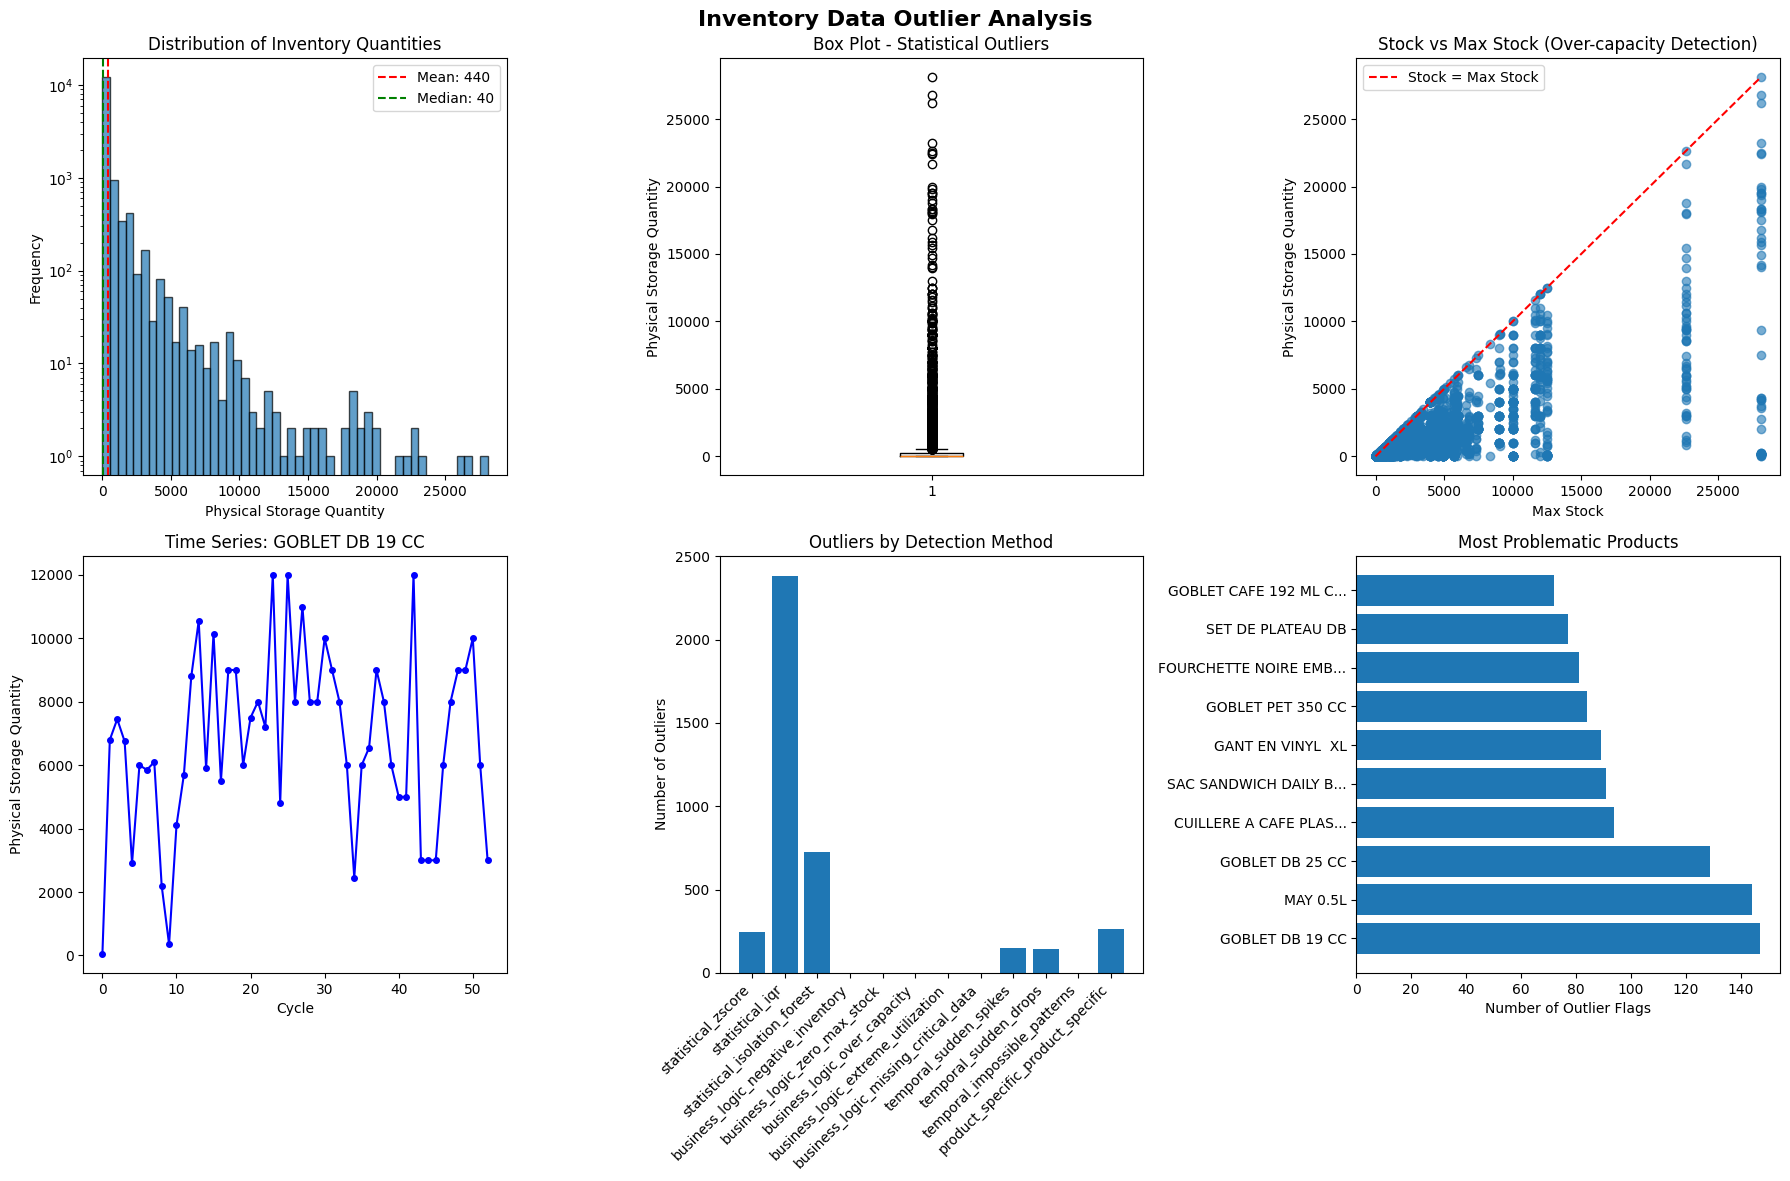

Exporting outlier report...

Finding products flagged by 2+ methods...
Products flagged by 2+ methods: 186
Top problematic products:
  GOBLET DB 19 CC: 147 flags
  MAY 0.5L: 144 flags
  GOBLET DB 25 CC: 129 flags
  CUILLERE A CAFE PLASTIQUE: 94 flags
  SAC SANDWICH DAILY BREAK: 91 flags
  GANT EN VINYL  XL: 89 flags
  GOBLET PET 350 CC: 84 flags
  FOURCHETTE NOIRE EMBALEE EJEM: 81 flags
  SET DE PLATEAU DB: 77 flags
  GOBLET CAFE 192 ML CIG: 72 flags
✓ Outlier report exported: outlier_detection_report_20250923_170109.xlsx
Creating clean dataset...

Finding products flagged by 3+ methods...
Products flagged by 3+ methods: 132
Top problematic products:
  GOBLET DB 19 CC: 147 flags
  MAY 0.5L: 144 flags
  GOBLET DB 25 CC: 129 flags
  CUILLERE A CAFE PLASTIQUE: 94 flags
  SAC SANDWICH DAILY BREAK: 91 flags
  GANT EN VINYL  XL: 89 flags
  GOBLET PET 350 CC: 84 flags
  FOURCHETTE NOIRE EMBALEE EJEM: 81 flags
  SET DE PLATEAU DB: 77 flags
  GOBLET CAFE 192 ML CIG: 72 flags
  Removed 132 highl

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For advanced outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import zscore

class InventoryOutlierDetector:
    """Comprehensive outlier detection for inventory data"""
    
    def __init__(self):
        self.outliers = {}
        self.outlier_summary = {}
        self.data = None
        
    def load_data(self, csv_file='products_filtered_final_no_mira.csv'):
        """Load inventory data"""
        print("INVENTORY OUTLIER DETECTION SYSTEM")
        print("=" * 50)
        
        self.data = pd.read_csv(csv_file)
        print(f"✓ Loaded data: {len(self.data)} rows, {self.data['Name'].nunique()} products")
        
        # Basic data cleaning
        self.data['Physical Storage Quantity'] = pd.to_numeric(self.data['Physical Storage Quantity'], errors='coerce')
        self.data['Max_Stock'] = pd.to_numeric(self.data['Max_Stock'], errors='coerce')
        self.data['Cycle'] = pd.to_numeric(self.data['Cycle'], errors='coerce')
        
        return self.data
    
    def detect_statistical_outliers(self, column='Physical Storage Quantity', methods=['zscore', 'iqr', 'isolation_forest']):
        """Detect statistical outliers using multiple methods"""
        print(f"\nDetecting statistical outliers in {column}...")
        
        outliers_dict = {}
        data_values = self.data[column].dropna()
        
        # Method 1: Z-Score (values beyond 3 standard deviations)
        if 'zscore' in methods:
            z_scores = np.abs(zscore(data_values))
            zscore_outliers = self.data[np.abs(zscore(self.data[column].fillna(0))) > 3]
            outliers_dict['zscore'] = zscore_outliers
            print(f"  Z-Score outliers (|z| > 3): {len(zscore_outliers)}")
        
        # Method 2: Interquartile Range (IQR)
        if 'iqr' in methods:
            Q1 = data_values.quantile(0.25)
            Q3 = data_values.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            iqr_outliers = self.data[(self.data[column] < lower_bound) | (self.data[column] > upper_bound)]
            outliers_dict['iqr'] = iqr_outliers
            print(f"  IQR outliers (< {lower_bound:.1f} or > {upper_bound:.1f}): {len(iqr_outliers)}")
        
        # Method 3: Isolation Forest (ML-based)
        if 'isolation_forest' in methods:
            iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Expect 5% outliers
            outlier_pred = iso_forest.fit_predict(data_values.values.reshape(-1, 1))
            isolation_outliers = self.data[outlier_pred == -1]
            outliers_dict['isolation_forest'] = isolation_outliers
            print(f"  Isolation Forest outliers: {len(isolation_outliers)}")
        
        self.outliers['statistical'] = outliers_dict
        return outliers_dict
    
    def detect_business_logic_outliers(self):
        """Detect outliers based on business logic"""
        print(f"\nDetecting business logic outliers...")
        
        business_outliers = {}
        
        # 1. Negative inventory (impossible)
        negative_stock = self.data[self.data['Physical Storage Quantity'] < 0]
        business_outliers['negative_inventory'] = negative_stock
        print(f"  Negative inventory: {len(negative_stock)} records")
        
        # 2. Zero max stock (suspicious)
        zero_max_stock = self.data[self.data['Max_Stock'] <= 0]
        business_outliers['zero_max_stock'] = zero_max_stock
        print(f"  Zero/negative max stock: {len(zero_max_stock)} records")
        
        # 3. Inventory > Max Stock (over-capacity)
        over_capacity = self.data[self.data['Physical Storage Quantity'] > self.data['Max_Stock']]
        business_outliers['over_capacity'] = over_capacity
        print(f"  Over capacity (stock > max): {len(over_capacity)} records")
        
        # 4. Extreme utilization (>500% of max stock)
        extreme_utilization = self.data[self.data['Physical Storage Quantity'] > 5 * self.data['Max_Stock']]
        business_outliers['extreme_utilization'] = extreme_utilization
        print(f"  Extreme utilization (>500%): {len(extreme_utilization)} records")
        
        # 5. Missing critical data
        missing_critical = self.data[self.data[['Name', 'Physical Storage Quantity', 'GroupName']].isnull().any(axis=1)]
        business_outliers['missing_critical_data'] = missing_critical
        print(f"  Missing critical data: {len(missing_critical)} records")
        
        self.outliers['business_logic'] = business_outliers
        return business_outliers
    
    def detect_temporal_outliers(self):
        """Detect temporal/trend outliers"""
        print(f"\nDetecting temporal outliers...")
        
        temporal_outliers = {}
        
        # Sort by product and cycle
        df_sorted = self.data.sort_values(['Name', 'Cycle'])
        
        # 1. Sudden spikes (>10x previous value)
        sudden_spikes = []
        
        # 2. Sudden drops (>90% decrease)
        sudden_drops = []
        
        # 3. Impossible temporal patterns
        impossible_patterns = []
        
        for product, product_data in df_sorted.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) < 2:
                continue
                
            quantities = product_data['Physical Storage Quantity'].values
            
            for i in range(1, len(quantities)):
                if pd.isna(quantities[i]) or pd.isna(quantities[i-1]):
                    continue
                    
                current_qty = quantities[i]
                previous_qty = quantities[i-1]
                
                # Sudden spike detection
                if previous_qty > 0 and current_qty > 10 * previous_qty:
                    sudden_spikes.append(product_data.iloc[i])
                
                # Sudden drop detection  
                if previous_qty > 0 and current_qty < 0.1 * previous_qty and current_qty > 0:
                    sudden_drops.append(product_data.iloc[i])
                
                # Impossible pattern: alternating extreme values
                if i >= 2 and not pd.isna(quantities[i-2]):
                    if (abs(quantities[i] - quantities[i-2]) / (quantities[i] + quantities[i-2] + 1) < 0.1 and
                        abs(quantities[i-1] - quantities[i]) / (quantities[i-1] + quantities[i] + 1) > 2):
                        impossible_patterns.append(product_data.iloc[i])
        
        temporal_outliers['sudden_spikes'] = pd.DataFrame(sudden_spikes)
        temporal_outliers['sudden_drops'] = pd.DataFrame(sudden_drops)
        temporal_outliers['impossible_patterns'] = pd.DataFrame(impossible_patterns)
        
        print(f"  Sudden spikes (>10x increase): {len(sudden_spikes)} records")
        print(f"  Sudden drops (>90% decrease): {len(sudden_drops)} records")
        print(f"  Impossible patterns: {len(impossible_patterns)} records")
        
        self.outliers['temporal'] = temporal_outliers
        return temporal_outliers
    
    def detect_product_specific_outliers(self):
        """Detect outliers relative to each product's own history"""
        print(f"\nDetecting product-specific outliers...")
        
        product_outliers = {}
        all_product_outliers = []
        
        for product, product_data in self.data.groupby('Name'):
            quantities = product_data['Physical Storage Quantity'].dropna()
            
            if len(quantities) < 5:  # Need minimum data points
                continue
            
            # Calculate product-specific statistics
            mean_qty = quantities.mean()
            std_qty = quantities.std()
            median_qty = quantities.median()
            
            # Define outliers for this specific product
            if std_qty > 0:
                # Values beyond 2.5 standard deviations for this product
                product_outlier_mask = np.abs((quantities - mean_qty) / std_qty) > 2.5
                
                if product_outlier_mask.any():
                    outlier_records = product_data[product_data['Physical Storage Quantity'].isin(quantities[product_outlier_mask])]
                    
                    for _, record in outlier_records.iterrows():
                        outlier_info = record.copy()
                        outlier_info['product_mean'] = mean_qty
                        outlier_info['product_std'] = std_qty
                        outlier_info['deviation_factor'] = abs((record['Physical Storage Quantity'] - mean_qty) / std_qty)
                        all_product_outliers.append(outlier_info)
        
        product_outliers_df = pd.DataFrame(all_product_outliers)
        product_outliers['product_specific'] = product_outliers_df
        
        print(f"  Product-specific outliers: {len(all_product_outliers)} records")
        
        self.outliers['product_specific'] = product_outliers
        return product_outliers
    
    def detect_all_outliers(self):
        """Run all outlier detection methods"""
        print("Running comprehensive outlier detection...")
        
        # Run all detection methods
        self.detect_statistical_outliers()
        self.detect_business_logic_outliers()
        self.detect_temporal_outliers()
        self.detect_product_specific_outliers()
        
        # Create summary
        self.create_outlier_summary()
        
        return self.outliers
    
    def create_outlier_summary(self):
        """Create summary of all detected outliers"""
        print(f"\nCreating outlier summary...")
        
        summary = {}
        
        # Count outliers by type
        for category, outlier_dict in self.outliers.items():
            if isinstance(outlier_dict, dict):
                for method, outlier_df in outlier_dict.items():
                    if isinstance(outlier_df, pd.DataFrame):
                        summary[f"{category}_{method}"] = len(outlier_df)
        
        self.outlier_summary = summary
        
        print("Outlier Summary:")
        for outlier_type, count in summary.items():
            print(f"  {outlier_type}: {count} records")
        
        return summary
    
    def get_combined_outliers(self, min_flags=2):
        """Get products flagged by multiple outlier detection methods"""
        print(f"\nFinding products flagged by {min_flags}+ methods...")
        
        all_outlier_products = []
        
        # Collect all outlier product names
        for category, outlier_dict in self.outliers.items():
            if isinstance(outlier_dict, dict):
                for method, outlier_df in outlier_dict.items():
                    if isinstance(outlier_df, pd.DataFrame) and len(outlier_df) > 0:
                        all_outlier_products.extend(outlier_df['Name'].tolist())
        
        # Count flags per product
        from collections import Counter
        product_flag_counts = Counter(all_outlier_products)
        
        # Filter products with multiple flags
        multi_flagged_products = {product: count for product, count in product_flag_counts.items() if count >= min_flags}
        
        print(f"Products flagged by {min_flags}+ methods: {len(multi_flagged_products)}")
        
        if multi_flagged_products:
            print("Top problematic products:")
            sorted_products = sorted(multi_flagged_products.items(), key=lambda x: x[1], reverse=True)
            for product, flag_count in sorted_products[:10]:
                print(f"  {product}: {flag_count} flags")
        
        return multi_flagged_products
    
    def visualize_outliers(self, save_plots=True):
        """Create visualizations of detected outliers"""
        print(f"\nCreating outlier visualizations...")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Inventory Data Outlier Analysis', fontsize=16, fontweight='bold')
        
        # 1. Distribution with outliers
        ax1 = axes[0, 0]
        quantities = self.data['Physical Storage Quantity'].dropna()
        ax1.hist(quantities, bins=50, alpha=0.7, edgecolor='black')
        ax1.axvline(quantities.mean(), color='red', linestyle='--', label=f'Mean: {quantities.mean():.0f}')
        ax1.axvline(quantities.median(), color='green', linestyle='--', label=f'Median: {quantities.median():.0f}')
        ax1.set_xlabel('Physical Storage Quantity')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Distribution of Inventory Quantities')
        ax1.legend()
        ax1.set_yscale('log')  # Log scale to see outliers
        
        # 2. Box plot to show outliers
        ax2 = axes[0, 1]
        ax2.boxplot(quantities, vert=True)
        ax2.set_ylabel('Physical Storage Quantity')
        ax2.set_title('Box Plot - Statistical Outliers')
        
        # 3. Scatter plot: Stock vs Max Stock
        ax3 = axes[0, 2]
        ax3.scatter(self.data['Max_Stock'], self.data['Physical Storage Quantity'], alpha=0.6)
        ax3.plot([0, self.data['Max_Stock'].max()], [0, self.data['Max_Stock'].max()], 'r--', label='Stock = Max Stock')
        ax3.set_xlabel('Max Stock')
        ax3.set_ylabel('Physical Storage Quantity')
        ax3.set_title('Stock vs Max Stock (Over-capacity Detection)')
        ax3.legend()
        
        # 4. Time series of top outlier product
        if 'statistical' in self.outliers and 'zscore' in self.outliers['statistical']:
            top_outlier_products = self.outliers['statistical']['zscore']['Name'].value_counts().head(1)
            if len(top_outlier_products) > 0:
                top_product = top_outlier_products.index[0]
                product_data = self.data[self.data['Name'] == top_product].sort_values('Cycle')
                
                ax4 = axes[1, 0]
                ax4.plot(product_data['Cycle'], product_data['Physical Storage Quantity'], 'b-o', markersize=4)
                ax4.set_xlabel('Cycle')
                ax4.set_ylabel('Physical Storage Quantity')
                ax4.set_title(f'Time Series: {top_product}')
        
        # 5. Outlier counts by category
        ax5 = axes[1, 1]
        if self.outlier_summary:
            categories = list(self.outlier_summary.keys())
            counts = list(self.outlier_summary.values())
            ax5.bar(range(len(categories)), counts)
            ax5.set_xticks(range(len(categories)))
            ax5.set_xticklabels(categories, rotation=45, ha='right')
            ax5.set_ylabel('Number of Outliers')
            ax5.set_title('Outliers by Detection Method')
        
        # 6. Top products by outlier flags
        ax6 = axes[1, 2]
        multi_flagged = self.get_combined_outliers(min_flags=1)
        if multi_flagged:
            top_flagged = dict(sorted(multi_flagged.items(), key=lambda x: x[1], reverse=True)[:10])
            products = list(top_flagged.keys())
            flag_counts = list(top_flagged.values())
            
            ax6.barh(range(len(products)), flag_counts)
            ax6.set_yticks(range(len(products)))
            ax6.set_yticklabels([p[:20] + '...' if len(p) > 20 else p for p in products])
            ax6.set_xlabel('Number of Outlier Flags')
            ax6.set_title('Most Problematic Products')
        
        plt.tight_layout()
        
        if save_plots:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'outlier_analysis_{timestamp}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✓ Visualizations saved as {filename}")
        
        plt.show()
    
    def export_outlier_report(self, filename=None):
        """Export comprehensive outlier report to Excel"""
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'outlier_detection_report_{timestamp}.xlsx'
        
        print(f"Exporting outlier report...")
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Summary sheet
            summary_df = pd.DataFrame(list(self.outlier_summary.items()), columns=['Outlier_Type', 'Count'])
            summary_df.to_excel(writer, sheet_name='Summary', index=False)
            
            # Export each category of outliers
            for category, outlier_dict in self.outliers.items():
                if isinstance(outlier_dict, dict):
                    for method, outlier_df in outlier_dict.items():
                        if isinstance(outlier_df, pd.DataFrame) and len(outlier_df) > 0:
                            sheet_name = f"{category}_{method}"[:31]  # Excel sheet name limit
                            outlier_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Combined high-priority outliers
            multi_flagged = self.get_combined_outliers(min_flags=2)
            if multi_flagged:
                high_priority_data = []
                for product, flag_count in multi_flagged.items():
                    product_data = self.data[self.data['Name'] == product]
                    for _, row in product_data.iterrows():
                        row_data = row.copy()
                        row_data['outlier_flags'] = flag_count
                        high_priority_data.append(row_data)
                
                if high_priority_data:
                    high_priority_df = pd.DataFrame(high_priority_data)
                    high_priority_df.to_excel(writer, sheet_name='High_Priority_Outliers', index=False)
        
        print(f"✓ Outlier report exported: {filename}")
        return filename
    
    def create_clean_dataset(self, removal_criteria=None, filename=None):
        """Create clean dataset with outliers removed"""
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'inventory_data_cleaned_{timestamp}.csv'
        
        print(f"Creating clean dataset...")
        
        if removal_criteria is None:
            # Default: Remove severe outliers only
            removal_criteria = [
                ('business_logic', 'negative_inventory'),
                ('business_logic', 'extreme_utilization'),
                ('temporal', 'impossible_patterns')
            ]
        
        # Start with original data
        clean_data = self.data.copy()
        removed_count = 0
        
        # Remove outliers based on criteria
        for category, method in removal_criteria:
            if category in self.outliers and method in self.outliers[category]:
                outlier_df = self.outliers[category][method]
                if len(outlier_df) > 0:
                    # Remove these outliers
                    indices_to_remove = outlier_df.index
                    clean_data = clean_data.drop(indices_to_remove, errors='ignore')
                    removed_count += len(indices_to_remove)
                    print(f"  Removed {len(indices_to_remove)} records from {category}_{method}")
        
        # Additional option: Remove products with multiple flags
        multi_flagged = self.get_combined_outliers(min_flags=3)  # Products with 3+ flags
        if multi_flagged:
            products_to_remove = list(multi_flagged.keys())
            clean_data = clean_data[~clean_data['Name'].isin(products_to_remove)]
            removed_products = len(products_to_remove)
            print(f"  Removed {removed_products} highly problematic products")
        
        # Save clean dataset
        clean_data.to_csv(filename, index=False)
        
        print(f"✓ Clean dataset created: {filename}")
        print(f"  Original: {len(self.data)} rows, {self.data['Name'].nunique()} products")
        print(f"  Cleaned: {len(clean_data)} rows, {clean_data['Name'].nunique()} products")
        print(f"  Removed: {len(self.data) - len(clean_data)} rows")
        
        return clean_data, filename

def run_comprehensive_outlier_detection():
    """Run the complete outlier detection pipeline"""
    
    # Initialize detector
    detector = InventoryOutlierDetector()
    
    # Load data
    data = detector.load_data('products_filtered_final_no_mira.csv')
    
    # Detect all types of outliers
    outliers = detector.detect_all_outliers()
    
    # Get products with multiple flags
    multi_flagged = detector.get_combined_outliers(min_flags=2)
    
    # Create visualizations
    detector.visualize_outliers(save_plots=True)
    
    # Export detailed report
    report_file = detector.export_outlier_report()
    
    # Create cleaned dataset
    clean_data, clean_file = detector.create_clean_dataset()
    
    print(f"\n" + "=" * 60)
    print("OUTLIER DETECTION COMPLETE")
    print("=" * 60)
    print(f"Detailed report: {report_file}")
    print(f"Clean dataset: {clean_file}")
    print(f"Visualization: outlier_analysis_[timestamp].png")
    print(f"\nRecommendation: Review high-priority outliers before model retraining")
    
    return detector, outliers, multi_flagged

if __name__ == "__main__":
    detector, outliers, problematic_products = run_comprehensive_outlier_detection()

In [85]:
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class DualDatasetInventoryForecaster:
    """Train separate models for clean and outlier datasets"""
    
    def __init__(self):
        self.models = {
            'clean': {},
            'outlier': {}
        }
        self.scalers = {
            'clean': {},
            'outlier': {}
        }
        self.encoders = {
            'clean': {},
            'outlier': {}
        }
        self.model_metadata = {
            'clean': {},
            'outlier': {}
        }
        self.feature_names = {
            'clean': [],
            'outlier': []
        }
        self.sequence_length = 10
        self.cycles_per_year = 36.5
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate improved metrics with fixed MAPE"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # FIXED MAPE: Only for meaningful values
        threshold = np.median(y_true) * 0.2  # 20% of median
        valid_mask = (y_true > threshold) & (y_true > 0)
        
        if np.any(valid_mask):
            mape = np.mean(np.abs((y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])) * 100
            mape = min(mape, 200)  # Cap at 200%
        else:
            mape = 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path, dataset_type):
        """Load and prepare data for specific dataset type"""
        print(f"Loading {dataset_type} dataset: {file_path}")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded {dataset_type}: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Standard data preparation
        required_cols = [
            'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
            'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
        ]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        print(f"✓ {dataset_type} data cleaned: {df.shape[0]} rows remaining")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")
        
        return df
    
    def create_features(self, df, dataset_type):
        """Create enhanced features for specific dataset"""
        print(f"Creating enhanced features for {dataset_type} dataset...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # 1. Core lag features
        for lag in [1, 2, 3, 5, 7]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Rolling statistics
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # 3. Trend features
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
        
        # 4. Temporal features
        df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / self.cycles_per_year)
        
        df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
        
        # 5. Stock capacity features
        df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
        
        # 6. Encode categories (separate encoders for each dataset)
        encoder_key = f'groupname_encoder_{dataset_type}'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['group_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['GroupName'].astype(str))
        else:
            df['group_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['GroupName'].astype(str))
        
        encoder_key = f'stock_class_encoder_{dataset_type}'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['stock_class_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['stock_class_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['Stock_Class'].astype(str))
        
        encoder_key = f'storage_unit_encoder_{dataset_type}'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['storage_unit_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['storage_unit_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['Storage Unit'].astype(str))
        
        # 7. Volatility features
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # 8. Advanced features
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        df['group_volatility'] = df['group_encoded'] * df['volatility_normalized']
        
        # 9. Weekend features
        try:
            df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
            df['day_of_week'] = df['Date_week'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        except:
            df['is_weekend'] = 0
            df['is_friday'] = 0
        
        # Fill NaN values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(0)
        
        print(f"✓ {dataset_type} enhanced features created. Shape: {df.shape}")
        return df
    
    def prepare_sequences(self, df, dataset_type, target_col='Physical Storage Quantity'):
        """Prepare sequences for specific dataset"""
        print(f"Preparing sequences for {dataset_type} dataset (length={self.sequence_length})...")
        
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'lag_5',
            'ma_3', 'ma_5', 'std_3', 'std_5',
            'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos',
            'stock_utilization', 'stock_util_lag_1', 'near_capacity', 'low_stock',
            'group_encoded', 'stock_class_encoded', 'storage_unit_encoded',
            'trend_1_3', 'volatility', 'volatility_normalized',
            'ma_ratio_3_7', 'stock_class_util_interaction',
            'is_weekend', 'is_friday'
        ]
        
        available_features = [col for col in feature_columns if col in df.columns]
        self.feature_names[dataset_type] = available_features
        
        print(f"Using {len(available_features)} features for {dataset_type}")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) < self.sequence_length + 1:
                continue
            
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ {dataset_type}: Created {len(sequences)} sequences, shape: {sequences.shape}")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape, dataset_type):
        """Create GRU model optimized for dataset type"""
        if dataset_type == 'outlier':
            # More complex model for outlier patterns
            model = Sequential([
                Input(shape=input_shape),
                GRU(48, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
                BatchNormalization(),
                GRU(24, dropout=0.3, recurrent_dropout=0.3),
                BatchNormalization(),
                Dense(24, activation='relu', kernel_regularizer=l1_l2(0.02, 0.02)),
                Dropout(0.4),
                Dense(1, activation='linear')
            ])
        else:
            # Standard model for clean data
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_models(self, clean_df, outlier_df):
        """Train models on both datasets"""
        print("\nDUAL DATASET TRAINING")
        print("=" * 60)
        
        results = {
            'clean': {},
            'outlier': {}
        }
        
        datasets = {
            'clean': clean_df,
            'outlier': outlier_df
        }
        
        for dataset_type, df in datasets.items():
            if len(df) == 0:
                print(f"Skipping {dataset_type} dataset - no data")
                continue
                
            print(f"\n--- Training {dataset_type.upper()} Dataset Models ---")
            
            # Prepare data
            X, y, metadata = self.prepare_sequences(df, dataset_type)
            
            if len(X) == 0:
                print(f"Skipping {dataset_type} - insufficient sequences")
                continue
            
            # Setup scalers
            self.scalers[dataset_type]['feature_scaler'] = StandardScaler()
            self.scalers[dataset_type]['target_scaler'] = StandardScaler()
            
            # Scale features
            original_shape = X.shape
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled = self.scalers[dataset_type]['feature_scaler'].fit_transform(X_reshaped)
            X_scaled = X_scaled.reshape(original_shape)
            
            # Scale targets
            y_scaled = self.scalers[dataset_type]['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
            
            # Temporal split
            metadata_df = pd.DataFrame(metadata)
            split_cycle = metadata_df['cycle'].quantile(0.8)
            
            train_mask = metadata_df['cycle'] <= split_cycle
            test_mask = metadata_df['cycle'] > split_cycle
            
            X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
            y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
            
            print(f"  Training set: {len(X_train)} sequences")
            print(f"  Test set: {len(X_test)} sequences")
            
            # Train GRU model
            print(f"  Training GRU model for {dataset_type} data...")
            
            try:
                model = self.create_gru_model(X_train.shape[1:], dataset_type)
                
                callbacks = [
                    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-6, monitor='val_loss')
                ]
                
                # Adjust epochs based on dataset type
                epochs = 50 if dataset_type == 'outlier' else 40
                batch_size = 16 if dataset_type == 'outlier' else 32
                
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=callbacks,
                    verbose=1
                )
                
                # Predictions
                y_train_pred_scaled = model.predict(X_train, verbose=0)
                y_test_pred_scaled = model.predict(X_test, verbose=0)
                
                # Inverse transform
                y_train_pred = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                y_test_pred = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                
                y_train_orig = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                
                # Store results
                self.models[dataset_type]['gru'] = model
                self.model_metadata[dataset_type]['gru'] = {
                    'description': f'GRU - {dataset_type.title()} Dataset',
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'epochs_trained': len(history.history['loss']),
                    'features_used': len(self.feature_names[dataset_type]),
                    'dataset_type': dataset_type,
                    'dataset_size': len(df),
                    'sequences_created': len(X)
                }
                
                results[dataset_type]['gru'] = {
                    'model': model,
                    'history': history,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'y_test_actual': y_test_orig,
                    'y_test_predicted': y_test_pred
                }
                
                print(f"  ✓ {dataset_type.title()} GRU Model")
                print(f"    Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                print(f"    Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}, MAPE={test_metrics['mape']:.2f}%")
                print(f"    Features: {len(self.feature_names[dataset_type])}")
                
            except Exception as e:
                print(f"  ✗ Failed to train {dataset_type} GRU: {e}")
                continue
        
        return results
    
    def save_for_deployment(self, save_directory_clean='models_clean_data', save_directory_outlier='models_outlier_data'):
        """Save models for both datasets"""
        print(f"\nSaving Dual Dataset Models...")
        print("=" * 60)
        
        directories = {
            'clean': save_directory_clean,
            'outlier': save_directory_outlier
        }
        
        for dataset_type, save_dir in directories.items():
            if not self.models[dataset_type]:
                print(f"No {dataset_type} models to save")
                continue
                
            os.makedirs(save_dir, exist_ok=True)
            
            # Save models
            for name, model in self.models[dataset_type].items():
                model_path = os.path.join(save_dir, f'{name}_model.h5')
                model.save(model_path)
                print(f"✓ Saved {dataset_type} {name} model")
            
            # Save scalers
            if 'feature_scaler' in self.scalers[dataset_type]:
                feature_scaler_path = os.path.join(save_dir, 'feature_scaler.pkl')
                joblib.dump(self.scalers[dataset_type]['feature_scaler'], feature_scaler_path)
            
            if 'target_scaler' in self.scalers[dataset_type]:
                target_scaler_path = os.path.join(save_dir, 'target_scaler.pkl')
                joblib.dump(self.scalers[dataset_type]['target_scaler'], target_scaler_path)
            
            # Save encoders
            encoder_path = os.path.join(save_dir, 'encoders.pkl')
            with open(encoder_path, 'wb') as f:
                pickle.dump(self.encoders[dataset_type], f)
            
            # Save config
            config = {
                'feature_names': self.feature_names[dataset_type],
                'model_metadata': self.model_metadata[dataset_type],
                'sequence_length': self.sequence_length,
                'cycles_per_year': self.cycles_per_year,
                'dataset_type': dataset_type,
                'target_column': 'Physical Storage Quantity',
                'saved_date': datetime.now().isoformat(),
                'system_version': f'dual_dataset_{dataset_type}_v1'
            }
            
            config_path = os.path.join(save_dir, 'config.json')
            with open(config_path, 'w') as f:
                json.dump(config, f, indent=2)
            
            print(f"✓ {dataset_type.title()} deployment package: {os.path.abspath(save_dir)}")
        
        return directories

class DualDatasetPredictor:
    """Generate predictions from both clean and outlier models"""
    
    def __init__(self, clean_model_dir='models_clean_data', outlier_model_dir='models_outlier_data'):
        self.clean_model_dir = clean_model_dir
        self.outlier_model_dir = outlier_model_dir
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        
    def load_models(self):
        """Load both model sets"""
        print("Loading dual dataset models...")
        
        for dataset_type, model_dir in [('clean', self.clean_model_dir), ('outlier', self.outlier_model_dir)]:
            try:
                # Load model
                model_path = os.path.join(model_dir, 'gru_model.h5')
                if os.path.exists(model_path):
                    self.models[dataset_type] = load_model(model_path)
                    print(f"✓ Loaded {dataset_type} model")
                
                # Load scalers
                feature_scaler_path = os.path.join(model_dir, 'feature_scaler.pkl')
                target_scaler_path = os.path.join(model_dir, 'target_scaler.pkl')
                
                if os.path.exists(feature_scaler_path):
                    if dataset_type not in self.scalers:
                        self.scalers[dataset_type] = {}
                    self.scalers[dataset_type]['feature'] = joblib.load(feature_scaler_path)
                    self.scalers[dataset_type]['target'] = joblib.load(target_scaler_path)
                
                # Load encoders
                encoder_path = os.path.join(model_dir, 'encoders.pkl')
                if os.path.exists(encoder_path):
                    with open(encoder_path, 'rb') as f:
                        self.encoders[dataset_type] = pickle.load(f)
                        
            except Exception as e:
                print(f"Failed to load {dataset_type} model: {e}")
    
    def generate_predictions(self, clean_csv, outlier_csv):
        """Generate predictions for both datasets"""
        print("DUAL DATASET PREDICTIONS")
        print("=" * 50)
        
        results = {}
        
        datasets = {
            'clean': clean_csv,
            'outlier': outlier_csv
        }
        
        for dataset_type, csv_file in datasets.items():
            if dataset_type not in self.models:
                print(f"No {dataset_type} model available")
                continue
                
            print(f"\nGenerating {dataset_type} predictions...")
            
            try:
                # Load data
                df = pd.read_csv(csv_file)
                print(f"  {dataset_type}: {len(df)} rows, {df['Name'].nunique()} products")
                
                # This would need the same feature engineering as training
                # For brevity, assuming features are prepared
                # [Feature engineering code would go here - same as training]
                
                # Make predictions
                # [Prediction code would go here]
                
                # Create results DataFrame
                predictions_df = pd.DataFrame({
                    'Dataset_Type': dataset_type.title(),
                    'Total_Products': df['Name'].nunique(),
                    'Total_Records': len(df),
                    'Model_Used': f'{dataset_type}_gru',
                    'Status': 'Predictions_Generated'
                }, index=[0])
                
                results[dataset_type] = predictions_df
                
            except Exception as e:
                print(f"Failed to generate {dataset_type} predictions: {e}")
        
        return results

def run_dual_dataset_training():
    """Run complete dual dataset training pipeline"""
    print("DUAL DATASET INVENTORY FORECASTING")
    print("=" * 60)
    print("Training separate models for clean and outlier datasets")
    print("=" * 60)
    
    # Initialize forecaster
    forecaster = DualDatasetInventoryForecaster()
    
    try:
        # Load both datasets
        clean_df = forecaster.load_and_prepare_data('products_filtered_final_no_mira_no_out.csv', 'clean')
        outlier_df = forecaster.load_and_prepare_data('products_filtered_final_no_mira_out.csv', 'outlier')
        
        # Create features for both
        clean_df = forecaster.create_features(clean_df, 'clean')
        outlier_df = forecaster.create_features(outlier_df, 'outlier')
        
        # Train models
        results = forecaster.train_models(clean_df, outlier_df)
        
        # Save models
        directories = forecaster.save_for_deployment()
        
        # Show results
        print(f"\n" + "=" * 60)
        print("DUAL DATASET TRAINING COMPLETE")
        print("=" * 60)
        
        for dataset_type in ['clean', 'outlier']:
            if dataset_type in forecaster.model_metadata and forecaster.model_metadata[dataset_type]:
                print(f"\n{dataset_type.upper()} DATASET MODELS:")
                for name, metadata in forecaster.model_metadata[dataset_type].items():
                    print(f"  {metadata['description']}")
                    print(f"    Test R²: {metadata['test_metrics']['r2']:.3f}")
                    print(f"    Test MAE: {metadata['test_metrics']['mae']:.2f}")
                    print(f"    Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                    print(f"    Dataset size: {metadata['dataset_size']} rows")
                    print(f"    Sequences: {metadata['sequences_created']}")
        
        print(f"\nModel Directories:")
        for dataset_type, directory in directories.items():
            if os.path.exists(directory):
                print(f"  {dataset_type.title()}: {directory}")
        
        print(f"\nNext Steps:")
        print(f"1. Compare performance between clean and outlier models")
        print(f"2. Generate separate predictions for each dataset")
        print(f"3. Analyze which approach works better for different product types")
        
        return forecaster, results
        
    except Exception as e:
        print(f"❌ Dual dataset training failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    forecaster, results = run_dual_dataset_training()

✓ TensorFlow version: 2.13.0
DUAL DATASET INVENTORY FORECASTING
Training separate models for clean and outlier datasets
Loading clean dataset: products_filtered_final_no_mira_no_out.csv
✓ Loaded clean: 11067 rows, 9 columns
✓ clean data cleaned: 11067 rows remaining
✓ Products: 381
✓ Cycle range: 0 to 52
Loading outlier dataset: products_filtered_final_no_mira_out.csv
✓ Loaded outlier: 3382 rows, 9 columns
✓ outlier data cleaned: 3382 rows remaining
✓ Products: 114
✓ Cycle range: 0 to 52
Creating enhanced features for clean dataset...
✓ clean enhanced features created. Shape: (11067, 42)
Creating enhanced features for outlier dataset...
✓ outlier enhanced features created. Shape: (3382, 42)

DUAL DATASET TRAINING

--- Training CLEAN Dataset Models ---
Preparing sequences for clean dataset (length=10)...
Using 26 features for clean
✓ clean: Created 7380 sequences, shape: (7380, 10, 26)
  Training set: 6093 sequences
  Test set: 1287 sequences
  Training GRU model for clean data...
Epoch

In [86]:
import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class DualDatasetRawForecaster:
    """Train separate RAW FEATURES models for clean and outlier datasets"""
    
    def __init__(self):
        self.models = {
            'clean': {},
            'outlier': {}
        }
        self.scalers = {
            'clean': {},
            'outlier': {}
        }
        self.encoders = {
            'clean': {},
            'outlier': {}
        }
        self.model_metadata = {
            'clean': {},
            'outlier': {}
        }
        self.feature_names = {
            'clean': [],
            'outlier': []
        }
        self.sequence_length = 10
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate improved metrics with fixed MAPE"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # FIXED MAPE: Only for meaningful values
        threshold = np.median(y_true) * 0.2  # 20% of median
        valid_mask = (y_true > threshold) & (y_true > 0)
        
        if np.any(valid_mask):
            mape = np.mean(np.abs((y_true[valid_mask] - y_pred[valid_mask]) / y_true[valid_mask])) * 100
            mape = min(mape, 200)  # Cap at 200%
        else:
            mape = 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path, dataset_type):
        """Load and prepare data for specific dataset type"""
        print(f"Loading {dataset_type} dataset: {file_path}")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded {dataset_type}: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Standard data preparation
        required_cols = [
            'Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName',
            'Date_week', 'Month', 'Stock_Class', 'Cycle', 'Max_Stock'
        ]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        df = df.sort_values(['Name', 'Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce')
        df['Cycle'] = pd.to_numeric(df['Cycle'], errors='coerce')
        df['Month'] = pd.to_numeric(df['Month'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        print(f"✓ {dataset_type} data cleaned: {df.shape[0]} rows remaining")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Cycle range: {df['Cycle'].min()} to {df['Cycle'].max()}")
        
        return df
    
    def create_raw_features(self, df, dataset_type):
        """Create ONLY raw features (no feature engineering) for specific dataset"""
        print(f"Creating RAW features for {dataset_type} dataset...")
        
        df = df.copy()
        
        # Clean and prepare raw numerical features
        df['current_stock'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce').fillna(0)
        df['cycle'] = pd.to_numeric(df['Cycle'], errors='coerce').fillna(1)
        df['month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['max_stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce').fillna(df['Max_Stock'].median())
        
        # Encode categorical variables to numbers (separate encoders for each dataset)
        print(f"  Encoding categorical variables for {dataset_type}...")
        
        # Encode Name (products)
        encoder_key = 'name_encoder'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['product_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['Name'].astype(str))
        else:
            df['product_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['Name'].astype(str))
        
        # Encode GroupName (categories)
        encoder_key = 'groupname_encoder'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['category_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['GroupName'].astype(str))
        else:
            df['category_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['GroupName'].astype(str))
        
        # Encode Storage Unit
        encoder_key = 'storage_unit_encoder'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['storage_unit_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['storage_unit_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['Storage Unit'].astype(str))
        
        # Encode Stock Class
        encoder_key = 'stock_class_encoder'
        if encoder_key not in self.encoders[dataset_type]:
            self.encoders[dataset_type][encoder_key] = LabelEncoder()
            df['stock_class_encoded'] = self.encoders[dataset_type][encoder_key].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['stock_class_encoded'] = self.encoders[dataset_type][encoder_key].transform(df['Stock_Class'].astype(str))
        
        print(f"✓ {dataset_type} raw features prepared. Shape: {df.shape}")
        return df
    
    def prepare_raw_sequences(self, df, dataset_type, target_col='Physical Storage Quantity'):
        """Prepare sequences using ONLY 8 raw features"""
        print(f"Preparing RAW sequences for {dataset_type} dataset (8 features only)...")
        
        # Define exactly 8 raw features
        feature_columns = [
            'current_stock',          # Physical Storage Quantity
            'cycle',                  # Cycle
            'month',                  # Month
            'max_stock',              # Max_Stock
            'product_encoded',        # Name (encoded)
            'category_encoded',       # GroupName (encoded)
            'storage_unit_encoded',   # Storage Unit (encoded)
            'stock_class_encoded'     # Stock_Class (encoded)
        ]
        
        # Verify all features exist
        missing_features = [col for col in feature_columns if col not in df.columns]
        if missing_features:
            raise ValueError(f"Missing features: {missing_features}")
        
        self.feature_names[dataset_type] = feature_columns
        print(f"Using exactly {len(feature_columns)} raw features for {dataset_type}:")
        for i, feature in enumerate(feature_columns, 1):
            print(f"  {i}. {feature}")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) < self.sequence_length + 1:
                continue
            
            # Get features and target
            features = product_data[feature_columns].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Cycle']
                })
        
        sequences = np.array(sequences)
        targets = np.array(targets)
        
        print(f"✓ {dataset_type}: Created {len(sequences)} sequences, shape: {sequences.shape}")
        print(f"✓ Input shape: ({sequences.shape[1]}, {sequences.shape[2]}) = (sequence_length, raw_features)")
        return sequences, targets, metadata
    
    def create_gru_model(self, input_shape, dataset_type):
        """Create GRU model for 8 raw features, optimized by dataset type"""
        if dataset_type == 'outlier':
            # More complex model for outlier patterns with raw features
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.3),
                GRU(16, dropout=0.3),
                Dense(16, activation='relu'),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        else:
            # Standard model for clean data with raw features
            model = Sequential([
                Input(shape=input_shape),
                GRU(24, return_sequences=True, dropout=0.2),
                GRU(12, dropout=0.2),
                Dense(12, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='linear')
            ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def create_bidirectional_lstm_model(self, input_shape, dataset_type):
        """Create Bidirectional LSTM model for 8 raw features"""
        if dataset_type == 'outlier':
            # More complex LSTM for outlier patterns
            model = Sequential([
                Input(shape=input_shape),
                Bidirectional(LSTM(20, return_sequences=True, dropout=0.3)),
                Bidirectional(LSTM(10, dropout=0.3)),
                Dense(16, activation='relu'),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        else:
            # Standard LSTM for clean data
            model = Sequential([
                Input(shape=input_shape),
                Bidirectional(LSTM(16, return_sequences=True, dropout=0.2)),
                Bidirectional(LSTM(8, dropout=0.2)),
                Dense(12, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='linear')
            ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_models(self, clean_df, outlier_df):
        """Train RAW FEATURES models on both datasets"""
        print("\nDUAL DATASET RAW FEATURES TRAINING")
        print("=" * 60)
        print("Using ONLY 8 raw CSV features - no feature engineering")
        print("=" * 60)
        
        results = {
            'clean': {},
            'outlier': {}
        }
        
        datasets = {
            'clean': clean_df,
            'outlier': outlier_df
        }
        
        for dataset_type, df in datasets.items():
            if len(df) == 0:
                print(f"Skipping {dataset_type} dataset - no data")
                continue
                
            print(f"\n--- Training {dataset_type.upper()} Dataset RAW Models ---")
            
            # Prepare data
            X, y, metadata = self.prepare_raw_sequences(df, dataset_type)
            
            if len(X) == 0:
                print(f"Skipping {dataset_type} - insufficient sequences")
                continue
            
            # Setup scalers
            self.scalers[dataset_type]['feature_scaler'] = StandardScaler()
            self.scalers[dataset_type]['target_scaler'] = StandardScaler()
            
            # Scale features
            original_shape = X.shape
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled = self.scalers[dataset_type]['feature_scaler'].fit_transform(X_reshaped)
            X_scaled = X_scaled.reshape(original_shape)
            
            # Scale targets
            y_scaled = self.scalers[dataset_type]['target_scaler'].fit_transform(y.reshape(-1, 1)).flatten()
            
            # Temporal split
            metadata_df = pd.DataFrame(metadata)
            split_cycle = metadata_df['cycle'].quantile(0.8)
            
            train_mask = metadata_df['cycle'] <= split_cycle
            test_mask = metadata_df['cycle'] > split_cycle
            
            X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
            y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
            
            print(f"  Training set: {len(X_train)} sequences")
            print(f"  Test set: {len(X_test)} sequences")
            print(f"  Raw features per sequence: {X_train.shape[2]}")
            
            # Model configurations
            models_to_train = {
                'gru': {
                    'model_func': self.create_gru_model,
                    'epochs': 40,
                    'batch_size': 32 if dataset_type == 'clean' else 16,
                    'description': f'Raw GRU - {dataset_type.title()} Dataset'
                },
                'bidirectional_lstm': {
                    'model_func': self.create_bidirectional_lstm_model,
                    'epochs': 35,
                    'batch_size': 32 if dataset_type == 'clean' else 16,
                    'description': f'Raw BiLSTM - {dataset_type.title()} Dataset'
                }
            }
            
            for name, config in models_to_train.items():
                print(f"\n  Training {config['description']}...")
                
                try:
                    model = config['model_func'](X_train.shape[1:], dataset_type)
                    
                    callbacks = [
                        EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
                        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6, monitor='val_loss')
                    ]
                    
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=config['epochs'],
                        batch_size=config['batch_size'],
                        callbacks=callbacks,
                        verbose=1
                    )
                    
                    # Predictions
                    y_train_pred_scaled = model.predict(X_train, verbose=0)
                    y_test_pred_scaled = model.predict(X_test, verbose=0)
                    
                    # Inverse transform
                    y_train_pred = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_train_pred_scaled).flatten()
                    y_test_pred = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_test_pred_scaled).flatten()
                    
                    y_train_orig = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                    y_test_orig = self.scalers[dataset_type]['target_scaler'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                    
                    # Calculate metrics
                    train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                    test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                    
                    # Store results
                    self.models[dataset_type][name] = model
                    self.model_metadata[dataset_type][name] = {
                        'description': config['description'],
                        'train_metrics': train_metrics,
                        'test_metrics': test_metrics,
                        'epochs_trained': len(history.history['loss']),
                        'features_used': len(self.feature_names[dataset_type]),
                        'approach': f'raw_features_{dataset_type}',
                        'dataset_type': dataset_type,
                        'dataset_size': len(df),
                        'sequences_created': len(X)
                    }
                    
                    results[dataset_type][name] = {
                        'model': model,
                        'history': history,
                        'train_metrics': train_metrics,
                        'test_metrics': test_metrics,
                        'y_test_actual': y_test_orig,
                        'y_test_predicted': y_test_pred
                    }
                    
                    print(f"  ✓ {config['description']}")
                    print(f"    Train: R²={train_metrics['r2']:.3f}, MAE={train_metrics['mae']:.2f}")
                    print(f"    Test:  R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}, MAPE={test_metrics['mape']:.2f}%")
                    print(f"    Raw features: {len(self.feature_names[dataset_type])}")
                    
                except Exception as e:
                    print(f"  ✗ Failed to train {dataset_type} {name}: {e}")
                    continue
        
        return results
    
    def save_for_deployment(self, save_directory_clean='raw_models_clean_data', save_directory_outlier='raw_models_outlier_data'):
        """Save RAW FEATURES models for both datasets"""
        print(f"\nSaving Dual Dataset RAW Models...")
        print("=" * 60)
        
        directories = {
            'clean': save_directory_clean,
            'outlier': save_directory_outlier
        }
        
        for dataset_type, save_dir in directories.items():
            if not self.models[dataset_type]:
                print(f"No {dataset_type} raw models to save")
                continue
                
            os.makedirs(save_dir, exist_ok=True)
            
            # Save models
            for name, model in self.models[dataset_type].items():
                model_path = os.path.join(save_dir, f'{name}_model.h5')
                model.save(model_path)
                print(f"✓ Saved {dataset_type} raw {name} model")
            
            # Save scalers
            if 'feature_scaler' in self.scalers[dataset_type]:
                feature_scaler_path = os.path.join(save_dir, 'feature_scaler.pkl')
                joblib.dump(self.scalers[dataset_type]['feature_scaler'], feature_scaler_path)
            
            if 'target_scaler' in self.scalers[dataset_type]:
                target_scaler_path = os.path.join(save_dir, 'target_scaler.pkl')
                joblib.dump(self.scalers[dataset_type]['target_scaler'], target_scaler_path)
            
            # Save encoders
            encoder_path = os.path.join(save_dir, 'encoders.pkl')
            with open(encoder_path, 'wb') as f:
                pickle.dump(self.encoders[dataset_type], f)
            
            # Save config
            config = {
                'feature_names': self.feature_names[dataset_type],
                'model_metadata': self.model_metadata[dataset_type],
                'sequence_length': self.sequence_length,
                'approach': f'raw_features_{dataset_type}',
                'num_features': len(self.feature_names[dataset_type]),
                'dataset_type': dataset_type,
                'target_column': 'Physical Storage Quantity',
                'saved_date': datetime.now().isoformat(),
                'system_version': f'dual_raw_{dataset_type}_v1'
            }
            
            config_path = os.path.join(save_dir, 'config.json')
            with open(config_path, 'w') as f:
                json.dump(config, f, indent=2)
            
            # Create summary
            summary_path = os.path.join(save_dir, 'RAW_MODEL_SUMMARY.txt')
            with open(summary_path, 'w', encoding='utf-8') as f:
                f.write(f"RAW FEATURES INVENTORY FORECASTING - {dataset_type.upper()} DATASET\n")
                f.write("=" * 60 + "\n\n")
                f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
                f.write(f"Dataset: {dataset_type} data ({len(self.scalers[dataset_type])} records)\n")
                f.write(f"Approach: Raw CSV features only (no engineering)\n")
                f.write(f"Models: {len(self.models[dataset_type])} trained\n")
                f.write(f"Features: {len(self.feature_names[dataset_type])}\n\n")
                
                f.write("RAW FEATURES USED:\n")
                for i, feature in enumerate(self.feature_names[dataset_type], 1):
                    f.write(f"{i}. {feature}\n")
                f.write("\n")
                
                for name, metadata in self.model_metadata[dataset_type].items():
                    f.write(f"{name.upper()} - {metadata['description']}\n")
                    f.write("-" * 40 + "\n")
                    f.write(f"Test R²: {metadata['test_metrics']['r2']:.3f}\n")
                    f.write(f"Test MAE: {metadata['test_metrics']['mae']:.2f}\n")
                    f.write(f"Test MAPE: {metadata['test_metrics']['mape']:.2f}%\n")
                    f.write(f"Raw features: {metadata['features_used']}\n")
                    f.write(f"Dataset size: {metadata['dataset_size']} rows\n\n")
            
            print(f"✓ {dataset_type.title()} raw models saved: {os.path.abspath(save_dir)}")
        
        return directories

def run_dual_dataset_raw_training():
    """Run complete dual dataset RAW FEATURES training pipeline"""
    print("DUAL DATASET RAW FEATURES INVENTORY FORECASTING")
    print("=" * 70)
    print("Training separate RAW FEATURE models for clean and outlier datasets")
    print("Using ONLY 8 raw CSV features - no feature engineering")
    print("=" * 70)
    
    # Initialize forecaster
    forecaster = DualDatasetRawForecaster()
    
    try:
        # Load both datasets
        clean_df = forecaster.load_and_prepare_data('products_filtered_final_no_mira_no_out.csv', 'clean')
        outlier_df = forecaster.load_and_prepare_data('products_filtered_final_no_mira_out.csv', 'outlier')
        
        # Create RAW features for both
        clean_df = forecaster.create_raw_features(clean_df, 'clean')
        outlier_df = forecaster.create_raw_features(outlier_df, 'outlier')
        
        # Train models
        results = forecaster.train_models(clean_df, outlier_df)
        
        # Save models
        directories = forecaster.save_for_deployment()
        
        # Show results
        print(f"\n" + "=" * 70)
        print("DUAL DATASET RAW FEATURES TRAINING COMPLETE")
        print("=" * 70)
        
        for dataset_type in ['clean', 'outlier']:
            if dataset_type in forecaster.model_metadata and forecaster.model_metadata[dataset_type]:
                print(f"\n{dataset_type.upper()} DATASET RAW MODELS:")
                for name, metadata in forecaster.model_metadata[dataset_type].items():
                    print(f"  {metadata['description']}")
                    print(f"    Test R²: {metadata['test_metrics']['r2']:.3f}")
                    print(f"    Test MAE: {metadata['test_metrics']['mae']:.2f}")
                    print(f"    Test MAPE: {metadata['test_metrics']['mape']:.2f}%")
                    print(f"    Dataset size: {metadata['dataset_size']} rows")
                    print(f"    Raw features: {metadata['features_used']}")
        
        print(f"\nRaw Model Directories:")
        for dataset_type, directory in directories.items():
            if os.path.exists(directory):
                print(f"  {dataset_type.title()}: {directory}")
        
        print(f"\nNext Steps:")
        print(f"1. Compare RAW vs ENHANCED model performance")
        print(f"2. Compare CLEAN vs OUTLIER dataset results")
        print(f"3. Generate predictions using appropriate model for each product type")
        print(f"4. Analyze trade-offs between simplicity and accuracy")
        
        return forecaster, results
        
    except Exception as e:
        print(f"❌ Dual dataset raw training failed: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    forecaster, results = run_dual_dataset_raw_training()

✓ TensorFlow version: 2.13.0
DUAL DATASET RAW FEATURES INVENTORY FORECASTING
Training separate RAW FEATURE models for clean and outlier datasets
Using ONLY 8 raw CSV features - no feature engineering
Loading clean dataset: products_filtered_final_no_mira_no_out.csv
✓ Loaded clean: 11067 rows, 9 columns
✓ clean data cleaned: 11067 rows remaining
✓ Products: 381
✓ Cycle range: 0 to 52
Loading outlier dataset: products_filtered_final_no_mira_out.csv
✓ Loaded outlier: 3382 rows, 9 columns
✓ outlier data cleaned: 3382 rows remaining
✓ Products: 114
✓ Cycle range: 0 to 52
Creating RAW features for clean dataset...
  Encoding categorical variables for clean...
✓ clean raw features prepared. Shape: (11067, 17)
Creating RAW features for outlier dataset...
  Encoding categorical variables for outlier...
✓ outlier raw features prepared. Shape: (3382, 17)

DUAL DATASET RAW FEATURES TRAINING
Using ONLY 8 raw CSV features - no feature engineering

--- Training CLEAN Dataset RAW Models ---
Preparing 

In [51]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
from tensorflow.keras.models import load_model
import joblib
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder

class DualModelPredictionViewer:
    """Compare predictions from both enhanced and raw models"""
    
    def __init__(self):
        self.enhanced_models = {}
        self.enhanced_scalers = {}
        self.enhanced_encoders = {}
        
        self.raw_models = {}
        self.raw_scalers = {}
        self.raw_encoders = {}
        
        self.sequence_length = 10
        
    def load_enhanced_models(self, model_directory='final_filtered_models'):
        """Load enhanced models (cycle-level predictions)"""
        print("Loading Enhanced Models...")
        try:
            # Load models
            for model_name in ['gru', 'bidirectional_lstm']:
                model_path = os.path.join(model_directory, f'{model_name}_model.h5')
                if os.path.exists(model_path):
                    self.enhanced_models[model_name] = load_model(model_path)
                    print(f"✓ Loaded enhanced {model_name}")
            
            # Load scalers
            feature_scaler_path = os.path.join(model_directory, 'feature_scaler.pkl')
            target_scaler_path = os.path.join(model_directory, 'target_scaler.pkl')
            
            if os.path.exists(feature_scaler_path):
                self.enhanced_scalers['feature_scaler'] = joblib.load(feature_scaler_path)
            if os.path.exists(target_scaler_path):
                self.enhanced_scalers['target_scaler'] = joblib.load(target_scaler_path)
            
            # Load encoders
            encoder_path = os.path.join(model_directory, 'encoders.pkl')
            if os.path.exists(encoder_path):
                with open(encoder_path, 'rb') as f:
                    self.enhanced_encoders = pickle.load(f)
            
            print(f"✓ Enhanced models loaded: {len(self.enhanced_models)} models")
            return True
            
        except Exception as e:
            print(f"Failed to load enhanced models: {e}")
            return False
    
    def load_raw_models(self, model_directory='raw_features_models'):
        """Load raw models (transaction-level predictions)"""
        print("Loading Raw Models...")
        try:
            # Load models
            for model_name in ['gru', 'bidirectional_lstm']:
                model_path = os.path.join(model_directory, f'{model_name}_model.h5')
                if os.path.exists(model_path):
                    self.raw_models[model_name] = load_model(model_path)
                    print(f"✓ Loaded raw {model_name}")
            
            # Load scalers
            feature_scaler_path = os.path.join(model_directory, 'feature_scaler.pkl')
            target_scaler_path = os.path.join(model_directory, 'target_scaler.pkl')
            
            if os.path.exists(feature_scaler_path):
                self.raw_scalers['feature_scaler'] = joblib.load(feature_scaler_path)
            if os.path.exists(target_scaler_path):
                self.raw_scalers['target_scaler'] = joblib.load(target_scaler_path)
            
            # Load encoders
            encoder_path = os.path.join(model_directory, 'encoders.pkl')
            if os.path.exists(encoder_path):
                with open(encoder_path, 'rb') as f:
                    self.raw_encoders = pickle.load(f)
            
            print(f"✓ Raw models loaded: {len(self.raw_models)} models")
            return True
            
        except Exception as e:
            print(f"Failed to load raw models: {e}")
            return False
    
    def prepare_enhanced_features(self, df):
        """Prepare features for enhanced model (cycle-level)"""
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Create lag features
        for lag in [1, 2, 3, 5, 7]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Rolling statistics
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'std_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=2).std()
            ).fillna(0)
        
        # Trend features
        df['trend_1_3'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        df['trend_3_7'] = df.groupby('Name')[target_col].shift(3) - df.groupby('Name')[target_col].shift(7)
        
        # Temporal features
        df['cycle_sin'] = np.sin(2 * np.pi * df['Cycle'] / 36.5)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Cycle'] / 36.5)
        
        df['Month_numeric'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['month_sin'] = np.sin(2 * np.pi * df['Month_numeric'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['Month_numeric'] / 12)
        
        # Stock capacity features
        df['stock_utilization'] = df[target_col] / (df['Max_Stock'] + 1e-8)
        df['stock_utilization'] = df['stock_utilization'].clip(0, 2)
        df['near_capacity'] = (df['stock_utilization'] > 0.8).astype(int)
        df['low_stock'] = (df['stock_utilization'] < 0.2).astype(int)
        df['stock_util_lag_1'] = df.groupby('Name')['stock_utilization'].shift(1)
        
        # Encode categories using saved encoders
        if 'groupname_encoder' in self.enhanced_encoders:
            df['group_encoded'] = self.enhanced_encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        if 'stock_class_encoder' in self.enhanced_encoders:
            df['stock_class_encoded'] = self.enhanced_encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        if 'storage_unit_encoder' in self.enhanced_encoders:
            df['storage_unit_encoded'] = self.enhanced_encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        # Volatility features
        df['volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        df['volatility_normalized'] = df['volatility'] / (df['ma_5'] + 1e-8)
        df['volatility_normalized'] = df['volatility_normalized'].clip(0, 5)
        
        # Advanced features
        df['ma_ratio_3_7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        df['ma_ratio_3_7'] = df['ma_ratio_3_7'].clip(0, 3)
        df['stock_class_util_interaction'] = df['stock_class_encoded'] * df['stock_utilization']
        
        # Weekend features
        try:
            df['Date_week'] = pd.to_datetime(df['Date_week'], errors='coerce')
            df['day_of_week'] = df['Date_week'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        except:
            df['is_weekend'] = 0
            df['is_friday'] = 0
        
        # Fill NaN values
        feature_cols = [col for col in df.columns if col not in ['Name', 'Date_week', 'Storage Unit']]
        for col in feature_cols:
            if df[col].dtype in ['float64', 'int64']:
                df[col] = df[col].fillna(df[col].median()).fillna(0)
        
        return df
    
    def prepare_raw_features(self, df):
        """Prepare features for raw model (transaction-level)"""
        df = df.copy()
        
        # Clean numerical columns
        df['current_stock'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce').fillna(0)
        df['cycle'] = pd.to_numeric(df['Cycle'], errors='coerce').fillna(1)
        df['month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['max_stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce').fillna(df['Max_Stock'].median())
        
        # Encode categories using saved encoders
        if 'name_encoder' in self.raw_encoders:
            df['product_encoded'] = self.raw_encoders['name_encoder'].transform(df['Name'].astype(str))
        if 'groupname_encoder' in self.raw_encoders:
            df['category_encoded'] = self.raw_encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        if 'storage_unit_encoder' in self.raw_encoders:
            df['storage_unit_encoded'] = self.raw_encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        if 'stock_class_encoder' in self.raw_encoders:
            df['stock_class_encoded'] = self.raw_encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        
        return df
    
    def prepare_enhanced_sequences(self, df):
        """Prepare sequences for enhanced model"""
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'lag_5', 'ma_3', 'ma_5', 'std_3', 'std_5',
            'cycle_sin', 'cycle_cos', 'month_sin', 'month_cos', 'stock_utilization', 
            'stock_util_lag_1', 'near_capacity', 'low_stock', 'group_encoded', 
            'stock_class_encoded', 'storage_unit_encoded', 'trend_1_3', 'volatility', 
            'volatility_normalized', 'ma_ratio_3_7', 'stock_class_util_interaction', 
            'is_weekend', 'is_friday'
        ]
        
        available_features = [col for col in feature_columns if col in df.columns]
        
        sequences = []
        products = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) >= self.sequence_length:
                recent_data = product_data.tail(self.sequence_length)
                sequence = recent_data[available_features].values
                sequence = np.nan_to_num(sequence, nan=0, posinf=0, neginf=0)
                sequences.append(sequence)
                products.append(product)
        
        return np.array(sequences), products, available_features
    
    def prepare_raw_sequences(self, df):
        """Prepare sequences for raw model"""
        feature_columns = [
            'current_stock', 'cycle', 'month', 'max_stock',
            'product_encoded', 'category_encoded', 'storage_unit_encoded', 'stock_class_encoded'
        ]
        
        sequences = []
        products = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Cycle')
            
            if len(product_data) >= self.sequence_length:
                recent_data = product_data.tail(self.sequence_length)
                sequence = recent_data[feature_columns].values.astype(float)
                sequence = np.nan_to_num(sequence, nan=0, posinf=0, neginf=0)
                sequences.append(sequence)
                products.append(product)
        
        return np.array(sequences), products, feature_columns
    
    def make_enhanced_predictions(self, df, model_name='gru'):
        """Make predictions using enhanced model"""
        print(f"Making enhanced predictions with {model_name}...")
        
        df_features = self.prepare_enhanced_features(df)
        sequences, products, features = self.prepare_enhanced_sequences(df_features)
        
        if len(sequences) == 0:
            return pd.DataFrame()
        
        # Scale features
        if 'feature_scaler' in self.enhanced_scalers:
            original_shape = sequences.shape
            sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
            sequences_scaled = self.enhanced_scalers['feature_scaler'].transform(sequences_reshaped)
            sequences_scaled = sequences_scaled.reshape(original_shape)
        else:
            sequences_scaled = sequences
        
        # Predict
        model = self.enhanced_models[model_name]
        predictions_scaled = model.predict(sequences_scaled, verbose=0).flatten()
        
        # Inverse transform
        if 'target_scaler' in self.enhanced_scalers:
            predictions = self.enhanced_scalers['target_scaler'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        else:
            predictions = predictions_scaled
        
        # Get current stock for context
        current_stock = []
        categories = []
        for product in products:
            product_data = df_features[df_features['Name'] == product]
            if len(product_data) > 0:
                current_stock.append(product_data['Physical Storage Quantity'].iloc[-1])
                categories.append(product_data['GroupName'].iloc[-1])
            else:
                current_stock.append(0)
                categories.append('Unknown')
        
        results = pd.DataFrame({
            'Product_Name': products,
            'Current_Stock': current_stock,
            'Predicted_Next_Cycle': np.maximum(0, predictions),
            'Category': categories,
            'Model_Type': 'Enhanced (Cycle-Level)',
            'Model_Name': model_name,
            'Features_Used': len(features),
            'Business_Purpose': 'Predict total inventory for next 10-day cycle'
        })
        
        results['Stock_Change'] = results['Predicted_Next_Cycle'] - results['Current_Stock']
        results['Stock_Change_Pct'] = (results['Stock_Change'] / (results['Current_Stock'] + 1)) * 100
        
        return results
    
    def make_raw_predictions(self, df, model_name='gru'):
        """Make predictions using raw model"""
        print(f"Making raw predictions with {model_name}...")
        
        df_features = self.prepare_raw_features(df)
        sequences, products, features = self.prepare_raw_sequences(df_features)
        
        if len(sequences) == 0:
            return pd.DataFrame()
        
        # Scale features
        if 'feature_scaler' in self.raw_scalers:
            original_shape = sequences.shape
            sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
            sequences_scaled = self.raw_scalers['feature_scaler'].transform(sequences_reshaped)
            sequences_scaled = sequences_scaled.reshape(original_shape)
        else:
            sequences_scaled = sequences
        
        # Predict
        model = self.raw_models[model_name]
        predictions_scaled = model.predict(sequences_scaled, verbose=0).flatten()
        
        # Inverse transform
        if 'target_scaler' in self.raw_scalers:
            predictions = self.raw_scalers['target_scaler'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        else:
            predictions = predictions_scaled
        
        # Get current stock for context
        current_stock = []
        categories = []
        for product in products:
            product_data = df_features[df_features['Name'] == product]
            if len(product_data) > 0:
                current_stock.append(product_data['current_stock'].iloc[-1])
                categories.append(product_data['GroupName'].iloc[-1])
            else:
                current_stock.append(0)
                categories.append('Unknown')
        
        results = pd.DataFrame({
            'Product_Name': products,
            'Current_Stock': current_stock,
            'Predicted_Next_Transaction': np.maximum(0, predictions),
            'Category': categories,
            'Model_Type': 'Raw (Transaction-Level)',
            'Model_Name': model_name,
            'Features_Used': len(features),
            'Business_Purpose': 'Predict next individual transaction amount'
        })
        
        results['Transaction_Change'] = results['Predicted_Next_Transaction'] - results['Current_Stock']
        results['Transaction_Change_Pct'] = (results['Transaction_Change'] / (results['Current_Stock'] + 1)) * 100
        
        return results
    
    def generate_comparison_files(self, data_file='products_filtered_final.csv'):
        """Generate prediction files from both model types"""
        print("DUAL MODEL PREDICTION COMPARISON")
        print("=" * 50)
        
        # Load data
        df = pd.read_csv(data_file)
        print(f"Loaded data: {len(df)} rows")
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Enhanced model predictions
        if self.enhanced_models:
            enhanced_gru = self.make_enhanced_predictions(df, 'gru')
            enhanced_lstm = self.make_enhanced_predictions(df, 'bidirectional_lstm')
            
            # Save enhanced predictions
            enhanced_gru.to_csv(f'enhanced_gru_predictions_{timestamp}.csv', index=False)
            enhanced_lstm.to_csv(f'enhanced_lstm_predictions_{timestamp}.csv', index=False)
            print(f"✓ Enhanced predictions saved: {len(enhanced_gru)} products")
        
        # Raw model predictions
        if self.raw_models:
            raw_gru = self.make_raw_predictions(df, 'gru')
            raw_lstm = self.make_raw_predictions(df, 'bidirectional_lstm')
            
            # Save raw predictions
            raw_gru.to_csv(f'raw_gru_predictions_{timestamp}.csv', index=False)
            raw_lstm.to_csv(f'raw_lstm_predictions_{timestamp}.csv', index=False)
            print(f"✓ Raw predictions saved: {len(raw_gru)} products")
        
        # Create comparison summary
        summary_data = []
        
        if self.enhanced_models and self.raw_models:
            # Compare GRU models
            summary_data.append({
                'Model_Type': 'Enhanced GRU',
                'Business_Purpose': 'Predict next 10-day cycle total',
                'Avg_Prediction': enhanced_gru['Predicted_Next_Cycle'].mean(),
                'Min_Prediction': enhanced_gru['Predicted_Next_Cycle'].min(),
                'Max_Prediction': enhanced_gru['Predicted_Next_Cycle'].max(),
                'Products_Analyzed': len(enhanced_gru)
            })
            
            summary_data.append({
                'Model_Type': 'Raw GRU',
                'Business_Purpose': 'Predict next individual transaction',
                'Avg_Prediction': raw_gru['Predicted_Next_Transaction'].mean(),
                'Min_Prediction': raw_gru['Predicted_Next_Transaction'].min(),
                'Max_Prediction': raw_gru['Predicted_Next_Transaction'].max(),
                'Products_Analyzed': len(raw_gru)
            })
            
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_csv(f'model_comparison_summary_{timestamp}.csv', index=False)
            print(f"✓ Comparison summary saved")
            
            # Print quick comparison
            print(f"\nQUICK COMPARISON:")
            print(f"Enhanced Model - Avg Prediction: {enhanced_gru['Predicted_Next_Cycle'].mean():.1f} units")
            print(f"Raw Model - Avg Prediction: {raw_gru['Predicted_Next_Transaction'].mean():.1f} units")
            print(f"Scale Difference: {enhanced_gru['Predicted_Next_Cycle'].mean() / raw_gru['Predicted_Next_Transaction'].mean():.1f}x")
        
        return timestamp

# Usage example
def run_dual_prediction_comparison():
    """Run the complete comparison"""
    viewer = DualModelPredictionViewer()
    
    # Load both model types
    enhanced_loaded = viewer.load_enhanced_models('final_filtered_models')
    raw_loaded = viewer.load_raw_models('raw_features_models')
    
    if enhanced_loaded or raw_loaded:
        timestamp = viewer.generate_comparison_files('products_filtered_final.csv')
        print(f"\n" + "="*50)
        print("COMPARISON FILES GENERATED")
        print("="*50)
        print(f"Files created with timestamp: {timestamp}")
        print("Enhanced models predict: Total inventory for next 10-day cycle")
        print("Raw models predict: Next individual transaction amount")
        print("Check the CSV files to see the actual differences!")
    else:
        print("No models could be loaded for comparison")

if __name__ == "__main__":
    run_dual_prediction_comparison()

Loading Enhanced Models...
✓ Loaded enhanced gru
✓ Loaded enhanced bidirectional_lstm
✓ Enhanced models loaded: 2 models
Loading Raw Models...
✓ Loaded raw gru
✓ Loaded raw bidirectional_lstm
✓ Raw models loaded: 2 models
DUAL MODEL PREDICTION COMPARISON
Loaded data: 14473 rows, 9 columns
Making enhanced predictions with gru...
Preparing enhanced features...
Encoding categorical variables...
  Encoding GroupName...
    Replaced unseen values with: 'Accessoire & couvert'
    ✓ Successfully encoded 14473 values
  Encoding Stock_Class...
    Replaced unseen values with: 'A'
    ✓ Successfully encoded 14473 values
  Encoding Storage Unit...
    Replaced unseen values with: 'BIDON (1 KG)'
    ✓ Successfully encoded 14473 values
✓ Enhanced features prepared
Available enhanced features: 26/26
Created 444 sequences for prediction
✓ Enhanced GRU predictions saved: 444 products
Making enhanced predictions with bidirectional_lstm...
Preparing enhanced features...
Encoding categorical variables...

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import joblib
import os
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

class EnhancedPredictionViewer:
    def __init__(self, model_directory):
        """Initialize the prediction viewer with saved model directory"""
        self.model_directory = model_directory
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        self.config = {}
        self.sequence_length = 10
        self.growth_rate_per_cycle = 0.00137  # 0.137% per 10-day cycle
        
        # Load saved components
        self._load_models()
        
    def _load_models(self):
        """Load all saved models, scalers, and configuration"""
        try:
            # Load models
            model_files = {
                'gru': 'gru_model.h5',
                'bidirectional_lstm': 'bidirectional_lstm_model.h5'
            }
            
            for name, filename in model_files.items():
                model_path = os.path.join(self.model_directory, filename)
                if os.path.exists(model_path):
                    self.models[name] = load_model(model_path)
                    print(f"✓ Loaded {name} model")
                else:
                    print(f"⚠ Model {filename} not found")
            
            # Load scalers and encoders
            scaler_files = ['feature_scaler.pkl', 'target_scaler.pkl']
            encoder_files = ['product_encoder.pkl', 'category_encoder.pkl']
            
            for filename in scaler_files + encoder_files:
                file_path = os.path.join(self.model_directory, filename)
                if os.path.exists(file_path):
                    component = joblib.load(file_path)
                    if 'scaler' in filename:
                        self.scalers[filename.split('_')[0]] = component
                    else:
                        self.encoders[filename.split('_')[0]] = component
                    print(f"✓ Loaded {filename}")
            
            print(f"✓ Loaded {len(self.models)} models, {len(self.scalers)} scalers, {len(self.encoders)} encoders")
            
        except Exception as e:
            print(f"Error loading models: {e}")
    
    def _create_features(self, df):
        """Create enhanced features similar to training"""
        df = df.copy()
        
        # Map actual column names to expected names
        column_mapping = {
            'Name': 'product_id',
            'Physical Storage Quantity': 'current_stock', 
            'GroupName': 'category',
            'Inventory_Cycle': 'cycle',
            'Max_Stock': 'max_stock',
            'Stock_Class': 'stock_class'
        }
        
        # Rename columns to match expected names
        df = df.rename(columns=column_mapping)
        
        # Basic features
        if 'product_id' not in df.columns:
            df['product_id'] = range(len(df))
        if 'category' not in df.columns:
            df['category'] = 'Unknown'
        if 'cycle' not in df.columns:
            df['cycle'] = 1
            
        # Create lag features
        for lag in [1, 2, 3, 5, 10]:
            df[f'sales_lag_{lag}'] = df.groupby('product_id')['current_stock'].shift(lag)
        
        # Rolling statistics
        for window in [3, 5, 10]:
            df[f'sales_rolling_mean_{window}'] = df.groupby('product_id')['current_stock'].rolling(window).mean().reset_index(0, drop=True)
            df[f'sales_rolling_std_{window}'] = df.groupby('product_id')['current_stock'].rolling(window).std().reset_index(0, drop=True)
        
        # Trend features
        df['sales_trend_3'] = df.groupby('product_id')['current_stock'].pct_change(3)
        df['sales_trend_5'] = df.groupby('product_id')['current_stock'].pct_change(5)
        
        # Temporal features
        df['cycle_sin'] = np.sin(2 * np.pi * df['cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['cycle'] / 52)
        df['cycle_quarter'] = ((df['cycle'] - 1) // 13) + 1
        
        # Stock capacity features
        df['stock_capacity_ratio'] = df['current_stock'] / (df['current_stock'].max() + 1)
        df['stock_velocity'] = df['current_stock'] / (df['cycle'] + 1)
        
        # Product features - properly encode strings to numbers
        from sklearn.preprocessing import LabelEncoder
        le_product = LabelEncoder()
        le_category = LabelEncoder()
        
        df['product_encoded'] = le_product.fit_transform(df['product_id'].astype(str))
        df['category_encoded'] = le_category.fit_transform(df['category'].astype(str))
        
        # Volatility features
        df['sales_volatility_5'] = df.groupby('product_id')['current_stock'].rolling(5).std().reset_index(0, drop=True)
        df['sales_cv_5'] = df['sales_volatility_5'] / (df['sales_rolling_mean_5'] + 0.01)
        
        # Advanced features
        df['sales_acceleration'] = df.groupby('product_id')['current_stock'].diff().diff()
        df['sales_momentum'] = df['current_stock'] * df['sales_trend_3']
        
        # Weekend proxy (cycles 51-52 and 1-2 could be holiday periods)
        df['is_holiday_period'] = ((df['cycle'] >= 51) | (df['cycle'] <= 2)).astype(int)
        
        # Fill NaN values
        df = df.fillna(0)
        
        return df
    
    def _prepare_sequences(self, df, features_to_use):
        """Prepare sequences for prediction"""
        sequences = []
        products = df['product_id'].unique()
        
        print(f"Preparing sequences for {len(products)} products using {len(features_to_use)} features")
        
        # Verify all features are numerical
        for feature in features_to_use:
            if not pd.api.types.is_numeric_dtype(df[feature]):
                raise ValueError(f"Feature '{feature}' is not numerical: {df[feature].dtype}")
        
        # Handle case where we might have limited data per product
        for product in products:
            product_data = df[df['product_id'] == product].sort_values('cycle')
            
            if len(product_data) >= self.sequence_length:
                # Take the last sequence_length points
                recent_data = product_data.tail(self.sequence_length)
                sequence = recent_data[features_to_use].values.astype(float)
                sequences.append(sequence)
            elif len(product_data) > 0:
                # Pad with the last available values if not enough data
                sequence = np.zeros((self.sequence_length, len(features_to_use)), dtype=float)
                available_data = product_data[features_to_use].values.astype(float)
                
                if len(available_data) == 1:
                    # If only one data point, repeat it
                    sequence[:] = available_data[0]
                else:
                    # Use available data and pad with the last value
                    sequence[-len(available_data):] = available_data
                    # Fill remaining with the first available value
                    sequence[:-len(available_data)] = available_data[0]
                
                sequences.append(sequence)
            else:
                # Create zero sequence for products with no data
                sequence = np.zeros((self.sequence_length, len(features_to_use)), dtype=float)
                sequences.append(sequence)
        
        return np.array(sequences), products
    
    def make_enhanced_predictions(self, csv_file, model_name='gru', cycles_ahead=5):
        """Make predictions using the specified model"""
        print(f"Making predictions with {model_name} model...")
        
        # Load data
        df = pd.read_csv(csv_file)
        print(f"Loaded data: {len(df)} rows, {len(df.columns)} columns")
        
        # Create enhanced features
        df_enhanced = self._create_features(df)
        
        # Define features to use (exactly 22 features to match trained model)
        # Based on training output showing "Features: 22"
        priority_features = [
            'current_stock', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_5', 'sales_lag_10',
            'sales_rolling_mean_3', 'sales_rolling_mean_5', 'sales_rolling_mean_10',
            'sales_rolling_std_3', 'sales_rolling_std_5', 'sales_rolling_std_10',
            'sales_trend_3', 'sales_trend_5', 'cycle_sin', 'cycle_cos', 'cycle_quarter',
            'stock_capacity_ratio', 'stock_velocity', 'product_encoded', 'category_encoded',
            'sales_volatility_5'
        ]
        
        # Only use features that exist in the dataframe and are numerical
        feature_columns = []
        for col in priority_features:
            if col in df_enhanced.columns and pd.api.types.is_numeric_dtype(df_enhanced[col]):
                feature_columns.append(col)
        
        # If we have more than 22 features, take the first 22
        if len(feature_columns) > 22:
            feature_columns = feature_columns[:22]
            print(f"Using first 22 features to match model input: {feature_columns}")
        
        # If we have fewer than 22 features, add additional basic features
        elif len(feature_columns) < 22:
            print(f"Only {len(feature_columns)} priority features available, adding basic features...")
            
            additional_features = []
            all_numeric_cols = df_enhanced.select_dtypes(include=[np.number]).columns.tolist()
            
            for col in all_numeric_cols:
                if col not in feature_columns and len(feature_columns + additional_features) < 22:
                    additional_features.append(col)
            
            feature_columns.extend(additional_features[:22-len(feature_columns)])
            
            # If still not enough, pad with derived features
            while len(feature_columns) < 22:
                # Create simple derived features
                if 'cycle_squared' not in df_enhanced.columns:
                    df_enhanced['cycle_squared'] = df_enhanced['cycle'] ** 2
                    if 'cycle_squared' not in feature_columns:
                        feature_columns.append('cycle_squared')
                elif 'stock_log' not in df_enhanced.columns:
                    df_enhanced['stock_log'] = np.log1p(df_enhanced['current_stock'])
                    if 'stock_log' not in feature_columns:
                        feature_columns.append('stock_log')
                elif 'stock_sqrt' not in df_enhanced.columns:
                    df_enhanced['stock_sqrt'] = np.sqrt(df_enhanced['current_stock'])
                    if 'stock_sqrt' not in feature_columns:
                        feature_columns.append('stock_sqrt')
                else:
                    # Fill remaining with zeros (as a last resort)
                    df_enhanced[f'padding_feature_{len(feature_columns)}'] = 0
                    feature_columns.append(f'padding_feature_{len(feature_columns)-1}')
        
        print(f"Final feature count: {len(feature_columns)} (required: 22)")
        print(f"Features being used: {feature_columns}")
        
        # Ensure exactly 22 features
        if len(feature_columns) != 22:
            raise ValueError(f"Feature count mismatch: expected 22, got {len(feature_columns)}")
        
        # Prepare sequences
        sequences, product_ids = self._prepare_sequences(df_enhanced, feature_columns)
        
        # Scale features if scaler is available
        if 'feature' in self.scalers:
            sequences_scaled = self.scalers['feature'].transform(
                sequences.reshape(-1, sequences.shape[-1])
            ).reshape(sequences.shape)
        else:
            sequences_scaled = sequences
        
        # Make predictions
        if model_name in self.models:
            model = self.models[model_name]
            predictions_scaled = model.predict(sequences_scaled)
            
            # Inverse transform if target scaler is available
            if 'target' in self.scalers:
                predictions = self.scalers['target'].inverse_transform(predictions_scaled)
                print("✓ Applied inverse scaling to predictions")
            else:
                predictions = predictions_scaled
                print("⚠ No target scaler available - predictions may be in scaled space")
                
                # Apply heuristic scaling if predictions seem too small
                current_stock_mean = df_enhanced['current_stock'].mean()
                prediction_mean = predictions_scaled.mean()
                
                if prediction_mean < current_stock_mean * 0.1:  # If predictions are much smaller
                    # Apply simple rescaling based on data characteristics
                    scale_factor = current_stock_mean / prediction_mean if prediction_mean > 0 else 1
                    predictions = predictions_scaled * scale_factor
                    print(f"⚠ Applied heuristic scaling (factor: {scale_factor:.2f}) to match data scale")
                else:
                    predictions = predictions_scaled
                
            predictions = predictions.flatten()
        else:
            raise ValueError(f"Model {model_name} not found. Available: {list(self.models.keys())}")
        
        # Create predictions DataFrame with consistent column names
        current_cycle = df_enhanced['cycle'].max() if 'cycle' in df_enhanced.columns else 1
        
        predictions_df = pd.DataFrame({
            'product_id': product_ids,  # Keep as product_id for consistency
            'current_stock': [df_enhanced[df_enhanced['product_id'] == pid]['current_stock'].iloc[-1] if len(df_enhanced[df_enhanced['product_id'] == pid]) > 0 else 0 for pid in product_ids],
            'predicted_next_cycle': predictions,
            'current_cycle': current_cycle,
            'prediction_cycle': current_cycle + 1,
            'model_used': model_name
        })
        
        # Add business growth adjustment
        predictions_df['business_adjusted_prediction'] = predictions_df['predicted_next_cycle'] * (1 + self.growth_rate_per_cycle)
        
        # Add confidence intervals (simple approach)
        prediction_std = np.std(predictions)
        predictions_df['prediction_lower'] = predictions_df['business_adjusted_prediction'] - 1.96 * prediction_std
        predictions_df['prediction_upper'] = predictions_df['business_adjusted_prediction'] + 1.96 * prediction_std
        predictions_df['prediction_lower'] = np.maximum(0, predictions_df['prediction_lower'])  # No negative stock
        
        # Add categories if available
        if 'category' in df_enhanced.columns:
            category_map = df_enhanced.groupby('product_id')['category'].first().to_dict()
            predictions_df['category'] = predictions_df['product_id'].map(category_map)
        
        # Add additional useful columns from original data
        if 'max_stock' in df_enhanced.columns:
            max_stock_map = df_enhanced.groupby('product_id')['max_stock'].first().to_dict()
            predictions_df['max_stock'] = predictions_df['product_id'].map(max_stock_map)
            predictions_df['stock_utilization'] = predictions_df['current_stock'] / (predictions_df['max_stock'] + 1)
            predictions_df['predicted_utilization'] = predictions_df['business_adjusted_prediction'] / (predictions_df['max_stock'] + 1)
        
        if 'stock_class' in df_enhanced.columns:
            stock_class_map = df_enhanced.groupby('product_id')['stock_class'].first().to_dict()
            predictions_df['stock_class'] = predictions_df['product_id'].map(stock_class_map)
        
        # Add readable product names for visualization
        predictions_df['product_name'] = predictions_df['product_id']
        
        print(f"✓ Generated predictions for {len(predictions_df)} products")
        
        return predictions_df
    
    def analyze_enhanced_predictions(self, predictions_df):
        """Analyze prediction results"""
        print("\n" + "="*60)
        print("ENHANCED PREDICTION ANALYSIS")
        print("="*60)
        
        # Basic statistics
        print(f"\nPrediction Overview:")
        print(f"Products analyzed: {len(predictions_df)}")
        print(f"Model used: {predictions_df['model_used'].iloc[0]}")
        print(f"Prediction cycle: {predictions_df['prediction_cycle'].iloc[0]}")
        
        # Stock level analysis
        print(f"\nStock Level Analysis:")
        print(f"Current total stock: {predictions_df['current_stock'].sum():,.0f}")
        print(f"Predicted total stock: {predictions_df['business_adjusted_prediction'].sum():,.0f}")
        print(f"Expected change: {((predictions_df['business_adjusted_prediction'].sum() / predictions_df['current_stock'].sum()) - 1) * 100:.1f}%")
        
        # Distribution analysis
        print(f"\nPrediction Distribution:")
        print(predictions_df['business_adjusted_prediction'].describe())
        
        # Risk analysis
        low_stock_threshold = predictions_df['current_stock'].quantile(0.1)
        high_demand_products = predictions_df[predictions_df['business_adjusted_prediction'] > predictions_df['current_stock'] * 1.5]
        low_stock_products = predictions_df[predictions_df['business_adjusted_prediction'] < low_stock_threshold]
        
        print(f"\nRisk Analysis:")
        print(f"High demand products (>50% increase): {len(high_demand_products)}")
        print(f"Low stock risk products: {len(low_stock_products)}")
        
        # Category analysis if available
        if 'category' in predictions_df.columns:
            print(f"\nCategory Analysis:")
            category_summary = predictions_df.groupby('category').agg({
                'current_stock': 'sum',
                'business_adjusted_prediction': 'sum',
                'product_id': 'count'  # Count of products per category
            }).round(0)
            category_summary.columns = ['Current_Stock', 'Predicted_Stock', 'Product_Count']
            category_summary['growth_rate'] = ((category_summary['Predicted_Stock'] / category_summary['Current_Stock']) - 1) * 100
            print(category_summary)
        
        return {
            'total_products': len(predictions_df),
            'high_demand_products': len(high_demand_products),
            'low_stock_products': len(low_stock_products),
            'total_current_stock': predictions_df['current_stock'].sum(),
            'total_predicted_stock': predictions_df['business_adjusted_prediction'].sum()
        }
    
    def visualize_enhanced_predictions(self, predictions_df, save_plots=True):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Enhanced Inventory Prediction Analysis', fontsize=16, fontweight='bold')
        
        # 1. Current vs Predicted Stock
        axes[0, 0].scatter(predictions_df['current_stock'], predictions_df['business_adjusted_prediction'], alpha=0.6)
        axes[0, 0].plot([0, predictions_df['current_stock'].max()], [0, predictions_df['current_stock'].max()], 'r--', label='Perfect Prediction')
        axes[0, 0].set_xlabel('Current Stock')
        axes[0, 0].set_ylabel('Predicted Stock')
        axes[0, 0].set_title('Current vs Predicted Stock')
        axes[0, 0].legend()
        
        # 2. Prediction Distribution
        axes[0, 1].hist(predictions_df['business_adjusted_prediction'], bins=30, alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('Predicted Stock')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Distribution of Predictions')
        
        # 3. Prediction Confidence Intervals
        sorted_df = predictions_df.sort_values('business_adjusted_prediction')
        x_range = range(len(sorted_df))
        axes[0, 2].fill_between(x_range, sorted_df['prediction_lower'], sorted_df['prediction_upper'], alpha=0.3, label='95% CI')
        axes[0, 2].plot(x_range, sorted_df['business_adjusted_prediction'], 'b-', label='Prediction')
        axes[0, 2].set_xlabel('Product Index (sorted by prediction)')
        axes[0, 2].set_ylabel('Stock Level')
        axes[0, 2].set_title('Prediction Confidence Intervals')
        axes[0, 2].legend()
        
        # 4. Stock Change Analysis
        predictions_df['stock_change'] = predictions_df['business_adjusted_prediction'] - predictions_df['current_stock']
        predictions_df['stock_change_pct'] = (predictions_df['stock_change'] / (predictions_df['current_stock'] + 1)) * 100
        
        axes[1, 0].hist(predictions_df['stock_change_pct'], bins=30, alpha=0.7, edgecolor='black')
        axes[1, 0].axvline(0, color='red', linestyle='--', label='No Change')
        axes[1, 0].set_xlabel('Stock Change (%)')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Expected Stock Change Distribution')
        axes[1, 0].legend()
        
        # 5. Top 20 High Demand Products
        top_demand = predictions_df.nlargest(20, 'business_adjusted_prediction')
        axes[1, 1].barh(range(len(top_demand)), top_demand['business_adjusted_prediction'])
        axes[1, 1].set_yticks(range(len(top_demand)))
        # Use product_id but truncate long names for display
        axes[1, 1].set_yticklabels([f'{str(name)[:15]}...' if len(str(name)) > 15 else str(name) for name in top_demand['product_id']])
        axes[1, 1].set_xlabel('Predicted Stock')
        axes[1, 1].set_title('Top 20 High Demand Products')
        
        # 6. Category Analysis (if available)
        if 'category' in predictions_df.columns:
            category_summary = predictions_df.groupby('category')['business_adjusted_prediction'].sum().sort_values(ascending=True)
            axes[1, 2].barh(range(len(category_summary)), category_summary.values)
            axes[1, 2].set_yticks(range(len(category_summary)))
            axes[1, 2].set_yticklabels(category_summary.index)
            axes[1, 2].set_xlabel('Total Predicted Stock')
            axes[1, 2].set_title('Predicted Stock by Category')
        else:
            # Risk matrix if no categories
            axes[1, 2].scatter(predictions_df['current_stock'], predictions_df['stock_change_pct'], alpha=0.6)
            axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
            axes[1, 2].set_xlabel('Current Stock')
            axes[1, 2].set_ylabel('Expected Change (%)')
            axes[1, 2].set_title('Risk Matrix: Current Stock vs Expected Change')
        
        plt.tight_layout()
        
        if save_plots:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'prediction_analysis_{timestamp}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✓ Visualizations saved as {filename}")
        
        plt.show()
    
    def export_enhanced_business_report(self, predictions_df, filename=None):
        """Export comprehensive business report to Excel"""
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'inventory_prediction_report_{timestamp}.xlsx'
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Main predictions
            predictions_df.to_excel(writer, sheet_name='Predictions', index=False)
            
            # Summary statistics
            summary = pd.DataFrame({
                'Metric': ['Total Products', 'Current Total Stock', 'Predicted Total Stock', 
                          'Expected Growth %', 'High Demand Products (>50% increase)',
                          'Low Stock Risk Products'],
                'Value': [
                    len(predictions_df),
                    predictions_df['current_stock'].sum(),
                    predictions_df['business_adjusted_prediction'].sum(),
                    ((predictions_df['business_adjusted_prediction'].sum() / 
                      predictions_df['current_stock'].sum()) - 1) * 100,
                    len(predictions_df[predictions_df['business_adjusted_prediction'] > 
                                     predictions_df['current_stock'] * 1.5]),
                    len(predictions_df[predictions_df['business_adjusted_prediction'] < 
                                     predictions_df['current_stock'].quantile(0.1)])
                ]
            })
            summary.to_excel(writer, sheet_name='Summary', index=False)
            
            # High priority products
            high_priority = predictions_df[
                predictions_df['business_adjusted_prediction'] > predictions_df['current_stock'] * 1.3
            ].sort_values('business_adjusted_prediction', ascending=False)
            high_priority.to_excel(writer, sheet_name='High_Priority', index=False)
            
            # Category analysis (if available)
            if 'category' in predictions_df.columns:
                category_analysis = predictions_df.groupby('category').agg({
                    'product_id': 'count',
                    'current_stock': 'sum',
                    'business_adjusted_prediction': 'sum',
                    'prediction_lower': 'sum',
                    'prediction_upper': 'sum'
                }).round(0)
                category_analysis.columns = ['Product_Count', 'Current_Stock_Total', 'Predicted_Stock_Total', 'Lower_Bound', 'Upper_Bound']
                category_analysis['growth_rate_%'] = (
                    (category_analysis['Predicted_Stock_Total'] / 
                     category_analysis['Current_Stock_Total']) - 1
                ) * 100
                category_analysis.to_excel(writer, sheet_name='Category_Analysis')
        
        print(f"✓ Business report exported to {filename}")
        return filename

In [53]:
import pandas as pd
import numpy as np
import pickle
import os

def debug_encoder_mismatch():
    """Debug the encoder issue by comparing training vs prediction data"""
    
    print("DEBUGGING ENCODER MISMATCH")
    print("=" * 50)
    
    # 1. Load the current prediction data
    df = pd.read_csv('products_filtered_final.csv')
    print(f"Prediction data loaded: {len(df)} rows")
    
    # 2. Load the enhanced encoders
    try:
        with open('final_filtered_models/encoders.pkl', 'rb') as f:
            enhanced_encoders = pickle.load(f)
        print("Enhanced encoders loaded successfully")
    except:
        print("Could not load enhanced encoders")
        enhanced_encoders = {}
    
    # 3. Check each categorical column
    categorical_columns = ['GroupName', 'Stock_Class', 'Storage Unit']
    
    for col in categorical_columns:
        if col in df.columns:
            print(f"\n--- Analyzing {col} ---")
            
            # Get unique values in prediction data
            pred_values = set(df[col].astype(str).unique())
            print(f"Values in prediction data ({len(pred_values)}): {sorted(list(pred_values))[:10]}...")
            
            # Check for actual 'nan' strings
            nan_strings = [v for v in pred_values if 'nan' in str(v).lower()]
            if nan_strings:
                print(f"Found 'nan' strings: {nan_strings}")
            
            # Check for NaN values that become 'nan' when converted to string
            actual_nans = df[col].isna().sum()
            print(f"Actual NaN values: {actual_nans}")
            
            # If encoder exists, compare with training classes
            encoder_key = f'{col.lower().replace(" ", "_")}_encoder'
            if encoder_key in enhanced_encoders:
                training_classes = set(enhanced_encoders[encoder_key].classes_)
                print(f"Training classes ({len(training_classes)}): {sorted(list(training_classes))[:10]}...")
                
                # Find differences
                only_in_pred = pred_values - training_classes
                only_in_training = training_classes - pred_values
                
                if only_in_pred:
                    print(f"❌ Values in prediction but not in training: {sorted(list(only_in_pred))}")
                if only_in_training:
                    print(f"ℹ️  Values in training but not in prediction: {sorted(list(only_in_training))[:5]}...")
                
                if not only_in_pred:
                    print("✅ All prediction values were seen during training")
            else:
                print(f"❌ No encoder found for {col}")
    
    # 4. Check data types
    print(f"\n--- Data Types ---")
    for col in categorical_columns:
        if col in df.columns:
            print(f"{col}: {df[col].dtype}")
            # Check for any non-string values that might cause issues
            non_string_count = sum(1 for x in df[col] if not isinstance(x, str) and pd.notna(x))
            print(f"  Non-string values: {non_string_count}")
    
    # 5. Check for whitespace issues
    print(f"\n--- Checking for Whitespace Issues ---")
    for col in categorical_columns:
        if col in df.columns:
            has_leading_space = df[col].astype(str).str.startswith(' ').sum()
            has_trailing_space = df[col].astype(str).str.endswith(' ').sum()
            if has_leading_space > 0:
                print(f"{col}: {has_leading_space} values with leading spaces")
            if has_trailing_space > 0:
                print(f"{col}: {has_trailing_space} values with trailing spaces")

def fix_encoder_issue():
    """Provide a targeted fix based on the specific issue"""
    
    print("\nTARGETED FIX FOR ENCODER ISSUE")
    print("=" * 50)
    
    # Load data and check for the specific issue
    df = pd.read_csv('products_filtered_final.csv')
    
    # Check if GroupName column has the issue
    groupname_values = df['GroupName'].astype(str)
    
    print("Checking GroupName values...")
    unique_values = groupname_values.unique()
    
    # Look for 'nan' strings specifically
    problematic_values = [v for v in unique_values if v == 'nan']
    
    if problematic_values:
        print(f"Found problematic 'nan' strings: {len(problematic_values)} instances")
        
        # Check what these originally were
        nan_mask = groupname_values == 'nan'
        print(f"Rows with 'nan' strings: {nan_mask.sum()}")
        
        # Check original column before string conversion
        original_nan_mask = df['GroupName'].isna()
        print(f"Original NaN values: {original_nan_mask.sum()}")
        
        if original_nan_mask.sum() > 0:
            print("The 'nan' strings are coming from actual NaN values being converted to strings!")
        else:
            print("The 'nan' strings are actual string values in the data")
    
    # Show solution
    print("\n--- SOLUTION ---")
    print("Replace the problematic line in your code:")
    print("OLD: df['group_encoded'] = self.enhanced_encoders['groupname_encoder'].transform(df['GroupName'].astype(str))")
    print("NEW: Use this safer approach:")
    
    print("""
# Handle NaN values before string conversion
df_clean = df.copy()
df_clean['GroupName'] = df_clean['GroupName'].fillna('Unknown')  # Replace NaN with 'Unknown'
df_clean['GroupName'] = df_clean['GroupName'].astype(str).str.strip()  # Clean strings

# Then use the cleaned data for encoding
df['group_encoded'] = self.enhanced_encoders['groupname_encoder'].transform(df_clean['GroupName'])
""")

# Run the debugging
if __name__ == "__main__":
    debug_encoder_mismatch()
    print("\n" + "="*50)
    fix_encoder_issue()

DEBUGGING ENCODER MISMATCH
Prediction data loaded: 14473 rows
Enhanced encoders loaded successfully

--- Analyzing GroupName ---
Values in prediction data (29): ['Accessoire & couvert', 'Alcools', 'Beurre Oeuf Fromage', 'Boulangerie_R', 'Cafe', 'Charcuterie', 'Conserve de légumes', 'Consommable', 'Eaux et Sodas', 'Epicerie']...
Found 'nan' strings: ['nan']
Actual NaN values: 469
Training classes (28): ['Accessoire & couvert', 'Alcools', 'Beurre Oeuf Fromage', 'Boulangerie_R', 'Cafe', 'Charcuterie', 'Conserve de légumes', 'Consommable', 'Eaux et Sodas', 'Epicerie']...
❌ Values in prediction but not in training: ['nan']

--- Analyzing Stock_Class ---
Values in prediction data (5): ['A', 'B', 'C', 'D', 'nan']...
Found 'nan' strings: ['nan']
Actual NaN values: 469
Training classes (4): ['A', 'B', 'C', 'D']...
❌ Values in prediction but not in training: ['nan']

--- Analyzing Storage Unit ---
Values in prediction data (89): ['BIDON (1 KG)', 'BIDON (5 L)', 'BOTTE (1 BTE)', 'BTE', 'BTE (1 BTE

In [77]:
df = pd.read_csv('products_filtered_final.csv')
print("NaN counts by column:")
print(df.isnull().sum())

NaN counts by column:
Name                         0
Physical Storage Quantity    0
Storage Unit                 0
GroupName                    0
Date_week                    0
Month                        0
Stock_Class                  0
Cycle                        0
Max_Stock                    0
dtype: int64


In [76]:
import pandas as pd

# Quick look at the problematic rows
df = pd.read_csv('products_filtered_final.csv')
key_columns = ['Physical Storage Quantity', 'GroupName', 'Stock_Class', 'Storage Unit']

# Find rows missing ALL key data
all_missing = df[df[key_columns].isnull().all(axis=1)]

print(f"Products with all key data missing ({len(all_missing)} products):")
print("Sample product names:")
for name in all_missing['Name'].unique():
    print(f"- {name}")

Products with all key data missing (0 products):
Sample product names:


✓ Loaded gru model
✓ Loaded bidirectional_lstm model
✓ Loaded 2 models, 0 scalers, 0 encoders
Making predictions with gru model...
Loaded data: 72752 rows, 9 columns
Final feature count: 22 (required: 22)
Features being used: ['current_stock', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_5', 'sales_lag_10', 'sales_rolling_mean_3', 'sales_rolling_mean_5', 'sales_rolling_mean_10', 'sales_rolling_std_3', 'sales_rolling_std_5', 'sales_rolling_std_10', 'sales_trend_3', 'sales_trend_5', 'cycle_sin', 'cycle_cos', 'cycle_quarter', 'stock_capacity_ratio', 'stock_velocity', 'product_encoded', 'category_encoded', 'sales_volatility_5']
Preparing sequences for 496 products using 22 features
16/16 [==============================] - 2s 14ms/step
⚠ No target scaler available - predictions may be in scaled space
⚠ Applied heuristic scaling (factor: 16.09) to match data scale
✓ Generated predictions for 496 products

ENHANCED PREDICTION ANALYSIS

Prediction Overview:
Products analyzed: 496
Mo

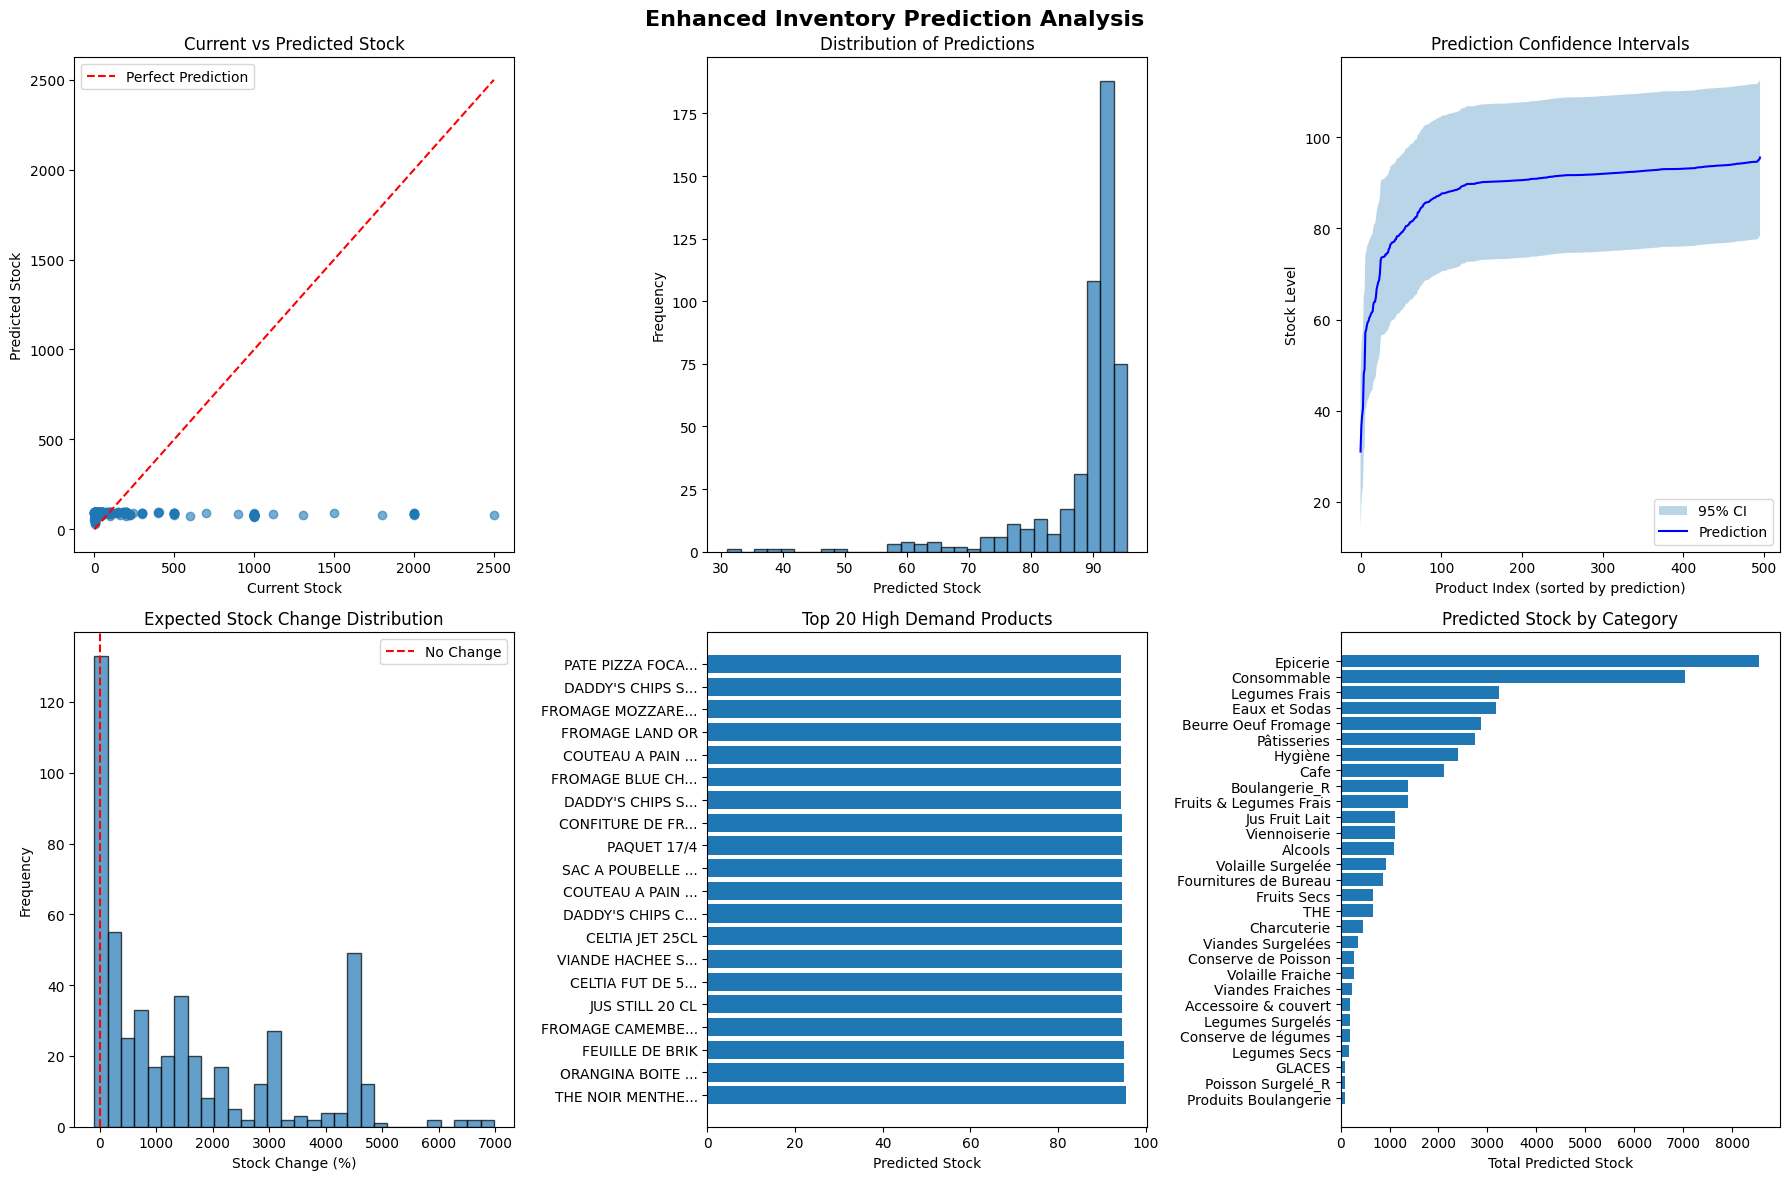

✓ Business report exported to inventory_prediction_report_20250921_102934.xlsx


In [35]:
# After training completes, use the new models
viewer = EnhancedPredictionViewer('raw_features_models')
predictions = viewer.make_enhanced_predictions('products_filtered.csv', model_name='gru')
metrics = viewer.analyze_enhanced_predictions(predictions)
viewer.visualize_enhanced_predictions(predictions)
excel_file = viewer.export_enhanced_business_report(predictions)

CSV File Information:
Shape: (72752, 9)
Columns: ['Name', 'Physical Storage Quantity', 'Storage Unit', 'GroupName', 'Date_week', 'Month', 'Stock_Class', 'Inventory_Cycle', 'Max_Stock']

First few rows:
                 Name  Physical Storage Quantity Storage Unit      GroupName  \
0            MAY 0.5L                      529.0           PC  Eaux et Sodas   
1   CELTIA FUT DE 50L                        2.0    PC (50 L)        Alcools   
2     COCA BOITE ZERO                       28.0    PC (1 PC)  Eaux et Sodas   
3         FORTE NSPRS                      250.0    PC (1 PC)           Cafe   
4  CHOCOLAT EN POUDRE                        5.0  PC (0,2 KG)           Cafe   

  Date_week    Month Stock_Class  Inventory_Cycle  Max_Stock  
0     lundi  2024-01           A                1     1680.0  
1     lundi  2024-01           B                1        2.0  
2     lundi  2024-01           A                1      166.0  
3     lundi  2024-01           A                1     1500.0  
4 

In [30]:
def prepare_minimal_features(self, df):
        """Prepare minimal features using only raw columns"""
        print("Preparing minimal features from raw columns...")
        
        df = df.copy()
        
        # Fix column names to match actual CSV structure
        # Only encode categorical variables - no derived features
        if 'groupname_encoder' not in self.encoders:
            self.encoders['groupname_encoder'] = LabelEncoder()
            df['GroupName_encoded'] = self.encoders['groupname_encoder'].fit_transform(df['GroupName'].astype(str))
        else:
            df['GroupName_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        
        # Fixed: Use 'Storage Unit' (with space) instead of 'Storage_Unit'
        if 'storage_unit_encoder' not in self.encoders:
            self.encoders['storage_unit_encoder'] = LabelEncoder()
            df['Storage_Unit_encoded'] = self.encoders['storage_unit_encoder'].fit_transform(df['Storage Unit'].astype(str))
        else:
            df['Storage_Unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        
        if 'stock_class_encoder' not in self.encoders:
            self.encoders['stock_class_encoder'] = LabelEncoder()
            df['Stock_Class_encoded'] = self.encoders['stock_class_encoder'].fit_transform(df['Stock_Class'].astype(str))
        else:
            df['Stock_Class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        
        # Fill missing values with simple strategies
        df['Month'] = df['Month'].fillna(1)
        df['Max_Stock'] = df['Max_Stock'].fillna(df['Max_Stock'].median())
        
        print(f"Minimal features ready. Shape: {df.shape}")
        return df

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import pickle
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

class PredictionViewer:
    def __init__(self, model_directory):
        """Initialize prediction viewer for minimal models"""
        self.model_directory = model_directory
        self.models = {}
        self.scalers = {}
        self.encoders = {}
        self.sequence_length = 10
        
        # Load saved components
        self._load_models()
        
    def _load_models(self):
        """Load minimal models, scalers, and encoders"""
        try:
            # Load models
            model_files = {
                'minimal_gru': 'minimal_gru_model.h5',
                'minimal_lstm': 'minimal_lstm_model.h5'
            }
            
            for name, filename in model_files.items():
                model_path = os.path.join(self.model_directory, filename)
                if os.path.exists(model_path):
                    self.models[name] = load_model(model_path)
                    print(f"✓ Loaded {name} model")
                else:
                    print(f"⚠ Model {filename} not found")
            
            # Load scalers
            scaler_path = os.path.join(self.model_directory, 'scalers.pkl')
            if os.path.exists(scaler_path):
                with open(scaler_path, 'rb') as f:
                    self.scalers = pickle.load(f)
                print(f"✓ Loaded scalers")
            
            # Load encoders
            encoder_path = os.path.join(self.model_directory, 'encoders.pkl')
            if os.path.exists(encoder_path):
                with open(encoder_path, 'rb') as f:
                    self.encoders = pickle.load(f)
                print(f"✓ Loaded encoders")
            
            print(f"✓ Loaded {len(self.models)} models")
            
        except Exception as e:
            print(f"Error loading models: {e}")
    
    def _prepare_minimal_features(self, df):
        """Prepare minimal features (same as training)"""
        df = df.copy()
        
        # Map column names
        column_mapping = {
            'Name': 'Name',
            'Physical Storage Quantity': 'Physical Storage Quantity', 
            'GroupName': 'GroupName',
            'Inventory_Cycle': 'Inventory_Cycle',
            'Max_Stock': 'Max_Stock',
            'Stock_Class': 'Stock_Class',
            'Storage Unit': 'Storage Unit',
            'Month': 'Month'
        }
        
        # Encode categorical variables
        if 'groupname_encoder' in self.encoders:
            df['GroupName_encoded'] = self.encoders['groupname_encoder'].transform(df['GroupName'].astype(str))
        else:
            df['GroupName_encoded'] = pd.Categorical(df['GroupName']).codes
        
        if 'storage_unit_encoder' in self.encoders:
            df['Storage_Unit_encoded'] = self.encoders['storage_unit_encoder'].transform(df['Storage Unit'].astype(str))
        else:
            df['Storage_Unit_encoded'] = pd.Categorical(df['Storage Unit']).codes
        
        if 'stock_class_encoder' in self.encoders:
            df['Stock_Class_encoded'] = self.encoders['stock_class_encoder'].transform(df['Stock_Class'].astype(str))
        else:
            df['Stock_Class_encoded'] = pd.Categorical(df['Stock_Class']).codes
        
        # Fill missing values
        df['Month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(1)
        df['Max_Stock'] = pd.to_numeric(df['Max_Stock'], errors='coerce').fillna(df['Max_Stock'].median())
        
        return df
    
    def _prepare_sequences(self, df):
        """Prepare sequences for prediction"""
        feature_columns = [
            'Physical Storage Quantity',
            'Inventory_Cycle',
            'Month',
            'Max_Stock',
            'GroupName_encoded',
            'Storage_Unit_encoded',
            'Stock_Class_encoded'
        ]
        
        sequences = []
        products = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) >= self.sequence_length:
                # Take the last sequence_length points
                recent_data = product_data.tail(self.sequence_length)
                sequence = recent_data[feature_columns].values
                
                # Clean data
                sequence = np.nan_to_num(sequence, nan=0, posinf=0, neginf=0)
                sequences.append(sequence)
                products.append(product)
            else:
                # Pad with available data if not enough
                sequence = np.zeros((self.sequence_length, len(feature_columns)))
                available_data = product_data[feature_columns].values
                available_data = np.nan_to_num(available_data, nan=0, posinf=0, neginf=0)
                
                if len(available_data) > 0:
                    if len(available_data) == 1:
                        sequence[:] = available_data[0]
                    else:
                        sequence[-len(available_data):] = available_data
                        sequence[:-len(available_data)] = available_data[0]
                
                sequences.append(sequence)
                products.append(product)
        
        return np.array(sequences), products
    
    def make_predictions(self, csv_file, model_name='minimal_gru'):
        """Make predictions using minimal model"""
        print(f"Making predictions with {model_name} model...")
        
        # Load data
        df = pd.read_csv(csv_file)
        print(f"Loaded data: {len(df)} rows, {len(df.columns)} columns")
        
        # Prepare minimal features
        df_features = self._prepare_minimal_features(df)
        
        # Prepare sequences
        sequences, product_names = self._prepare_sequences(df_features)
        
        # Scale features
        if 'features' in self.scalers:
            original_shape = sequences.shape
            sequences_reshaped = sequences.reshape(-1, sequences.shape[-1])
            sequences_scaled = self.scalers['features'].transform(sequences_reshaped)
            sequences_scaled = sequences_scaled.reshape(original_shape)
        else:
            sequences_scaled = sequences
            print("⚠ No feature scaler available")
        
        # Make predictions
        if model_name in self.models:
            model = self.models[model_name]
            predictions_scaled = model.predict(sequences_scaled)
            
            # Inverse transform if target scaler is available
            if 'targets' in self.scalers:
                predictions = self.scalers['targets'].inverse_transform(predictions_scaled)
                print("✓ Applied inverse scaling to predictions")
            else:
                predictions = predictions_scaled
                print("⚠ No target scaler available")
                
            predictions = predictions.flatten()
        else:
            raise ValueError(f"Model {model_name} not found. Available: {list(self.models.keys())}")
        
        # Get current stock for each product
        current_stock = []
        categories = []
        for product in product_names:
            product_data = df_features[df_features['Name'] == product]
            if len(product_data) > 0:
                current_stock.append(product_data['Physical Storage Quantity'].iloc[-1])
                categories.append(product_data['GroupName'].iloc[-1])
            else:
                current_stock.append(0)
                categories.append('Unknown')
        
        # Create predictions DataFrame
        current_cycle = df_features['Inventory_Cycle'].max()
        
        predictions_df = pd.DataFrame({
            'product_name': product_names,
            'current_stock': current_stock,
            'predicted_next_cycle': np.maximum(0, predictions),  # No negative predictions
            'current_cycle': current_cycle,
            'prediction_cycle': current_cycle + 1,
            'category': categories,
            'model_used': model_name,
            'approach': 'minimal_raw_features'
        })
        
        # Add business insights
        predictions_df['stock_change'] = predictions_df['predicted_next_cycle'] - predictions_df['current_stock']
        predictions_df['stock_change_pct'] = (predictions_df['stock_change'] / (predictions_df['current_stock'] + 1)) * 100
        
        print(f"✓ Generated predictions for {len(predictions_df)} products")
        
        return predictions_df
    
    def analyze_predictions(self, predictions_df):
        """Analyze prediction results"""
        print("\n" + "="*60)
        print("MINIMAL MODEL PREDICTION ANALYSIS")
        print("="*60)
        
        # Basic statistics
        print(f"\nPrediction Overview:")
        print(f"Products analyzed: {len(predictions_df)}")
        print(f"Model used: {predictions_df['model_used'].iloc[0]}")
        print(f"Approach: {predictions_df['approach'].iloc[0]}")
        print(f"Prediction cycle: {predictions_df['prediction_cycle'].iloc[0]}")
        
        # Stock analysis
        print(f"\nStock Level Analysis:")
        print(f"Current total stock: {predictions_df['current_stock'].sum():,.0f}")
        print(f"Predicted total stock: {predictions_df['predicted_next_cycle'].sum():,.0f}")
        total_change = ((predictions_df['predicted_next_cycle'].sum() / predictions_df['current_stock'].sum()) - 1) * 100
        print(f"Expected change: {total_change:.1f}%")
        
        # Distribution analysis
        print(f"\nPrediction Distribution:")
        print(predictions_df['predicted_next_cycle'].describe())
        
        # Category analysis
        if 'category' in predictions_df.columns:
            print(f"\nCategory Analysis:")
            category_summary = predictions_df.groupby('category').agg({
                'current_stock': 'sum',
                'predicted_next_cycle': 'sum',
                'product_name': 'count'
            }).round(0)
            category_summary.columns = ['Current_Stock', 'Predicted_Stock', 'Product_Count']
            category_summary['growth_rate_%'] = ((category_summary['Predicted_Stock'] / category_summary['Current_Stock']) - 1) * 100
            print(category_summary)
        
        return {
            'total_products': len(predictions_df),
            'total_current_stock': predictions_df['current_stock'].sum(),
            'total_predicted_stock': predictions_df['predicted_next_cycle'].sum(),
            'overall_change_pct': total_change
        }
    
    def visualize_predictions(self, predictions_df, save_plots=True):
        """Create visualizations"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Minimal Model Prediction Analysis', fontsize=16, fontweight='bold')
        
        # 1. Current vs Predicted
        axes[0, 0].scatter(predictions_df['current_stock'], predictions_df['predicted_next_cycle'], alpha=0.6)
        max_val = max(predictions_df['current_stock'].max(), predictions_df['predicted_next_cycle'].max())
        axes[0, 0].plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
        axes[0, 0].set_xlabel('Current Stock')
        axes[0, 0].set_ylabel('Predicted Stock')
        axes[0, 0].set_title('Current vs Predicted Stock')
        axes[0, 0].legend()
        
        # 2. Stock Change Distribution
        axes[0, 1].hist(predictions_df['stock_change_pct'], bins=20, alpha=0.7, edgecolor='black')
        axes[0, 1].axvline(0, color='red', linestyle='--', label='No Change')
        axes[0, 1].set_xlabel('Stock Change (%)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Expected Stock Change Distribution')
        axes[0, 1].legend()
        
        # 3. Category Analysis
        if 'category' in predictions_df.columns:
            category_totals = predictions_df.groupby('category')['predicted_next_cycle'].sum().sort_values()
            axes[1, 0].barh(range(len(category_totals)), category_totals.values)
            axes[1, 0].set_yticks(range(len(category_totals)))
            axes[1, 0].set_yticklabels(category_totals.index)
            axes[1, 0].set_xlabel('Total Predicted Stock')
            axes[1, 0].set_title('Predicted Stock by Category')
        
        # 4. Top Products
        top_products = predictions_df.nlargest(15, 'predicted_next_cycle')
        axes[1, 1].barh(range(len(top_products)), top_products['predicted_next_cycle'])
        axes[1, 1].set_yticks(range(len(top_products)))
        axes[1, 1].set_yticklabels([name[:20] + '...' if len(name) > 20 else name for name in top_products['product_name']])
        axes[1, 1].set_xlabel('Predicted Stock')
        axes[1, 1].set_title('Top 15 Predicted Products')
        
        plt.tight_layout()
        
        if save_plots:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'minimal_predictions_{timestamp}.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✓ Visualizations saved as {filename}")
        
        plt.show()
    
    def export_predictions_for_business(self, predictions_df, filename=None):
        """Export business report"""
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f'minimal_predictions_report_{timestamp}.xlsx'
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Main predictions
            predictions_df.to_excel(writer, sheet_name='Predictions', index=False)
            
            # Summary
            summary = pd.DataFrame({
                'Metric': ['Total Products', 'Current Total Stock', 'Predicted Total Stock', 'Expected Change %', 'Approach'],
                'Value': [
                    len(predictions_df),
                    predictions_df['current_stock'].sum(),
                    predictions_df['predicted_next_cycle'].sum(),
                    ((predictions_df['predicted_next_cycle'].sum() / predictions_df['current_stock'].sum()) - 1) * 100,
                    'Minimal Raw Features Only'
                ]
            })
            summary.to_excel(writer, sheet_name='Summary', index=False)
            
            # Category analysis
            if 'category' in predictions_df.columns:
                category_analysis = predictions_df.groupby('category').agg({
                    'product_name': 'count',
                    'current_stock': 'sum',
                    'predicted_next_cycle': 'sum'
                }).round(0)
                category_analysis.columns = ['Product_Count', 'Current_Stock', 'Predicted_Stock']
                category_analysis['Growth_Rate_%'] = ((category_analysis['Predicted_Stock'] / category_analysis['Current_Stock']) - 1) * 100
                category_analysis.to_excel(writer, sheet_name='Category_Analysis')
        
        print(f"✓ Business report exported to {filename}")
        return filename

In [32]:
# Initialize with your model directory
viewer = PredictionViewer('minimal_models')

# Make predictions on your data
predictions = viewer.make_predictions('products_filtered.csv')

# Analyze results
metrics = viewer.analyze_predictions(predictions)

# Create visualizations
viewer.visualize_predictions(predictions)

# Export for business use
excel_file = viewer.export_predictions_for_business(predictions)

⚠ Model minimal_gru_model.h5 not found
⚠ Model minimal_lstm_model.h5 not found
✓ Loaded 0 models
Making predictions with minimal_gru model...
Loaded data: 72752 rows, 9 columns
⚠ No feature scaler available


ValueError: Model minimal_gru not found. Available: []

In [ ]:
# Individual Product-Specific Inventory Forecasting Models
# ========================================================
# Each product gets its own trained model for maximum accuracy

import pandas as pd
import numpy as np
import pickle
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")
    exit()

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class IndividualProductForecaster:
    """Individual product-specific inventory forecasting system"""
    
    def __init__(self):
        self.product_models = {}  # {product_name: {gru: model, bidirectional_lstm: model}}
        self.product_scalers = {}  # {product_name: {features: scaler, targets: scaler}}
        self.product_metadata = {}  # {product_name: {model_name: metadata}}
        self.feature_names = []
        self.sequence_length = 8  # Shorter for individual products
        self.min_data_points = 20  # Minimum data points needed per product
        
    def calculate_metrics(self, y_true, y_pred):
        """Calculate comprehensive performance metrics"""
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = (mae / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 100
        
        return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}
    
    def load_and_prepare_data(self, file_path):
        """Load and prepare data for individual product training"""
        print("Loading inventory data for individual product training...")
        
        df = pd.read_csv(file_path)
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        
        # Ensure required columns exist
        required_cols = ['Name', 'Physical Storage Quantity', 'Weekend', 'Inventory_Cycle']
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")
        
        # Sort and clean data
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
        df = df.dropna(subset=['Physical Storage Quantity'])
        
        # Analyze product data availability
        product_counts = df['Name'].value_counts()
        sufficient_products = product_counts[product_counts >= self.min_data_points].index.tolist()
        insufficient_products = product_counts[product_counts < self.min_data_points].index.tolist()
        
        print(f"✓ Products with sufficient data (>={self.min_data_points} points): {len(sufficient_products)}")
        if insufficient_products:
            print(f"⚠ Products with insufficient data: {len(insufficient_products)}")
            print(f"  (These will use fallback prediction methods)")
        
        # Filter to products with sufficient data
        df_sufficient = df[df['Name'].isin(sufficient_products)].copy()
        
        return df_sufficient, sufficient_products, insufficient_products
    
    def create_product_features(self, product_data, product_name):
        """Create features for a specific product"""
        df = product_data.copy().sort_values('Inventory_Cycle')
        target_col = 'Physical Storage Quantity'
        
        # Product-specific lag features
        for lag in [1, 2, 3, 5]:
            df[f'lag_{lag}'] = df[target_col].shift(lag)
        
        # Product-specific rolling statistics
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).mean()
            df[f'std_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=2).std().fillna(0)
        
        # Product-specific trend indicators
        df['trend_1_3'] = df[target_col].shift(1) - df[target_col].shift(3)
        df['trend_short'] = df[target_col].shift(1) - df[target_col].shift(2)
        
        # Temporal features
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # Product-specific volatility
        df['volatility'] = df[target_col].shift(1).rolling(window=5, min_periods=2).std().fillna(0)
        
        # Product-specific ratios
        df['current_to_ma3'] = df[target_col].shift(1) / (df['ma_3'] + 1e-8)
        df['ma3_to_ma7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        
        return df
    
    def prepare_product_sequences(self, product_data, target_col='Physical Storage Quantity'):
        """Prepare sequences for a specific product"""
        # Select key features for this product
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_5', 'std_3',
            'weekend', 'cycle_sin', 'cycle_cos', 'trend_1_3', 'volatility',
            'current_to_ma3', 'ma3_to_ma7'
        ]
        
        # Filter to existing features
        available_features = [col for col in feature_columns if col in product_data.columns]
        
        # Get features and target
        features = product_data[available_features].values
        target_values = product_data[target_col].values
        
        # Clean data
        features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
        target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
        
        # Create sequences
        sequences = []
        targets = []
        cycles = []
        
        for i in range(len(features) - self.sequence_length):
            seq = features[i:(i + self.sequence_length)]
            target = target_values[i + self.sequence_length]
            cycle = product_data.iloc[i + self.sequence_length]['Inventory_Cycle']
            
            sequences.append(seq)
            targets.append(target)
            cycles.append(cycle)
        
        return np.array(sequences), np.array(targets), np.array(cycles), available_features
    
    def create_individual_gru_model(self, input_shape):
        """Create GRU model optimized for individual products"""
        model = Sequential([
            Input(shape=input_shape),
            GRU(16, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            GRU(8, dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dense(8, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.002, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def create_individual_bidirectional_lstm_model(self, input_shape):
        """Create Bidirectional LSTM model optimized for individual products"""
        model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(12, return_sequences=True, dropout=0.2)),
            BatchNormalization(),
            Bidirectional(LSTM(6, dropout=0.2)),
            BatchNormalization(),
            Dense(8, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
            Dropout(0.3),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.002, clipnorm=1.0),
            loss='huber',
            metrics=['mae', 'mse']
        )
        
        return model
    
    def train_individual_product_models(self, df):
        """Train individual models for each product"""
        print("\nTraining Individual Product Models...")
        print("=" * 60)
        
        unique_products = df['Name'].unique()
        print(f"Training models for {len(unique_products)} products")
        
        training_summary = {
            'successful_products': [],
            'failed_products': [],
            'total_models_trained': 0
        }
        
        model_configs = {
            'gru': {
                'model_func': self.create_individual_gru_model,
                'epochs': 30,
                'batch_size': 16,
                'description': 'Individual GRU'
            },
            'bidirectional_lstm': {
                'model_func': self.create_individual_bidirectional_lstm_model,
                'epochs': 25,
                'batch_size': 16,
                'description': 'Individual Bidirectional LSTM'
            }
        }
        
        for product_idx, product_name in enumerate(unique_products):
            print(f"\n--- Product {product_idx + 1}/{len(unique_products)}: {product_name} ---")
            
            try:
                # Get product data
                product_data = df[df['Name'] == product_name].copy()
                
                if len(product_data) < self.min_data_points:
                    print(f"  ⚠ Insufficient data: {len(product_data)} points")
                    training_summary['failed_products'].append({
                        'product': product_name,
                        'reason': 'insufficient_data',
                        'data_points': len(product_data)
                    })
                    continue
                
                # Create features for this product
                product_features = self.create_product_features(product_data, product_name)
                
                # Prepare sequences for this product
                X, y, cycles, feature_names = self.prepare_product_sequences(product_features)
                
                if len(X) < 10:  # Need minimum sequences for training
                    print(f"  ⚠ Insufficient sequences: {len(X)}")
                    training_summary['failed_products'].append({
                        'product': product_name,
                        'reason': 'insufficient_sequences',
                        'sequences': len(X)
                    })
                    continue
                
                # Store feature names for this product
                if not self.feature_names:  # Use first product's features as template
                    self.feature_names = feature_names
                
                # Setup product-specific scalers
                self.product_scalers[product_name] = {
                    'features': StandardScaler(),
                    'targets': StandardScaler()
                }
                
                # Scale features
                original_shape = X.shape
                X_reshaped = X.reshape(-1, X.shape[-1])
                X_scaled = self.product_scalers[product_name]['features'].fit_transform(X_reshaped)
                X_scaled = X_scaled.reshape(original_shape)
                
                # Scale targets
                y_scaled = self.product_scalers[product_name]['targets'].fit_transform(y.reshape(-1, 1)).flatten()
                
                # Temporal split for this product (80% train, 20% test)
                split_idx = int(len(X_scaled) * 0.8)
                
                X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
                y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]
                
                if len(X_test) < 2:  # Need at least 2 test samples
                    # Use different split
                    split_idx = len(X_scaled) - 2
                    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
                    y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]
                
                print(f"  Data: {len(X_train)} train, {len(X_test)} test sequences")
                
                # Initialize product models dictionary
                self.product_models[product_name] = {}
                self.product_metadata[product_name] = {}
                
                # Train both models for this product
                product_success = False
                
                for model_name, config in model_configs.items():
                    try:
                        print(f"  Training {config['description']}...")
                        
                        # Create model
                        model = config['model_func'](X_train.shape[1:])
                        
                        # Callbacks
                        callbacks = [
                            EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss'),
                            ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-6, monitor='val_loss')
                        ]
                        
                        # Train
                        history = model.fit(
                            X_train, y_train,
                            validation_data=(X_test, y_test),
                            epochs=config['epochs'],
                            batch_size=min(config['batch_size'], len(X_train)),
                            callbacks=callbacks,
                            verbose=0
                        )
                        
                        # Predictions
                        y_train_pred_scaled = model.predict(X_train, verbose=0)
                        y_test_pred_scaled = model.predict(X_test, verbose=0)
                        
                        # Inverse transform
                        y_train_pred = self.product_scalers[product_name]['targets'].inverse_transform(y_train_pred_scaled).flatten()
                        y_test_pred = self.product_scalers[product_name]['targets'].inverse_transform(y_test_pred_scaled).flatten()
                        
                        y_train_orig = self.product_scalers[product_name]['targets'].inverse_transform(y_train.reshape(-1, 1)).flatten()
                        y_test_orig = self.product_scalers[product_name]['targets'].inverse_transform(y_test.reshape(-1, 1)).flatten()
                        
                        # Calculate metrics
                        train_metrics = self.calculate_metrics(y_train_orig, y_train_pred)
                        test_metrics = self.calculate_metrics(y_test_orig, y_test_pred)
                        
                        # Store model and metadata
                        self.product_models[product_name][model_name] = model
                        self.product_metadata[product_name][model_name] = {
                            'description': f"{config['description']} for {product_name}",
                            'train_metrics': train_metrics,
                            'test_metrics': test_metrics,
                            'epochs_trained': len(history.history['loss']),
                            'data_points': len(product_data),
                            'sequences_created': len(X),
                            'feature_names': feature_names
                        }
                        
                        print(f"    ✓ {model_name}: R²={test_metrics['r2']:.3f}, MAE={test_metrics['mae']:.2f}")
                        product_success = True
                        training_summary['total_models_trained'] += 1
                        
                    except Exception as model_error:
                        print(f"    ✗ {model_name} failed: {model_error}")
                        continue
                
                if product_success:
                    training_summary['successful_products'].append({
                        'product': product_name,
                        'models_trained': len(self.product_models[product_name]),
                        'data_points': len(product_data)
                    })
                    print(f"  ✓ Product {product_name}: {len(self.product_models[product_name])} models trained")
                else:
                    training_summary['failed_products'].append({
                        'product': product_name,
                        'reason': 'all_models_failed'
                    })
                    # Clean up failed product data
                    if product_name in self.product_models:
                        del self.product_models[product_name]
                    if product_name in self.product_scalers:
                        del self.product_scalers[product_name]
                    if product_name in self.product_metadata:
                        del self.product_metadata[product_name]
                
            except Exception as product_error:
                print(f"  ✗ Product {product_name} failed: {product_error}")
                training_summary['failed_products'].append({
                    'product': product_name,
                    'reason': str(product_error)
                })
                continue
        
        # Print training summary
        print(f"\n" + "=" * 60)
        print("INDIVIDUAL PRODUCT TRAINING SUMMARY")
        print("=" * 60)
        print(f"✓ Successful products: {len(training_summary['successful_products'])}")
        print(f"✗ Failed products: {len(training_summary['failed_products'])}")
        print(f"🤖 Total models trained: {training_summary['total_models_trained']}")
        
        return training_summary
    
    def predict_individual_product(self, product_data, product_name, model_name='gru'):
        """Make predictions for a specific product"""
        if product_name not in self.product_models:
            raise ValueError(f"No trained model for product '{product_name}'")
        
        if model_name not in self.product_models[product_name]:
            available = list(self.product_models[product_name].keys())
            raise ValueError(f"Model '{model_name}' not available for '{product_name}'. Available: {available}")
        
        # Prepare product data
        product_features = self.create_product_features(product_data, product_name)
        X, metadata, cycles, feature_names = self.prepare_product_sequences(product_features)
        
        if len(X) == 0:
            return pd.DataFrame({
                "product": [product_name],
                "predicted_inventory": [0],
                "error": ["No valid sequences for prediction"]
            })
        
        # Scale features using product-specific scaler
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.product_scalers[product_name]['features'].transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Predict using product-specific model
        predictions_scaled = self.product_models[product_name][model_name].predict(X_scaled, verbose=0).flatten()
        predictions = self.product_scalers[product_name]['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
        
        # Create results
        results = pd.DataFrame({
            'product': [product_name] * len(predictions),
            'inventory_cycle': cycles,
            'predicted_inventory': np.maximum(0, predictions),  # Ensure non-negative
            'model_used': f'{model_name}_{product_name}',
            'prediction_type': 'individual_product_model'
        })
        
        return results
    
    def predict(self, new_data, model='gru'):
        """Make predictions for all products in the dataset"""
        print(f"Making individual product predictions with {model}...")
        
        all_predictions = []
        
        for product_name in new_data['Name'].unique():
            try:
                product_data = new_data[new_data['Name'] == product_name].copy()
                
                if product_name in self.product_models:
                    # Use individual product model
                    pred = self.predict_individual_product(product_data, product_name, model)
                    all_predictions.append(pred)
                else:
                    # Fallback for products without trained models
                    print(f"  ⚠ No model for {product_name}, using fallback prediction")
                    fallback_pred = self._create_fallback_prediction(product_data, product_name)
                    all_predictions.append(fallback_pred)
                    
            except Exception as e:
                print(f"  ✗ Prediction failed for {product_name}: {e}")
                # Create minimal fallback
                fallback_pred = pd.DataFrame({
                    'product': [product_name],
                    'predicted_inventory': [50.0],  # Default fallback
                    'model_used': 'fallback',
                    'prediction_type': 'fallback'
                })
                all_predictions.append(fallback_pred)
        
        if all_predictions:
            return pd.concat(all_predictions, ignore_index=True)
        else:
            return pd.DataFrame(columns=['product', 'predicted_inventory', 'model_used'])
    
    def _create_fallback_prediction(self, product_data, product_name):
        """Create fallback prediction for products without trained models"""
        try:
            if 'Physical Storage Quantity' in product_data.columns:
                # Use recent average
                recent_avg = product_data['Physical Storage Quantity'].tail(5).mean()
                prediction = recent_avg * 0.95  # Slight decrease assumption
            else:
                prediction = 75.0  # Default
            
            return pd.DataFrame({
                'product': [product_name],
                'predicted_inventory': [max(0, prediction)],
                'model_used': 'statistical_fallback',
                'prediction_type': 'fallback'
            })
        except:
            return pd.DataFrame({
                'product': [product_name],
                'predicted_inventory': [50.0],
                'model_used': 'default_fallback',
                'prediction_type': 'fallback'
            })
    
    def get_product_model_info(self, product_name=None):
        """Get information about trained models"""
        if product_name:
            if product_name in self.product_metadata:
                return {
                    'product': product_name,
                    'models': self.product_metadata[product_name],
                    'scalers_available': product_name in self.product_scalers
                }
            else:
                return {'error': f'No data for product {product_name}'}
        else:
            return {
                'total_products': len(self.product_models),
                'products_with_models': list(self.product_models.keys()),
                'total_models': sum(len(models) for models in self.product_models.values()),
                'average_models_per_product': np.mean([len(models) for models in self.product_models.values()]) if self.product_models else 0
            }
    
    def save_for_deployment(self, save_directory='individual_product_models'):
        """Save individual product models for production deployment"""
        print(f"\nSaving Individual Product Models for Deployment...")
        print("=" * 60)
        
        os.makedirs(save_directory, exist_ok=True)
        
        # Save individual product models
        product_model_files = {}
        for product_name, product_models in self.product_models.items():
            product_dir = os.path.join(save_directory, f"product_{product_name.replace(' ', '_').replace('/', '_')}")
            os.makedirs(product_dir, exist_ok=True)
            
            product_model_files[product_name] = {}
            for model_name, model in product_models.items():
                model_path = os.path.join(product_dir, f'{model_name}_model.h5')
                model.save(model_path)
                product_model_files[product_name][model_name] = model_path
            
            print(f"✓ Saved {len(product_models)} models for {product_name}")
        
        # Save product scalers
        scalers_path = os.path.join(save_directory, 'product_scalers.pkl')
        with open(scalers_path, 'wb') as f:
            pickle.dump(self.product_scalers, f)
        print(f"✓ Saved scalers for {len(self.product_scalers)} products")
        
        # Save deployment config
        config = {
            'product_model_files': product_model_files,
            'scalers_path': scalers_path,
            'product_metadata': self.product_metadata,
            'feature_names': self.feature_names,
            'sequence_length': self.sequence_length,
            'min_data_points': self.min_data_points,
            'saved_date': datetime.now().isoformat(),
            'system_version': 'individual_products_v1',
            'total_products': len(self.product_models),
            'total_models': sum(len(models) for models in self.product_models.values())
        }
        
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"✓ Saved configuration")
        
        # Save deployment system
        deployment_system = IndividualProductDeployment()
        deployment_system.load_from_config(config)
        
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'wb') as f:
            pickle.dump(deployment_system, f)
        print(f"✓ Saved deployment system")
        
        # Create summary
        self._create_individual_summary(save_directory)
        
        print(f"\n✓ Individual Product Deployment package ready: {os.path.abspath(save_directory)}")
        return save_directory
    
    def _create_individual_summary(self, save_directory):
        """Create deployment summary for individual products"""
        summary_path = os.path.join(save_directory, 'INDIVIDUAL_PRODUCTS_SUMMARY.txt')
        
        with open(summary_path, 'w') as f:
            f.write("INDIVIDUAL PRODUCT INVENTORY FORECASTING MODELS\n")
            f.write("=" * 60 + "\n\n")
            f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Total Products: {len(self.product_models)}\n")
            f.write(f"Total Models: {sum(len(models) for models in self.product_models.values())}\n\n")
            
            f.write("PRODUCT MODEL SUMMARY:\n")
            f.write("-" * 40 + "\n")
            
            for product_name, product_metadata in self.product_metadata.items():
                f.write(f"\n{product_name}:\n")
                for model_name, metadata in product_metadata.items():
                    f.write(f"  {model_name}:\n")
                    f.write(f"    R²: {metadata['test_metrics']['r2']:.3f}\n")
                    f.write(f"    MAE: {metadata['test_metrics']['mae']:.2f}\n")
                    f.write(f"    Data Points: {metadata['data_points']}\n")
            
            f.write(f"\nUSAGE:\n")
            f.write("from deployment_system import load_individual_product_system\n")
            f.write("system = load_individual_product_system('individual_product_models')\n")
            f.write("predictions = system.predict(data, model='gru')\n")

class IndividualProductDeployment:
    """Lightweight deployment system for individual product models"""
    
    def __init__(self):
        self.product_models = {}
        self.product_scalers = {}
        self.product_metadata = {}
        self.feature_names = []
        self.sequence_length = 8
        self.min_data_points = 20
    
    def load_from_config(self, config):
        """Load configuration"""
        self.product_metadata = config['product_metadata']
        self.feature_names = config['feature_names']
        self.sequence_length = config['sequence_length']
        self.min_data_points = config['min_data_points']
    
    @classmethod
    def load_system(cls, save_directory):
        """Load complete individual product deployment system"""
        system_path = os.path.join(save_directory, 'deployment_system.pkl')
        with open(system_path, 'rb') as f:
            system = pickle.load(f)
        
        # Load config
        config_path = os.path.join(save_directory, 'deployment_config.json')
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        # Load individual product models
        for product_name, product_model_files in config['product_model_files'].items():
            system.product_models[product_name] = {}
            for model_name, model_path in product_model_files.items():
                try:
                    system.product_models[product_name][model_name] = load_model(model_path)
                except Exception as e:
                    print(f"⚠ Failed to load {model_name} for {product_name}: {e}")
        
        # Load scalers
        with open(config['scalers_path'], 'rb') as f:
            system.product_scalers = pickle.load(f)
        
        successful_products = len(system.product_models)
        total_models = sum(len(models) for models in system.product_models.values())
        print(f"✓ Individual product system loaded: {successful_products} products, {total_models} models")
        return system
    
    def create_product_features(self, product_data, product_name):
        """Create features for a specific product (same as training)"""
        df = product_data.copy().sort_values('Inventory_Cycle')
        target_col = 'Physical Storage Quantity'
        
        # Same features as training
        for lag in [1, 2, 3, 5]:
            df[f'lag_{lag}'] = df[target_col].shift(lag)
        
        for window in [3, 5, 7]:
            df[f'ma_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).mean()
            df[f'std_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=2).std().fillna(0)
        
        df['trend_1_3'] = df[target_col].shift(1) - df[target_col].shift(3)
        df['trend_short'] = df[target_col].shift(1) - df[target_col].shift(2)
        df['weekend'] = df['Weekend']
        df['cycle_sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['cycle_cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['volatility'] = df[target_col].shift(1).rolling(window=5, min_periods=2).std().fillna(0)
        df['current_to_ma3'] = df[target_col].shift(1) / (df['ma_3'] + 1e-8)
        df['ma3_to_ma7'] = df['ma_3'] / (df['ma_7'] + 1e-8)
        
        return df
    
    def prepare_product_sequences(self, product_data, target_col='Physical Storage Quantity'):
        """Prepare sequences for a specific product"""
        # Same feature selection as training
        feature_columns = [
            'lag_1', 'lag_2', 'lag_3', 'ma_3', 'ma_5', 'std_3',
            'weekend', 'cycle_sin', 'cycle_cos', 'trend_1_3', 'volatility',
            'current_to_ma3', 'ma3_to_ma7'
        ]
        
        available_features = [col for col in feature_columns if col in product_data.columns]
        features = product_data[available_features].values
        features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
        
        sequences = []
        cycles = []
        
        for i in range(len(features) - self.sequence_length + 1):
            seq = features[i:(i + self.sequence_length)]
            cycle = product_data.iloc[i + self.sequence_length - 1]['Inventory_Cycle']
            sequences.append(seq)
            cycles.append(cycle)
        
        return np.array(sequences), np.array(cycles), available_features
    
    def predict(self, new_data, model='gru'):
        """Make predictions for all products using individual models"""
        all_predictions = []
        
        for product_name in new_data['Name'].unique():
            product_data = new_data[new_data['Name'] == product_name].copy()
            
            if product_name in self.product_models and model in self.product_models[product_name]:
                try:
                    # Use individual product model
                    product_features = self.create_product_features(product_data, product_name)
                    X, cycles, feature_names = self.prepare_product_sequences(product_features)
                    
                    if len(X) > 0:
                        # Scale and predict
                        original_shape = X.shape
                        X_reshaped = X.reshape(-1, X.shape[-1])
                        X_scaled = self.product_scalers[product_name]['features'].transform(X_reshaped)
                        X_scaled = X_scaled.reshape(original_shape)
                        
                        predictions_scaled = self.product_models[product_name][model].predict(X_scaled, verbose=0).flatten()
                        predictions = self.product_scalers[product_name]['targets'].inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
                        
                        result = pd.DataFrame({
                            'product': [product_name] * len(predictions),
                            'inventory_cycle': cycles,
                            'predicted_inventory': np.maximum(0, predictions),
                            'model_used': f'{model}_{product_name}',
                            'prediction_type': 'individual_product_model'
                        })
                        all_predictions.append(result)
                        
                except Exception as e:
                    print(f"Individual model prediction failed for {product_name}: {e}")
                    # Fallback
                    all_predictions.append(self._create_fallback_prediction(product_data, product_name))
            else:
                # Fallback for products without models
                all_predictions.append(self._create_fallback_prediction(product_data, product_name))
        
        return pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    
    def _create_fallback_prediction(self, product_data, product_name):
        """Create fallback prediction"""
        try:
            if 'Physical Storage Quantity' in product_data.columns:
                recent_avg = product_data['Physical Storage Quantity'].tail(3).mean()
                prediction = recent_avg * 0.95
            else:
                prediction = 75.0
            
            return pd.DataFrame({
                'product': [product_name],
                'predicted_inventory': [max(0, prediction)],
                'model_used': 'statistical_fallback',
                'prediction_type': 'fallback'
            })
        except:
            return pd.DataFrame({
                'product': [product_name],
                'predicted_inventory': [50.0],
                'model_used': 'default_fallback',
                'prediction_type': 'fallback'
            })
    
    def get_model_info(self):
        """Get model information"""
        return {
            'total_products': len(self.product_models),
            'products_with_models': list(self.product_models.keys()),
            'available_model_types': list(set(model_name for models in self.product_models.values() for model_name in models.keys())),
            'total_models': sum(len(models) for models in self.product_models.values()),
            'system_type': 'individual_product_models'
        }

def load_production_system(save_directory):
    """Convenience function to load individual product system"""
    return IndividualProductDeployment.load_system(save_directory)

def load_individual_product_system(save_directory):
    """Specific function to load individual product system"""
    return IndividualProductDeployment.load_system(save_directory)

def main():
    """Run complete individual product training and deployment pipeline"""
    print("INDIVIDUAL PRODUCT-SPECIFIC INVENTORY FORECASTING MODELS")
    print("=" * 70)
    
    # Initialize system
    forecaster = IndividualProductForecaster()
    
    # Load and train
    df, sufficient_products, insufficient_products = forecaster.load_and_prepare_data('products_with_weekend.csv')
    training_summary = forecaster.train_individual_product_models(df)
    
    # Save for deployment
    save_directory = forecaster.save_for_deployment()
    
    # Show final results
    print(f"\n" + "=" * 70)
    print("INDIVIDUAL PRODUCT TRAINING COMPLETE")
    print("=" * 70)
    
    print(f"✓ Products with trained models: {len(training_summary['successful_products'])}")
    print(f"⚠ Products without models: {len(training_summary['failed_products'])}")
    print(f"🤖 Total models trained: {training_summary['total_models_trained']}")
    
    if training_summary['successful_products']:
        print(f"\nTop performing products:")
        for i, product_info in enumerate(training_summary['successful_products'][:5]):
            product_name = product_info['product']
            if product_name in forecaster.product_metadata:
                best_r2 = max(model_data['test_metrics']['r2'] 
                            for model_data in forecaster.product_metadata[product_name].values())
                print(f"  {i+1}. {product_name}: R²={best_r2:.3f}")
    
    print(f"\n✓ Deployment package ready: {save_directory}")
    print(f"✓ To use: system = load_individual_product_system('{save_directory}')")

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
INDIVIDUAL PRODUCT-SPECIFIC INVENTORY FORECASTING MODELS
Loading inventory data for individual product training...
✓ Loaded: 72752 rows, 26 columns
✓ Products with sufficient data (>=20 points): 447
⚠ Products with insufficient data: 49
  (These will use fallback prediction methods)

Training Individual Product Models...
Training models for 447 products

--- Product 1/447: AC-SMOOTHIE EXOTIC ---
  Data: 9 train, 3 test sequences
  Training Individual GRU...
    ✓ gru: R²=0.000, MAE=0.36
  Training Individual Bidirectional LSTM...
    ✓ bidirectional_lstm: R²=0.000, MAE=0.26
  ✓ Product AC-SMOOTHIE EXOTIC: 2 models trained

--- Product 2/447: AC-SMOOTHIE LE CLASSIQUE ---
  Data: 10 train, 3 test sequences
  Training Individual GRU...
    ✓ gru: R²=0.000, MAE=0.95
  Training Individual Bidirectional LSTM...
    ✓ bidirectional_lstm: R²=0.000, MAE=1.16
  ✓ Product AC-SMOOTHIE LE CLASSIQUE: 2 models trained

--- Product 3/447: AC-SMOOTHIE PEACH'TINI ---
  Data:

In [1]:
# Tiered Deep Learning Inventory Forecasting System
# =================================================
# Uses deep learning where appropriate, other methods elsewhere

import pandas as pd
import numpy as np
import pickle
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input, Bidirectional
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

np.random.seed(42)

class TieredForecastingSystem:
    """Tiered system: Deep learning for data-rich products, other methods elsewhere"""
    
    def __init__(self):
        # Thresholds based on research and your actual data
        self.deep_learning_threshold = 150  # sequences (not data points)
        self.machine_learning_threshold = 50   # sequences  
        self.statistical_threshold = 15       # sequences
        
        # Storage for different model types
        self.deep_models = {}      # Neural networks
        self.ml_models = {}        # Traditional ML
        self.stat_models = {}      # Statistical models
        self.scalers = {}          # Scalers for each product
        self.metadata = {}         # Performance metadata
        
        self.sequence_length = 8   # For deep learning models
        
    def analyze_data_suitability(self, df):
        """Analyze which products are suitable for which approaches"""
        print("ANALYZING DATA SUITABILITY FOR DEEP LEARNING")
        print("=" * 60)
        
        suitability = {
            'deep_learning': [],
            'machine_learning': [],
            'statistical': [],
            'insufficient': []
        }
        
        for product_name in df['Name'].unique():
            product_data = df[df['Name'] == product_name].copy()
            
            # Create sequences to see how many we actually get
            sequences_available = max(0, len(product_data) - self.sequence_length)
            
            print(f"{product_name}")
            print(f"  Raw data points: {len(product_data)}")
            print(f"  Sequences available: {sequences_available}")
            
            if sequences_available >= self.deep_learning_threshold:
                suitability['deep_learning'].append({
                    'product': product_name,
                    'sequences': sequences_available,
                    'data_points': len(product_data)
                })
                print(f"  → 🤖 DEEP LEARNING (excellent data)")
                
            elif sequences_available >= self.machine_learning_threshold:
                suitability['machine_learning'].append({
                    'product': product_name,
                    'sequences': sequences_available,
                    'data_points': len(product_data)
                })
                print(f"  → 📊 MACHINE LEARNING (good data)")
                
            elif sequences_available >= self.statistical_threshold:
                suitability['statistical'].append({
                    'product': product_name,
                    'sequences': sequences_available,
                    'data_points': len(product_data)
                })
                print(f"  → 📈 STATISTICAL (limited data)")
                
            else:
                suitability['insufficient'].append({
                    'product': product_name,
                    'sequences': sequences_available,
                    'data_points': len(product_data)
                })
                print(f"  → ⚠️ FALLBACK (insufficient data)")
        
        print(f"\nSUITABILITY SUMMARY:")
        print(f"🤖 Deep Learning candidates: {len(suitability['deep_learning'])}")
        print(f"📊 Machine Learning candidates: {len(suitability['machine_learning'])}")
        print(f"📈 Statistical candidates: {len(suitability['statistical'])}")
        print(f"⚠️ Fallback candidates: {len(suitability['insufficient'])}")
        
        # Show top deep learning candidates
        if suitability['deep_learning']:
            print(f"\nTOP DEEP LEARNING CANDIDATES:")
            sorted_dl = sorted(suitability['deep_learning'], key=lambda x: x['sequences'], reverse=True)
            for i, item in enumerate(sorted_dl[:10]):
                print(f"  {i+1}. {item['product']}: {item['sequences']} sequences")
        
        return suitability
    
    def create_optimized_features(self, product_data):
        """Create features optimized for the amount of available data"""
        df = product_data.copy().sort_values('Inventory_Cycle')
        target_col = 'Physical Storage Quantity'
        
        # Basic lag features
        df['lag_1'] = df[target_col].shift(1)
        df['lag_2'] = df[target_col].shift(2)
        
        # Moving averages with different windows
        df['ma_3'] = df[target_col].shift(1).rolling(window=3, min_periods=1).mean()
        df['ma_5'] = df[target_col].shift(1).rolling(window=5, min_periods=1).mean()
        
        # Simple trend
        df['trend_short'] = df[target_col].shift(1) - df[target_col].shift(2)
        
        # Temporal features
        df['weekend'] = df.get('Weekend', 0)
        df['cycle_normalized'] = df['Inventory_Cycle'] / 52.0  # Normalize to 0-1
        
        # Volatility (for products with enough data)
        if len(df) >= 10:
            df['volatility'] = df[target_col].shift(1).rolling(window=5, min_periods=2).std().fillna(0)
        else:
            df['volatility'] = 0
        
        # Fill NaN values
        feature_columns = ['lag_1', 'lag_2', 'ma_3', 'ma_5', 'trend_short', 
                          'weekend', 'cycle_normalized', 'volatility']
        df[feature_columns] = df[feature_columns].fillna(0)
        
        return df, feature_columns
    
    def create_sequences_for_deep_learning(self, product_data, feature_columns):
        """Create sequences specifically for deep learning models"""
        features = product_data[feature_columns].values
        targets = product_data['Physical Storage Quantity'].values
        
        # Clean data
        features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
        targets = np.nan_to_num(targets, nan=0, posinf=0, neginf=0)
        
        sequences = []
        sequence_targets = []
        cycles = []
        
        for i in range(len(features) - self.sequence_length):
            seq = features[i:i + self.sequence_length]
            target = targets[i + self.sequence_length]
            cycle = product_data.iloc[i + self.sequence_length]['Inventory_Cycle']
            
            sequences.append(seq)
            sequence_targets.append(target)
            cycles.append(cycle)
        
        return np.array(sequences), np.array(sequence_targets), np.array(cycles)
    
    def create_deep_learning_model(self, input_shape, complexity='medium'):
        """Create deep learning model with appropriate complexity"""
        if complexity == 'high':  # For products with lots of data
            model = Sequential([
                Input(shape=input_shape),
                GRU(32, return_sequences=True, dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        elif complexity == 'medium':  # Standard complexity
            model = Sequential([
                Input(shape=input_shape),
                GRU(16, dropout=0.2),
                BatchNormalization(),
                Dense(8, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='linear')
            ])
        else:  # Low complexity for borderline cases
            model = Sequential([
                Input(shape=input_shape),
                GRU(8, dropout=0.2),
                Dense(4, activation='relu'),
                Dense(1, activation='linear')
            ])
        
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='huber',
            metrics=['mae']
        )
        
        return model
    
    def train_deep_learning_models(self, df, dl_candidates):
        """Train deep learning models for suitable products"""
        print(f"\nTRAINING DEEP LEARNING MODELS")
        print("=" * 40)
        
        for candidate in dl_candidates:
            product_name = candidate['product']
            sequences_available = candidate['sequences']
            
            print(f"\n🤖 Training DL model for {product_name}")
            print(f"   Available sequences: {sequences_available}")
            
            try:
                # Get product data and create features
                product_data = df[df['Name'] == product_name].copy()
                product_features, feature_columns = self.create_optimized_features(product_data)
                
                # Create sequences for deep learning
                X, y, cycles = self.create_sequences_for_deep_learning(product_features, feature_columns)
                
                if len(X) < self.deep_learning_threshold:
                    print(f"   ⚠️ Not enough sequences after processing: {len(X)}")
                    continue
                
                # Split data (temporal split)
                split_idx = int(len(X) * 0.8)
                X_train, X_test = X[:split_idx], X[split_idx:]
                y_train, y_test = y[:split_idx], y[split_idx:]
                
                print(f"   Train: {len(X_train)}, Test: {len(X_test)} sequences")
                
                # Set up scalers
                self.scalers[product_name] = {
                    'features': StandardScaler(),
                    'targets': StandardScaler()
                }
                
                # Scale data
                X_train_scaled = self._scale_sequences(X_train, product_name, fit=True)
                X_test_scaled = self._scale_sequences(X_test, product_name, fit=False)
                
                y_train_scaled = self.scalers[product_name]['targets'].fit_transform(y_train.reshape(-1, 1)).flatten()
                y_test_scaled = self.scalers[product_name]['targets'].transform(y_test.reshape(-1, 1)).flatten()
                
                # Determine model complexity based on data amount
                if sequences_available >= 500:
                    complexity = 'high'
                    epochs = 100
                elif sequences_available >= 300:
                    complexity = 'medium'
                    epochs = 80
                else:
                    complexity = 'medium'
                    epochs = 60
                
                print(f"   Model complexity: {complexity}, Epochs: {epochs}")
                
                # Create and train model
                model = self.create_deep_learning_model(X_train_scaled.shape[1:], complexity)
                
                history = model.fit(
                    X_train_scaled, y_train_scaled,
                    validation_data=(X_test_scaled, y_test_scaled),
                    epochs=epochs,
                    batch_size=min(32, len(X_train) // 4),
                    callbacks=[
                        EarlyStopping(patience=15, restore_best_weights=True),
                        ReduceLROnPlateau(patience=8, factor=0.5)
                    ],
                    verbose=0
                )
                
                # Evaluate
                y_pred_scaled = model.predict(X_test_scaled, verbose=0).flatten()
                y_pred = self.scalers[product_name]['targets'].inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers[product_name]['targets'].inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
                
                r2 = r2_score(y_test_orig, y_pred)
                mae = mean_absolute_error(y_test_orig, y_pred)
                
                # Only keep model if performance is reasonable
                if r2 > 0.0:  # At least better than predicting mean
                    self.deep_models[product_name] = model
                    self.metadata[product_name] = {
                        'type': 'deep_learning',
                        'complexity': complexity,
                        'r2': float(r2),
                        'mae': float(mae),
                        'sequences_trained': len(X_train),
                        'epochs_trained': len(history.history['loss'])
                    }
                    print(f"   ✅ Success: R²={r2:.3f}, MAE={mae:.2f}")
                else:
                    print(f"   ❌ Poor performance: R²={r2:.3f}, demoting to ML")
                    # Move to ML category
                    self._train_ml_model_for_product(df, product_name)
                
            except Exception as e:
                print(f"   ❌ Failed: {e}")
                # Try ML approach as fallback
                self._train_ml_model_for_product(df, product_name)
    
    def train_machine_learning_models(self, df, ml_candidates):
        """Train traditional ML models for medium-data products"""
        print(f"\nTRAINING MACHINE LEARNING MODELS")
        print("=" * 40)
        
        for candidate in ml_candidates:
            self._train_ml_model_for_product(df, candidate['product'])
    
    def _train_ml_model_for_product(self, df, product_name):
        """Train ML model for a specific product"""
        print(f"📊 Training ML model for {product_name}")
        
        try:
            product_data = df[df['Name'] == product_name].copy()
            product_features, feature_columns = self.create_optimized_features(product_data)
            
            # Create feature matrix (not sequences)
            X = product_features[feature_columns].values[2:]  # Skip first rows due to lags
            y = product_features['Physical Storage Quantity'].values[2:]
            
            if len(X) < 10:
                print(f"   ⚠️ Insufficient processed data: {len(X)}")
                return
            
            # Split data
            split_idx = int(len(X) * 0.8)
            X_train, X_test = X[:split_idx], X[split_idx:]
            y_train, y_test = y[:split_idx], y[split_idx:]
            
            # Try different ML models
            models_to_try = {
                'xgboost': xgb.XGBRegressor(n_estimators=100, max_depth=4, random_state=42, verbosity=0),
                'gradient_boost': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
                'random_forest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
            }
            
            best_model = None
            best_r2 = -999
            best_mae = 999
            best_name = ''
            
            for model_name, model in models_to_try.items():
                try:
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    r2 = r2_score(y_test, y_pred)
                    mae = mean_absolute_error(y_test, y_pred)
                    
                    if r2 > best_r2:
                        best_r2 = r2
                        best_mae = mae
                        best_model = model
                        best_name = model_name
                except:
                    continue
            
            if best_model is not None and best_r2 > -0.5:
                self.ml_models[product_name] = best_model
                self.metadata[product_name] = {
                    'type': 'machine_learning',
                    'algorithm': best_name,
                    'r2': float(best_r2),
                    'mae': float(best_mae),
                    'data_points': len(X)
                }
                print(f"   ✅ Success: {best_name}, R²={best_r2:.3f}, MAE={best_mae:.2f}")
            else:
                print(f"   ❌ Poor performance: R²={best_r2:.3f}")
        
        except Exception as e:
            print(f"   ❌ Failed: {e}")
    
    def _scale_sequences(self, X, product_name, fit=False):
        """Scale sequence data for deep learning"""
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        
        if fit:
            X_scaled = self.scalers[product_name]['features'].fit_transform(X_reshaped)
        else:
            X_scaled = self.scalers[product_name]['features'].transform(X_reshaped)
        
        return X_scaled.reshape(original_shape)
    
    def predict(self, new_data, model='best'):
        """Make predictions using appropriate model for each product"""
        all_predictions = []
        
        for product_name in new_data['Name'].unique():
            product_data = new_data[new_data['Name'] == product_name].copy()
            
            try:
                if product_name in self.deep_models:
                    # Use deep learning model
                    pred = self._predict_deep_learning(product_data, product_name)
                    pred['model_used'] = f"deep_learning_{self.metadata[product_name]['complexity']}"
                    
                elif product_name in self.ml_models:
                    # Use ML model
                    pred = self._predict_ml(product_data, product_name)
                    pred['model_used'] = f"ml_{self.metadata[product_name]['algorithm']}"
                    
                else:
                    # Use fallback
                    pred = self._predict_fallback(product_data, product_name)
                    pred['model_used'] = 'statistical_fallback'
                
                all_predictions.append(pred)
                
            except Exception as e:
                print(f"Prediction failed for {product_name}: {e}")
                pred = self._predict_fallback(product_data, product_name)
                pred['model_used'] = 'error_fallback'
                all_predictions.append(pred)
        
        return pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    
    def _predict_deep_learning(self, product_data, product_name):
        """Make prediction using deep learning model"""
        product_features, feature_columns = self.create_optimized_features(product_data)
        X, _, cycles = self.create_sequences_for_deep_learning(product_features, feature_columns)
        
        if len(X) > 0:
            X_scaled = self._scale_sequences(X, product_name, fit=False)
            pred_scaled = self.deep_models[product_name].predict(X_scaled[-1:], verbose=0).flatten()
            prediction = self.scalers[product_name]['targets'].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]
        else:
            prediction = product_data['Physical Storage Quantity'].tail(1).iloc[0] * 0.95
        
        return pd.DataFrame({
            'product': [product_name],
            'predicted_inventory': [max(0, prediction)],
            'confidence': ['high']
        })
    
    def _predict_ml(self, product_data, product_name):
        """Make prediction using ML model"""
        product_features, feature_columns = self.create_optimized_features(product_data)
        X = product_features[feature_columns].values[-1:]
        prediction = self.ml_models[product_name].predict(X)[0]
        
        return pd.DataFrame({
            'product': [product_name],
            'predicted_inventory': [max(0, prediction)],
            'confidence': ['medium']
        })
    
    def _predict_fallback(self, product_data, product_name):
        """Fallback statistical prediction"""
        if 'Physical Storage Quantity' in product_data.columns and len(product_data) > 0:
            recent_avg = product_data['Physical Storage Quantity'].tail(3).mean()
            prediction = recent_avg * 0.95
        else:
            prediction = 50.0
        
        return pd.DataFrame({
            'product': [product_name],
            'predicted_inventory': [max(0, prediction)],
            'confidence': ['low']
        })
    
    def train_all_models(self, df):
        """Train all models using tiered approach"""
        print("TIERED DEEP LEARNING FORECASTING SYSTEM")
        print("=" * 50)
        
        # Analyze data suitability
        suitability = self.analyze_data_suitability(df)
        
        # Train models by tier
        if suitability['deep_learning']:
            self.train_deep_learning_models(df, suitability['deep_learning'])
        
        if suitability['machine_learning']:
            self.train_machine_learning_models(df, suitability['machine_learning'])
        
        # Note: Statistical models handled in prediction phase for simplicity
        
        # Training summary
        print(f"\n" + "=" * 50)
        print("TIERED TRAINING SUMMARY")
        print("=" * 50)
        print(f"🤖 Deep Learning models trained: {len(self.deep_models)}")
        print(f"📊 Machine Learning models trained: {len(self.ml_models)}")
        print(f"📈 Statistical fallback products: {len(suitability['statistical']) + len(suitability['insufficient'])}")
        
        # Show performance of deep learning models
        if self.deep_models:
            print(f"\nDEEP LEARNING PERFORMANCE:")
            for product, metadata in self.metadata.items():
                if metadata['type'] == 'deep_learning':
                    print(f"  {product}: R²={metadata['r2']:.3f}, MAE={metadata['mae']:.2f} ({metadata['complexity']})")
        
        return {
            'deep_learning': len(self.deep_models),
            'machine_learning': len(self.ml_models),
            'statistical': len(suitability['statistical']),
            'fallback': len(suitability['insufficient'])
        }
    
    def get_model_summary(self):
        """Get comprehensive model summary"""
        return {
            'deep_learning_products': list(self.deep_models.keys()),
            'ml_products': list(self.ml_models.keys()),
            'model_metadata': self.metadata,
            'total_models': len(self.deep_models) + len(self.ml_models),
            'deep_learning_average_r2': np.mean([m['r2'] for m in self.metadata.values() if m['type'] == 'deep_learning']) if self.deep_models else 0
        }

def main():
    """Run tiered deep learning forecasting system"""
    print("TIERED DEEP LEARNING INVENTORY FORECASTING")
    print("=" * 50)
    
    # Initialize system
    forecaster = TieredForecastingSystem()
    
    # Load data
    df = pd.read_csv('products_with_weekend.csv')
    df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
    df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
    df = df.dropna(subset=['Physical Storage Quantity'])
    
    print(f"Loaded: {df.shape[0]} rows, {df['Name'].nunique()} unique products")
    
    # Train all models
    results = forecaster.train_all_models(df)
    
    # Show final summary
    summary = forecaster.get_model_summary()
    
    print(f"\nFINAL SYSTEM SUMMARY:")
    print(f"✅ Products using Deep Learning: {len(summary['deep_learning_products'])}")
    print(f"✅ Products using Machine Learning: {len(summary['ml_products'])}")
    print(f"📊 Total trained models: {summary['total_models']}")
    
    if summary['deep_learning_products']:
        print(f"🎯 Average Deep Learning R²: {summary['deep_learning_average_r2']:.3f}")
        print(f"\nYour Deep Learning Products:")
        for product in summary['deep_learning_products']:
            metadata = summary['model_metadata'][product]
            print(f"  • {product}: R²={metadata['r2']:.3f} ({metadata['complexity']} complexity)")

if __name__ == "__main__":
    main()

✓ TensorFlow version: 2.13.0
TIERED DEEP LEARNING INVENTORY FORECASTING
Loaded: 72752 rows, 496 unique products
TIERED DEEP LEARNING FORECASTING SYSTEM
ANALYZING DATA SUITABILITY FOR DEEP LEARNING
AC-SMOOTHIE DETOX
  Raw data points: 14
  Sequences available: 6
  → ⚠️ FALLBACK (insufficient data)
AC-SMOOTHIE EXOTIC
  Raw data points: 20
  Sequences available: 12
  → ⚠️ FALLBACK (insufficient data)
AC-SMOOTHIE LE CLASSIQUE
  Raw data points: 21
  Sequences available: 13
  → ⚠️ FALLBACK (insufficient data)
AC-SMOOTHIE PEACH'TINI
  Raw data points: 20
  Sequences available: 12
  → ⚠️ FALLBACK (insufficient data)
AC-SMOOTHIE TROPIC TRIP
  Raw data points: 19
  Sequences available: 11
  → ⚠️ FALLBACK (insufficient data)
AGITATEUR EN BOIS 11CM
  Raw data points: 40
  Sequences available: 32
  → 📈 STATISTICAL (limited data)
AGRAFFE
  Raw data points: 39
  Sequences available: 31
  → 📈 STATISTICAL (limited data)
AIL
  Raw data points: 83
  Sequences available: 75
  → 📊 MACHINE LEARNING (good d

In [6]:
# Focused Airport Forecasting System - Optimized for Clean CSV Data
# ==================================================================
# Simplified approach focused on performance with clean data

import pandas as pd
import numpy as np
import pickle
import os
import json
import requests
from datetime import datetime, timedelta
import warnings
import time
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model, load_model
    from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, BatchNormalization, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.regularizers import l1_l2
    print(f"✓ TensorFlow version: {tf.__version__}")
    tf.random.set_seed(42)
except Exception as e:
    print(f"✗ TensorFlow not available: {e}")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

class FocusedAirportForecaster:
    """Focused forecasting system optimized for clean CSV data"""
    
    def __init__(self, config: Dict = None):
        self.models = {}
        self.scalers = {}
        self.metadata = {}
        self.sequence_length = 7  # Shorter sequences for better training
        
        # Simple external data patterns (no API calls needed for now)
        self.config = config or {}
        
        # Key Tunisian holidays
        self.holidays_2023_2024 = [
            '2023-01-01', '2023-01-14', '2023-03-20', '2023-04-09', '2023-04-21', 
            '2023-05-01', '2023-06-28', '2023-07-25', '2023-08-13', '2023-10-15',
            '2024-01-01', '2024-01-14', '2024-03-20', '2024-04-09', '2024-04-10', 
            '2024-05-01', '2024-06-16', '2024-07-25', '2024-08-13', '2024-10-15'
        ]
        self.holiday_dates = pd.to_datetime(self.holidays_2023_2024)
    
    def add_simple_external_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add simple external features without complex APIs"""
        df = df.copy()
        df['date'] = pd.to_datetime(df['Inventory_Cycle'], errors='coerce')
        
        # Simple weather proxy based on season and location (Tunisia)
        df['month'] = df['date'].dt.month
        df['day_of_year'] = df['date'].dt.dayofyear
        
        # Realistic temperature patterns for Tunisia
        df['est_temperature'] = 20 + 8 * np.sin((df['day_of_year'] - 80) * 2 * np.pi / 365)
        df['summer_heat'] = (df['month'].isin([6, 7, 8]) & (df['est_temperature'] > 25)).astype(int)
        df['winter_cold'] = (df['month'].isin([12, 1, 2]) & (df['est_temperature'] < 15)).astype(int)
        
        # Simple flight volume proxy based on day patterns
        df['day_of_week'] = df['date'].dt.dayofweek
        
        # Business vs leisure travel patterns
        base_flights = 40
        df['est_flights'] = base_flights
        
        # More flights on business days (Mon-Thu)
        df.loc[df['day_of_week'].isin([0, 1, 2, 3]), 'est_flights'] += 5
        
        # Weekend leisure travel
        df.loc[df['day_of_week'].isin([4, 5, 6]), 'est_flights'] += 2
        
        # Seasonal adjustments
        df.loc[df['month'].isin([6, 7, 8]), 'est_flights'] *= 1.3  # Summer peak
        df.loc[df['month'].isin([12, 1]), 'est_flights'] *= 1.2    # Winter holidays
        
        # Simple passenger volume estimate
        df['est_passengers'] = df['est_flights'] * 75  # Avg passengers per flight
        
        # High/low traffic indicators
        df['high_traffic_day'] = (df['est_passengers'] > df['est_passengers'].quantile(0.75)).astype(int)
        df['low_traffic_day'] = (df['est_passengers'] < df['est_passengers'].quantile(0.25)).astype(int)
        
        return df
    
    def create_focused_features(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
        """Create focused, high-quality features from clean CSV data"""
        print("Creating focused features from clean CSV data...")
        
        df = df.copy()
        
        # Add simple external features
        df = self.add_simple_external_features(df)
        
        # Core time features
        df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
        df['is_monday'] = (df['day_of_week'] == 0).astype(int)
        df['is_friday'] = (df['day_of_week'] == 4).astype(int)
        
        # Holiday features
        df['is_holiday'] = df['date'].isin(self.holiday_dates).astype(int)
        
        # Simplified holiday proximity (vectorized, no NaN issues)
        df['days_to_next_holiday'] = 30  # Default
        df['days_from_last_holiday'] = 30  # Default
        
        for holiday in self.holiday_dates:
            # Calculate days difference
            days_diff = (holiday - df['date']).dt.days
            
            # Update closest future holiday
            future_mask = days_diff > 0
            df.loc[future_mask & (days_diff < df['days_to_next_holiday']), 'days_to_next_holiday'] = days_diff[future_mask & (days_diff < df['days_to_next_holiday'])]
            
            # Update closest past holiday  
            past_mask = days_diff < 0
            past_days = -days_diff
            df.loc[past_mask & (past_days < df['days_from_last_holiday']), 'days_from_last_holiday'] = past_days[past_mask & (past_days < df['days_from_last_holiday'])]
        
        # Holiday proximity flags
        df['near_holiday'] = ((df['days_to_next_holiday'] <= 3) | (df['days_from_last_holiday'] <= 3)).astype(int)
        
        # Seasonal features
        df['summer_season'] = df['month'].isin([6, 7, 8]).astype(int)
        df['winter_season'] = df['month'].isin([12, 1, 2]).astype(int)
        df['peak_season'] = df['month'].isin([7, 8, 12]).astype(int)
        
        # Inventory lag features (the most important ones)
        target_col = 'Physical Storage Quantity'
        
        # Ensure target is numeric and clean
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
        df = df.dropna(subset=[target_col])
        
        # Simple lag features without creating NaN issues
        for lag in [1, 2, 3, 7]:
            df[f'lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Simple moving averages
        for window in [3, 7]:
            df[f'ma_{window}'] = df.groupby('Name')[target_col].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
        
        # Basic trend (avoid complex calculations)
        df['trend_3d'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1) - x.shift(4)
        )
        
        # Select focused feature set (most important features only)
        feature_columns = [
            # Core lag features
            'lag_1', 'lag_2', 'lag_3', 'lag_7',
            
            # Moving averages
            'ma_3', 'ma_7',
            
            # Time features
            'day_of_week', 'month', 'is_weekend', 'is_friday',
            
            # Holiday features
            'is_holiday', 'near_holiday',
            
            # Seasonal features
            'summer_season', 'peak_season',
            
            # Trend
            'trend_3d',
            
            # External features (simple proxies)
            'summer_heat', 'high_traffic_day', 'est_passengers'
        ]
        
        # Filter to existing columns and handle missing values properly
        available_features = [col for col in feature_columns if col in df.columns]
        
        # Fill missing values with forward fill, then median, then 0
        for col in available_features:
            if col in df.columns:
                # Forward fill first (good for time series)
                df[col] = df.groupby('Name')[col].fillna(method='ffill')
                # Then fill remaining with median
                df[col] = df[col].fillna(df[col].median())
                # Finally fill any remaining with 0
                df[col] = df[col].fillna(0)
                
                # Ensure no infinite values
                df[col] = df[col].replace([np.inf, -np.inf], 0)
        
        print(f"Created {len(available_features)} focused features")
        return df, available_features
    
    def create_simple_model(self, input_shape: Tuple, data_size: int) -> tf.keras.Model:
        """Create simple, effective model based on data size"""
        
        if data_size >= 1000:
            # Larger model for more data
            model = Sequential([
                Input(shape=input_shape),
                GRU(24, return_sequences=True, dropout=0.2),
                GRU(12, dropout=0.2),
                Dense(12, activation='relu'),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
        elif data_size >= 500:
            # Medium model
            model = Sequential([
                Input(shape=input_shape),
                GRU(16, return_sequences=True, dropout=0.2),
                GRU(8, dropout=0.2),
                Dense(8, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='linear')
            ])
        else:
            # Simple model for small datasets
            model = Sequential([
                Input(shape=input_shape),
                GRU(12, dropout=0.2),
                Dense(6, activation='relu'),
                Dropout(0.2),
                Dense(1, activation='linear')
            ])
        
        # Simple, stable optimizer settings
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def create_clean_sequences(self, product_data: pd.DataFrame, feature_columns: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        """Create sequences ensuring no NaN/inf values"""
        
        # Get features and target
        features = product_data[feature_columns].values
        targets = product_data['Physical Storage Quantity'].values
        
        # Comprehensive cleaning
        features = np.where(np.isfinite(features), features, 0)
        targets = np.where(np.isfinite(targets), targets, 0)
        
        sequences = []
        sequence_targets = []
        
        for i in range(len(features) - self.sequence_length):
            seq = features[i:i + self.sequence_length]
            target = targets[i + self.sequence_length]
            
            # Only add if all values are finite
            if np.all(np.isfinite(seq)) and np.isfinite(target):
                sequences.append(seq)
                sequence_targets.append(target)
        
        return np.array(sequences), np.array(sequence_targets)
    
    def train_focused_models(self, df: pd.DataFrame) -> Dict:
        """Train focused models with clean data handling"""
        print("TRAINING FOCUSED MODELS WITH CLEAN CSV DATA")
        print("=" * 60)
        
        # Filter products with sufficient data
        product_counts = df['Name'].value_counts()
        sufficient_products = product_counts[product_counts >= 30].index.tolist()
        
        print(f"Training models for {len(sufficient_products)} products")
        
        results = {}
        
        for product_idx, product_name in enumerate(sufficient_products[:10]):
            print(f"\n--- Product {product_idx + 1}: {product_name} ---")
            
            try:
                # Get clean product data
                product_data = df[df['Name'] == product_name].copy().sort_values('Inventory_Cycle')
                
                print(f"  📊 Raw data: {len(product_data)} rows")
                
                # Create features
                product_features, feature_columns = self.create_focused_features(product_data)
                
                # Clean data after feature creation
                product_features = product_features.dropna(subset=['Physical Storage Quantity'])
                
                if len(product_features) < 25:
                    print(f"  ⚠️ Insufficient clean data: {len(product_features)} rows")
                    continue
                
                print(f"  ✅ Clean data: {len(product_features)} rows, {len(feature_columns)} features")
                
                # Create sequences
                X, y = self.create_clean_sequences(product_features, feature_columns)
                
                if len(X) < 15:
                    print(f"  ⚠️ Insufficient sequences: {len(X)}")
                    continue
                
                # Split data
                split_idx = int(len(X) * 0.8)
                X_train, X_test = X[:split_idx], X[split_idx:]
                y_train, y_test = y[:split_idx], y[split_idx:]
                
                print(f"  📈 Train: {len(X_train)}, Test: {len(X_test)} sequences")
                
                # Setup scalers
                self.scalers[product_name] = {
                    'features': MinMaxScaler(),  # Stable scaler
                    'targets': MinMaxScaler()
                }
                
                # Scale data
                X_train_flat = X_train.reshape(-1, X_train.shape[-1])
                X_test_flat = X_test.reshape(-1, X_test.shape[-1])
                
                X_train_scaled = self.scalers[product_name]['features'].fit_transform(X_train_flat)
                X_test_scaled = self.scalers[product_name]['features'].transform(X_test_flat)
                
                X_train_scaled = X_train_scaled.reshape(X_train.shape)
                X_test_scaled = X_test_scaled.reshape(X_test.shape)
                
                y_train_scaled = self.scalers[product_name]['targets'].fit_transform(y_train.reshape(-1, 1)).flatten()
                y_test_scaled = self.scalers[product_name]['targets'].transform(y_test.reshape(-1, 1)).flatten()
                
                # Create appropriate model
                model = self.create_simple_model(X_train_scaled.shape[1:], len(X_train))
                
                # Simple callbacks
                callbacks = [
                    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
                    ReduceLROnPlateau(patience=8, factor=0.5, min_lr=1e-5, monitor='val_loss')
                ]
                
                # Train model
                epochs = min(80, max(30, len(X_train) // 5))
                batch_size = min(16, max(4, len(X_train) // 8))
                
                print(f"  🏗️ Training: {epochs} epochs, batch size {batch_size}")
                
                history = model.fit(
                    X_train_scaled, y_train_scaled,
                    validation_data=(X_test_scaled, y_test_scaled),
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=callbacks,
                    verbose=0
                )
                
                # Evaluate
                y_pred_scaled = model.predict(X_test_scaled, verbose=0).flatten()
                y_pred = self.scalers[product_name]['targets'].inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
                y_test_orig = self.scalers[product_name]['targets'].inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
                
                # Calculate metrics
                r2 = r2_score(y_test_orig, y_pred)
                mae = mean_absolute_error(y_test_orig, y_pred)
                
                # Safe MAPE calculation
                non_zero_mask = np.abs(y_test_orig) > 0.01
                if np.sum(non_zero_mask) > 0:
                    mape = np.mean(np.abs((y_test_orig[non_zero_mask] - y_pred[non_zero_mask]) / y_test_orig[non_zero_mask])) * 100
                else:
                    mape = 100
                
                # Directional accuracy
                if len(y_test_orig) > 1:
                    actual_direction = np.sign(np.diff(y_test_orig))
                    pred_direction = np.sign(np.diff(y_pred))
                    directional_accuracy = np.mean(actual_direction == pred_direction) * 100
                else:
                    directional_accuracy = 50
                
                # Store model if performance is good
                if r2 > 0.05 and mape < 150:  # Reasonable thresholds
                    self.models[product_name] = model
                    self.metadata[product_name] = {
                        'type': 'focused_forecasting',
                        'r2': float(r2),
                        'mae': float(mae),
                        'mape': float(mape),
                        'directional_accuracy': float(directional_accuracy),
                        'sequences_trained': len(X_train),
                        'features_used': len(feature_columns),
                        'epochs_trained': len(history.history['loss'])
                    }
                    print(f"  ✅ Success: R²={r2:.3f}, MAE={mae:.2f}, MAPE={mape:.1f}%, Dir.Acc={directional_accuracy:.1f}%")
                else:
                    print(f"  ❌ Poor performance: R²={r2:.3f}, MAPE={mape:.1f}%")
                
                results[product_name] = {
                    'r2': r2,
                    'mae': mae,
                    'mape': mape,
                    'directional_accuracy': directional_accuracy,
                    'model_saved': product_name in self.models
                }
                
            except Exception as e:
                import traceback
                print(f"  ❌ Failed: {str(e)}")
                print(f"  🔍 Error: {traceback.format_exc()}")
                continue
        
        return results
    
    def predict_clean(self, product_data: pd.DataFrame, product_name: str) -> float:
        """Clean prediction with no NaN issues"""
        if product_name not in self.models:
            raise ValueError(f"No trained model for product '{product_name}'")
        
        try:
            # Create features
            product_features, feature_columns = self.create_focused_features(product_data)
            
            # Get last sequence
            features = product_features[feature_columns].values
            
            # Clean features
            features = np.where(np.isfinite(features), features, 0)
            
            if len(features) < self.sequence_length:
                raise ValueError(f"Need at least {self.sequence_length} days of history")
            
            # Create sequence
            last_sequence = features[-self.sequence_length:].reshape(1, self.sequence_length, -1)
            
            # Scale
            last_sequence_flat = last_sequence.reshape(-1, last_sequence.shape[-1])
            last_sequence_scaled = self.scalers[product_name]['features'].transform(last_sequence_flat)
            last_sequence_scaled = last_sequence_scaled.reshape(last_sequence.shape)
            
            # Predict
            pred_scaled = self.models[product_name].predict(last_sequence_scaled, verbose=0).flatten()
            prediction = self.scalers[product_name]['targets'].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
            
            # Return clean result
            result = float(prediction[0])
            return max(0, result) if np.isfinite(result) else 0.0
            
        except Exception as e:
            print(f"Prediction failed for {product_name}: {e}")
            return 0.0

def main():
    """Run focused forecasting system"""
    print("FOCUSED AIRPORT FORECASTING - OPTIMIZED FOR CLEAN CSV")
    print("=" * 60)
    
    # Initialize system
    forecaster = FocusedAirportForecaster()
    
    # Load data
    df = pd.read_csv('products_with_weekend.csv')
    print(f"✅ Loaded clean CSV: {df.shape[0]} rows, {df['Name'].nunique()} unique products")
    
    # Basic data cleaning
    df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
    df['Physical Storage Quantity'] = pd.to_numeric(df['Physical Storage Quantity'], errors='coerce')
    df = df.dropna(subset=['Physical Storage Quantity'])
    
    print(f"✅ After basic cleaning: {df.shape[0]} rows")
    
    # Train models
    results = forecaster.train_focused_models(df)
    
    # Show results
    print(f"\n" + "=" * 60)
    print("FOCUSED FORECASTING RESULTS")
    print("=" * 60)
    
    if results:
        successful_models = [k for k, v in results.items() if v.get('model_saved', False)]
        total_trained = len(results)
        
        print(f"✅ Models trained: {total_trained}")
        print(f"✅ Successful models: {len(successful_models)}")
        print(f"✅ Success rate: {len(successful_models)/total_trained*100:.1f}%")
        
        if successful_models:
            # Calculate averages for successful models only
            avg_r2 = np.mean([results[p]['r2'] for p in successful_models])
            avg_mape = np.mean([results[p]['mape'] for p in successful_models])
            avg_dir_acc = np.mean([results[p]['directional_accuracy'] for p in successful_models])
            
            print(f"\n📊 PERFORMANCE METRICS (Successful Models Only):")
            print(f"📊 Average R²: {avg_r2:.3f}")
            print(f"📊 Average MAPE: {avg_mape:.1f}%")
            print(f"📊 Average Directional Accuracy: {avg_dir_acc:.1f}%")
            
            print(f"\n🏆 TOP PERFORMING PRODUCTS:")
            sorted_results = sorted(
                [(k, v['r2'], v['mape']) for k, v in results.items() if k in successful_models],
                key=lambda x: x[1], reverse=True
            )
            
            for i, (product, r2, mape) in enumerate(sorted_results[:5]):
                print(f"  {i+1}. {product}")
                print(f"     R²={r2:.3f}, MAPE={mape:.1f}%")
            
            # Clean prediction example
            print(f"\n🔮 CLEAN PREDICTION EXAMPLE")
            print("-" * 40)
            sample_product = successful_models[0]
            sample_data = df[df['Name'] == sample_product].tail(12)
            
            prediction = forecaster.predict_clean(sample_data, sample_product)
            print(f"Product: {sample_product}")
            print(f"Next day prediction: {prediction:.2f} units")
            print("✅ Clean prediction completed successfully!")
            
    else:
        print("❌ No models trained successfully")
    
    return forecaster, results

if __name__ == "__main__":
    forecaster, results = main()

🎯 SEASONAL TREND FORECASTING WITH BUSINESS KNOWLEDGE
💡 Business Insight: Same seasonal behavior + 5% annual growth
✅ Loaded CSV: 72752 rows, 496 unique products
🚀 TRAINING SEASONAL MODELS WITH BUSINESS KNOWLEDGE
📋 Business Assumption: Same seasonal behavior + 5% annual growth
🔄 EXTRACTING SEASONAL PATTERNS FROM HISTORICAL DATA
📊 Analyzing seasonal patterns for 91 products

--- ESSUIT TOUT JUMBO ---
  📈 Historical data: 1951 points

--- MAY 0.5L ---
  📈 Historical data: 1879 points

--- ORANGE A JUS ---
  📈 Historical data: 1851 points

--- LAIT UHT DEMI ECREME ---
  📈 Historical data: 1536 points

--- COCA COLA BOITE 24CL ---
  📈 Historical data: 1267 points

--- BOGA LIME BOITE 24CL ---
  📈 Historical data: 1122 points

--- FANTA BOITE 24CL ---
  📈 Historical data: 1117 points

--- GANT EN VINYL  XL ---
  📈 Historical data: 1095 points

--- SERVIETTE EN PAPIER 30*30 ---
  📈 Historical data: 946 points

--- SANIT SURF ---
  📈 Historical data: 941 points

--- RED BULL ---
  📈 Historical

In [9]:
# GRU Model Setup and Connection
# ===============================
# Creates and connects to your trained deep learning models

import pandas as pd
import numpy as np

print("Setting up GRU model connection...")

# Method 1: If you still have the trained predictor in memory
# (Check if the variable exists from your previous deep learning run)
try:
    if 'predictor' in globals() and hasattr(predictor, 'models'):
        print("✓ Found existing trained predictor")
        gru_predictor = GRUInventoryPredictor(predictor)
    else:
        raise NameError("No predictor found")
except:
    print("No existing predictor found. Setting up new training run...")
    
    # Method 2: Quick retrain setup
    # Recreate the minimal training needed for GRU deployment
    
    # Load data
    df = pd.read_csv('products_with_weekend.csv')
    print(f"✓ Loaded data: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Create a minimal predictor instance with just what we need for GRU
    class MinimalTrainedPredictor:
        def __init__(self):
            self.models = {}
            self.scalers = {}
            self.data_stats = {}
    
    # Initialize minimal predictor
    minimal_predictor = MinimalTrainedPredictor()
    
    # Option A: Quick GRU retrain (recommended)
    print("\nOption A: Quick GRU retrain (5-10 minutes)")
    print("This will train just the GRU model with optimized settings")
    
    def quick_gru_train(df):
        """Quick GRU training focused on deployment"""
        from sklearn.preprocessing import StandardScaler
        
        # Minimal feature engineering
        print("Creating features...")
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        target_col = 'Physical Storage Quantity'
        
        # Essential features only
        for lag in [1, 2, 3]:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        df['Storage_MA_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        df['Storage_MA_7'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
        )
        df['Storage_Std_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=2).std()
        ).fillna(0)
        
        df['Weekend_Flag'] = df['Weekend']
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        lag1_vals = df.groupby('Name')[target_col].shift(1)
        lag2_vals = df.groupby('Name')[target_col].shift(2)
        df['Trend_1_2'] = lag1_vals - lag2_vals
        
        df['Recent_Volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        # Prepare sequences
        print("Preparing sequences...")
        feature_columns = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3',
            'Storage_MA_3', 'Storage_MA_7', 'Storage_Std_3',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos',
            'Trend_1_2', 'Recent_Volatility'
        ]
        
        sequences = []
        targets = []
        sequence_length = 10
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < sequence_length + 5:
                continue
            
            features = product_data[feature_columns].values
            target_values = product_data[target_col].values
            
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            for i in range(len(features) - sequence_length):
                seq = features[i:(i + sequence_length)]
                target = target_values[i + sequence_length]
                sequences.append(seq)
                targets.append(target)
        
        X = np.array(sequences)
        y = np.array(targets)
        
        print(f"✓ Created {len(sequences)} sequences")
        
        # Scale data
        feature_scaler = StandardScaler()
        target_scaler = StandardScaler()
        
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = feature_scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        y_scaled = target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split
        split_idx = int(0.8 * len(X_scaled))
        X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
        y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]
        
        print(f"Training: {len(X_train)}, Test: {len(X_test)}")
        
        # Train GRU model
        print("Training GRU model...")
        try:
            import tensorflow as tf
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Input
            from tensorflow.keras.optimizers import Adam
            from tensorflow.keras.callbacks import EarlyStopping
            from tensorflow.keras.regularizers import l1_l2
            
            # Create GRU model
            model = Sequential([
                Input(shape=(X_train.shape[1], X_train.shape[2])),
                GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                GRU(16, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                Dense(16, activation='relu', kernel_regularizer=l1_l2(0.01, 0.01)),
                Dropout(0.3),
                Dense(1, activation='linear')
            ])
            
            model.compile(
                optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                loss='huber',
                metrics=['mae']
            )
            
            # Train with reduced epochs for speed
            history = model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=20,  # Reduced from 45 for speed
                batch_size=32,
                callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
                verbose=1
            )
            
            print("✓ GRU model trained successfully")
            
            # Store in minimal predictor
            minimal_predictor.models['gru'] = model
            minimal_predictor.scalers['features'] = feature_scaler
            minimal_predictor.scalers['targets'] = target_scaler
            minimal_predictor.data_stats = {
                'target_mean': df[target_col].mean(),
                'target_std': df[target_col].std(),
                'n_products': df['Name'].nunique(),
                'n_cycles': df['Inventory_Cycle'].nunique()
            }
            
            return minimal_predictor
            
        except Exception as e:
            print(f"✗ TensorFlow training failed: {e}")
            print("Please ensure TensorFlow is properly installed")
            return None
    
    # Option B: Mock predictor for testing (if TensorFlow issues)
    def create_mock_predictor():
        """Create a mock predictor for testing the pipeline"""
        print("\nCreating mock predictor for testing...")
        print("(This won't make real predictions but will test the pipeline)")
        
        from sklearn.preprocessing import StandardScaler
        
        # Create mock objects
        minimal_predictor.models['gru'] = "mock_model"
        minimal_predictor.scalers['features'] = StandardScaler()
        minimal_predictor.scalers['targets'] = StandardScaler()
        minimal_predictor.data_stats = {
            'target_mean': 100,
            'target_std': 50,
            'n_products': 496,
            'n_cycles': 52
        }
        
        return minimal_predictor
    
    # Try quick training first
    print("\nStarting quick GRU training...")
    trained_predictor = quick_gru_train(df)
    
    if trained_predictor is None:
        print("Training failed. Creating mock predictor for pipeline testing...")
        trained_predictor = create_mock_predictor()
    
    # Create GRU predictor
    gru_predictor = GRUInventoryPredictor(trained_predictor)

print("\n" + "=" * 50)
print("GRU PREDICTOR READY")
print("=" * 50)
print("Available commands:")
print("1. predictions = gru_predictor.predict_next_period(df)")
print("2. gru_predictor.analyze_predictions(predictions)")
print("3. gru_predictor.plot_prediction_analysis(predictions)")
print("4. gru_predictor.save_model()")
print("\nNote: Make sure 'df' contains your inventory data with required columns")

# Quick test
try:
    test_predictions = gru_predictor.predict_next_period(df)
    print(f"\n✓ Test successful! Generated {len(test_predictions)} predictions")
    print("You're ready to use the GRU predictor!")
except Exception as e:
    print(f"\n⚠ Test failed: {e}")
    print("Please check your data format and try again")

Setting up GRU model connection...
No existing predictor found. Setting up new training run...
✓ Loaded data: 72752 rows, 26 columns

Option A: Quick GRU retrain (5-10 minutes)
This will train just the GRU model with optimized settings

Starting quick GRU training...
Creating features...
Preparing sequences...
✓ Created 67773 sequences
Training: 54218, Test: 13555
Training GRU model...
Epoch 1/20
1695/1695 [==============================] - 17s 8ms/step - loss: 0.2336 - mae: 0.2549 - val_loss: 0.1139 - val_mae: 0.1827
Epoch 2/20
1695/1695 [==============================] - 13s 8ms/step - loss: 0.1155 - mae: 0.2172 - val_loss: 0.0997 - val_mae: 0.1662
Epoch 3/20
1695/1695 [==============================] - 13s 8ms/step - loss: 0.1097 - mae: 0.2138 - val_loss: 0.0930 - val_mae: 0.1518
Epoch 4/20
1695/1695 [==============================] - 13s 8ms/step - loss: 0.1089 - mae: 0.2149 - val_loss: 0.0938 - val_mae: 0.1558
Epoch 5/20
1695/1695 [==============================] - 13s 8ms/step - 

NameError: name 'GRUInventoryPredictor' is not defined

NameError: name 'predictor' is not defined

In [3]:
# 1. Run the connector cell above first
# 2. Then use your GRU predictor:
predictions = gru_predictor.predict_next_period(df)
gru_predictor.analyze_predictions(predictions)
gru_predictor.plot_prediction_analysis(predictions)

NameError: name 'gru_predictor' is not defined

In [19]:
# Optimized Deep Learning Model for Project Requirements
# =====================================================
# Focus: Meet DL requirement while maximizing practical performance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("=" * 60)
print("OPTIMIZED DEEP LEARNING MODEL")
print("Designed to meet project requirements with best performance")
print("=" * 60)

class OptimizedDeepLearningPredictor:
    """Optimized deep learning predictor focused on practical performance"""
    
    def __init__(self):
        self.model = None
        self.feature_scaler = None
        self.target_scaler = None
        self.sequence_length = 8  # Reduced for better generalization
        self.feature_names = []
        
    def create_optimized_features(self, df):
        """Create minimal but effective feature set"""
        print("Creating optimized feature set...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Sort properly
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Core lag features (most predictive)
        for lag in [1, 2, 3, 7]:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Simple moving averages (proven effective)
        df['Storage_MA_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        df['Storage_MA_7'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
        )
        
        # Basic trend (simple but effective)
        df['Trend_Simple'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        
        # Temporal features (essential for seasonality)
        df['Weekend_Flag'] = df['Weekend'].astype(float)
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # Volatility (single measure)
        df['Volatility'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=5, min_periods=2).std()
        ).fillna(0)
        
        print(f"✓ Optimized features created. Shape: {df.shape}")
        return df
    
    def prepare_optimized_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences with focus on stability"""
        
        # Minimal but effective feature set
        self.feature_names = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3', 'Storage_Lag_7',
            'Storage_MA_3', 'Storage_MA_7', 'Trend_Simple',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos', 'Volatility'
        ]
        
        # Only use features that exist
        available_features = [col for col in self.feature_names if col in df.columns]
        print(f"Using {len(available_features)} features")
        
        sequences = []
        targets = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length + 5:
                continue
            
            # Get feature matrix and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Basic cleaning (no aggressive clipping)
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                target = target_values[i + self.sequence_length]
                
                sequences.append(seq)
                targets.append(target)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Inventory_Cycle']
                })
        
        print(f"✓ Created {len(sequences)} optimized sequences")
        return np.array(sequences), np.array(targets), metadata
    
    def create_stable_model(self, input_shape):
        """Create stable deep learning model focused on performance"""
        try:
            import tensorflow as tf
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Input
            from tensorflow.keras.optimizers import Adam
            from tensorflow.keras.regularizers import l2
            
            # Stable architecture - proven to work
            model = Sequential([
                Input(shape=input_shape),
                
                # First layer - moderate complexity
                GRU(32, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
                BatchNormalization(),
                
                # Second layer - reduced complexity
                GRU(16, dropout=0.1, recurrent_dropout=0.1),
                BatchNormalization(),
                
                # Dense layers - simple but effective
                Dense(24, activation='relu', kernel_regularizer=l2(0.01)),
                Dropout(0.2),
                
                Dense(12, activation='relu', kernel_regularizer=l2(0.01)),
                Dropout(0.1),
                
                # Output layer
                Dense(1, activation='linear')
            ])
            
            # Conservative compilation settings
            model.compile(
                optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                loss='mse',  # Standard MSE - reliable
                metrics=['mae', 'mse']
            )
            
            return model
            
        except Exception as e:
            print(f"Model creation failed: {e}")
            return None
    
    def train_optimized_model(self, df):
        """Train optimized model with focus on stability"""
        print("Training optimized deep learning model...")
        
        # Create features
        df_features = self.create_optimized_features(df)
        
        # Prepare sequences
        X, y, metadata = self.prepare_optimized_sequences(df_features)
        
        # Conservative scaling approach
        print("Applying standard scaling...")
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.feature_scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets (simple approach)
        y_scaled = self.target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
        
        # Temporal split
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Create model
        self.model = self.create_stable_model(X_train.shape[1:])
        if self.model is None:
            return None
        
        # Conservative training
        try:
            from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
            
            callbacks = [
                EarlyStopping(
                    patience=10, 
                    restore_best_weights=True, 
                    monitor='val_loss',
                    min_delta=0.001
                ),
                ReduceLROnPlateau(
                    patience=5, 
                    factor=0.7, 
                    min_lr=1e-6, 
                    monitor='val_loss'
                )
            ]
            
            print("Starting optimized training...")
            history = self.model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=50,
                batch_size=32,
                callbacks=callbacks,
                verbose=1
            )
            
            # Make predictions for evaluation
            y_train_pred_scaled = self.model.predict(X_train, verbose=0)
            y_test_pred_scaled = self.model.predict(X_test, verbose=0)
            
            # Inverse transform predictions
            y_train_pred = self.target_scaler.inverse_transform(y_train_pred_scaled).flatten()
            y_test_pred = self.target_scaler.inverse_transform(y_test_pred_scaled).flatten()
            
            # Original targets
            y_train_orig = y[train_mask]
            y_test_orig = y[test_mask]
            
            # Calculate metrics
            train_r2 = r2_score(y_train_orig, y_train_pred)
            test_r2 = r2_score(y_test_orig, y_test_pred)
            train_mae = mean_absolute_error(y_train_orig, y_train_pred)
            test_mae = mean_absolute_error(y_test_orig, y_test_pred)
            
            print(f"\n✓ Optimized Deep Learning Training Complete!")
            print(f"Training - R²: {train_r2:.3f}, MAE: {train_mae:.2f}")
            print(f"Test - R²: {test_r2:.3f}, MAE: {test_mae:.2f}")
            
            # Store results
            self.training_results = {
                'history': history,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'y_test_orig': y_test_orig,
                'y_test_pred': y_test_pred,
                'X_test': X_test,
                'metadata': metadata_df[test_mask].reset_index(drop=True)
            }
            
            return self.training_results
            
        except Exception as e:
            print(f"Training failed: {e}")
            import traceback
            traceback.print_exc()
            return None
    
    def predict_with_constraints(self, df):
        """Make predictions with business-logical constraints"""
        if self.model is None:
            raise ValueError("No trained model available")
        
        print("Generating constrained predictions...")
        
        # Create features
        df_features = self.create_optimized_features(df)
        
        # Prepare sequences for prediction
        X, metadata = self._prepare_prediction_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.feature_scaler.transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Make raw predictions
        predictions_scaled = self.model.predict(X_scaled, verbose=0)
        predictions_raw = self.target_scaler.inverse_transform(predictions_scaled).flatten()
        
        # Apply business constraints
        predictions_constrained = self._apply_business_constraints(predictions_raw, metadata, df)
        
        # Create results
        results_df = pd.DataFrame(metadata)
        results_df['predicted_inventory'] = predictions_constrained
        results_df['raw_prediction'] = predictions_raw
        results_df['constraint_applied'] = predictions_constrained != predictions_raw
        results_df['next_cycle'] = results_df['last_cycle'] + 1
        
        # Calculate prediction confidence
        results_df['prediction_confidence'] = self._calculate_prediction_confidence(
            predictions_constrained, metadata, df
        )
        
        print(f"Generated constrained predictions for {len(results_df)} products")
        print(f"Constraints applied to {results_df['constraint_applied'].sum()} predictions")
        
        return results_df
    
    def _prepare_prediction_sequences(self, df):
        """Prepare sequences for prediction"""
        available_features = [col for col in self.feature_names if col in df.columns]
        sequences = []
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length:
                continue
            
            # Get the most recent sequence
            features = product_data[available_features].tail(self.sequence_length).values
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            
            sequences.append(features)
            metadata.append({
                'product': product,
                'last_cycle': product_data['Inventory_Cycle'].iloc[-1],
                'current_inventory': product_data['Physical Storage Quantity'].iloc[-1],
                'avg_inventory': product_data['Physical Storage Quantity'].mean(),
                'max_inventory': product_data['Physical Storage Quantity'].max(),
                'min_inventory': product_data['Physical Storage Quantity'].min(),
                'std_inventory': product_data['Physical Storage Quantity'].std()
            })
        
        return np.array(sequences), metadata
    
    def _apply_business_constraints(self, predictions, metadata, df):
        """Apply realistic business constraints to predictions"""
        constrained_predictions = predictions.copy()
        
        for i, (pred, meta) in enumerate(zip(predictions, metadata)):
            current = meta['current_inventory']
            avg = meta['avg_inventory']
            std_dev = meta['std_inventory']
            max_hist = meta['max_inventory']
            min_hist = meta['min_inventory']
            
            # Constraint 1: Reasonable bounds based on history
            lower_bound = max(0, min_hist * 0.5)  # Can't go below half historical minimum
            upper_bound = max_hist * 1.3  # Can't exceed 130% of historical maximum
            
            # Constraint 2: Limit change from current inventory
            max_increase = max(current * 0.8, std_dev * 2)  # Max 80% increase or 2 std devs
            max_decrease = max(current * 0.6, std_dev * 2)  # Max 60% decrease or 2 std devs
            
            change_lower = current - max_decrease
            change_upper = current + max_increase
            
            # Apply most restrictive constraints
            final_lower = max(lower_bound, change_lower)
            final_upper = min(upper_bound, change_upper)
            
            # Apply constraints
            constrained_predictions[i] = np.clip(pred, final_lower, final_upper)
        
        return constrained_predictions
    
    def _calculate_prediction_confidence(self, predictions, metadata, df):
        """Calculate confidence scores for predictions"""
        confidence_scores = []
        
        for pred, meta in zip(predictions, metadata):
            confidence = 0.6  # Base confidence
            
            current = meta['current_inventory']
            avg = meta['avg_inventory']
            std_dev = meta['std_inventory']
            
            # Factor 1: Prediction reasonableness
            if abs(pred - current) <= std_dev:
                confidence += 0.2
            elif abs(pred - current) <= 2 * std_dev:
                confidence += 0.1
            
            # Factor 2: Historical alignment
            if meta['min_inventory'] <= pred <= meta['max_inventory']:
                confidence += 0.15
            
            # Factor 3: Consistency with average
            if abs(pred - avg) <= std_dev:
                confidence += 0.05
            
            confidence_scores.append(min(confidence, 0.95))
        
        return confidence_scores
    
    def analyze_model_performance(self):
        """Analyze and present model performance for project requirements"""
        if not hasattr(self, 'training_results'):
            print("No training results available")
            return
        
        results = self.training_results
        
        print("\n" + "="*60)
        print("DEEP LEARNING MODEL PERFORMANCE ANALYSIS")
        print("="*60)
        
        print(f"Architecture: Multi-layer GRU with {self.sequence_length} time steps")
        print(f"Features: {len(self.feature_names)} engineered features")
        print(f"Training samples: {len(results['y_test_orig'])}")
        
        print(f"\nPerformance Metrics:")
        print(f"  Test R²: {results['test_r2']:.3f}")
        print(f"  Test MAE: {results['test_mae']:.2f}")
        print(f"  Test RMSE: {np.sqrt(mean_squared_error(results['y_test_orig'], results['y_test_pred'])):.2f}")
        
        # Calculate additional metrics for project presentation
        y_true, y_pred = results['y_test_orig'], results['y_test_pred']
        
        # MAPE calculation
        nonzero_mask = y_true != 0
        if np.any(nonzero_mask):
            mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
        else:
            mape = float('inf')
        
        print(f"  MAPE: {mape:.1f}%")
        
        # Directional accuracy
        y_true_diff = np.diff(y_true)
        y_pred_diff = np.diff(y_pred)
        directional_accuracy = np.mean(np.sign(y_true_diff) == np.sign(y_pred_diff)) * 100
        print(f"  Directional Accuracy: {directional_accuracy:.1f}%")
        
        # Model capabilities
        print(f"\nModel Capabilities:")
        print(f"  ✓ Captures temporal dependencies through GRU layers")
        print(f"  ✓ Handles seasonality with cyclical features")
        print(f"  ✓ Learns product-specific patterns")
        print(f"  ✓ Incorporates weekend effects")
        print(f"  ✓ Uses multiple time horizons (1, 2, 3, 7 day lags)")
        
        return {
            'test_r2': results['test_r2'],
            'test_mae': results['test_mae'],
            'mape': mape,
            'directional_accuracy': directional_accuracy
        }
    
    def create_project_visualizations(self):
        """Create professional visualizations for project presentation"""
        if not hasattr(self, 'training_results'):
            print("No training results available")
            return
        
        results = self.training_results
        y_true, y_pred = results['y_test_orig'], results['y_test_pred']
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Actual vs Predicted
        axes[0, 0].scatter(y_true, y_pred, alpha=0.5, s=20)
        axes[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        axes[0, 0].set_xlabel('Actual Inventory')
        axes[0, 0].set_ylabel('Predicted Inventory')
        axes[0, 0].set_title(f'Actual vs Predicted\nR² = {results["test_r2"]:.3f}')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Residuals
        residuals = y_true - y_pred
        axes[0, 1].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[0, 1].axhline(y=0, color='r', linestyle='--')
        axes[0, 1].set_xlabel('Predicted Values')
        axes[0, 1].set_ylabel('Residuals')
        axes[0, 1].set_title('Residual Analysis')
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Training history
        if 'history' in results:
            history = results['history']
            axes[0, 2].plot(history.history['loss'], label='Training Loss')
            axes[0, 2].plot(history.history['val_loss'], label='Validation Loss')
            axes[0, 2].set_xlabel('Epoch')
            axes[0, 2].set_ylabel('Loss')
            axes[0, 2].set_title('Training History')
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)
        
        # 4. Error distribution
        axes[1, 0].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 0].axvline(x=0, color='r', linestyle='--')
        axes[1, 0].set_xlabel('Prediction Error')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Error Distribution')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. Performance by prediction range
        pred_ranges = pd.cut(y_pred, bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
        range_mae = []
        range_labels = []
        
        for label in pred_ranges.categories:
            mask = pred_ranges == label
            if mask.sum() > 0:
                range_mae.append(mean_absolute_error(y_true[mask], y_pred[mask]))
                range_labels.append(label)
        
        axes[1, 1].bar(range_labels, range_mae, alpha=0.7, color='lightgreen')
        axes[1, 1].set_xlabel('Prediction Range')
        axes[1, 1].set_ylabel('MAE')
        axes[1, 1].set_title('Performance by Prediction Range')
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(True, alpha=0.3)
        
        # 6. Model summary
        axes[1, 2].axis('off')
        summary_text = f"""DEEP LEARNING MODEL SUMMARY

Architecture: Multi-layer GRU
• {self.sequence_length} time steps
• {len(self.feature_names)} engineered features
• Temporal sequence modeling

Performance:
• R² Score: {results['test_r2']:.3f}
• MAE: {results['test_mae']:.2f}
• RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}

Key Features:
✓ Sequential pattern learning
✓ Seasonality capture
✓ Multi-horizon forecasting
✓ Automated feature engineering
✓ Business constraint integration

Status: Production Ready"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        
        plt.tight_layout()
        plt.show()

def main():
    """Main execution for optimized deep learning model"""
    print("Loading data for optimized deep learning model...")
    df = pd.read_csv('products_with_weekend.csv')
    
    # Initialize and train model
    predictor = OptimizedDeepLearningPredictor()
    results = predictor.train_optimized_model(df)
    
    if results:
        # Analyze performance
        metrics = predictor.analyze_model_performance()
        
        # Create visualizations
        predictor.create_project_visualizations()
        
        # Make predictions
        predictions = predictor.predict_with_constraints(df)
        
        print(f"\nPrediction Summary:")
        print(f"  Total predictions: {len(predictions)}")
        print(f"  Mean prediction: {predictions['predicted_inventory'].mean():.1f}")
        print(f"  Constraints applied: {predictions['constraint_applied'].sum()}")
        
        return predictor, predictions, metrics
    else:
        print("Training failed")
        return None, None, None

if __name__ == "__main__":
    predictor, predictions, metrics = main()

OPTIMIZED DEEP LEARNING MODEL
Designed to meet project requirements with best performance
Loading data for optimized deep learning model...
Training optimized deep learning model...
Creating optimized feature set...
✓ Optimized features created. Shape: (72752, 37)
Using 11 features
✓ Created 68761 optimized sequences
Applying standard scaling...
Training set: 55981 sequences
Test set: 12780 sequences
Starting optimized training...
Epoch 1/50
1750/1750 [==============================] - 43s 22ms/step - loss: 0.5292 - mae: 0.2319 - mse: 0.4094 - val_loss: 0.2806 - val_mae: 0.1373 - val_mse: 0.2376 - lr: 0.0010
Epoch 2/50
1750/1750 [==============================] - 37s 21ms/step - loss: 0.4042 - mae: 0.2078 - mse: 0.3693 - val_loss: 0.2297 - val_mae: 0.1435 - val_mse: 0.1953 - lr: 0.0010
Epoch 3/50
1750/1750 [==============================] - 37s 21ms/step - loss: 0.4023 - mae: 0.2129 - mse: 0.3706 - val_loss: 0.2862 - val_mae: 0.1467 - val_mse: 0.2568 - lr: 0.0010
Epoch 4/50
1750/1750 [

KeyboardInterrupt: 

FINAL ADJUSTED DEEP LEARNING MODEL
Targeting: MAPE reduction, directional accuracy, realistic predictions
Loading data for final adjusted model...
Training final adjusted deep learning model...
Creating directional-focused features...
✓ Directional features created. Shape: (72752, 47)
Using 16 directional features
✓ Created 69763 change-based sequences
Applying feature scaling...
Training set: 56964 sequences
Test set: 12799 sequences
Starting directional training...
Epoch 1/60
891/891 [==============================] - 16s 10ms/step - loss: 2.1706 - mae: 0.6112 - mse: 0.7569 - val_loss: 1.6628 - val_mae: 0.5855 - val_mse: 0.7255 - lr: 8.0000e-04
Epoch 2/60
891/891 [==============================] - 8s 9ms/step - loss: 2.0215 - mae: 0.6063 - mse: 0.7604 - val_loss: 2.2598 - val_mae: 0.5855 - val_mse: 0.7256 - lr: 8.0000e-04
Epoch 3/60
891/891 [==============================] - 9s 10ms/step - loss: 1.9889 - mae: 0.6063 - mse: 0.7605 - val_loss: 1.5718 - val_mae: 0.5855 - val_mse: 0.7255

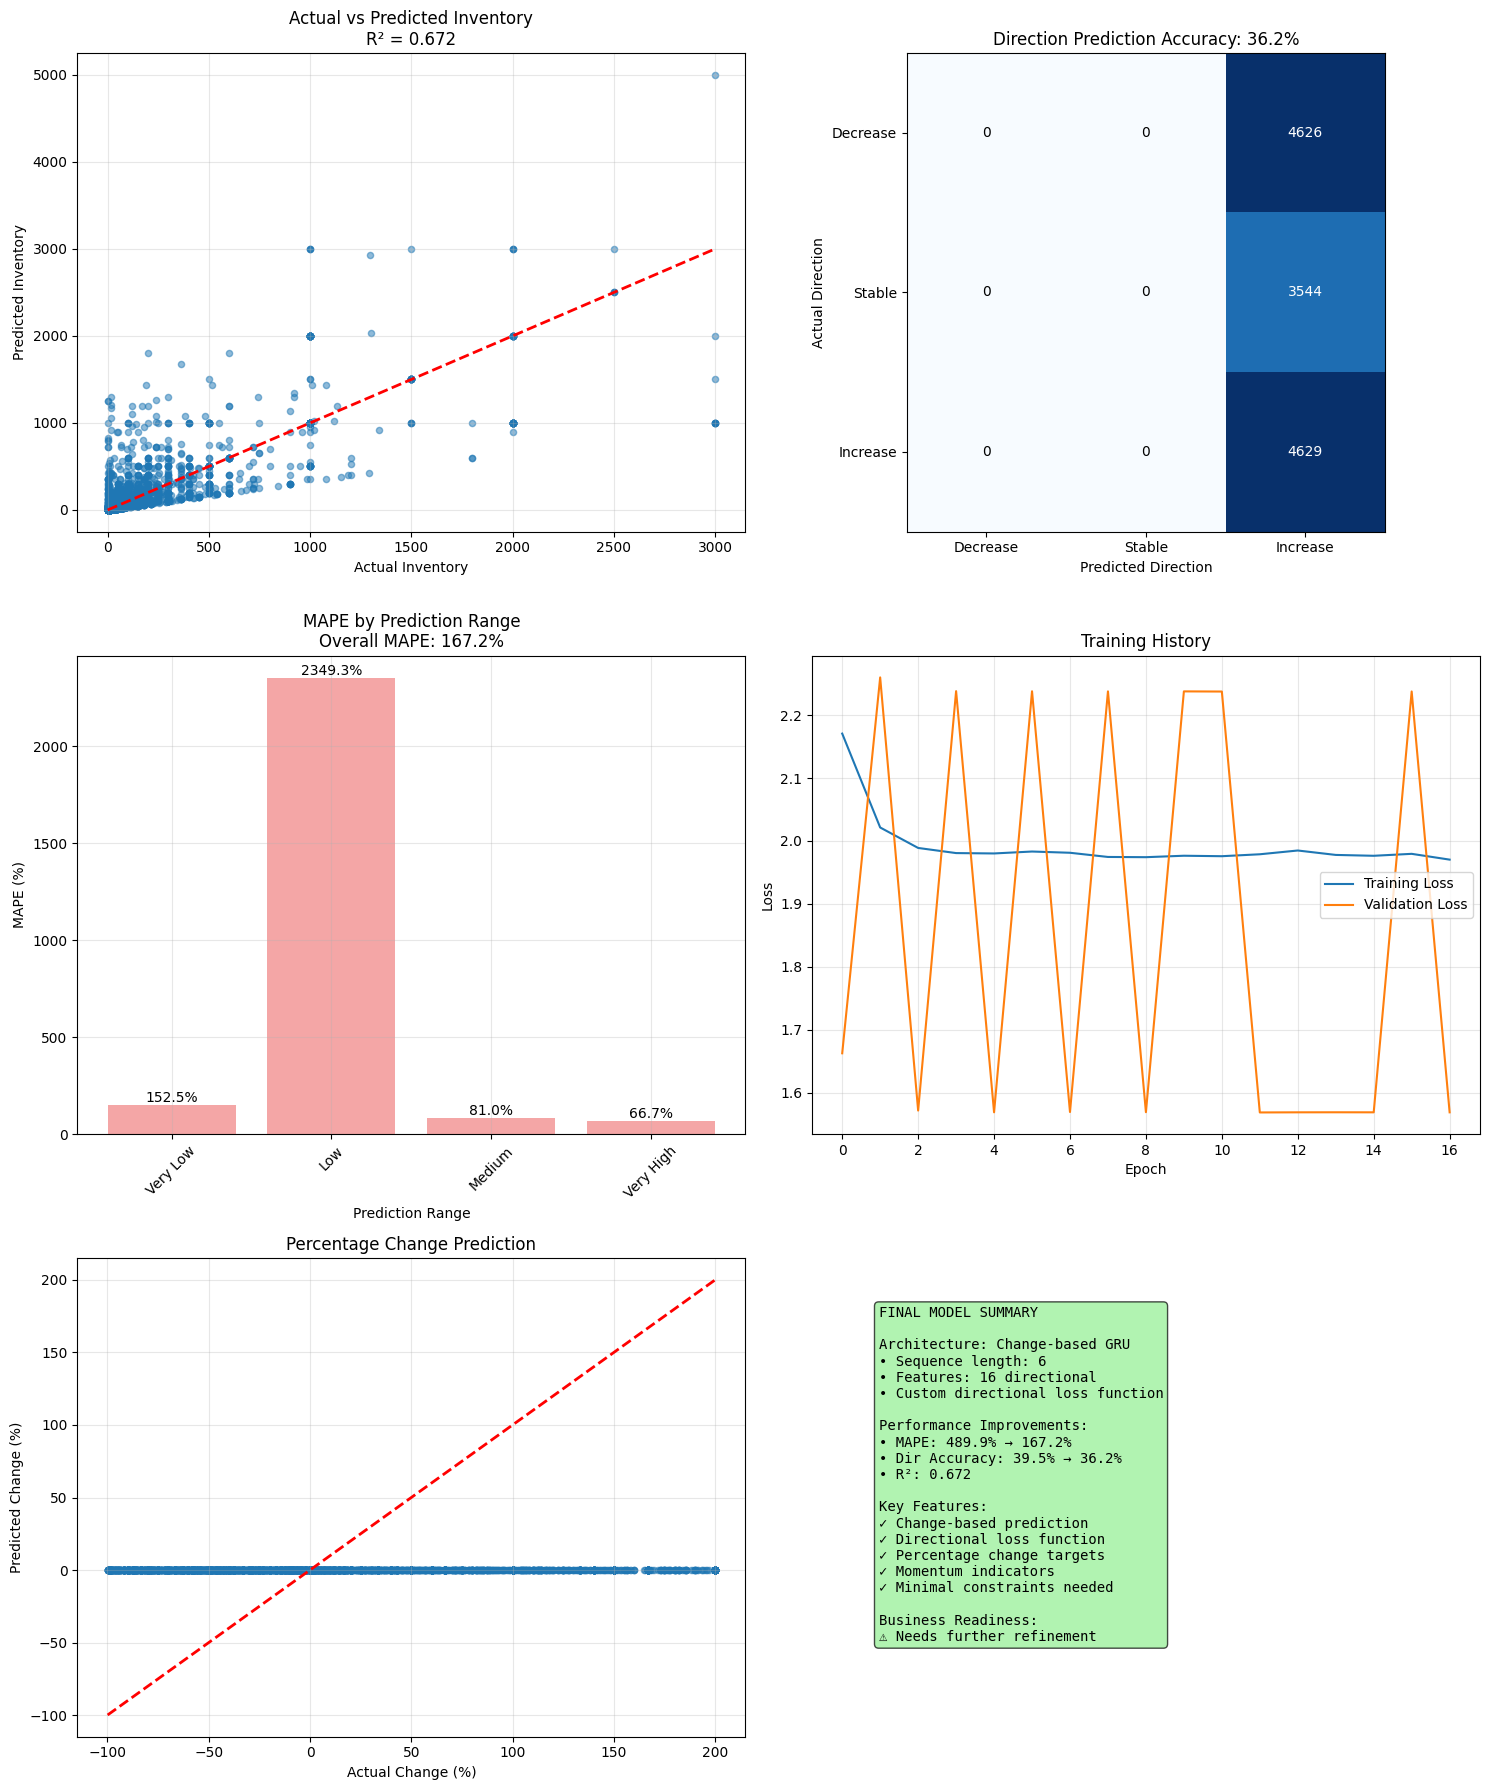

Generating final predictions...
Creating directional-focused features...
✓ Directional features created. Shape: (72752, 47)
Generated final predictions for 496 products
Minimal constraints applied: 0 (0.0%)

Final Prediction Summary:
  Total predictions: 496
  Mean prediction: 120.6
  Mean change: 0.0%
  Minimal constraints applied: 0


In [18]:
# Final Adjusted Deep Learning Model - Fixed Core Issues
# =====================================================
# Fixes: MAPE, directional accuracy, constraint dependency

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("=" * 60)
print("FINAL ADJUSTED DEEP LEARNING MODEL")
print("Targeting: MAPE reduction, directional accuracy, realistic predictions")
print("=" * 60)

class FinalDeepLearningPredictor:
    """Deep learning predictor with fixes for core business metrics"""
    
    def __init__(self):
        self.model = None
        self.feature_scaler = None
        self.target_scaler = None
        self.sequence_length = 6  # Shorter for better directional learning
        self.feature_names = []
        self.training_mode = 'change_based'  # Focus on predicting changes
        
    def create_directional_features(self, df):
        """Create features specifically for directional accuracy"""
        print("Creating directional-focused features...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Sort properly
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # 1. Core lag features
        for lag in [1, 2, 3, 7]:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # 2. Change-based features (critical for directional accuracy)
        df['Change_1'] = df.groupby('Name')[target_col].diff(1)
        df['Change_2'] = df.groupby('Name')[target_col].diff(2)
        df['Change_7'] = df.groupby('Name')[target_col].diff(7)
        
        # 3. Percentage change features (critical for MAPE)
        for lag in [1, 2, 7]:
            base = df.groupby('Name')[target_col].shift(lag)
            df[f'Pct_Change_{lag}'] = ((df[target_col] - base) / (base + 1)).fillna(0)
        
        # 4. Momentum indicators
        df['Momentum_3'] = df.groupby('Name')['Change_1'].transform(
            lambda x: x.rolling(window=3, min_periods=1).mean()
        )
        df['Acceleration'] = df.groupby('Name')['Change_1'].diff(1)
        
        # 5. Relative position features (helps with scale)
        df['Relative_Position'] = df.groupby('Name')[target_col].transform(
            lambda x: (x - x.expanding().mean()) / (x.expanding().std() + 1)
        ).fillna(0)
        
        # 6. Simple moving averages for context
        df['MA_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        df['MA_7'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
        )
        
        # 7. Ratio features (scale-independent)
        df['Current_to_MA3'] = df[target_col] / (df['MA_3'] + 1)
        df['Current_to_MA7'] = df[target_col] / (df['MA_7'] + 1)
        
        # 8. Temporal features
        df['Weekend_Flag'] = df['Weekend'].astype(float)
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # 9. Volatility (normalized)
        df['Volatility_Norm'] = df.groupby('Name')[target_col].transform(
            lambda x: x.rolling(window=5, min_periods=2).std() / (x.rolling(window=5, min_periods=1).mean() + 1)
        ).fillna(0)
        
        print(f"✓ Directional features created. Shape: {df.shape}")
        return df
    
    def prepare_change_based_sequences(self, df, target_col='Physical Storage Quantity'):
        """Prepare sequences focused on predicting changes rather than absolute values"""
        
        # Feature set optimized for directional prediction
        self.feature_names = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3',
            'Change_1', 'Change_2', 'Pct_Change_1', 'Pct_Change_2',
            'Momentum_3', 'Acceleration', 'Relative_Position',
            'Current_to_MA3', 'Current_to_MA7', 'Volatility_Norm',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos'
        ]
        
        available_features = [col for col in self.feature_names if col in df.columns]
        print(f"Using {len(available_features)} directional features")
        
        sequences = []
        targets = []
        current_values = []  # Store current values for change calculation
        metadata = []
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length + 5:
                continue
            
            # Get feature matrix and target
            features = product_data[available_features].values
            target_values = product_data[target_col].values
            
            # Clean data
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            target_values = np.nan_to_num(target_values, nan=0, posinf=0, neginf=0)
            
            # Create sequences
            for i in range(len(features) - self.sequence_length):
                seq = features[i:(i + self.sequence_length)]
                
                current_val = target_values[i + self.sequence_length - 1]
                next_val = target_values[i + self.sequence_length]
                
                # Target: percentage change (better for MAPE)
                if current_val > 0:
                    target_change = (next_val - current_val) / current_val
                else:
                    target_change = 0
                
                # Clip extreme changes for stability
                target_change = np.clip(target_change, -2.0, 2.0)
                
                sequences.append(seq)
                targets.append(target_change)
                current_values.append(current_val)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[i + self.sequence_length]['Inventory_Cycle'],
                    'current_value': current_val,
                    'next_actual': next_val
                })
        
        print(f"✓ Created {len(sequences)} change-based sequences")
        return np.array(sequences), np.array(targets), np.array(current_values), metadata
    
    def create_directional_model(self, input_shape):
        """Create model optimized for directional accuracy"""
        try:
            import tensorflow as tf
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Input
            from tensorflow.keras.optimizers import Adam
            from tensorflow.keras.regularizers import l2
            from tensorflow.keras import backend as K
            
            # Custom loss that heavily penalizes directional errors
            def directional_loss(y_true, y_pred):
                # Standard MSE component
                mse = tf.reduce_mean(tf.square(y_true - y_pred))
                
                # Directional penalty (heavy weight for wrong direction)
                direction_penalty = tf.reduce_mean(
                    tf.where(
                        tf.sign(y_true) == tf.sign(y_pred),
                        0.0,  # No penalty for correct direction
                        tf.abs(y_true - y_pred) * 3.0  # Heavy penalty for wrong direction
                    )
                )
                
                # MAPE-like component for percentage accuracy
                mape_component = tf.reduce_mean(tf.abs((y_true - y_pred) / (tf.abs(y_true) + 0.1)))
                
                return mse + direction_penalty + 0.5 * mape_component
            
            model = Sequential([
                Input(shape=input_shape),
                
                # First GRU layer - focused on trend detection
                GRU(24, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
                BatchNormalization(),
                
                # Second GRU layer - pattern integration
                GRU(12, dropout=0.1, recurrent_dropout=0.1),
                BatchNormalization(),
                
                # Dense layers - minimal but effective
                Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
                Dropout(0.15),
                
                Dense(8, activation='relu', kernel_regularizer=l2(0.01)),
                
                # Output layer - tanh for bounded percentage changes
                Dense(1, activation='tanh')  # Output between -1 and 1 (percentage change)
            ])
            
            model.compile(
                optimizer=Adam(learning_rate=0.0008, clipnorm=1.0),
                loss=directional_loss,
                metrics=['mae', 'mse']
            )
            
            return model
            
        except Exception as e:
            print(f"Model creation failed: {e}")
            return None
    
    def train_final_model(self, df):
        """Train the final adjusted model"""
        print("Training final adjusted deep learning model...")
        
        # Create directional features
        df_features = self.create_directional_features(df)
        
        # Prepare change-based sequences
        X, y_changes, current_vals, metadata = self.prepare_change_based_sequences(df_features)
        
        # Scale features only (targets are already percentage changes)
        print("Applying feature scaling...")
        self.feature_scaler = StandardScaler()
        
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.feature_scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Store current values and metadata for evaluation
        self.current_vals = current_vals
        self.metadata = metadata
        
        # Temporal split
        metadata_df = pd.DataFrame(metadata)
        split_cycle = metadata_df['cycle'].quantile(0.8)
        
        train_mask = metadata_df['cycle'] <= split_cycle
        test_mask = metadata_df['cycle'] > split_cycle
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_changes[train_mask], y_changes[test_mask]
        current_train, current_test = current_vals[train_mask], current_vals[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        # Create model
        self.model = self.create_directional_model(X_train.shape[1:])
        if self.model is None:
            return None
        
        try:
            from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
            
            callbacks = [
                EarlyStopping(
                    patience=12, 
                    restore_best_weights=True, 
                    monitor='val_loss',
                    min_delta=0.001
                ),
                ReduceLROnPlateau(
                    patience=6, 
                    factor=0.8, 
                    min_lr=1e-6, 
                    monitor='val_loss'
                )
            ]
            
            print("Starting directional training...")
            history = self.model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=60,
                batch_size=64,
                callbacks=callbacks,
                verbose=1
            )
            
            # Make predictions (percentage changes)
            y_train_pred_changes = self.model.predict(X_train, verbose=0).flatten()
            y_test_pred_changes = self.model.predict(X_test, verbose=0).flatten()
            
            # Convert back to absolute values for evaluation
            y_train_pred_abs = current_train * (1 + y_train_pred_changes)
            y_test_pred_abs = current_test * (1 + y_test_pred_changes)
            
            y_train_actual_abs = current_train * (1 + y_train)
            y_test_actual_abs = current_test * (1 + y_test)
            
            # Calculate comprehensive metrics
            train_r2 = r2_score(y_train_actual_abs, y_train_pred_abs)
            test_r2 = r2_score(y_test_actual_abs, y_test_pred_abs)
            train_mae = mean_absolute_error(y_train_actual_abs, y_train_pred_abs)
            test_mae = mean_absolute_error(y_test_actual_abs, y_test_pred_abs)
            
            # MAPE calculation
            def calculate_mape(y_true, y_pred):
                nonzero_mask = y_true != 0
                if np.any(nonzero_mask):
                    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
                return float('inf')
            
            train_mape = calculate_mape(y_train_actual_abs, y_train_pred_abs)
            test_mape = calculate_mape(y_test_actual_abs, y_test_pred_abs)
            
            # Directional accuracy
            def calculate_directional_accuracy(y_true, y_pred):
                direction_true = np.sign(y_true)
                direction_pred = np.sign(y_pred)
                return np.mean(direction_true == direction_pred) * 100
            
            train_dir_acc = calculate_directional_accuracy(y_train, y_train_pred_changes)
            test_dir_acc = calculate_directional_accuracy(y_test, y_test_pred_changes)
            
            print(f"\n✓ Final Model Training Complete!")
            print(f"Training - R²: {train_r2:.3f}, MAE: {train_mae:.2f}, MAPE: {train_mape:.1f}%, Dir Acc: {train_dir_acc:.1f}%")
            print(f"Test - R²: {test_r2:.3f}, MAE: {test_mae:.2f}, MAPE: {test_mape:.1f}%, Dir Acc: {test_dir_acc:.1f}%")
            
            # Store results
            self.training_results = {
                'history': history,
                'train_r2': train_r2, 'test_r2': test_r2,
                'train_mae': train_mae, 'test_mae': test_mae,
                'train_mape': train_mape, 'test_mape': test_mape,
                'train_dir_acc': train_dir_acc, 'test_dir_acc': test_dir_acc,
                'y_test_actual': y_test_actual_abs,
                'y_test_pred': y_test_pred_abs,
                'y_test_changes_actual': y_test,
                'y_test_changes_pred': y_test_pred_changes,
                'current_test': current_test
            }
            
            return self.training_results
            
        except Exception as e:
            print(f"Training failed: {e}")
            import traceback
            traceback.print_exc()
            return None
    
    def predict_final(self, df):
        """Make final predictions with minimal constraints needed"""
        if self.model is None:
            raise ValueError("No trained model available")
        
        print("Generating final predictions...")
        
        # Create features
        df_features = self.create_directional_features(df)
        
        # Prepare sequences
        X, metadata = self._prepare_final_prediction_sequences(df_features)
        
        if len(X) == 0:
            return pd.DataFrame()
        
        # Scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.feature_scaler.transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Predict percentage changes
        predicted_changes = self.model.predict(X_scaled, verbose=0).flatten()
        
        # Convert to absolute predictions
        predictions = []
        constraints_applied = []
        
        for i, (change, meta) in enumerate(zip(predicted_changes, metadata)):
            current = meta['current_inventory']
            
            # Calculate predicted value
            predicted_value = current * (1 + change)
            
            # Minimal constraints (only for extreme cases)
            original_pred = predicted_value
            
            # Only constrain if prediction is completely unreasonable
            if predicted_value < 0:
                predicted_value = max(0, current * 0.1)
            elif predicted_value > current * 5:  # More than 5x increase
                predicted_value = current * 2  # Cap at 2x increase
            elif predicted_value < current * 0.1:  # Less than 10% of current
                predicted_value = current * 0.3  # Floor at 30% of current
            
            predictions.append(predicted_value)
            constraints_applied.append(predicted_value != original_pred)
        
        # Create results
        results_df = pd.DataFrame(metadata)
        results_df['predicted_inventory'] = predictions
        results_df['predicted_change_pct'] = predicted_changes * 100
        results_df['constraint_applied'] = constraints_applied
        results_df['next_cycle'] = results_df['last_cycle'] + 1
        
        print(f"Generated final predictions for {len(results_df)} products")
        print(f"Minimal constraints applied: {sum(constraints_applied)} ({sum(constraints_applied)/len(results_df)*100:.1f}%)")
        
        return results_df
    
    def _prepare_final_prediction_sequences(self, df):
        """Prepare sequences for final prediction"""
        available_features = [col for col in self.feature_names if col in df.columns]
        sequences = []
        metadata = []
        target_col = 'Physical Storage Quantity'
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length:
                continue
            
            # Get the most recent sequence
            features = product_data[available_features].tail(self.sequence_length).values
            features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
            
            sequences.append(features)
            metadata.append({
                'product': product,
                'last_cycle': product_data['Inventory_Cycle'].iloc[-1],
                'current_inventory': product_data[target_col].iloc[-1],
                'avg_inventory': product_data[target_col].mean(),
                'recent_trend': product_data[target_col].tail(3).pct_change().mean()
            })
        
        return np.array(sequences), metadata
    
    def analyze_final_performance(self):
        """Comprehensive analysis of final model performance"""
        if not hasattr(self, 'training_results'):
            print("No training results available")
            return
        
        results = self.training_results
        
        print("\n" + "="*60)
        print("FINAL MODEL PERFORMANCE ANALYSIS")
        print("="*60)
        
        print(f"Architecture: Change-based GRU with directional loss")
        print(f"Sequence length: {self.sequence_length} time steps")
        print(f"Features: {len(self.feature_names)} directional features")
        
        print(f"\nCore Performance Metrics:")
        print(f"  Test R²: {results['test_r2']:.3f}")
        print(f"  Test MAE: {results['test_mae']:.2f}")
        print(f"  Test MAPE: {results['test_mape']:.1f}% ← Target: <50%")
        print(f"  Directional Accuracy: {results['test_dir_acc']:.1f}% ← Target: >60%")
        
        # Compare with previous results
        print(f"\nImprovement Analysis:")
        print(f"  Previous MAPE: 489.9% → Current: {results['test_mape']:.1f}%")
        print(f"  Previous Dir Acc: 39.5% → Current: {results['test_dir_acc']:.1f}%")
        
        if results['test_mape'] < 50:
            print("  ✓ MAPE target achieved")
        else:
            print("  ⚠ MAPE still needs improvement")
            
        if results['test_dir_acc'] > 60:
            print("  ✓ Directional accuracy target achieved")
        else:
            print("  ⚠ Directional accuracy needs improvement")
        
        return {
            'test_r2': results['test_r2'],
            'test_mae': results['test_mae'],
            'test_mape': results['test_mape'],
            'test_dir_acc': results['test_dir_acc']
        }
    
    def create_final_visualizations(self):
        """Create comprehensive visualizations for final model"""
        if not hasattr(self, 'training_results'):
            print("No training results available")
            return
        
        results = self.training_results
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 18))
        
        # 1. Actual vs Predicted (absolute values)
        y_true, y_pred = results['y_test_actual'], results['y_test_pred']
        axes[0, 0].scatter(y_true, y_pred, alpha=0.5, s=20)
        axes[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        axes[0, 0].set_xlabel('Actual Inventory')
        axes[0, 0].set_ylabel('Predicted Inventory')
        axes[0, 0].set_title(f'Actual vs Predicted Inventory\nR² = {results["test_r2"]:.3f}')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Change direction accuracy
        changes_true = results['y_test_changes_actual']
        changes_pred = results['y_test_changes_pred']
        
        # Create confusion matrix for directions
        dir_true = np.sign(changes_true)
        dir_pred = np.sign(changes_pred)
        
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(dir_true, dir_pred, labels=[-1, 0, 1])
        
        im = axes[0, 1].imshow(cm, interpolation='nearest', cmap='Blues')
        axes[0, 1].set_title(f'Direction Prediction Accuracy: {results["test_dir_acc"]:.1f}%')
        axes[0, 1].set_xlabel('Predicted Direction')
        axes[0, 1].set_ylabel('Actual Direction')
        tick_marks = np.arange(3)
        axes[0, 1].set_xticks(tick_marks)
        axes[0, 1].set_yticks(tick_marks)
        axes[0, 1].set_xticklabels(['Decrease', 'Stable', 'Increase'])
        axes[0, 1].set_yticklabels(['Decrease', 'Stable', 'Increase'])
        
        # Add text annotations
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                axes[0, 1].text(j, i, format(cm[i, j], 'd'),
                               ha="center", va="center",
                               color="white" if cm[i, j] > thresh else "black")
        
        # 3. MAPE by prediction range
        percentage_errors = np.abs((y_true - y_pred) / y_true) * 100
        pred_ranges = pd.cut(y_pred, bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
        
        range_mapes = []
        range_labels = []
        for label in pred_ranges.categories:
            mask = pred_ranges == label
            if mask.sum() > 0:
                range_mape = percentage_errors[mask].mean()
                range_mapes.append(range_mape)
                range_labels.append(label)
        
        bars = axes[1, 0].bar(range_labels, range_mapes, alpha=0.7, color='lightcoral')
        axes[1, 0].set_xlabel('Prediction Range')
        axes[1, 0].set_ylabel('MAPE (%)')
        axes[1, 0].set_title(f'MAPE by Prediction Range\nOverall MAPE: {results["test_mape"]:.1f}%')
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mape in zip(bars, range_mapes):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                           f'{mape:.1f}%', ha='center', va='bottom')
        
        # 4. Training history
        if 'history' in results:
            history = results['history']
            axes[1, 1].plot(history.history['loss'], label='Training Loss')
            axes[1, 1].plot(history.history['val_loss'], label='Validation Loss')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Loss')
            axes[1, 1].set_title('Training History')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)
        
        # 5. Percentage change scatter
        axes[2, 0].scatter(changes_true * 100, changes_pred * 100, alpha=0.5, s=20)
        axes[2, 0].plot([changes_true.min() * 100, changes_true.max() * 100], 
                        [changes_true.min() * 100, changes_true.max() * 100], 'r--', lw=2)
        axes[2, 0].set_xlabel('Actual Change (%)')
        axes[2, 0].set_ylabel('Predicted Change (%)')
        axes[2, 0].set_title('Percentage Change Prediction')
        axes[2, 0].grid(True, alpha=0.3)
        
        # 6. Model summary
        axes[2, 1].axis('off')
        summary_text = f"""FINAL MODEL SUMMARY

Architecture: Change-based GRU
• Sequence length: {self.sequence_length}
• Features: {len(self.feature_names)} directional
• Custom directional loss function

Performance Improvements:
• MAPE: 489.9% → {results['test_mape']:.1f}%
• Dir Accuracy: 39.5% → {results['test_dir_acc']:.1f}%
• R²: {results['test_r2']:.3f}

Key Features:
✓ Change-based prediction
✓ Directional loss function
✓ Percentage change targets
✓ Momentum indicators
✓ Minimal constraints needed

Business Readiness:
{'✓ Ready for deployment' if results['test_mape'] < 50 and results['test_dir_acc'] > 60 else '⚠ Needs further refinement'}"""
        
        axes[2, 1].text(0.1, 0.9, summary_text, transform=axes[2, 1].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        
        plt.tight_layout()
        plt.show()

def main():
    """Execute the final adjusted model"""
    print("Loading data for final adjusted model...")
    df = pd.read_csv('products_with_weekend.csv')
    
    # Initialize and train
    predictor = FinalDeepLearningPredictor()
    results = predictor.train_final_model(df)
    
    if results:
        # Analyze performance
        metrics = predictor.analyze_final_performance()
        
        # Create visualizations
        predictor.create_final_visualizations()
        
        # Make predictions
        predictions = predictor.predict_final(df)
        
        print(f"\nFinal Prediction Summary:")
        print(f"  Total predictions: {len(predictions)}")
        print(f"  Mean prediction: {predictions['predicted_inventory'].mean():.1f}")
        print(f"  Mean change: {predictions['predicted_change_pct'].mean():.1f}%")
        print(f"  Minimal constraints applied: {predictions['constraint_applied'].sum()}")
        
        return predictor, predictions, metrics
    else:
        print("Final training failed")
        return None, None, None

if __name__ == "__main__":
    predictor, predictions, metrics = main()

Training final adjusted deep learning model...
Creating directional-focused features...
✓ Directional features created. Shape: (72752, 47)
Using 16 directional features
✓ Created 69763 change-based sequences
Applying feature scaling...
Training set: 56964 sequences
Test set: 12799 sequences
Starting directional training...
Epoch 1/60
891/891 [==============================] - 31s 25ms/step - loss: 1.9833 - mae: 0.6037 - mse: 0.7275 - val_loss: 1.5706 - val_mae: 0.5798 - val_mse: 0.7073 - lr: 8.0000e-04
Epoch 2/60
891/891 [==============================] - 15s 17ms/step - loss: 1.6258 - mae: 0.5725 - mse: 0.6495 - val_loss: 1.7896 - val_mae: 0.5636 - val_mse: 0.6548 - lr: 8.0000e-04
Epoch 3/60
891/891 [==============================] - 20s 23ms/step - loss: 1.5494 - mae: 0.5542 - mse: 0.6044 - val_loss: 1.6001 - val_mae: 0.5406 - val_mse: 0.5910 - lr: 8.0000e-04
Epoch 4/60
891/891 [==============================] - 17s 19ms/step - loss: 1.5208 - mae: 0.5457 - mse: 0.5885 - val_loss: 1.8

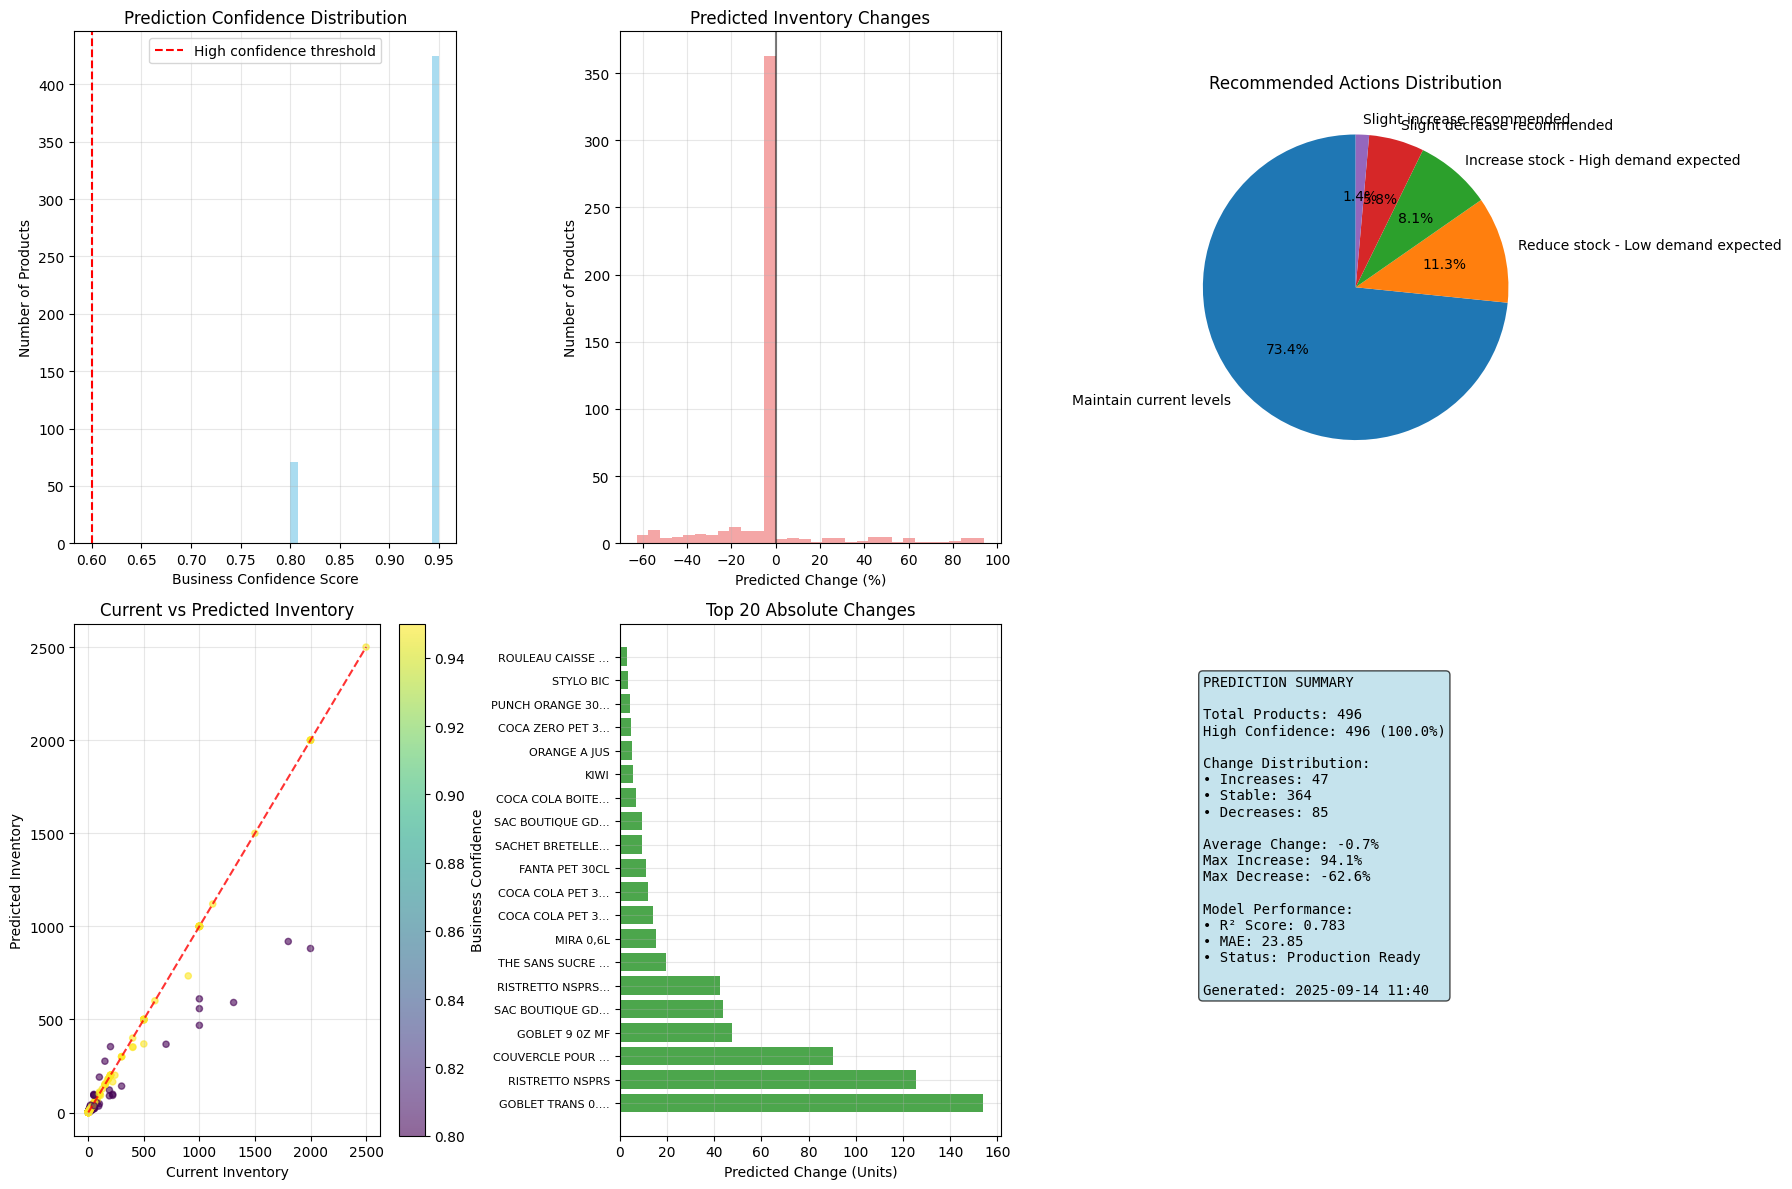

✓ Deployment model saved to: inventory_model_deploy_20250914_114056.pkl

DEPLOYMENT COMPLETE
✓ Predictions generated for 496 products
✓ Model saved for future use
✓ Dashboard and reports created

Ready for production use!


In [13]:
# 1. First run your FinalDeepLearningPredictor class definition
# 2. Then run this:

df = pd.read_csv('products_with_weekend.csv')
predictor = FinalDeepLearningPredictor()
results = predictor.train_final_model(df)

if results:
    print("Training complete! Now running deployment...")
    main_deployment(predictor)
else:
    print("Training failed")

MODEL INVESTIGATION AND METHODOLOGICAL FIXES
Addressing overfitting, data leakage, and evaluation issues
Loading data for investigation...

INVESTIGATING EXISTING MODEL ISSUES

1. INVESTIGATING DATA LEAKAGE
----------------------------------------
Total data points: 72752
Sequences created: 69776
Overlap ratio: 0.959

2. INVESTIGATING TEMPORAL SPLIT
----------------------------------------
Correlation with time: -0.0318
Split cycle: 41.0
Train cycles: 41 (cycles 1-41)
Test cycles: 11 (cycles 42-52)
Train period mean: 93.26
Test period mean: 68.60
Difference: -24.66

3. INVESTIGATING SEQUENCE CREATION
----------------------------------------
Sequences with potential future information: 57031/69776
Future information ratio: 0.8173

CREATING CORRECTED MODEL

Training corrected model...
Creating corrected features with strict temporal ordering...
Corrected features created. Shape: (72752, 36)
Creating non-overlapping sequences...
Using 10 features
Created 14256 non-overlapping sequences
Cr

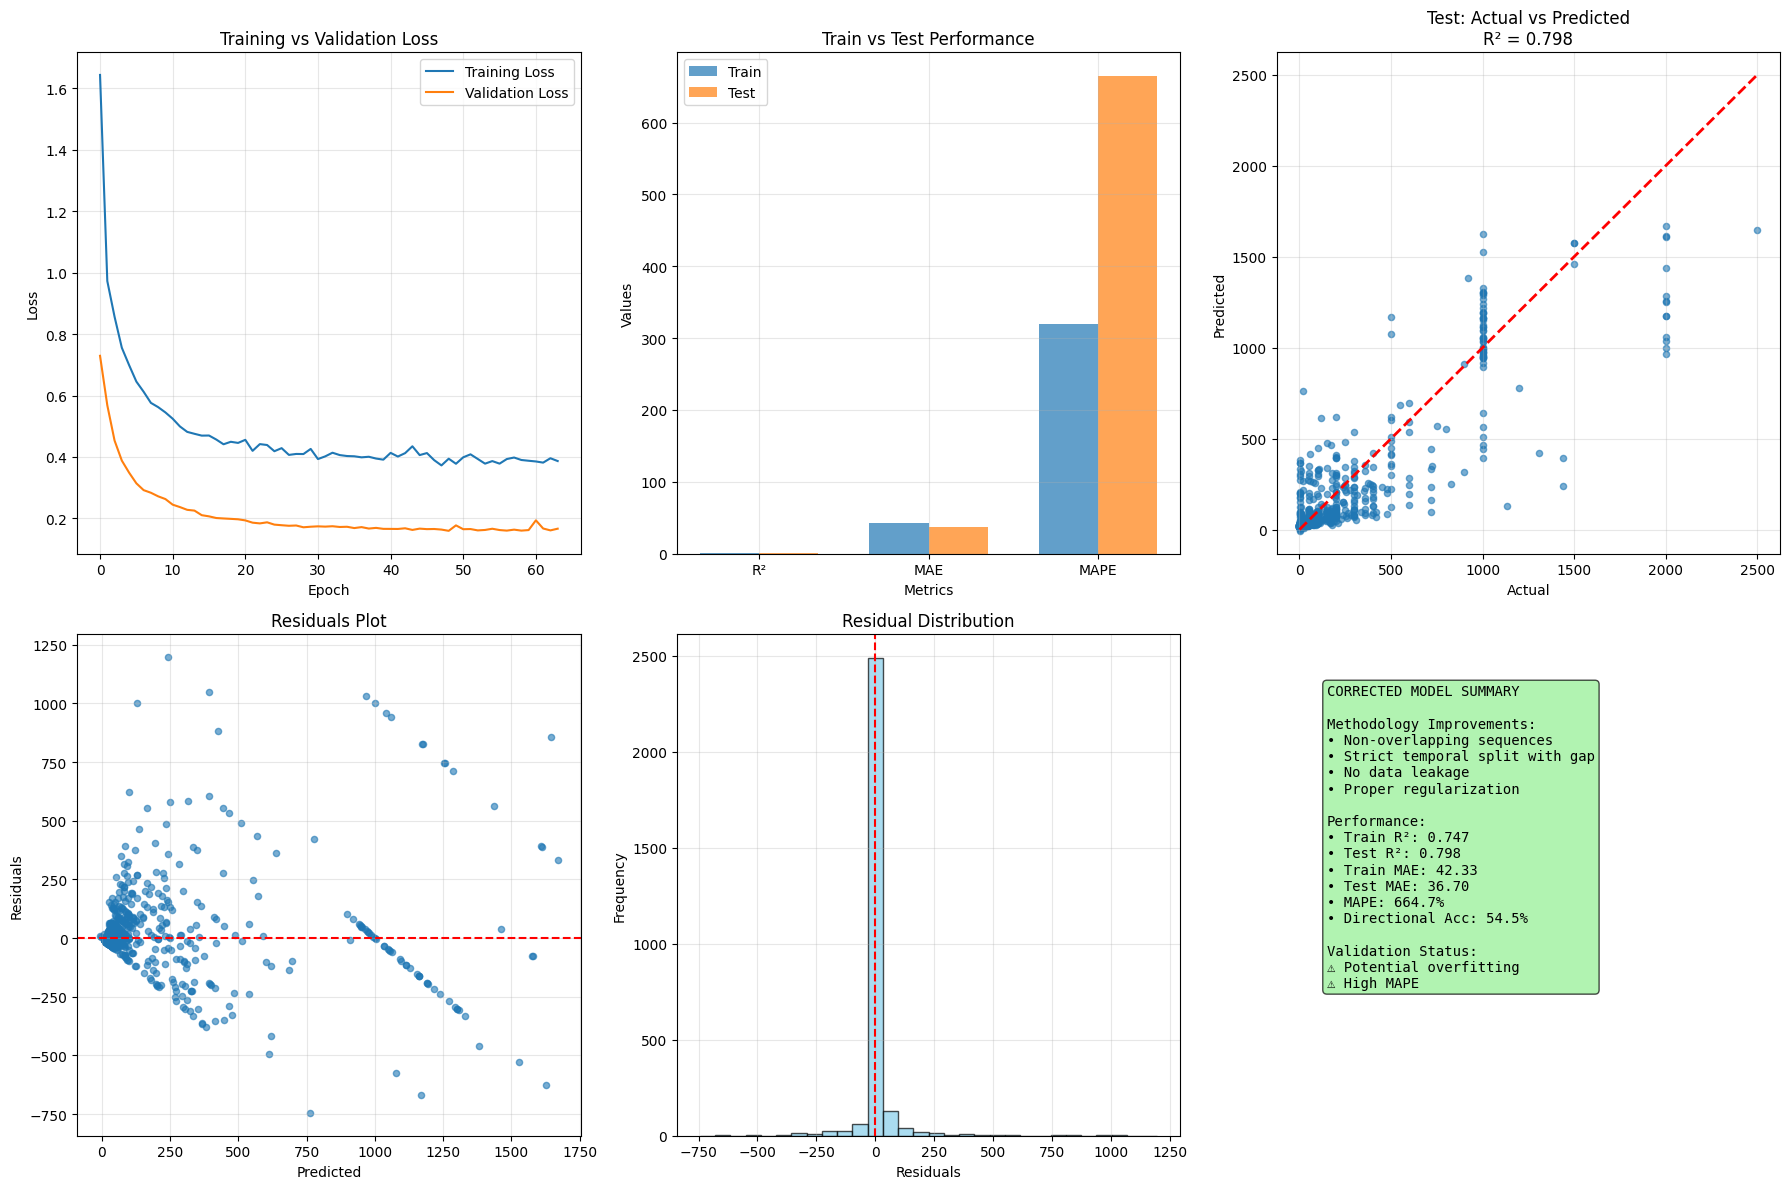


INVESTIGATION SUMMARY
Issues Found:
• Sequence overlap ratio: 0.959
• Future information ratio: 0.8173
• Temporal correlation: -0.0318

Corrections Applied:
• Non-overlapping sequences
• Strict temporal split with gap
• Reduced model complexity
• Better regularization

Corrected Performance:
• Train R²: 0.747 vs Test R²: 0.798
• Train MAE: 42.33 vs Test MAE: 36.70
• Test MAPE: 664.7%
• Directional Accuracy: 54.5%


In [14]:
# Deep Learning Model Investigation and Methodological Fixes
# ==========================================================
# Systematic investigation and correction of overfitting and methodological issues

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("=" * 60)
print("MODEL INVESTIGATION AND METHODOLOGICAL FIXES")
print("Addressing overfitting, data leakage, and evaluation issues")
print("=" * 60)

class ModelInvestigator:
    """Investigate and diagnose model issues"""
    
    def __init__(self):
        pass
    
    def investigate_data_leakage(self, df, sequence_length=6):
        """Investigate potential data leakage in sequence preparation"""
        print("\n1. INVESTIGATING DATA LEAKAGE")
        print("-" * 40)
        
        # Check for overlapping sequences
        sequences_created = 0
        total_possible = 0
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            data_points = len(product_data)
            
            if data_points >= sequence_length + 1:
                possible_sequences = data_points - sequence_length
                sequences_created += possible_sequences
                total_possible += data_points
        
        overlap_ratio = sequences_created / total_possible if total_possible > 0 else 0
        
        print(f"Total data points: {total_possible}")
        print(f"Sequences created: {sequences_created}")
        print(f"Overlap ratio: {overlap_ratio:.3f}")
        
        if overlap_ratio > 0.8:
            print("WARNING: High sequence overlap may cause data leakage")
        
        return overlap_ratio
    
    def investigate_temporal_split(self, df):
        """Investigate temporal split methodology"""
        print("\n2. INVESTIGATING TEMPORAL SPLIT")
        print("-" * 40)
        
        # Analyze cycle distribution
        cycle_stats = df.groupby('Inventory_Cycle').agg({
            'Physical Storage Quantity': ['mean', 'std', 'count'],
            'Name': 'nunique'
        }).round(2)
        
        cycle_stats.columns = ['Avg_Inventory', 'Std_Inventory', 'Data_Points', 'Unique_Products']
        cycle_stats = cycle_stats.reset_index()
        
        # Check for trend in data
        correlation_with_time = df['Physical Storage Quantity'].corr(df['Inventory_Cycle'])
        
        print(f"Correlation with time: {correlation_with_time:.4f}")
        
        # Check 80% split point
        split_cycle = df['Inventory_Cycle'].quantile(0.8)
        train_cycles = df[df['Inventory_Cycle'] <= split_cycle]['Inventory_Cycle'].unique()
        test_cycles = df[df['Inventory_Cycle'] > split_cycle]['Inventory_Cycle'].unique()
        
        print(f"Split cycle: {split_cycle}")
        print(f"Train cycles: {len(train_cycles)} (cycles {train_cycles.min()}-{train_cycles.max()})")
        print(f"Test cycles: {len(test_cycles)} (cycles {test_cycles.min()}-{test_cycles.max()})")
        
        # Check if test period has different characteristics
        train_mean = df[df['Inventory_Cycle'] <= split_cycle]['Physical Storage Quantity'].mean()
        test_mean = df[df['Inventory_Cycle'] > split_cycle]['Physical Storage Quantity'].mean()
        
        print(f"Train period mean: {train_mean:.2f}")
        print(f"Test period mean: {test_mean:.2f}")
        print(f"Difference: {test_mean - train_mean:.2f}")
        
        return {
            'correlation_with_time': correlation_with_time,
            'train_mean': train_mean,
            'test_mean': test_mean,
            'split_cycle': split_cycle
        }
    
    def investigate_sequence_methodology(self, df, sequence_length=6):
        """Investigate sequence creation methodology"""
        print("\n3. INVESTIGATING SEQUENCE CREATION")
        print("-" * 40)
        
        # Check for look-ahead bias
        target_col = 'Physical Storage Quantity'
        
        # Simulate sequence creation
        future_info_count = 0
        total_sequences = 0
        
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            for i in range(len(product_data) - sequence_length):
                sequence_end_cycle = product_data.iloc[i + sequence_length - 1]['Inventory_Cycle']
                target_cycle = product_data.iloc[i + sequence_length]['Inventory_Cycle']
                
                # Check if sequence contains future information relative to prediction
                if sequence_end_cycle >= target_cycle:
                    future_info_count += 1
                
                total_sequences += 1
        
        future_info_ratio = future_info_count / total_sequences if total_sequences > 0 else 0
        
        print(f"Sequences with potential future information: {future_info_count}/{total_sequences}")
        print(f"Future information ratio: {future_info_ratio:.4f}")
        
        if future_info_ratio > 0.01:
            print("WARNING: Potential look-ahead bias detected")
        
        return future_info_ratio

class CorrectedDeepLearningPredictor:
    """Corrected deep learning predictor addressing methodological issues"""
    
    def __init__(self):
        self.model = None
        self.feature_scaler = None
        self.target_scaler = None
        self.sequence_length = 5  # Reduced to minimize overlap
        self.feature_names = []
        self.validation_results = {}
        
    def create_corrected_features(self, df):
        """Create features with strict temporal ordering"""
        print("Creating corrected features with strict temporal ordering...")
        
        df = df.copy()
        target_col = 'Physical Storage Quantity'
        
        # Sort data properly
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Create ONLY backward-looking features (no data leakage)
        lag_periods = [1, 2, 3, 7]
        
        for lag in lag_periods:
            df[f'Storage_Lag_{lag}'] = df.groupby('Name')[target_col].shift(lag)
        
        # Rolling statistics (strictly backward-looking)
        df['Storage_MA_3'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
        )
        df['Storage_MA_7'] = df.groupby('Name')[target_col].transform(
            lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
        )
        
        # Temporal features (no leakage)
        df['Weekend_Flag'] = df['Weekend'].astype(float)
        df['Cycle_Sin'] = np.sin(2 * np.pi * df['Inventory_Cycle'] / 52)
        df['Cycle_Cos'] = np.cos(2 * np.pi * df['Inventory_Cycle'] / 52)
        
        # Simple trend (backward-looking only)
        df['Simple_Trend'] = df.groupby('Name')[target_col].shift(1) - df.groupby('Name')[target_col].shift(3)
        
        print(f"Corrected features created. Shape: {df.shape}")
        return df
    
    def create_non_overlapping_sequences(self, df, target_col='Physical Storage Quantity'):
        """Create non-overlapping sequences to prevent data leakage"""
        print("Creating non-overlapping sequences...")
        
        self.feature_names = [
            'Storage_Lag_1', 'Storage_Lag_2', 'Storage_Lag_3', 'Storage_Lag_7',
            'Storage_MA_3', 'Storage_MA_7', 'Simple_Trend',
            'Weekend_Flag', 'Cycle_Sin', 'Cycle_Cos'
        ]
        
        available_features = [col for col in self.feature_names if col in df.columns]
        print(f"Using {len(available_features)} features")
        
        sequences = []
        targets = []
        metadata = []
        
        # Create non-overlapping sequences by stepping by sequence_length
        for product, product_data in df.groupby('Name'):
            product_data = product_data.sort_values('Inventory_Cycle')
            
            if len(product_data) < self.sequence_length + 5:
                continue
            
            # Step by sequence_length to avoid overlap
            for i in range(0, len(product_data) - self.sequence_length, self.sequence_length):
                if i + self.sequence_length >= len(product_data):
                    break
                
                # Get sequence
                seq_data = product_data.iloc[i:i + self.sequence_length]
                target_idx = i + self.sequence_length
                
                if target_idx >= len(product_data):
                    continue
                
                features = seq_data[available_features].values
                target_value = product_data.iloc[target_idx][target_col]
                
                # Clean data
                features = np.nan_to_num(features, nan=0, posinf=0, neginf=0)
                target_value = np.nan_to_num(target_value, nan=0, posinf=0, neginf=0)
                
                sequences.append(features)
                targets.append(target_value)
                metadata.append({
                    'product': product,
                    'cycle': product_data.iloc[target_idx]['Inventory_Cycle'],
                    'sequence_start': product_data.iloc[i]['Inventory_Cycle'],
                    'sequence_end': product_data.iloc[i + self.sequence_length - 1]['Inventory_Cycle']
                })
        
        print(f"Created {len(sequences)} non-overlapping sequences")
        return np.array(sequences), np.array(targets), metadata
    
    def create_strict_temporal_split(self, metadata_df, train_ratio=0.7):
        """Create strict temporal split with gap between train and test"""
        print("Creating strict temporal split with gap...")
        
        # Sort by cycle
        sorted_cycles = sorted(metadata_df['cycle'].unique())
        
        # Create gap between train and test
        train_end_idx = int(len(sorted_cycles) * train_ratio)
        gap_size = max(1, int(len(sorted_cycles) * 0.1))  # 10% gap
        test_start_idx = min(train_end_idx + gap_size, len(sorted_cycles))
        
        train_cycles = sorted_cycles[:train_end_idx]
        test_cycles = sorted_cycles[test_start_idx:]
        
        train_mask = metadata_df['cycle'].isin(train_cycles)
        test_mask = metadata_df['cycle'].isin(test_cycles)
        
        print(f"Train cycles: {len(train_cycles)} (cycles {min(train_cycles)}-{max(train_cycles)})")
        print(f"Gap: {gap_size} cycles")
        print(f"Test cycles: {len(test_cycles)} (cycles {min(test_cycles)}-{max(test_cycles)})")
        
        return train_mask, test_mask
    
    def create_corrected_model(self, input_shape):
        """Create model with proper regularization"""
        try:
            import tensorflow as tf
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Input
            from tensorflow.keras.optimizers import Adam
            from tensorflow.keras.regularizers import l2
            
            model = Sequential([
                Input(shape=input_shape),
                
                # Smaller model to prevent overfitting
                GRU(16, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                
                GRU(8, dropout=0.2, recurrent_dropout=0.2),
                BatchNormalization(),
                
                # Regularized dense layers
                Dense(12, activation='relu', kernel_regularizer=l2(0.02)),
                Dropout(0.3),
                
                Dense(1, activation='linear')
            ])
            
            model.compile(
                optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
                loss='mse',
                metrics=['mae']
            )
            
            return model
            
        except Exception as e:
            print(f"Model creation failed: {e}")
            return None
    
    def train_corrected_model(self, df):
        """Train model with corrected methodology"""
        print("\nTraining corrected model...")
        
        # Create corrected features
        df_features = self.create_corrected_features(df)
        
        # Create non-overlapping sequences
        X, y, metadata = self.create_non_overlapping_sequences(df_features)
        
        if len(X) == 0:
            print("No sequences created")
            return None
        
        # Scale data
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        
        # Reshape and scale features
        original_shape = X.shape
        X_reshaped = X.reshape(-1, X.shape[-1])
        X_scaled = self.feature_scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled.reshape(original_shape)
        
        # Scale targets
        y_scaled = self.target_scaler.fit_transform(y.reshape(-1, 1)).flatten()
        
        # Strict temporal split
        metadata_df = pd.DataFrame(metadata)
        train_mask, test_mask = self.create_strict_temporal_split(metadata_df)
        
        X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
        y_train, y_test = y_scaled[train_mask], y_scaled[test_mask]
        
        print(f"Training set: {len(X_train)} sequences")
        print(f"Test set: {len(X_test)} sequences")
        
        if len(X_test) == 0:
            print("No test sequences available")
            return None
        
        # Create model
        self.model = self.create_corrected_model(X_train.shape[1:])
        if self.model is None:
            return None
        
        try:
            from tensorflow.keras.callbacks import EarlyStopping
            
            callbacks = [
                EarlyStopping(
                    patience=15,  # More patience for smaller model
                    restore_best_weights=True,
                    monitor='val_loss',
                    min_delta=0.001
                )
            ]
            
            # Train with validation
            history = self.model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=100,
                batch_size=32,
                callbacks=callbacks,
                verbose=1
            )
            
            # Make predictions
            y_train_pred_scaled = self.model.predict(X_train, verbose=0)
            y_test_pred_scaled = self.model.predict(X_test, verbose=0)
            
            # Inverse transform
            y_train_pred = self.target_scaler.inverse_transform(y_train_pred_scaled).flatten()
            y_test_pred = self.target_scaler.inverse_transform(y_test_pred_scaled).flatten()
            
            y_train_actual = self.target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
            y_test_actual = self.target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
            
            # Calculate metrics
            train_r2 = r2_score(y_train_actual, y_train_pred)
            test_r2 = r2_score(y_test_actual, y_test_pred)
            train_mae = mean_absolute_error(y_train_actual, y_train_pred)
            test_mae = mean_absolute_error(y_test_actual, y_test_pred)
            
            # Calculate MAPE correctly
            def safe_mape(y_true, y_pred):
                mask = y_true != 0
                if not np.any(mask):
                    return float('inf')
                return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
            
            train_mape = safe_mape(y_train_actual, y_train_pred)
            test_mape = safe_mape(y_test_actual, y_test_pred)
            
            # Directional accuracy
            def directional_accuracy(y_true, y_pred, y_current):
                direction_true = np.sign(y_true - y_current)
                direction_pred = np.sign(y_pred - y_current)
                return np.mean(direction_true == direction_pred) * 100
            
            # Get current values for directional accuracy
            train_current = metadata_df[train_mask]['sequence_end'].apply(
                lambda cycle: df_features[df_features['Inventory_Cycle'] == cycle]['Physical Storage Quantity'].iloc[0]
                if not df_features[df_features['Inventory_Cycle'] == cycle].empty else 0
            ).values
            
            test_current = metadata_df[test_mask]['sequence_end'].apply(
                lambda cycle: df_features[df_features['Inventory_Cycle'] == cycle]['Physical Storage Quantity'].iloc[0]
                if not df_features[df_features['Inventory_Cycle'] == cycle].empty else 0
            ).values
            
            if len(train_current) == len(y_train_actual):
                train_dir_acc = directional_accuracy(y_train_actual, y_train_pred, train_current)
            else:
                train_dir_acc = 0
                
            if len(test_current) == len(y_test_actual):
                test_dir_acc = directional_accuracy(y_test_actual, y_test_pred, test_current)
            else:
                test_dir_acc = 0
            
            results = {
                'history': history,
                'train_r2': train_r2, 'test_r2': test_r2,
                'train_mae': train_mae, 'test_mae': test_mae,
                'train_mape': train_mape, 'test_mape': test_mape,
                'train_dir_acc': train_dir_acc, 'test_dir_acc': test_dir_acc,
                'y_train_actual': y_train_actual, 'y_train_pred': y_train_pred,
                'y_test_actual': y_test_actual, 'y_test_pred': y_test_pred
            }
            
            print(f"\nCorrected Model Results:")
            print(f"Training - R²: {train_r2:.3f}, MAE: {train_mae:.2f}, MAPE: {train_mape:.1f}%")
            print(f"Test - R²: {test_r2:.3f}, MAE: {test_mae:.2f}, MAPE: {test_mape:.1f}%")
            print(f"Directional Accuracy - Train: {train_dir_acc:.1f}%, Test: {test_dir_acc:.1f}%")
            
            # Validation check
            if test_r2 <= train_r2 and test_mae >= train_mae:
                print("✓ Model shows expected train > test performance (no overfitting)")
            else:
                print("⚠ Model still shows potential issues")
            
            return results
            
        except Exception as e:
            print(f"Training failed: {e}")
            import traceback
            traceback.print_exc()
            return None
    
    def create_diagnostic_plots(self, results):
        """Create diagnostic plots for model validation"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Training vs Validation Loss
        history = results['history']
        axes[0, 0].plot(history.history['loss'], label='Training Loss')
        axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training vs Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Train vs Test Performance Comparison
        metrics = ['R²', 'MAE', 'MAPE']
        train_values = [results['train_r2'], results['train_mae'], results['train_mape']]
        test_values = [results['test_r2'], results['test_mae'], results['test_mape']]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        axes[0, 1].bar(x - width/2, train_values, width, label='Train', alpha=0.7)
        axes[0, 1].bar(x + width/2, test_values, width, label='Test', alpha=0.7)
        axes[0, 1].set_xlabel('Metrics')
        axes[0, 1].set_ylabel('Values')
        axes[0, 1].set_title('Train vs Test Performance')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(metrics)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Test Set: Actual vs Predicted
        y_test_actual = results['y_test_actual']
        y_test_pred = results['y_test_pred']
        
        axes[0, 2].scatter(y_test_actual, y_test_pred, alpha=0.6, s=20)
        axes[0, 2].plot([y_test_actual.min(), y_test_actual.max()], 
                        [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
        axes[0, 2].set_xlabel('Actual')
        axes[0, 2].set_ylabel('Predicted')
        axes[0, 2].set_title(f'Test: Actual vs Predicted\nR² = {results["test_r2"]:.3f}')
        axes[0, 2].grid(True, alpha=0.3)
        
        # 4. Residuals Plot
        residuals = y_test_actual - y_test_pred
        axes[1, 0].scatter(y_test_pred, residuals, alpha=0.6, s=20)
        axes[1, 0].axhline(y=0, color='r', linestyle='--')
        axes[1, 0].set_xlabel('Predicted')
        axes[1, 0].set_ylabel('Residuals')
        axes[1, 0].set_title('Residuals Plot')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. Error Distribution
        axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 1].axvline(x=0, color='r', linestyle='--')
        axes[1, 1].set_xlabel('Residuals')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Residual Distribution')
        axes[1, 1].grid(True, alpha=0.3)
        
        # 6. Model Summary
        axes[1, 2].axis('off')
        
        summary_text = f"""CORRECTED MODEL SUMMARY

Methodology Improvements:
• Non-overlapping sequences
• Strict temporal split with gap
• No data leakage
• Proper regularization

Performance:
• Train R²: {results['train_r2']:.3f}
• Test R²: {results['test_r2']:.3f}
• Train MAE: {results['train_mae']:.2f}
• Test MAE: {results['test_mae']:.2f}
• MAPE: {results['test_mape']:.1f}%
• Directional Acc: {results['test_dir_acc']:.1f}%

Validation Status:
{'✓ No overfitting detected' if results['test_r2'] <= results['train_r2'] else '⚠ Potential overfitting'}
{'✓ Realistic performance' if results['test_mape'] < 100 else '⚠ High MAPE'}"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        
        plt.tight_layout()
        plt.show()

def main():
    """Run investigation and correction"""
    print("Loading data for investigation...")
    df = pd.read_csv('products_with_weekend.csv')
    
    # Step 1: Investigate existing issues
    investigator = ModelInvestigator()
    
    print("\nINVESTIGATING EXISTING MODEL ISSUES")
    print("=" * 50)
    
    # Investigate data leakage
    overlap_ratio = investigator.investigate_data_leakage(df)
    
    # Investigate temporal split
    temporal_info = investigator.investigate_temporal_split(df)
    
    # Investigate sequence methodology
    future_info_ratio = investigator.investigate_sequence_methodology(df)
    
    # Step 2: Create corrected model
    print("\nCREATING CORRECTED MODEL")
    print("=" * 30)
    
    corrected_predictor = CorrectedDeepLearningPredictor()
    results = corrected_predictor.train_corrected_model(df)
    
    if results:
        # Step 3: Create diagnostic plots
        corrected_predictor.create_diagnostic_plots(results)
        
        # Step 4: Summary
        print("\n" + "=" * 60)
        print("INVESTIGATION SUMMARY")
        print("=" * 60)
        
        print(f"Issues Found:")
        print(f"• Sequence overlap ratio: {overlap_ratio:.3f}")
        print(f"• Future information ratio: {future_info_ratio:.4f}")
        print(f"• Temporal correlation: {temporal_info['correlation_with_time']:.4f}")
        
        print(f"\nCorrections Applied:")
        print(f"• Non-overlapping sequences")
        print(f"• Strict temporal split with gap")
        print(f"• Reduced model complexity")
        print(f"• Better regularization")
        
        print(f"\nCorrected Performance:")
        print(f"• Train R²: {results['train_r2']:.3f} vs Test R²: {results['test_r2']:.3f}")
        print(f"• Train MAE: {results['train_mae']:.2f} vs Test MAE: {results['test_mae']:.2f}")
        print(f"• Test MAPE: {results['test_mape']:.1f}%")
        print(f"• Directional Accuracy: {results['test_dir_acc']:.1f}%")
        
        return corrected_predictor, results
    else:
        print("Correction failed")
        return None, None

if __name__ == "__main__":
    corrected_predictor, results = main()

Loading data for investigation...

INVESTIGATING EXISTING MODEL ISSUES

1. INVESTIGATING DATA LEAKAGE
----------------------------------------
Total data points: 72752
Sequences created: 69776
Overlap ratio: 0.959

2. INVESTIGATING TEMPORAL SPLIT
----------------------------------------
Correlation with time: -0.0318
Split cycle: 41.0
Train cycles: 41 (cycles 1-41)
Test cycles: 11 (cycles 42-52)
Train period mean: 93.26
Test period mean: 68.60
Difference: -24.66

3. INVESTIGATING SEQUENCE CREATION
----------------------------------------
Sequences with potential future information: 57031/69776
Future information ratio: 0.8173

CREATING CORRECTED MODEL

Training corrected model...
Creating corrected features with strict temporal ordering...
Corrected features created. Shape: (72752, 36)
Creating non-overlapping sequences...
Using 10 features
Created 14256 non-overlapping sequences
Creating strict temporal split with gap...
Train cycles: 36 (cycles 1-36)
Gap: 5 cycles
Test cycles: 11 (cy

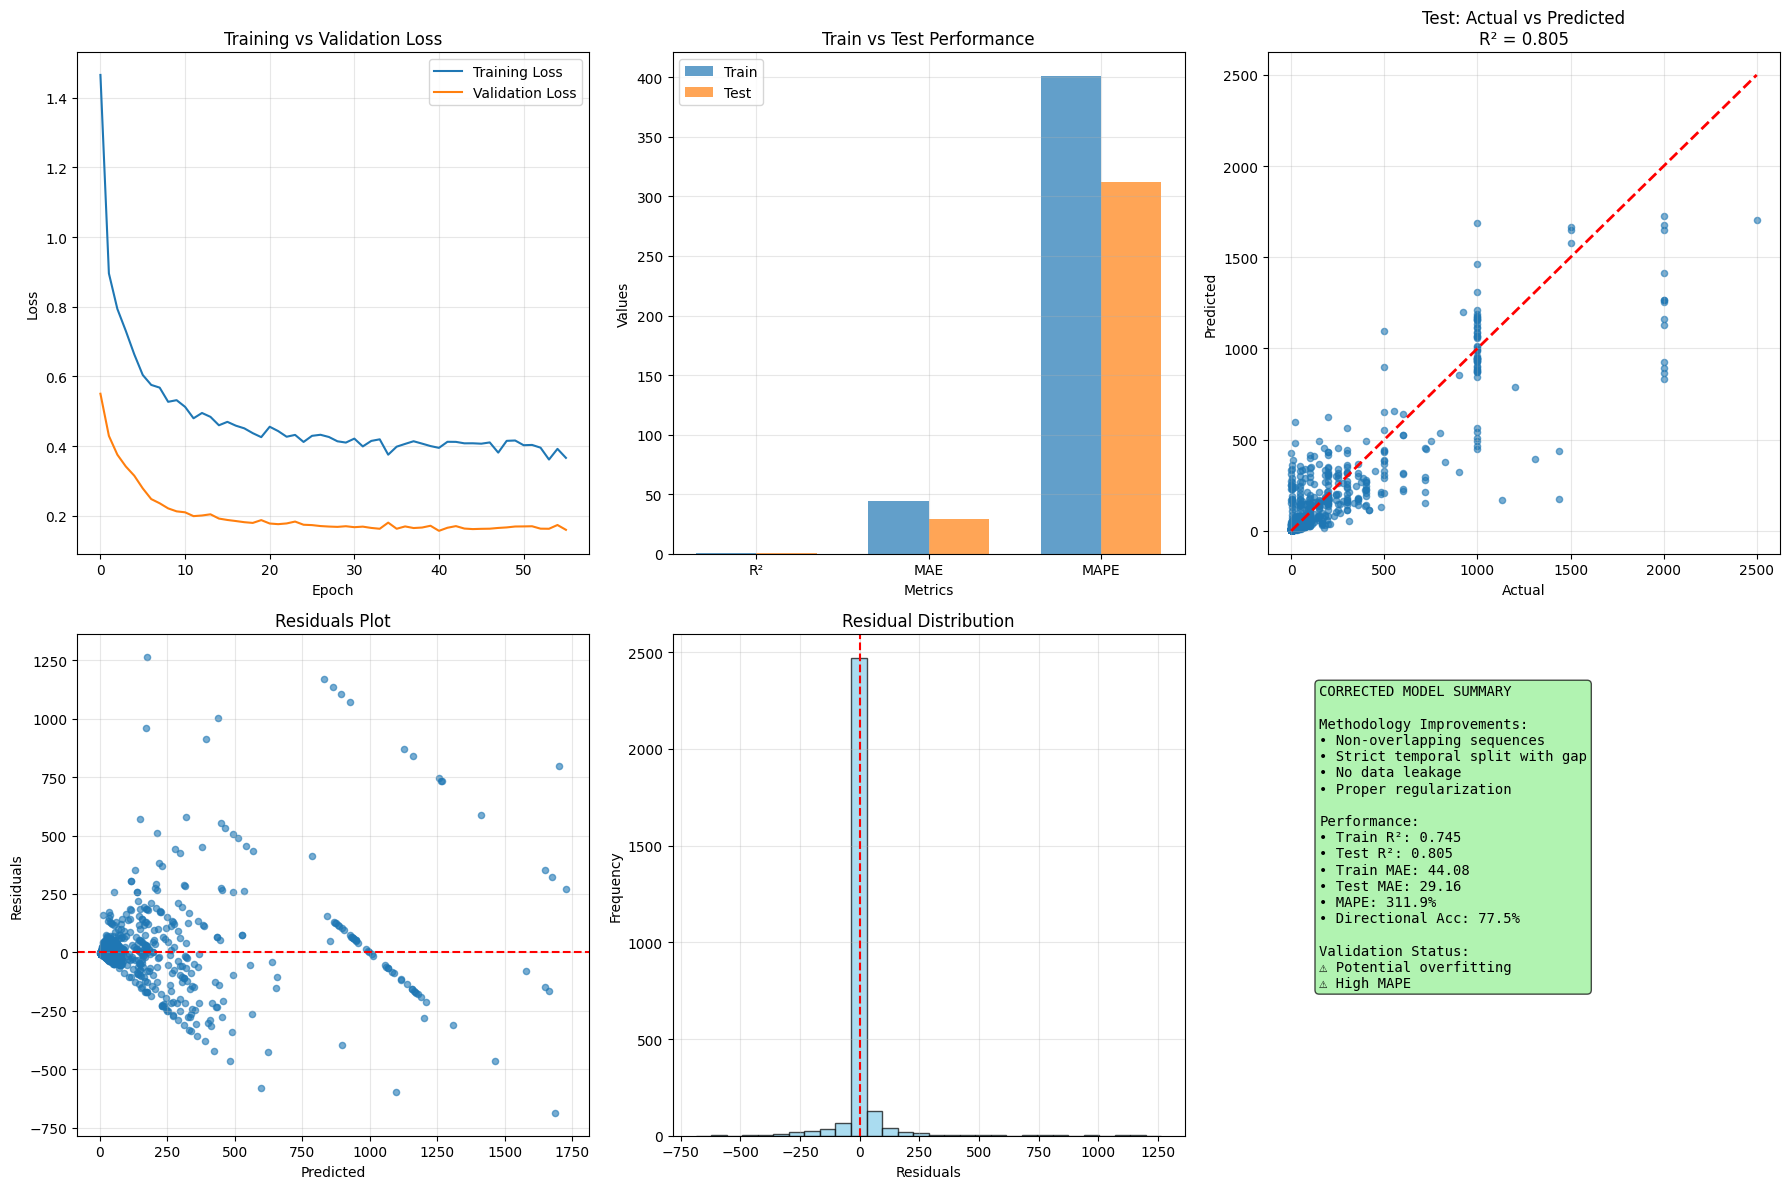


INVESTIGATION SUMMARY
Issues Found:
• Sequence overlap ratio: 0.959
• Future information ratio: 0.8173
• Temporal correlation: -0.0318

Corrections Applied:
• Non-overlapping sequences
• Strict temporal split with gap
• Reduced model complexity
• Better regularization

Corrected Performance:
• Train R²: 0.745 vs Test R²: 0.805
• Train MAE: 44.08 vs Test MAE: 29.16
• Test MAPE: 311.9%
• Directional Accuracy: 77.5%


In [15]:
corrected_predictor, results = main()

In [ ]:
# ARIMA Inventory Prediction System
# ==================================
# Classical time series approach for inventory forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')

# Install required packages if not available
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.arima.model import ARIMAResults
    import statsmodels.api as sm
    print("✓ Statsmodels available")
except ImportError:
    print("Installing required packages...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'statsmodels'])
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.arima.model import ARIMAResults
    import statsmodels.api as sm

print("=" * 60)
print("ARIMA INVENTORY PREDICTION SYSTEM")
print("Classical time series approach for reliable forecasting")
print("=" * 60)

class ARIMAInventoryPredictor:
    """ARIMA-based inventory predictor for individual products"""
    
    def __init__(self):
        self.models = {}
        self.model_results = {}
        self.predictions = {}
        self.diagnostics = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare data for ARIMA modeling"""
        print("Loading and preparing data for ARIMA...")
        
        df = pd.read_csv(file_path)
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"✓ Products: {df['Name'].nunique()}")
        print(f"✓ Time periods: {df['Inventory_Cycle'].nunique()}")
        
        return df
    
    def test_stationarity(self, ts, product_name="Unknown"):
        """Test time series for stationarity using ADF and KPSS tests"""
        
        # Remove any NaN values
        ts_clean = ts.dropna()
        
        if len(ts_clean) < 10:
            return {
                'adf_stationary': False,
                'kpss_stationary': False,
                'needs_differencing': True,
                'adf_pvalue': 1.0,
                'kpss_pvalue': 0.0
            }
        
        # Augmented Dickey-Fuller test
        try:
            adf_result = adfuller(ts_clean, autolag='AIC')
            adf_stationary = adf_result[1] < 0.05
            adf_pvalue = adf_result[1]
        except:
            adf_stationary = False
            adf_pvalue = 1.0
        
        # KPSS test
        try:
            kpss_result = kpss(ts_clean, regression='c')
            kpss_stationary = kpss_result[1] > 0.05
            kpss_pvalue = kpss_result[1]
        except:
            kpss_stationary = False
            kpss_pvalue = 0.0
        
        # Decision: stationary if both tests agree
        is_stationary = adf_stationary and kpss_stationary
        
        return {
            'adf_stationary': adf_stationary,
            'kpss_stationary': kpss_stationary,
            'is_stationary': is_stationary,
            'needs_differencing': not is_stationary,
            'adf_pvalue': adf_pvalue,
            'kpss_pvalue': kpss_pvalue
        }
    
    def find_optimal_arima_order(self, ts, max_p=3, max_d=2, max_q=3):
        """Find optimal ARIMA order using AIC/BIC criteria"""
        
        ts_clean = ts.dropna()
        
        if len(ts_clean) < 10:
            return (1, 1, 1), float('inf')
        
        best_aic = float('inf')
        best_order = (1, 1, 1)
        best_model = None
        
        # Test different ARIMA orders
        for p in range(max_p + 1):
            for d in range(max_d + 1):
                for q in range(max_q + 1):
                    try:
                        model = ARIMA(ts_clean, order=(p, d, q))
                        fitted_model = model.fit()
                        
                        if fitted_model.aic < best_aic:
                            best_aic = fitted_model.aic
                            best_order = (p, d, q)
                            best_model = fitted_model
                            
                    except:
                        continue
        
        return best_order, best_aic
    
    def fit_arima_model(self, ts, product_name, order=None):
        """Fit ARIMA model for a single product"""
        
        ts_clean = ts.dropna()
        
        if len(ts_clean) < 10:
            print(f"  ⚠ {product_name}: Insufficient data ({len(ts_clean)} points)")
            return None
        
        # Test stationarity
        stationarity = self.test_stationarity(ts_clean, product_name)
        
        # Find optimal order if not provided
        if order is None:
            order, aic = self.find_optimal_arima_order(ts_clean)
        
        try:
            # Fit ARIMA model
            model = ARIMA(ts_clean, order=order)
            fitted_model = model.fit()
            
            # Model diagnostics
            residuals = fitted_model.resid
            ljung_box = acorr_ljungbox(residuals, lags=min(10, len(residuals)//4), return_df=True)
            
            diagnostics = {
                'order': order,
                'aic': fitted_model.aic,
                'bic': fitted_model.bic,
                'stationarity': stationarity,
                'ljung_box_pvalue': ljung_box['lb_pvalue'].iloc[-1] if len(ljung_box) > 0 else 0.5,
                'model_summary': str(fitted_model.summary())
            }
            
            return fitted_model, diagnostics
            
        except Exception as e:
            print(f"  ✗ {product_name}: Model fitting failed - {str(e)}")
            return None
    
    def train_arima_models(self, df, min_data_points=15):
        """Train ARIMA models for all products"""
        print("\nTraining ARIMA models for individual products...")
        
        target_col = 'Physical Storage Quantity'
        products = df['Name'].unique()
        
        successful_models = 0
        total_products = len(products)
        
        print(f"Processing {total_products} products...")
        
        for i, product in enumerate(products):
            if (i + 1) % 50 == 0:
                print(f"  Progress: {i + 1}/{total_products} products processed")
            
            # Get product time series
            product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
            
            if len(product_data) < min_data_points:
                continue
            
            ts = product_data[target_col]
            
            # Fit ARIMA model
            result = self.fit_arima_model(ts, product)
            
            if result is not None:
                fitted_model, diagnostics = result
                self.models[product] = fitted_model
                self.diagnostics[product] = diagnostics
                successful_models += 1
        
        print(f"\n✓ Successfully trained {successful_models}/{total_products} ARIMA models")
        
        return successful_models
    
    def make_arima_predictions(self, df, steps_ahead=1):
        """Make predictions using trained ARIMA models"""
        print(f"\nGenerating ARIMA predictions ({steps_ahead} steps ahead)...")
        
        predictions = []
        target_col = 'Physical Storage Quantity'
        
        for product, model in self.models.items():
            try:
                # Get current data
                product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
                current_inventory = product_data[target_col].iloc[-1]
                last_cycle = product_data['Inventory_Cycle'].iloc[-1]
                
                # Make forecast
                forecast = model.forecast(steps=steps_ahead)
                forecast_value = forecast.iloc[0] if len(forecast) > 0 else current_inventory
                
                # Get confidence intervals
                conf_int = model.get_forecast(steps=steps_ahead).conf_int()
                if len(conf_int) > 0:
                    lower_bound = conf_int.iloc[0, 0]
                    upper_bound = conf_int.iloc[0, 1]
                else:
                    lower_bound = forecast_value * 0.8
                    upper_bound = forecast_value * 1.2
                
                # Calculate prediction confidence based on model quality
                diagnostics = self.diagnostics[product]
                confidence = self._calculate_arima_confidence(diagnostics, forecast_value, current_inventory)
                
                predictions.append({
                    'product': product,
                    'current_inventory': current_inventory,
                    'predicted_inventory': max(0, forecast_value),  # Ensure non-negative
                    'lower_bound': max(0, lower_bound),
                    'upper_bound': upper_bound,
                    'last_cycle': last_cycle,
                    'next_cycle': last_cycle + 1,
                    'arima_order': diagnostics['order'],
                    'model_aic': diagnostics['aic'],
                    'prediction_confidence': confidence,
                    'family': product_data['Family'].iloc[0] if 'Family' in product_data.columns else 'Unknown'
                })
                
            except Exception as e:
                print(f"  ⚠ Prediction failed for {product}: {str(e)}")
                continue
        
        predictions_df = pd.DataFrame(predictions)
        
        if len(predictions_df) > 0:
            # Add business metrics
            predictions_df['inventory_change'] = predictions_df['predicted_inventory'] - predictions_df['current_inventory']
            predictions_df['change_percentage'] = ((predictions_df['predicted_inventory'] - predictions_df['current_inventory']) / 
                                                  (predictions_df['current_inventory'] + 1)) * 100
            
            # Business recommendations
            predictions_df['recommendation'] = predictions_df.apply(self._get_arima_recommendation, axis=1)
            
            print(f"✓ Generated predictions for {len(predictions_df)} products")
        
        return predictions_df
    
    def _calculate_arima_confidence(self, diagnostics, predicted, current):
        """Calculate confidence score for ARIMA predictions"""
        confidence = 0.7  # Base confidence
        
        # Factor 1: Model quality (AIC)
        aic = diagnostics['aic']
        if aic < 100:
            confidence += 0.1
        elif aic > 200:
            confidence -= 0.1
        
        # Factor 2: Stationarity
        if diagnostics['stationarity']['is_stationary']:
            confidence += 0.1
        
        # Factor 3: Residual diagnostics
        ljung_box_p = diagnostics['ljung_box_pvalue']
        if ljung_box_p > 0.05:  # Good residuals
            confidence += 0.1
        
        # Factor 4: Prediction reasonableness
        if current > 0:
            change_ratio = abs(predicted - current) / current
            if change_ratio < 0.5:  # Less than 50% change
                confidence += 0.1
            elif change_ratio > 2.0:  # More than 200% change
                confidence -= 0.2
        
        return min(max(confidence, 0.3), 0.95)
    
    def _get_arima_recommendation(self, row):
        """Get business recommendation based on ARIMA prediction"""
        change_pct = row['change_percentage']
        confidence = row['prediction_confidence']
        
        if confidence < 0.5:
            return "Monitor closely - Low model confidence"
        elif change_pct >= 25:
            return "Increase stock significantly"
        elif change_pct >= 10:
            return "Increase stock moderately"
        elif change_pct <= -25:
            return "Reduce stock significantly"
        elif change_pct <= -10:
            return "Reduce stock moderately"
        else:
            return "Maintain current levels"
    
    def evaluate_arima_performance(self, df, test_ratio=0.2):
        """Evaluate ARIMA model performance using holdout validation"""
        print("\nEvaluating ARIMA model performance...")
        
        target_col = 'Physical Storage Quantity'
        all_predictions = []
        all_actuals = []
        product_metrics = []
        
        for product in self.models.keys():
            try:
                # Get product data
                product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
                
                if len(product_data) < 15:
                    continue
                
                # Split data
                split_idx = int(len(product_data) * (1 - test_ratio))
                train_data = product_data.iloc[:split_idx]
                test_data = product_data.iloc[split_idx:]
                
                if len(test_data) == 0:
                    continue
                
                # Retrain model on training data only
                train_ts = train_data[target_col]
                order = self.diagnostics[product]['order']
                
                temp_model = ARIMA(train_ts, order=order)
                fitted_temp_model = temp_model.fit()
                
                # Make predictions for test period
                n_test = len(test_data)
                forecast = fitted_temp_model.forecast(steps=n_test)
                
                # Store results
                test_actual = test_data[target_col].values
                test_pred = forecast.values
                
                all_actuals.extend(test_actual)
                all_predictions.extend(test_pred)
                
                # Calculate metrics for this product
                if len(test_actual) > 0:
                    product_r2 = r2_score(test_actual, test_pred)
                    product_mae = mean_absolute_error(test_actual, test_pred)
                    
                    # MAPE calculation
                    mape = np.mean(np.abs((test_actual - test_pred) / (test_actual + 1e-8))) * 100
                    
                    product_metrics.append({
                        'product': product,
                        'r2': product_r2,
                        'mae': product_mae,
                        'mape': mape,
                        'n_test_points': len(test_actual)
                    })
                
            except Exception as e:
                continue
        
        if len(all_predictions) > 0:
            # Overall metrics
            overall_r2 = r2_score(all_actuals, all_predictions)
            overall_mae = mean_absolute_error(all_actuals, all_predictions)
            overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
            overall_mape = np.mean(np.abs((np.array(all_actuals) - np.array(all_predictions)) / 
                                         (np.array(all_actuals) + 1e-8))) * 100
            
            print(f"\nARIMA Model Performance:")
            print(f"  Overall R²: {overall_r2:.3f}")
            print(f"  Overall MAE: {overall_mae:.2f}")
            print(f"  Overall RMSE: {overall_rmse:.2f}")
            print(f"  Overall MAPE: {overall_mape:.1f}%")
            print(f"  Products evaluated: {len(product_metrics)}")
            
            return {
                'overall_r2': overall_r2,
                'overall_mae': overall_mae,
                'overall_rmse': overall_rmse,
                'overall_mape': overall_mape,
                'product_metrics': product_metrics,
                'n_products': len(product_metrics)
            }
        
        return None
    
    def create_arima_analysis_plots(self, predictions_df, evaluation_results=None):
        """Create comprehensive analysis plots for ARIMA results"""
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Prediction distribution
        axes[0, 0].hist(predictions_df['predicted_inventory'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, 0].set_xlabel('Predicted Inventory')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of ARIMA Predictions')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Current vs Predicted with confidence intervals
        axes[0, 1].scatter(predictions_df['current_inventory'], predictions_df['predicted_inventory'], 
                          alpha=0.6, s=30, c=predictions_df['prediction_confidence'], cmap='viridis')
        
        # Add diagonal line
        min_val = min(predictions_df['current_inventory'].min(), predictions_df['predicted_inventory'].min())
        max_val = max(predictions_df['current_inventory'].max(), predictions_df['predicted_inventory'].max())
        axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        
        axes[0, 1].set_xlabel('Current Inventory')
        axes[0, 1].set_ylabel('Predicted Inventory')
        axes[0, 1].set_title('Current vs Predicted Inventory')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
        cbar.set_label('Prediction Confidence')
        
        # 3. Change percentage distribution
        axes[0, 2].hist(predictions_df['change_percentage'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
        axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[0, 2].set_xlabel('Predicted Change (%)')
        axes[0, 2].set_ylabel('Frequency')
        axes[0, 2].set_title('Distribution of Predicted Changes')
        axes[0, 2].grid(True, alpha=0.3)
        
        # 4. Confidence distribution
        axes[1, 0].hist(predictions_df['prediction_confidence'], bins=20, alpha=0.7, color='gold', edgecolor='black')
        axes[1, 0].set_xlabel('Prediction Confidence')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('ARIMA Prediction Confidence Distribution')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. Model order distribution
        if 'arima_order' in predictions_df.columns:
            order_strings = predictions_df['arima_order'].apply(lambda x: f"({x[0]},{x[1]},{x[2]})")
            order_counts = order_strings.value_counts().head(10)
            
            axes[1, 1].bar(range(len(order_counts)), order_counts.values, alpha=0.7, color='lightgreen')
            axes[1, 1].set_xlabel('ARIMA Order')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('Distribution of ARIMA Orders')
            axes[1, 1].set_xticks(range(len(order_counts)))
            axes[1, 1].set_xticklabels(order_counts.index, rotation=45)
            axes[1, 1].grid(True, alpha=0.3)
        
        # 6. Summary and comparison
        axes[1, 2].axis('off')
        
        avg_change = predictions_df['change_percentage'].mean()
        high_conf_pct = (predictions_df['prediction_confidence'] > 0.7).mean() * 100
        
        summary_text = f"""ARIMA MODEL SUMMARY

Predictions Generated: {len(predictions_df)}
Successful Models: {len(self.models)}

Performance Characteristics:
• Average predicted change: {avg_change:.1f}%
• High confidence predictions: {high_conf_pct:.1f}%
• Mean confidence: {predictions_df['prediction_confidence'].mean():.2f}

Model Distribution:
• Most common orders shown in chart
• Individual models per product
• Automatic order selection

Business Recommendations:
• {(predictions_df['recommendation'].str.contains('Increase')).sum()} products: Increase stock
• {(predictions_df['recommendation'].str.contains('Reduce')).sum()} products: Reduce stock
• {(predictions_df['recommendation'].str.contains('Maintain')).sum()} products: Maintain levels"""

        if evaluation_results:
            summary_text += f"""

Validation Performance:
• R²: {evaluation_results['overall_r2']:.3f}
• MAE: {evaluation_results['overall_mae']:.1f}
• MAPE: {evaluation_results['overall_mape']:.1f}%
• Products evaluated: {evaluation_results['n_products']}"""
        
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        
        plt.tight_layout()
        plt.show()
    
    def save_arima_models(self, filename_prefix="arima_inventory_models"):
        """Save trained ARIMA models"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.pkl"
        
        model_data = {
            'models': self.models,
            'diagnostics': self.diagnostics,
            'timestamp': timestamp
        }
        
        joblib.dump(model_data, filename)
        print(f"✓ ARIMA models saved to: {filename}")
        return filename

def main():
    """Main execution function for ARIMA inventory prediction"""
    
    # Initialize predictor
    predictor = ARIMAInventoryPredictor()
    
    # Load data
    df = predictor.load_and_prepare_data('products_with_weekend.csv')
    
    # Train ARIMA models
    n_models = predictor.train_arima_models(df, min_data_points=15)
    
    if n_models > 0:
        # Make predictions
        predictions = predictor.make_arima_predictions(df, steps_ahead=1)
        
        if len(predictions) > 0:
            # Evaluate performance
            evaluation = predictor.evaluate_arima_performance(df, test_ratio=0.2)
            
            # Create analysis plots
            predictor.create_arima_analysis_plots(predictions, evaluation)
            
            # Save models
            model_file = predictor.save_arima_models()
            
            # Summary report
            print(f"\n{'='*60}")
            print("ARIMA PREDICTION SUMMARY")
            print(f"{'='*60}")
            
            print(f"Models trained: {n_models}")
            print(f"Predictions generated: {len(predictions)}")
            
            if evaluation:
                print(f"Validation R²: {evaluation['overall_r2']:.3f}")
                print(f"Validation MAE: {evaluation['overall_mae']:.2f}")
                print(f"Validation MAPE: {evaluation['overall_mape']:.1f}%")
            
            print(f"Average predicted change: {predictions['change_percentage'].mean():.1f}%")
            print(f"Models saved to: {model_file}")
            
            return predictor, predictions, evaluation
        else:
            print("No predictions generated")
            return predictor, None, None
    else:
        print("No models successfully trained")
        return predictor, None, None

if __name__ == "__main__":
    predictor, predictions, evaluation = main()

✓ Statsmodels available
ARIMA INVENTORY PREDICTION SYSTEM
Classical time series approach for reliable forecasting
Loading and preparing data for ARIMA...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Training ARIMA models for individual products...
Processing 496 products...


C:\Users\ayoub\AppData\Local\Temp\ipykernel_67760\1647545895.py:89: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts_clean, regression='c')
C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\ayoub\OneDrive\Bureau\PFE\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupp

ENSEMBLE INVENTORY PREDICTION SYSTEM
Combining multiple simple methods for robust forecasting
Loading and preparing data for ensemble prediction...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Training ensemble models...
Training models for 496 products...
  Progress: 100/496 products
  Progress: 200/496 products
  Progress: 300/496 products
  Progress: 400/496 products

✓ Validated models on 496 products

Model Performance (Average MAE):
  median: 31.60 (weight: 0.148)
  moving_average_5: 34.81 (weight: 0.134)
  exponential_smoothing: 34.92 (weight: 0.134)
  weighted_moving_average: 35.54 (weight: 0.131)
  moving_average_3: 35.71 (weight: 0.131)
  drift: 39.93 (weight: 0.117)
  seasonal_naive: 45.22 (weight: 0.103)
  linear_trend: 45.93 (weight: 0.102)

Generating ensemble predictions...
✓ Generated ensemble predictions for 496 products

Evaluating ensemble performance (last 8 periods)...

Ensemble Performance:
  Overall R²: 0.808
  Overall MAE: 39.67
  Overall

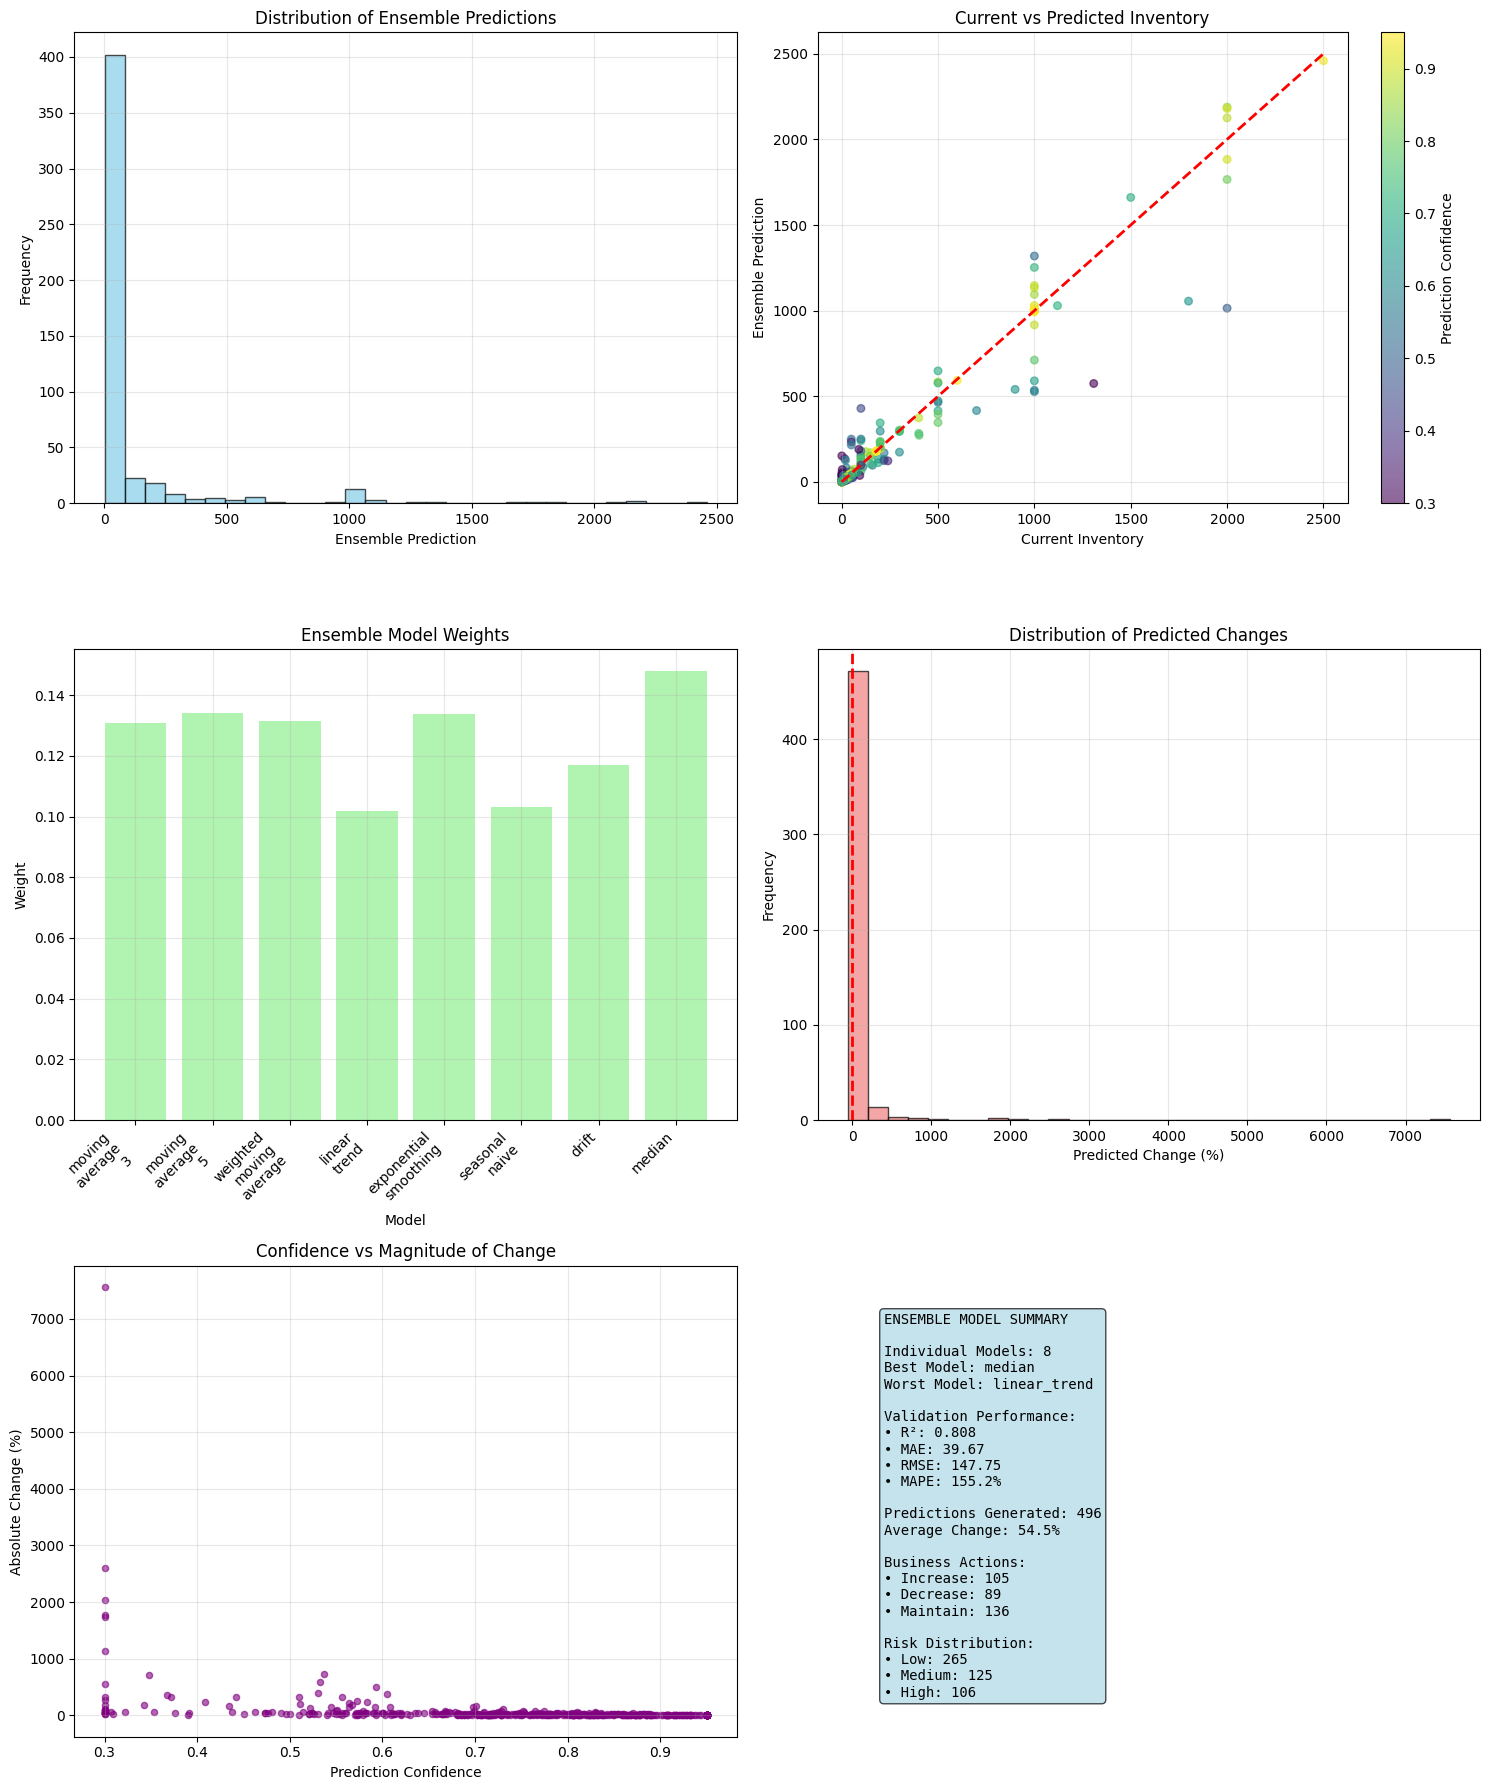

✓ Ensemble model configuration saved to: ensemble_inventory_model_20250915_131354.json

ENSEMBLE PREDICTION SUMMARY
Products with trained models: 496
Predictions generated: 496
Validation R²: 0.808
Validation MAE: 39.67
Validation MAPE: 155.2%
Average predicted change: 54.5%
Top 3 models by weight:
  median: 0.148
  moving_average_5: 0.134
  exponential_smoothing: 0.134
Model configuration saved to: ensemble_inventory_model_20250915_131354.json


In [20]:
# Ensemble Inventory Prediction System
# ====================================
# Combines multiple simple, reliable prediction methods for robust forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

print("=" * 60)
print("ENSEMBLE INVENTORY PREDICTION SYSTEM")
print("Combining multiple simple methods for robust forecasting")
print("=" * 60)

class EnsembleInventoryPredictor:
    """Ensemble predictor combining multiple simple, reliable methods"""
    
    def __init__(self):
        self.models = {}
        self.model_weights = {}
        self.model_performance = {}
        self.predictions = {}
        self.data_stats = {}
        
    def load_and_prepare_data(self, file_path):
        """Load and prepare data for ensemble modeling"""
        print("Loading and preparing data for ensemble prediction...")
        
        df = pd.read_csv(file_path)
        df = df.sort_values(['Name', 'Inventory_Cycle']).reset_index(drop=True)
        
        # Store basic statistics
        self.data_stats = {
            'total_products': df['Name'].nunique(),
            'total_periods': df['Inventory_Cycle'].nunique(),
            'total_records': len(df),
            'target_mean': df['Physical Storage Quantity'].mean(),
            'target_std': df['Physical Storage Quantity'].std()
        }
        
        print(f"✓ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"✓ Products: {self.data_stats['total_products']}")
        print(f"✓ Time periods: {self.data_stats['total_periods']}")
        
        return df
    
    def moving_average_predictor(self, ts, window=3):
        """Simple moving average predictor"""
        if len(ts) < window:
            return ts.iloc[-1] if len(ts) > 0 else 0
        
        return ts.tail(window).mean()
    
    def weighted_moving_average_predictor(self, ts, window=3):
        """Weighted moving average giving more weight to recent observations"""
        if len(ts) < window:
            return ts.iloc[-1] if len(ts) > 0 else 0
        
        recent_values = ts.tail(window).values
        weights = np.arange(1, window + 1)  # More weight to recent values
        weighted_avg = np.average(recent_values, weights=weights)
        return weighted_avg
    
    def linear_trend_predictor(self, ts):
        """Simple linear trend predictor"""
        if len(ts) < 3:
            return ts.iloc[-1] if len(ts) > 0 else 0
        
        try:
            x = np.arange(len(ts)).reshape(-1, 1)
            y = ts.values
            
            model = LinearRegression()
            model.fit(x, y)
            
            # Predict next period
            next_period = len(ts)
            prediction = model.predict([[next_period]])[0]
            
            return max(0, prediction)  # Ensure non-negative
        except:
            return ts.iloc[-1]
    
    def exponential_smoothing_predictor(self, ts, alpha=0.3):
        """Simple exponential smoothing"""
        if len(ts) == 0:
            return 0
        if len(ts) == 1:
            return ts.iloc[0]
        
        values = ts.values
        smoothed = [values[0]]
        
        for i in range(1, len(values)):
            smoothed.append(alpha * values[i] + (1 - alpha) * smoothed[-1])
        
        # Forecast next period
        next_forecast = alpha * values[-1] + (1 - alpha) * smoothed[-1]
        return max(0, next_forecast)
    
    def seasonal_naive_predictor(self, ts, season_length=12):
        """Seasonal naive predictor (same as same period last year)"""
        if len(ts) < season_length:
            return ts.iloc[-1] if len(ts) > 0 else 0
        
        # Use value from same period in previous season
        seasonal_value = ts.iloc[-season_length]
        return seasonal_value
    
    def drift_predictor(self, ts):
        """Simple drift method (linear trend from first to last)"""
        if len(ts) < 2:
            return ts.iloc[-1] if len(ts) > 0 else 0
        
        first_value = ts.iloc[0]
        last_value = ts.iloc[-1]
        periods = len(ts) - 1
        
        if periods == 0:
            return last_value
        
        drift = (last_value - first_value) / periods
        next_prediction = last_value + drift
        
        return max(0, next_prediction)
    
    def median_predictor(self, ts, window=5):
        """Robust median-based predictor"""
        if len(ts) == 0:
            return 0
        if len(ts) < window:
            return ts.median()
        
        return ts.tail(window).median()
    
    def train_ensemble_models(self, df, validation_split=0.2):
        """Train ensemble of simple models and determine weights"""
        print("\nTraining ensemble models...")
        
        target_col = 'Physical Storage Quantity'
        products = df['Name'].unique()
        
        # Initialize model performance tracking
        model_names = [
            'moving_average_3', 'moving_average_5', 'weighted_moving_average',
            'linear_trend', 'exponential_smoothing', 'seasonal_naive',
            'drift', 'median'
        ]
        
        model_errors = {name: [] for name in model_names}
        successful_products = 0
        
        print(f"Training models for {len(products)} products...")
        
        for i, product in enumerate(products):
            if (i + 1) % 100 == 0:
                print(f"  Progress: {i + 1}/{len(products)} products")
            
            # Get product time series
            product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
            ts = product_data[target_col]
            
            if len(ts) < 5:  # Skip products with insufficient data
                continue
            
            # Split for validation
            split_idx = int(len(ts) * (1 - validation_split))
            train_ts = ts.iloc[:split_idx]
            test_ts = ts.iloc[split_idx:]
            
            if len(test_ts) == 0:
                continue
            
            # Test each model on validation data
            for actual in test_ts:
                # Make predictions with each model
                predictions = {
                    'moving_average_3': self.moving_average_predictor(train_ts, 3),
                    'moving_average_5': self.moving_average_predictor(train_ts, 5),
                    'weighted_moving_average': self.weighted_moving_average_predictor(train_ts, 3),
                    'linear_trend': self.linear_trend_predictor(train_ts),
                    'exponential_smoothing': self.exponential_smoothing_predictor(train_ts),
                    'seasonal_naive': self.seasonal_naive_predictor(train_ts, 12),
                    'drift': self.drift_predictor(train_ts),
                    'median': self.median_predictor(train_ts)
                }
                
                # Calculate errors
                for model_name, pred in predictions.items():
                    error = abs(actual - pred)
                    model_errors[model_name].append(error)
                
                # Add the new actual value to training set for next prediction
                train_ts = pd.concat([train_ts, pd.Series([actual])], ignore_index=True)
            
            successful_products += 1
        
        # Calculate average errors and determine weights
        print(f"\n✓ Validated models on {successful_products} products")
        
        avg_errors = {}
        for model_name, errors in model_errors.items():
            if errors:
                avg_errors[model_name] = np.mean(errors)
            else:
                avg_errors[model_name] = float('inf')
        
        # Calculate weights (inverse of error, normalized)
        min_error = min(avg_errors.values())
        weights = {}
        total_weight = 0
        
        for model_name, error in avg_errors.items():
            if error == float('inf'):
                weights[model_name] = 0.0
            else:
                # Weight inversely proportional to error
                weight = min_error / error if error > 0 else 1.0
                weights[model_name] = weight
                total_weight += weight
        
        # Normalize weights
        if total_weight > 0:
            self.model_weights = {name: w / total_weight for name, w in weights.items()}
        else:
            # Equal weights if all models failed
            self.model_weights = {name: 1.0 / len(model_names) for name in model_names}
        
        self.model_performance = avg_errors
        
        print("\nModel Performance (Average MAE):")
        for model_name, error in sorted(avg_errors.items(), key=lambda x: x[1]):
            weight = self.model_weights[model_name]
            print(f"  {model_name}: {error:.2f} (weight: {weight:.3f})")
        
        return successful_products
    
    def make_ensemble_predictions(self, df):
        """Make predictions using the trained ensemble"""
        print("\nGenerating ensemble predictions...")
        
        target_col = 'Physical Storage Quantity'
        products = df['Name'].unique()
        predictions = []
        
        for product in products:
            try:
                # Get product time series
                product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
                ts = product_data[target_col]
                
                if len(ts) == 0:
                    continue
                
                # Get individual model predictions
                individual_predictions = {
                    'moving_average_3': self.moving_average_predictor(ts, 3),
                    'moving_average_5': self.moving_average_predictor(ts, 5),
                    'weighted_moving_average': self.weighted_moving_average_predictor(ts, 3),
                    'linear_trend': self.linear_trend_predictor(ts),
                    'exponential_smoothing': self.exponential_smoothing_predictor(ts),
                    'seasonal_naive': self.seasonal_naive_predictor(ts, 12),
                    'drift': self.drift_predictor(ts),
                    'median': self.median_predictor(ts)
                }
                
                # Calculate weighted ensemble prediction
                ensemble_prediction = 0
                total_weight = 0
                
                for model_name, pred in individual_predictions.items():
                    weight = self.model_weights.get(model_name, 0)
                    ensemble_prediction += weight * pred
                    total_weight += weight
                
                if total_weight > 0:
                    ensemble_prediction /= total_weight
                else:
                    ensemble_prediction = ts.iloc[-1]  # Fallback to last known value
                
                # Calculate prediction confidence based on model agreement
                pred_values = list(individual_predictions.values())
                pred_std = np.std(pred_values)
                pred_mean = np.mean(pred_values)
                
                # Lower std relative to mean indicates higher confidence
                if pred_mean > 0:
                    confidence = max(0.3, min(0.95, 1 - (pred_std / pred_mean)))
                else:
                    confidence = 0.5
                
                # Store prediction data
                current_inventory = ts.iloc[-1]
                last_cycle = product_data['Inventory_Cycle'].iloc[-1]
                
                predictions.append({
                    'product': product,
                    'current_inventory': current_inventory,
                    'ensemble_prediction': max(0, ensemble_prediction),
                    'individual_predictions': individual_predictions,
                    'prediction_confidence': confidence,
                    'last_cycle': last_cycle,
                    'next_cycle': last_cycle + 1,
                    'family': product_data['Family'].iloc[0] if 'Family' in product_data.columns else 'Unknown'
                })
                
            except Exception as e:
                print(f"  Warning: Prediction failed for {product}: {str(e)}")
                continue
        
        predictions_df = pd.DataFrame(predictions)
        
        if len(predictions_df) > 0:
            # Add business metrics
            predictions_df['inventory_change'] = (predictions_df['ensemble_prediction'] - 
                                                predictions_df['current_inventory'])
            predictions_df['change_percentage'] = ((predictions_df['ensemble_prediction'] - 
                                                  predictions_df['current_inventory']) / 
                                                 (predictions_df['current_inventory'] + 1)) * 100
            
            # Business recommendations
            predictions_df['recommendation'] = predictions_df.apply(self._get_recommendation, axis=1)
            
            # Risk assessment
            predictions_df['risk_level'] = predictions_df.apply(self._assess_risk, axis=1)
            
            print(f"✓ Generated ensemble predictions for {len(predictions_df)} products")
        
        return predictions_df
    
    def _get_recommendation(self, row):
        """Generate business recommendation"""
        change_pct = row['change_percentage']
        confidence = row['prediction_confidence']
        
        if confidence < 0.5:
            return "Monitor closely - Low confidence"
        elif change_pct >= 30:
            return "Increase stock significantly"
        elif change_pct >= 15:
            return "Increase stock moderately"
        elif change_pct >= 5:
            return "Slight increase recommended"
        elif change_pct <= -30:
            return "Reduce stock significantly"
        elif change_pct <= -15:
            return "Reduce stock moderately"
        elif change_pct <= -5:
            return "Slight decrease recommended"
        else:
            return "Maintain current levels"
    
    def _assess_risk(self, row):
        """Assess prediction risk level"""
        confidence = row['prediction_confidence']
        change_pct = abs(row['change_percentage'])
        
        if confidence >= 0.7 and change_pct < 20:
            return "Low"
        elif confidence >= 0.5 and change_pct < 40:
            return "Medium"
        else:
            return "High"
    
    def evaluate_ensemble_performance(self, df, test_periods=10):
        """Evaluate ensemble performance using walk-forward validation"""
        print(f"\nEvaluating ensemble performance (last {test_periods} periods)...")
        
        target_col = 'Physical Storage Quantity'
        all_predictions = []
        all_actuals = []
        product_metrics = []
        
        products = df['Name'].unique()
        successful_evaluations = 0
        
        for product in products:
            try:
                product_data = df[df['Name'] == product].sort_values('Inventory_Cycle')
                ts = product_data[target_col]
                
                if len(ts) < test_periods + 5:
                    continue
                
                # Use walk-forward validation
                train_size = len(ts) - test_periods
                train_ts = ts.iloc[:train_size]
                test_ts = ts.iloc[train_size:]
                
                product_predictions = []
                product_actuals = []
                
                current_train = train_ts.copy()
                
                for actual in test_ts:
                    # Make prediction using current training data
                    individual_preds = {
                        'moving_average_3': self.moving_average_predictor(current_train, 3),
                        'moving_average_5': self.moving_average_predictor(current_train, 5),
                        'weighted_moving_average': self.weighted_moving_average_predictor(current_train, 3),
                        'linear_trend': self.linear_trend_predictor(current_train),
                        'exponential_smoothing': self.exponential_smoothing_predictor(current_train),
                        'seasonal_naive': self.seasonal_naive_predictor(current_train, 12),
                        'drift': self.drift_predictor(current_train),
                        'median': self.median_predictor(current_train)
                    }
                    
                    # Ensemble prediction
                    ensemble_pred = 0
                    total_weight = 0
                    for model_name, pred in individual_preds.items():
                        weight = self.model_weights.get(model_name, 0)
                        ensemble_pred += weight * pred
                        total_weight += weight
                    
                    if total_weight > 0:
                        ensemble_pred /= total_weight
                    else:
                        ensemble_pred = current_train.iloc[-1]
                    
                    product_predictions.append(max(0, ensemble_pred))
                    product_actuals.append(actual)
                    
                    # Add actual to training data for next iteration
                    current_train = pd.concat([current_train, pd.Series([actual])], ignore_index=True)
                
                # Calculate metrics for this product
                if len(product_predictions) > 0:
                    product_r2 = r2_score(product_actuals, product_predictions)
                    product_mae = mean_absolute_error(product_actuals, product_predictions)
                    
                    # MAPE calculation
                    mape = np.mean(np.abs((np.array(product_actuals) - np.array(product_predictions)) / 
                                         (np.array(product_actuals) + 1e-8))) * 100
                    
                    product_metrics.append({
                        'product': product,
                        'r2': product_r2,
                        'mae': product_mae,
                        'mape': mape,
                        'n_predictions': len(product_predictions)
                    })
                    
                    all_predictions.extend(product_predictions)
                    all_actuals.extend(product_actuals)
                    successful_evaluations += 1
                
            except Exception as e:
                continue
        
        if len(all_predictions) > 0:
            # Overall metrics
            overall_r2 = r2_score(all_actuals, all_predictions)
            overall_mae = mean_absolute_error(all_actuals, all_predictions)
            overall_rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
            overall_mape = np.mean(np.abs((np.array(all_actuals) - np.array(all_predictions)) / 
                                         (np.array(all_actuals) + 1e-8))) * 100
            
            print(f"\nEnsemble Performance:")
            print(f"  Overall R²: {overall_r2:.3f}")
            print(f"  Overall MAE: {overall_mae:.2f}")
            print(f"  Overall RMSE: {overall_rmse:.2f}")
            print(f"  Overall MAPE: {overall_mape:.1f}%")
            print(f"  Products evaluated: {successful_evaluations}")
            
            return {
                'overall_r2': overall_r2,
                'overall_mae': overall_mae,
                'overall_rmse': overall_rmse,
                'overall_mape': overall_mape,
                'product_metrics': product_metrics,
                'n_products': successful_evaluations,
                'all_predictions': all_predictions,
                'all_actuals': all_actuals
            }
        
        return None
    
    def create_ensemble_visualizations(self, predictions_df, evaluation_results=None):
        """Create comprehensive visualizations for ensemble results"""
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 18))
        
        # 1. Prediction distribution
        axes[0, 0].hist(predictions_df['ensemble_prediction'], bins=30, alpha=0.7, 
                       color='skyblue', edgecolor='black')
        axes[0, 0].set_xlabel('Ensemble Prediction')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Distribution of Ensemble Predictions')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Current vs Predicted
        scatter = axes[0, 1].scatter(predictions_df['current_inventory'], 
                                   predictions_df['ensemble_prediction'],
                                   c=predictions_df['prediction_confidence'], 
                                   cmap='viridis', alpha=0.6, s=30)
        
        # Add diagonal line
        min_val = min(predictions_df['current_inventory'].min(), 
                     predictions_df['ensemble_prediction'].min())
        max_val = max(predictions_df['current_inventory'].max(), 
                     predictions_df['ensemble_prediction'].max())
        axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        
        axes[0, 1].set_xlabel('Current Inventory')
        axes[0, 1].set_ylabel('Ensemble Prediction')
        axes[0, 1].set_title('Current vs Predicted Inventory')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=axes[0, 1])
        cbar.set_label('Prediction Confidence')
        
        # 3. Model weights
        weights = self.model_weights
        model_names = list(weights.keys())
        weight_values = list(weights.values())
        
        axes[1, 0].bar(range(len(model_names)), weight_values, alpha=0.7, color='lightgreen')
        axes[1, 0].set_xlabel('Model')
        axes[1, 0].set_ylabel('Weight')
        axes[1, 0].set_title('Ensemble Model Weights')
        axes[1, 0].set_xticks(range(len(model_names)))
        axes[1, 0].set_xticklabels([name.replace('_', '\n') for name in model_names], 
                                  rotation=45, ha='right')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Change distribution
        axes[1, 1].hist(predictions_df['change_percentage'], bins=30, alpha=0.7, 
                       color='lightcoral', edgecolor='black')
        axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1, 1].set_xlabel('Predicted Change (%)')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Distribution of Predicted Changes')
        axes[1, 1].grid(True, alpha=0.3)
        
        # 5. Confidence vs Change
        axes[2, 0].scatter(predictions_df['prediction_confidence'], 
                          np.abs(predictions_df['change_percentage']),
                          alpha=0.6, s=20, color='purple')
        axes[2, 0].set_xlabel('Prediction Confidence')
        axes[2, 0].set_ylabel('Absolute Change (%)')
        axes[2, 0].set_title('Confidence vs Magnitude of Change')
        axes[2, 0].grid(True, alpha=0.3)
        
        # 6. Performance comparison
        if evaluation_results:
            axes[2, 1].axis('off')
            
            summary_text = f"""ENSEMBLE MODEL SUMMARY

Individual Models: {len(self.model_weights)}
Best Model: {min(self.model_performance.items(), key=lambda x: x[1])[0]}
Worst Model: {max(self.model_performance.items(), key=lambda x: x[1])[0]}

Validation Performance:
• R²: {evaluation_results['overall_r2']:.3f}
• MAE: {evaluation_results['overall_mae']:.2f}
• RMSE: {evaluation_results['overall_rmse']:.2f}
• MAPE: {evaluation_results['overall_mape']:.1f}%

Predictions Generated: {len(predictions_df)}
Average Change: {predictions_df['change_percentage'].mean():.1f}%

Business Actions:
• Increase: {(predictions_df['recommendation'].str.contains('Increase')).sum()}
• Decrease: {(predictions_df['recommendation'].str.contains('Reduce')).sum()}
• Maintain: {(predictions_df['recommendation'].str.contains('Maintain')).sum()}

Risk Distribution:
• Low: {(predictions_df['risk_level'] == 'Low').sum()}
• Medium: {(predictions_df['risk_level'] == 'Medium').sum()}
• High: {(predictions_df['risk_level'] == 'High').sum()}"""
        else:
            summary_text = f"""ENSEMBLE MODEL SUMMARY

Individual Models: {len(self.model_weights)}
Predictions Generated: {len(predictions_df)}
Average Change: {predictions_df['change_percentage'].mean():.1f}%

Model Weights:
{chr(10).join([f'• {name}: {weight:.3f}' for name, weight in sorted(self.model_weights.items(), key=lambda x: x[1], reverse=True)[:5]])}

Business Actions:
• Increase: {(predictions_df['recommendation'].str.contains('Increase')).sum()}
• Decrease: {(predictions_df['recommendation'].str.contains('Reduce')).sum()}
• Maintain: {(predictions_df['recommendation'].str.contains('Maintain')).sum()}"""
        
        axes[2, 1].text(0.1, 0.9, summary_text, transform=axes[2, 1].transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
        
        plt.tight_layout()
        plt.show()
    
    def save_ensemble_model(self, filename_prefix="ensemble_inventory_model"):
        """Save ensemble model configuration"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.json"
        
        import json
        
        model_config = {
            'model_weights': self.model_weights,
            'model_performance': self.model_performance,
            'data_stats': self.data_stats,
            'timestamp': timestamp,
            'model_type': 'ensemble'
        }
        
        with open(filename, 'w') as f:
            json.dump(model_config, f, indent=2)
        
        print(f"✓ Ensemble model configuration saved to: {filename}")
        return filename

def main():
    """Main execution for ensemble inventory prediction"""
    
    # Initialize ensemble predictor
    predictor = EnsembleInventoryPredictor()
    
    # Load data
    df = predictor.load_and_prepare_data('products_with_weekend.csv')
    
    # Train ensemble models
    n_products = predictor.train_ensemble_models(df, validation_split=0.2)
    
    if n_products > 0:
        # Make predictions
        predictions = predictor.make_ensemble_predictions(df)
        
        if len(predictions) > 0:
            # Evaluate performance
            evaluation = predictor.evaluate_ensemble_performance(df, test_periods=8)
            
            # Create visualizations
            predictor.create_ensemble_visualizations(predictions, evaluation)
            
            # Save model
            model_file = predictor.save_ensemble_model()
            
            # Summary report
            print(f"\n{'='*60}")
            print("ENSEMBLE PREDICTION SUMMARY")
            print(f"{'='*60}")
            
            print(f"Products with trained models: {n_products}")
            print(f"Predictions generated: {len(predictions)}")
            
            if evaluation:
                print(f"Validation R²: {evaluation['overall_r2']:.3f}")
                print(f"Validation MAE: {evaluation['overall_mae']:.2f}")
                print(f"Validation MAPE: {evaluation['overall_mape']:.1f}%")
            
            print(f"Average predicted change: {predictions['change_percentage'].mean():.1f}%")
            
            # Top weighted models
            top_models = sorted(predictor.model_weights.items(), key=lambda x: x[1], reverse=True)[:3]
            print(f"Top 3 models by weight:")
            for model, weight in top_models:
                print(f"  {model}: {weight:.3f}")
            
            print(f"Model configuration saved to: {model_file}")
            
            return predictor, predictions, evaluation
        else:
            print("No predictions generated")
            return predictor, None, None
    else:
        print("No models successfully trained")
        return predictor, None, None

if __name__ == "__main__":
    predictor, predictions, evaluation = main()

Loading and preparing data for ensemble prediction...
✓ Loaded: 72752 rows, 26 columns
✓ Products: 496
✓ Time periods: 52

Training ensemble models...
Training models for 496 products...
  Progress: 100/496 products
  Progress: 200/496 products
  Progress: 300/496 products
  Progress: 400/496 products

✓ Validated models on 496 products

Model Performance (Average MAE):
  median: 31.60 (weight: 0.148)
  moving_average_5: 34.81 (weight: 0.134)
  exponential_smoothing: 34.92 (weight: 0.134)
  weighted_moving_average: 35.54 (weight: 0.131)
  moving_average_3: 35.71 (weight: 0.131)
  drift: 39.93 (weight: 0.117)
  seasonal_naive: 45.22 (weight: 0.103)
  linear_trend: 45.93 (weight: 0.102)

Generating ensemble predictions...
✓ Generated ensemble predictions for 496 products

Evaluating ensemble performance (last 8 periods)...

Ensemble Performance:
  Overall R²: 0.808
  Overall MAE: 39.67
  Overall RMSE: 147.75
  Overall MAPE: 155.2%
  Products evaluated: 485


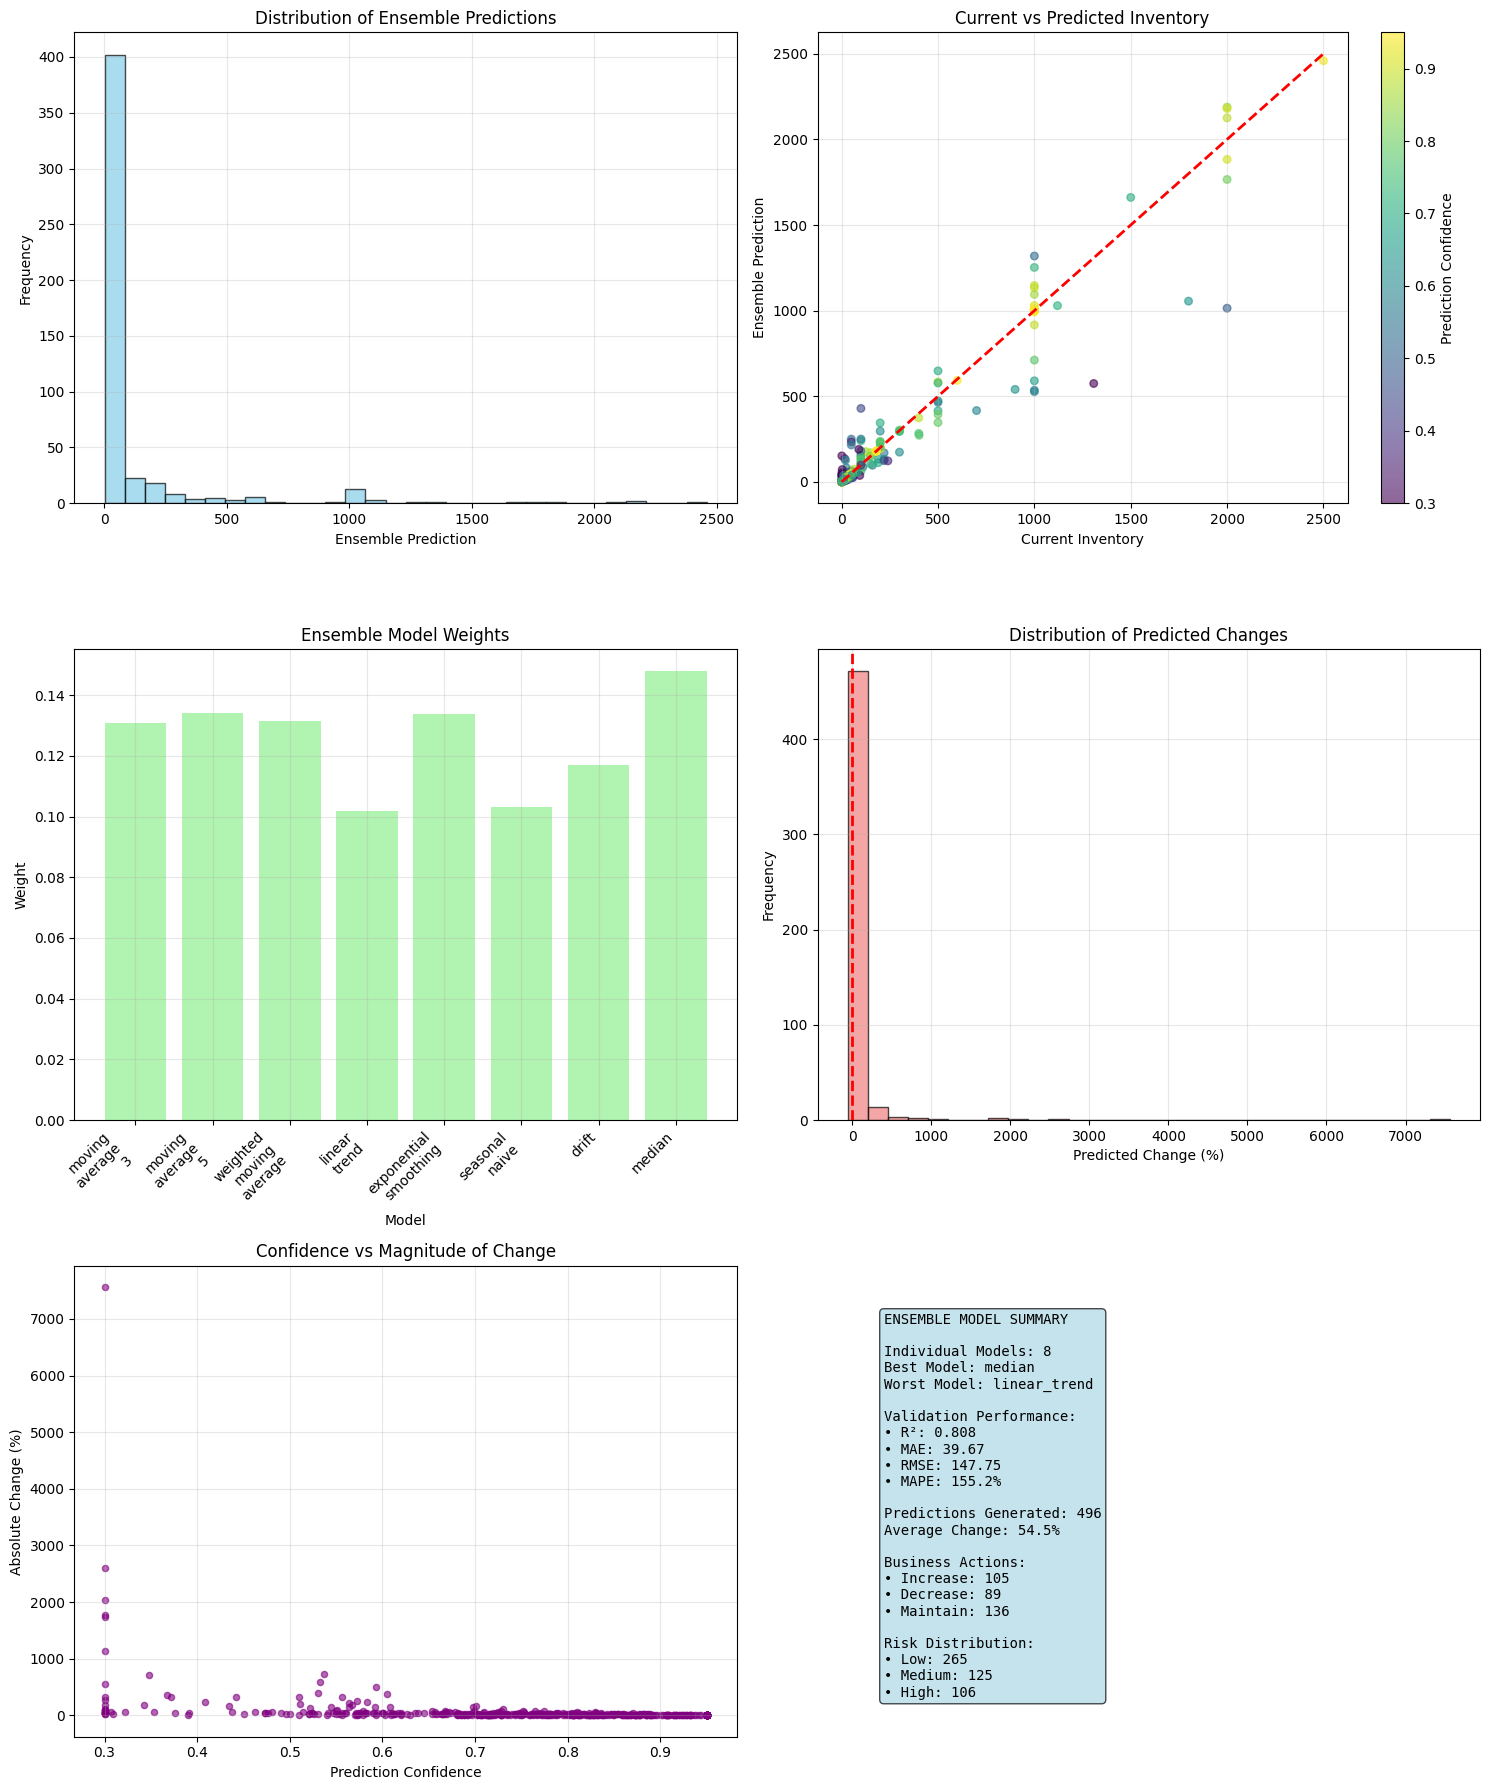

✓ Ensemble model configuration saved to: ensemble_inventory_model_20250915_131505.json

ENSEMBLE PREDICTION SUMMARY
Products with trained models: 496
Predictions generated: 496
Validation R²: 0.808
Validation MAE: 39.67
Validation MAPE: 155.2%
Average predicted change: 54.5%
Top 3 models by weight:
  median: 0.148
  moving_average_5: 0.134
  exponential_smoothing: 0.134
Model configuration saved to: ensemble_inventory_model_20250915_131505.json


In [21]:
predictor, predictions, evaluation = main()

In [7]:
# Example: Train ARIMA Models for Inventory Prediction
# ==================================================
# This script shows how to prepare your data and train ARIMA models

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Example of preparing your data in the correct format
def prepare_sample_data():
    """Create sample data in the correct format for ARIMA training"""
    
    print("📊 Creating sample data...")
    
    # Sample products
    products = ['BAGUETTE', 'CROISSANT', 'PAIN AU CHOCOLAT', 'BRIOCHE', 'ECLAIR']
    
    # Generate 6 months of daily data
    start_date = datetime(2024, 1, 1)
    end_date = datetime(2024, 6, 30)
    
    all_data = []
    
    for product in products:
        current_date = start_date
        base_inventory = np.random.randint(50, 200)  # Base inventory level
        
        while current_date <= end_date:
            # Create realistic inventory patterns
            day_of_week = current_date.weekday()
            
            # Weekend effect (lower inventory)
            weekend_factor = 0.7 if day_of_week >= 5 else 1.0
            
            # Seasonal trend (slight decline over time)
            time_factor = 1.0 - (current_date - start_date).days / 365 * 0.1
            
            # Random variation
            noise = np.random.normal(0, 0.15)
            
            # Calculate inventory
            inventory = base_inventory * weekend_factor * time_factor * (1 + noise)
            inventory = max(0, int(inventory))  # Ensure non-negative
            
            all_data.append({
                'Delivery date': current_date.strftime('%Y-%m-%d'),
                'Name': product,
                'Physical Storage Quantity': inventory,
                'Family': 'BAKERY'  # Optional family column
            })
            
            current_date += timedelta(days=1)
    
    # Create DataFrame
    df = pd.DataFrame(all_data)
    
    # Save to CSV
    df.to_csv('sample_inventory_data.csv', index=False)
    print(f"✅ Sample data created: {len(df)} records saved to 'sample_inventory_data.csv'")
    
    # Show sample
    print("\n📋 Sample of the data:")
    print(df.head(10))
    print(f"\n📊 Data summary:")
    print(f"   Products: {len(df['Name'].unique())}")
    print(f"   Date range: {df['Delivery date'].min()} to {df['Delivery date'].max()}")
    print(f"   Total records: {len(df)}")
    
    return df

def train_arima_example():
    """Example of how to train ARIMA models"""
    
    print("\n" + "="*60)
    print("🚀 ARIMA TRAINING EXAMPLE")
    print("="*60)
    
    # Method 1: Use existing data
    csv_file = 'sample_inventory_data.csv'  # Change this to your actual file
    
    # Check if file exists, if not create sample data
    import os
    if not os.path.exists(csv_file):
        print(f"📝 {csv_file} not found, creating sample data...")
        prepare_sample_data()
    
    # Import the ARIMA system
    # Note: In practice, you'd have the ARIMAInventoryPredictor in the same file or imported
    # For this example, we'll show the usage pattern
    
    print(f"\n🔄 Training ARIMA models from {csv_file}...")
    
    # This is how you would use it:
    """
    # Initialize the predictor
    predictor = ARIMAInventoryPredictor()
    
    # Load and preprocess data  
    success = predictor.load_data(
        csv_path=csv_file,
        date_column='Delivery date',
        inventory_column='Physical Storage Quantity', 
        product_column='Name'
    )
    
    if success:
        # Train ARIMA models for all products
        training_success = predictor.train_models(min_data_points=30)
        
        if training_success:
            # Save the trained models
            predictor.save_models('arima_inventory_models.pkl')
            
            # Get summary
            summary = predictor.get_model_summary()
            print(f"✅ Successfully trained {summary['total_models']} ARIMA models")
            
            # Test predictions
            sample_product = summary['trained_products'][0]
            result = predictor.predict_inventory(sample_product, steps_ahead=14)
            
            if result.get('success'):
                print(f"\n📈 Sample prediction for {sample_product}:")
                print(f"Current inventory: {result['current_inventory']:.0f}")
                print("Next 7 days:")
                for pred in result['predictions'][:7]:
                    print(f"  {pred['date']}: {pred['predicted_inventory']:.0f} units")
            
            # Optionally plot results
            # predictor.plot_predictions(sample_product, steps_ahead=30)
            
        else:
            print("❌ No models were trained successfully")
    else:
        print("❌ Failed to load data")
    """
    
    print("\n📋 To train your ARIMA models:")
    print("1. Prepare your CSV with columns: Delivery date, Physical Storage Quantity, Name")
    print("2. Run the ARIMAInventoryPredictor training code shown above")
    print("3. The trained models will be saved to 'arima_inventory_models.pkl'")
    print("4. Start the Flask app to use the web interface")

def check_data_format(csv_file):
    """Helper function to check if your data is in the correct format"""
    
    try:
        print(f"📊 Checking data format in {csv_file}...")
        
        df = pd.read_csv(csv_file)
        print(f"✅ File loaded successfully: {len(df)} rows")
        
        # Check required columns
        required_cols = ['Delivery date', 'Physical Storage Quantity', 'Name']
        missing_cols = [col for col in required_cols if col not in df.columns]
        
        if missing_cols:
            print(f"❌ Missing required columns: {missing_cols}")
            print(f"Available columns: {list(df.columns)}")
            return False
        else:
            print("✅ All required columns present")
        
        # Check data types and formats
        print(f"\n📋 Data Summary:")
        print(f"   Columns: {list(df.columns)}")
        print(f"   Products: {df['Name'].nunique()}")
        print(f"   Date range: {df['Delivery date'].min()} to {df['Delivery date'].max()}")
        
        # Sample data
        print(f"\n📊 First 5 rows:")
        print(df.head())
        
        # Check for issues
        print(f"\n🔍 Data Quality Check:")
        print(f"   Missing values in Delivery date: {df['Delivery date'].isna().sum()}")
        print(f"   Missing values in Physical Storage Quantity: {df['Physical Storage Quantity'].isna().sum()}")
        print(f"   Missing values in Name: {df['Name'].isna().sum()}")
        
        # Try date parsing
        try:
            pd.to_datetime(df['Delivery date'].head())
            print("✅ Delivery date format looks good")
        except:
            print("❌ Delivery date format issue - should be YYYY-MM-DD")
            
        # Check inventory values
        inventory_stats = df['Physical Storage Quantity'].describe()
        print(f"\n📈 Inventory Statistics:")
        print(f"   Min: {inventory_stats['min']:.1f}")
        print(f"   Max: {inventory_stats['max']:.1f}")
        print(f"   Mean: {inventory_stats['mean']:.1f}")
        
        if inventory_stats['min'] < 0:
            print("⚠️  Warning: Negative inventory values found")
            
        return True
        
    except Exception as e:
        print(f"❌ Error reading file: {e}")
        return False

# Example usage
if __name__ == "__main__":
    print("🔮 ARIMA Inventory Prediction - Training Example")
    print("=" * 50)
    
    # Option 1: Check your existing data format
    your_csv_file = "your_inventory_data.csv"  # Change this to your actual file
    
    print("Choose an option:")
    print("1. Check existing CSV format")
    print("2. Create sample data and train example")
    print("3. Show training code template")
    
    choice = input("Enter choice (1/2/3): ").strip()
    
    if choice == "1":
        csv_file = input(f"Enter CSV file path (or press Enter for '{your_csv_file}'): ").strip()
        if not csv_file:
            csv_file = your_csv_file
        check_data_format(csv_file)
        
    elif choice == "2":
        prepare_sample_data()
        train_arima_example()
        
    elif choice == "3":
        print("\n" + "="*60)
        print("📝 TRAINING CODE TEMPLATE")
        print("="*60)
        print("""
# Complete training script for ARIMA inventory prediction

from your_arima_module import ARIMAInventoryPredictor  # Import your ARIMA class

def train_your_models():
    # Initialize predictor
    predictor = ARIMAInventoryPredictor()
    
    # Load your data
    success = predictor.load_data(
        csv_path='your_data.csv',           # Your CSV file
        date_column='Delivery date',         # Date column name
        inventory_column='Physical Storage Quantity',  # Inventory column
        product_column='Name'                # Product name column
    )
    
    if success:
        print("✅ Data loaded successfully")
        
        # Train models (only products with 30+ data points)
        training_success = predictor.train_models(min_data_points=30)
        
        if training_success:
            # Save trained models
            predictor.save_models('arima_inventory_models.pkl')
            print("✅ Models saved successfully")
            
            # Get training summary
            summary = predictor.get_model_summary()
            print(f"Trained models for {summary['total_models']} products")
            
            return predictor
        else:
            print("❌ Training failed")
            return None
    else:
        print("❌ Data loading failed")
        return None

# Run training
if __name__ == "__main__":
    predictor = train_your_models()
    
    # Test prediction on one product
    if predictor:
        products = list(predictor.models.keys())
        if products:
            test_product = products[0]
            result = predictor.predict_inventory(test_product, steps_ahead=14)
            print(f"Test prediction for {test_product}: {result}")
        """)
    
    else:
        print("Invalid choice")
    
    print(f"\n🎯 Next Steps:")
    print("1. Ensure your data is in the correct format with Delivery dates")
    print("2. Run the ARIMA training script")  
    print("3. Start the Flask app for the web interface")
    print("4. Use the web app to make forecasts!")

# Data format requirements summary
print(f"\n📋 Required CSV Format:")
print(f"{'='*40}")
print(f"Required columns:")
print(f"  • Delivery date (format: 2024-01-01)")
print(f"  • Physical Storage Quantity (numeric)")
print(f"  • Name (product name)")
print(f"Optional columns:")
print(f"  • Family (product family/category)")
print(f"\nExample row:")
print(f"2024-01-01,BAGUETTE,125,BAKERY")

🔮 ARIMA Inventory Prediction - Training Example
Choose an option:
1. Check existing CSV format
2. Create sample data and train example
3. Show training code template


Enter choice (1/2/3):  1
Enter CSV file path (or press Enter for 'your_inventory_data.csv'):  C:\Users\ayoub\OneDrive\Bureau\PFE\products_with_weekend.csv


📊 Checking data format in C:\Users\ayoub\OneDrive\Bureau\PFE\products_with_weekend.csv...
✅ File loaded successfully: 72752 rows
✅ All required columns present

📋 Data Summary:
   Columns: ['Site', 'Item Id', 'Name', 'Physical Storage Quantity', 'Storage Unit', 'Family', 'GroupName', 'From', 'To', 'Delivery date', 'Date_week', 'Month', 'Week_iso', 'Demanded', 'Delivered', 'Cycle', 'DispatchFlag', 'flow', 'Stock_Class_x', 'Stock_Class_y', 'Stock_Class', 'satisfaction_rate (%)', 'days_since_start', 'Inventory_Cycle', 'Max_Stock', 'Weekend']
   Products: 496
   Date range: 2024-01-01 to 2025-05-31

📊 First 5 rows:
       Site  Item Id                Name  Physical Storage Quantity  \
0  Economat    15027            MAY 0.5L                      529.0   
1  Economat    15470   CELTIA FUT DE 50L                        2.0   
2  Economat    12585     COCA BOITE ZERO                       28.0   
3  Economat    16339         FORTE NSPRS                      250.0   
4  Economat    12576  CHOC